In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.4f}'.format
plt.style.use("seaborn-v0_8")

import seaborn as sns

import datetime as dt
from scipy import stats
%config InlineBackend.figure_format = 'retina'

In [ ]:
df = pd.read_csv("multi_assets.csv", header = [0, 1], index_col = 0, parse_dates = [0])
df

Adj Close                                                    \
                  BA    BTC-USD EURUSD=X      GC=F     MSFT       ^DJI   
Date                                                                     
2014-10-01  108.4067   383.6150   1.2628 1214.6000  40.3334 16804.7109   
2014-10-02  107.9719   375.0720   1.2624 1214.2000  40.2103 16801.0508   
2014-10-03  109.8762   359.5120   1.2671 1192.2000  40.5003 17009.6895   
2014-10-04       NaN   328.8660      NaN       NaN      NaN        NaN   
2014-10-05       NaN   320.5100      NaN       NaN      NaN        NaN   
...              ...        ...      ...       ...      ...        ...   
2021-05-27  250.7000 38436.9688   1.2193 1895.7000 249.3100 34464.6406   
2021-05-28  247.0200 35697.6055   1.2193 1902.5000 249.6800 34529.4492   
2021-05-29       NaN 34616.0664      NaN       NaN      NaN        NaN   
2021-05-30       NaN 35678.1289      NaN       NaN      NaN        NaN   
2021-05-31       NaN 37332.8555   1.2190       NaN      NaN        NaN   

              Close                                ...     Open            \
                 BA    BTC-USD EURUSD=X      GC=F  ... EURUSD=X      GC=F   
Date                                               ...                      
2014-10-01 124.6700   383.6150   1.2628 1214.6000  ...   1.2629 1207.7000   
2014-10-02 124.1700   375.0720   1.2624 1214.2000  ...   1.2625 1215.3000   
2014-10-03 126.3600   359.5120   1.2671 1192.2000  ...   1.2670 1212.4000   
2014-10-04      NaN   328.8660      NaN       NaN  ...      NaN       NaN   
2014-10-05      NaN   320.5100      NaN       NaN  ...      NaN       NaN   
...             ...        ...      ...       ...  ...      ...       ...   
2021-05-27 250.7000 38436.9688   1.2193 1895.7000  ...   1.2190 1896.8000   
2021-05-28 247.0200 35697.6055   1.2193 1902.5000  ...   1.2193 1897.5000   
2021-05-29      NaN 34616.0664      NaN       NaN  ...      NaN       NaN   
2021-05-30      NaN 35678.1289      NaN       NaN  ...      NaN       NaN   
2021-05-31      NaN 37332.8555   1.2190       NaN  ...   1.2190       NaN   

                                      Volume                            \
               MSFT       ^DJI            BA          BTC-USD EURUSD=X   
Date                                                                     
2014-10-01  46.2700 17040.4609  5265200.0000    26229400.0000   0.0000   
2014-10-02  45.8300 16808.2695  3204500.0000    21777700.0000   0.0000   
2014-10-03  45.9800 16802.1992  3075900.0000    30901200.0000   0.0000   
2014-10-04      NaN        NaN           NaN    47236500.0000      NaN   
2014-10-05      NaN        NaN           NaN    83308096.0000      NaN   
...             ...        ...           ...              ...      ...   
2021-05-27 251.1700 34432.4688 18404400.0000 43210968721.0000   0.0000   
2021-05-28 251.0000 34558.5000 11197400.0000 55200191952.0000   0.0000   
2021-05-29      NaN        NaN           NaN 45231013335.0000      NaN   
2021-05-30      NaN        NaN           NaN 31646080921.0000      NaN   
2021-05-31      NaN        NaN           NaN 39009847639.0000   0.0000   

                                                    
                 GC=F          MSFT           ^DJI  
Date                                                
2014-10-01   178.0000 38088400.0000 104240000.0000  
2014-10-02   176.0000 25119400.0000  75490000.0000  
2014-10-03   499.0000 32453200.0000  87940000.0000  
2014-10-04        NaN           NaN            NaN  
2014-10-05        NaN           NaN            NaN  
...               ...           ...            ...  
2021-05-27 35794.0000 24426200.0000 520630000.0000  
2021-05-28  2415.0000 18270200.0000 290850000.0000  
2021-05-29        NaN           NaN            NaN  
2021-05-30        NaN           NaN            NaN  
2021-05-31        NaN           NaN            NaN  

[2435 rows x 36 columns]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2435 entries, 2014-10-01 to 2021-05-31
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Adj Close, BA)        1677 non-null   float64
 1   (Adj Close, BTC-USD)   2431 non-null   float64
 2   (Adj Close, EURUSD=X)  1716 non-null   float64
 3   (Adj Close, GC=F)      1662 non-null   float64
 4   (Adj Close, MSFT)      1677 non-null   float64
 5   (Adj Close, ^DJI)      1677 non-null   float64
 6   (Close, BA)            1677 non-null   float64
 7   (Close, BTC-USD)       2431 non-null   float64
 8   (Close, EURUSD=X)      1716 non-null   float64
 9   (Close, GC=F)          1662 non-null   float64
 10  (Close, MSFT)          1677 non-null   float64
 11  (Close, ^DJI)          1677 non-null   float64
 12  (High, BA)             1677 non-null   float64
 13  (High, BTC-USD)        2431 non-null   float64
 14  (High, EURUSD=X)       1716 non-null  

Ticker Symbols: <br>
- __BA__: Boeing (US Stock) 
- __MSFT__: Microsoft Corp (US Stock)
- __^DJI__: Dow Jones Industrial Average (US Stock Index)
- __EURUSD=X__: Exchange Rate for Currency Pair EUR/USD (Forex)
- __GC=F__: Gold Price (Precious Metal / Commodity)
- __BTC-USD__: Bitcoin in USD (Cryptocurrency)

In [ ]:
close = df.Close.dropna().copy()
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,124.6700,383.6150,1.2628,1214.6000,45.9000,16804.7109
2014-10-02,124.1700,375.0720,1.2624,1214.2000,45.7600,16801.0508
2014-10-03,126.3600,359.5120,1.2671,1192.2000,46.0900,17009.6895
2014-10-06,126.2600,330.0790,1.2514,1206.7000,46.0900,16991.9102
2014-10-07,123.3200,336.1870,1.2646,1211.7000,45.5300,16719.3906
...,...,...,...,...,...,...
2021-05-24,237.4400,38705.9805,1.2183,1884.6000,250.7800,34393.9805
2021-05-25,240.7400,38402.2227,1.2215,1898.1000,251.7200,34312.4609
2021-05-26,241.3700,39294.1992,1.2249,1901.3000,251.4900,34323.0508


In [ ]:
close.describe()

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
count,1635.0000,1635.0000,1635.0000,1635.0000,1635.0000,1635.0000
mean,226.7583,7584.1645,1.1410,1369.3530,105.6719,22937.2622
std,93.5997,11735.5819,0.0501,235.9621,60.9903,4674.3779
min,95.0100,178.1030,1.0390,1050.8000,40.2900,15660.1797
25%,143.0000,458.8255,1.1065,1214.4500,54.4100,18059.5898
50%,186.9100,4181.9302,1.1308,1281.7000,88.0000,23526.1797
75%,333.0600,9191.8457,1.1777,1472.9500,138.6950,26179.7158
max,440.6200,63503.4570,1.2822,2051.5000,261.9700,34777.7617


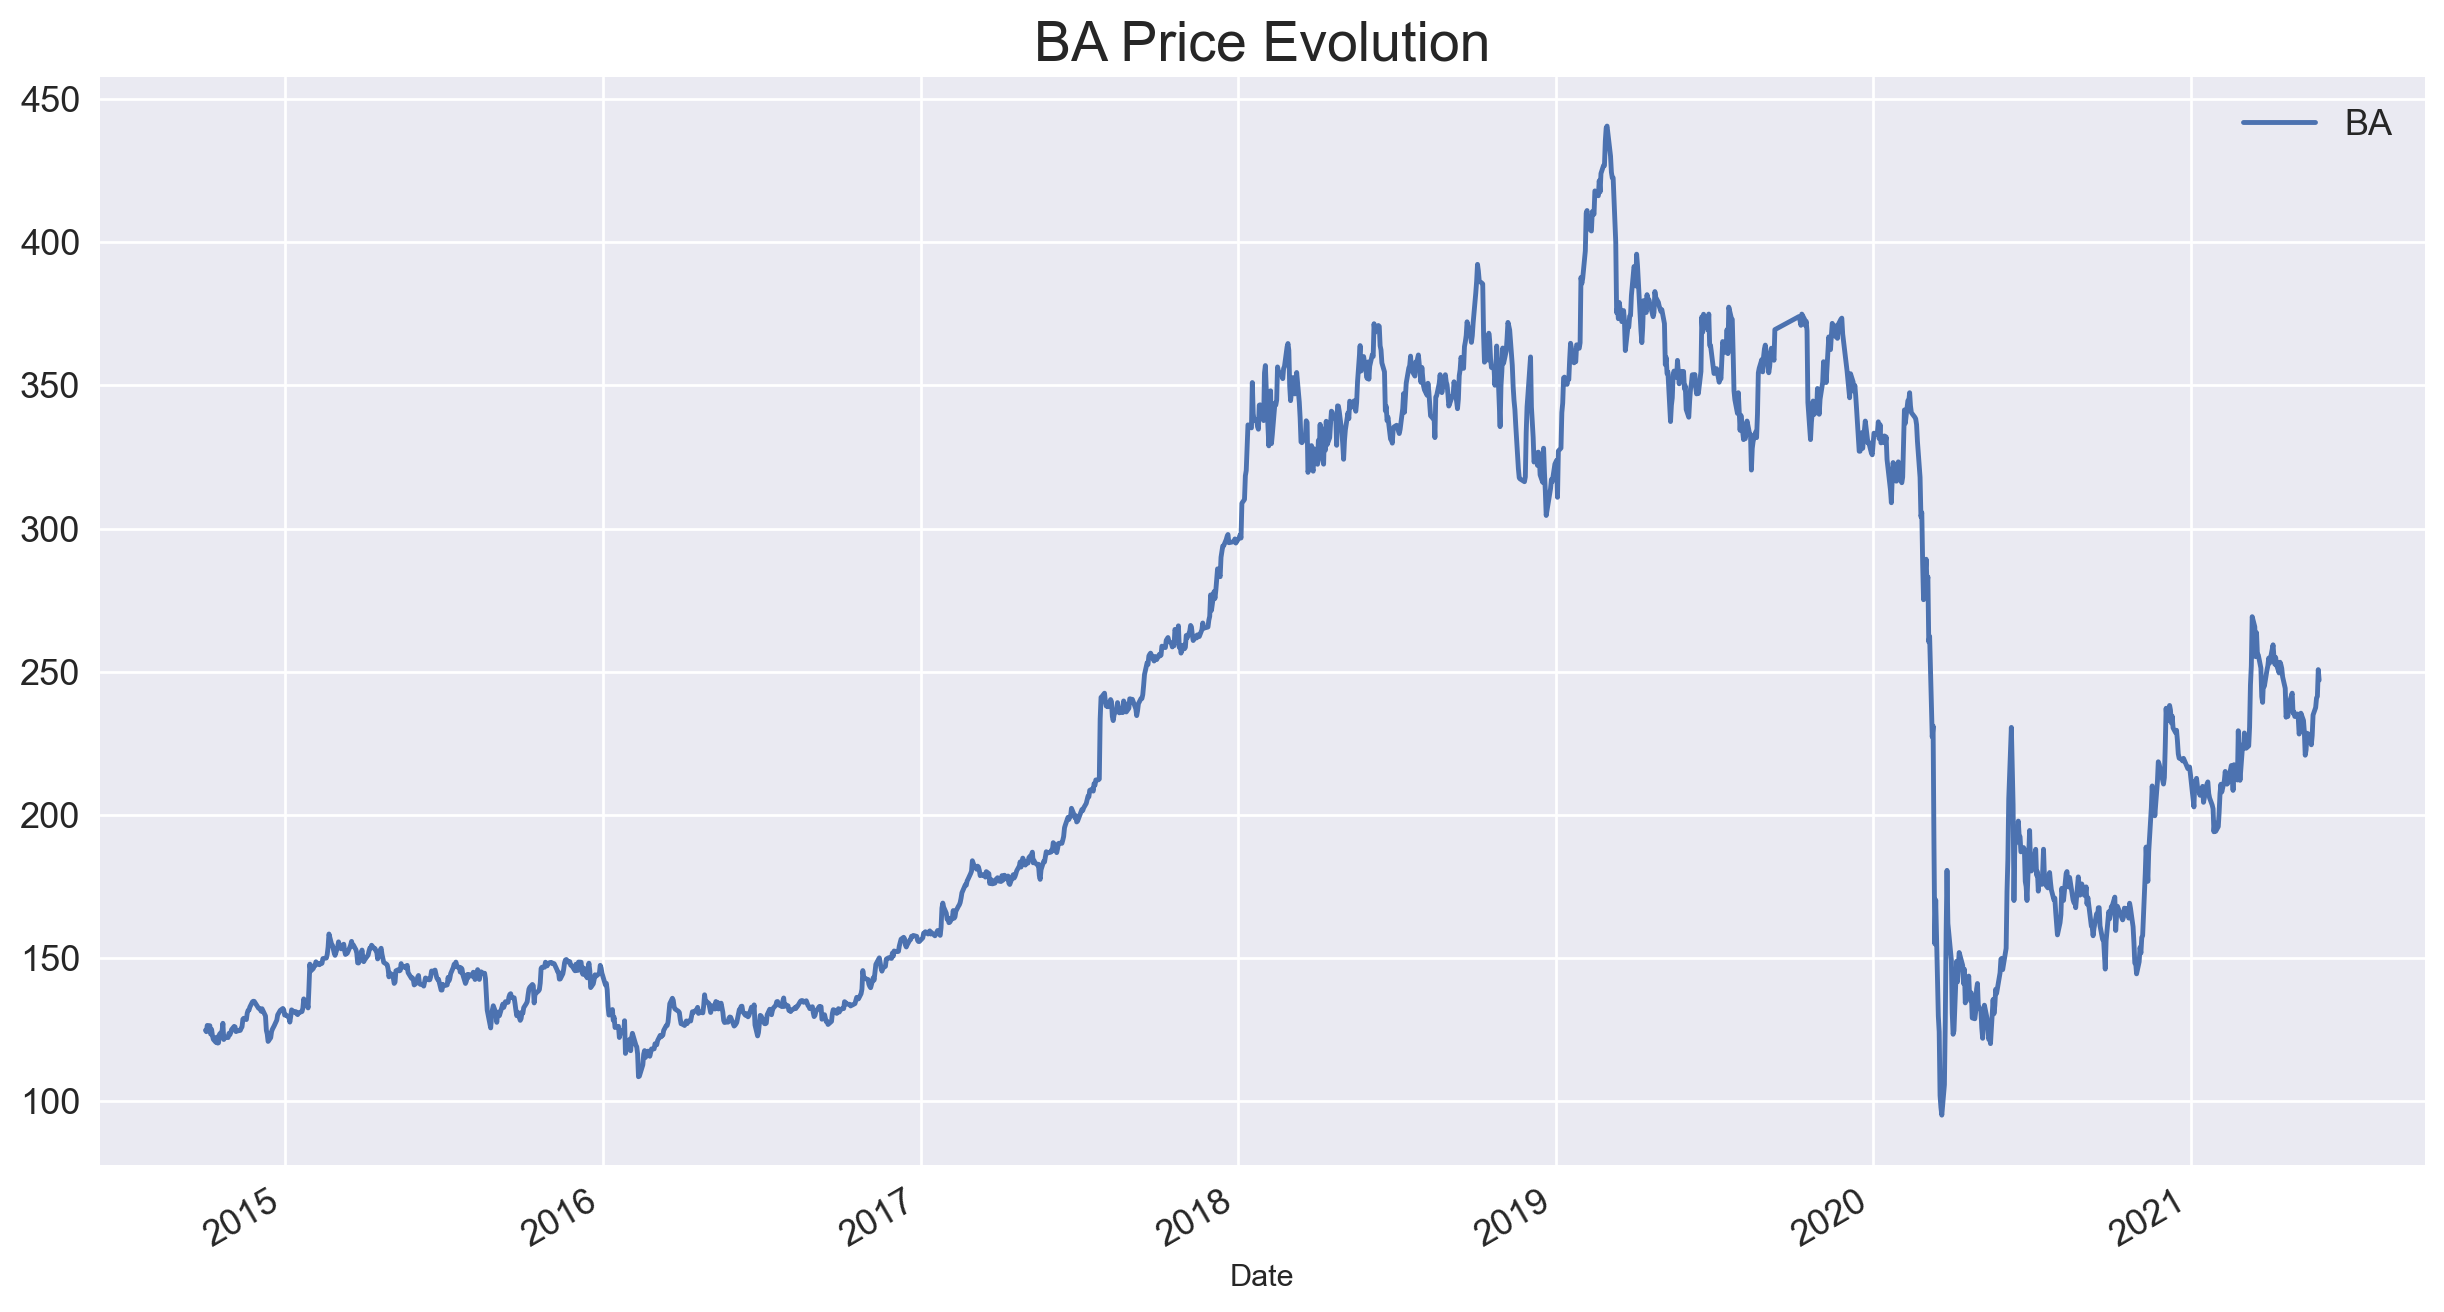

In [ ]:
close.BA.plot(figsize = (15, 8), fontsize = 13)
plt.title("BA Price Evolution", fontsize = 20)
plt.legend(fontsize = 13)
plt.show()

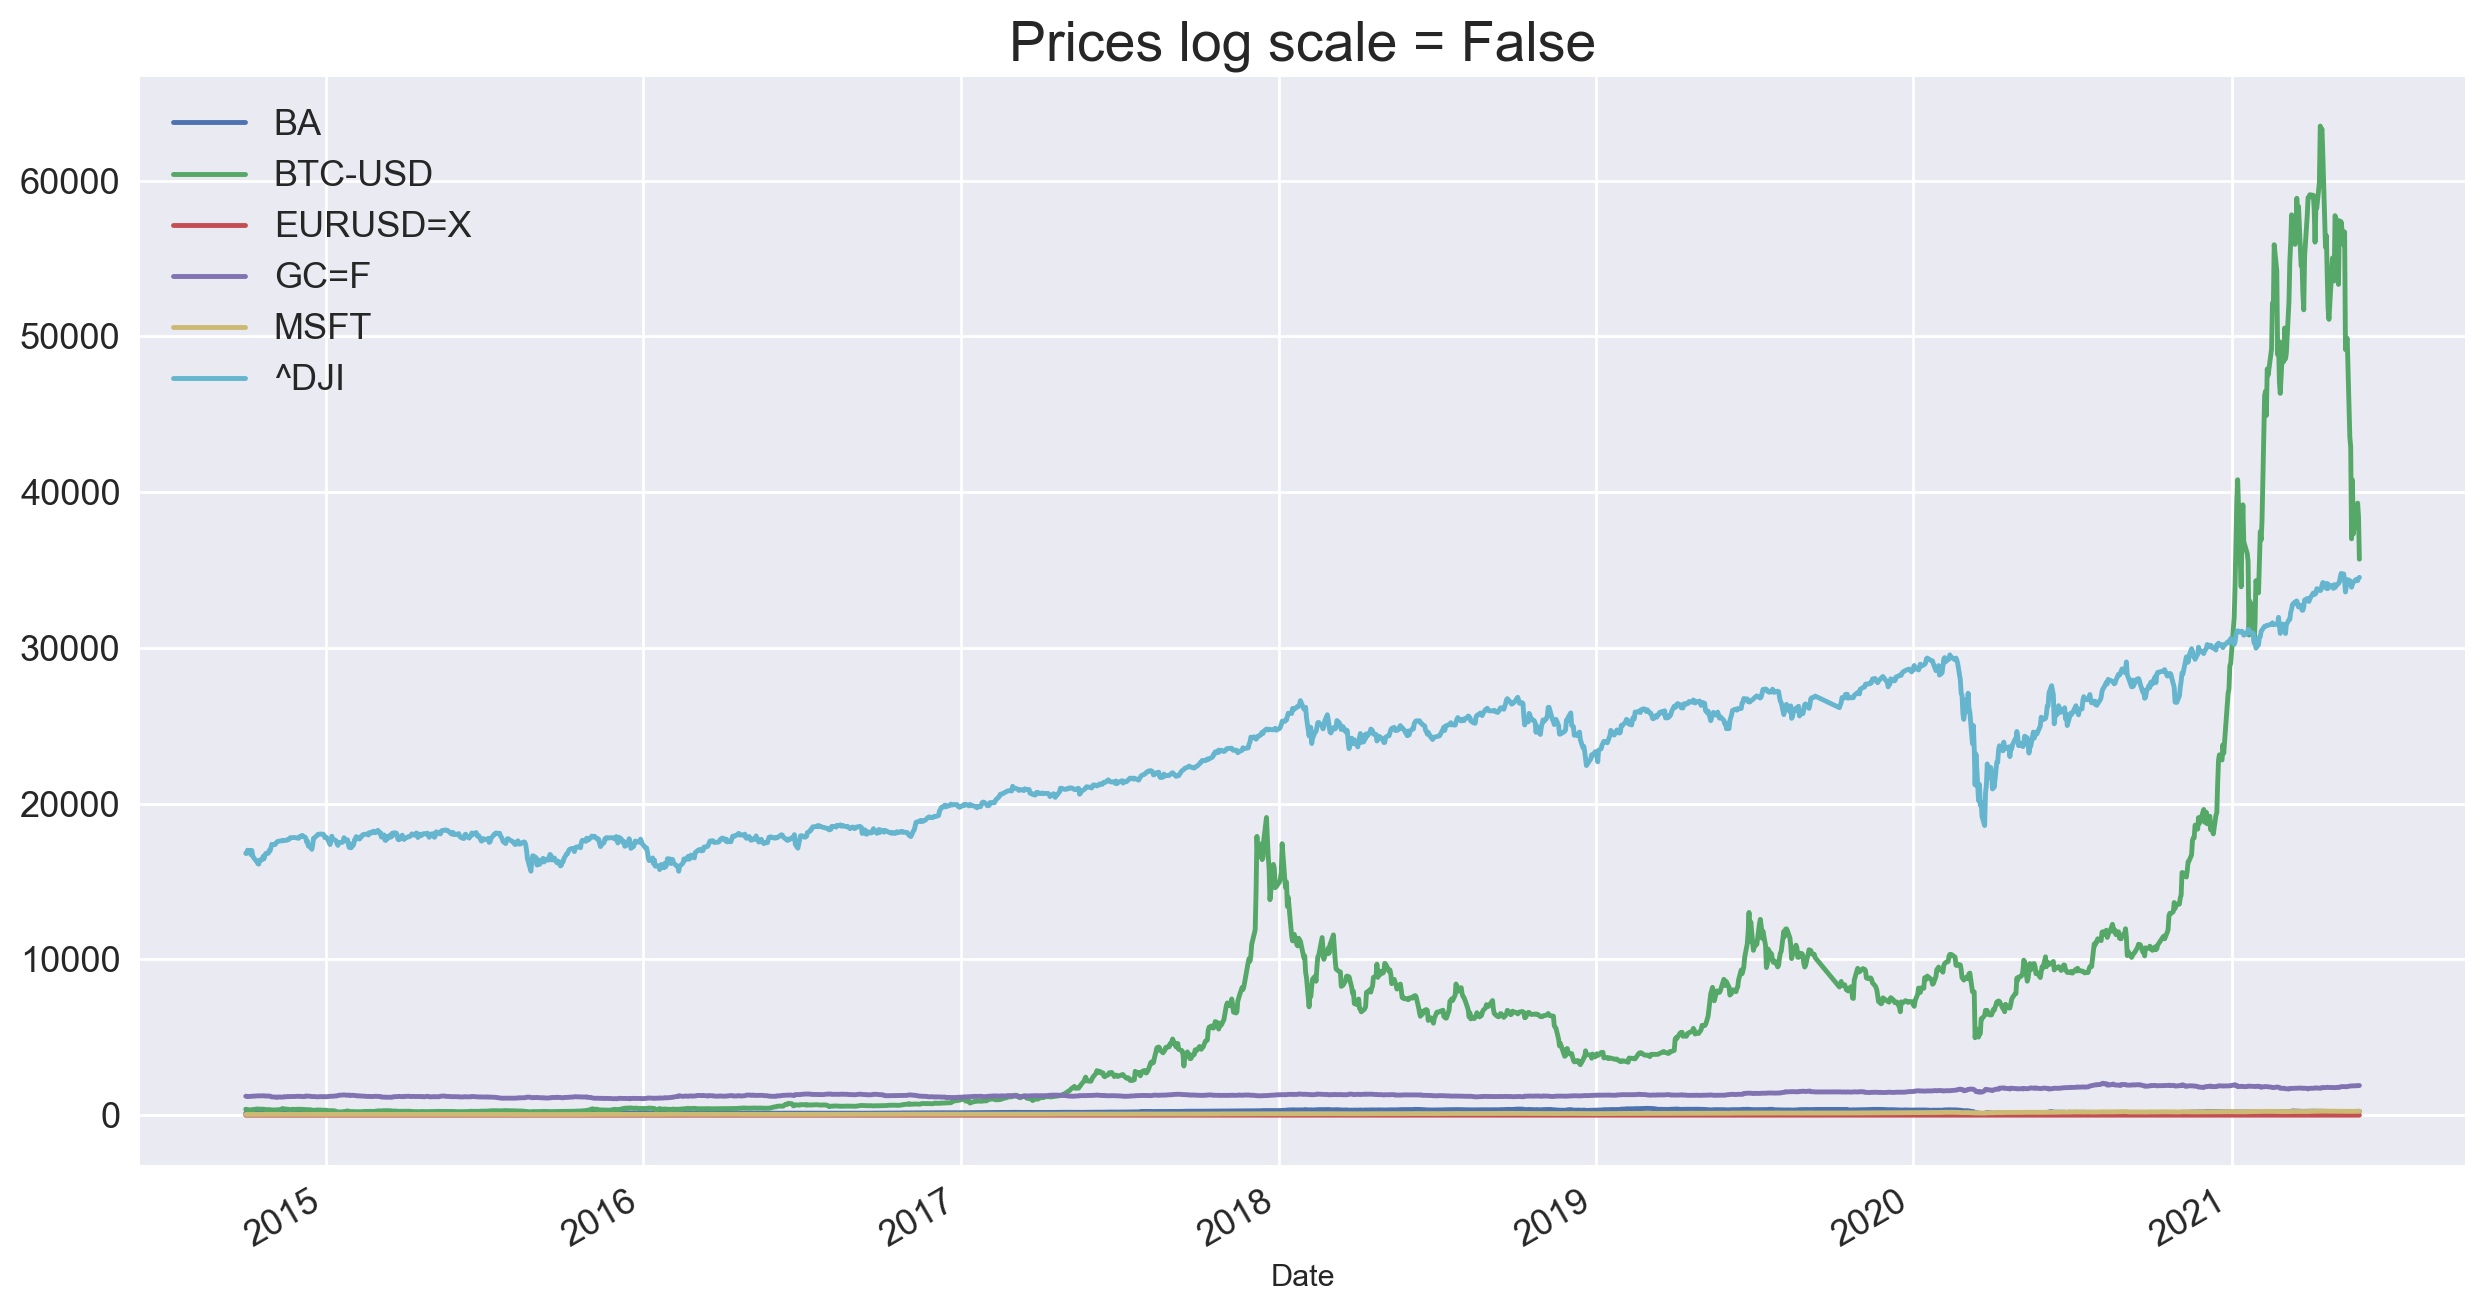

In [ ]:
close.plot(figsize = (15, 8), fontsize = 13 , logy = False)
plt.title("Prices log scale = False", fontsize = 20)
plt.legend(fontsize = 13)
plt.show()

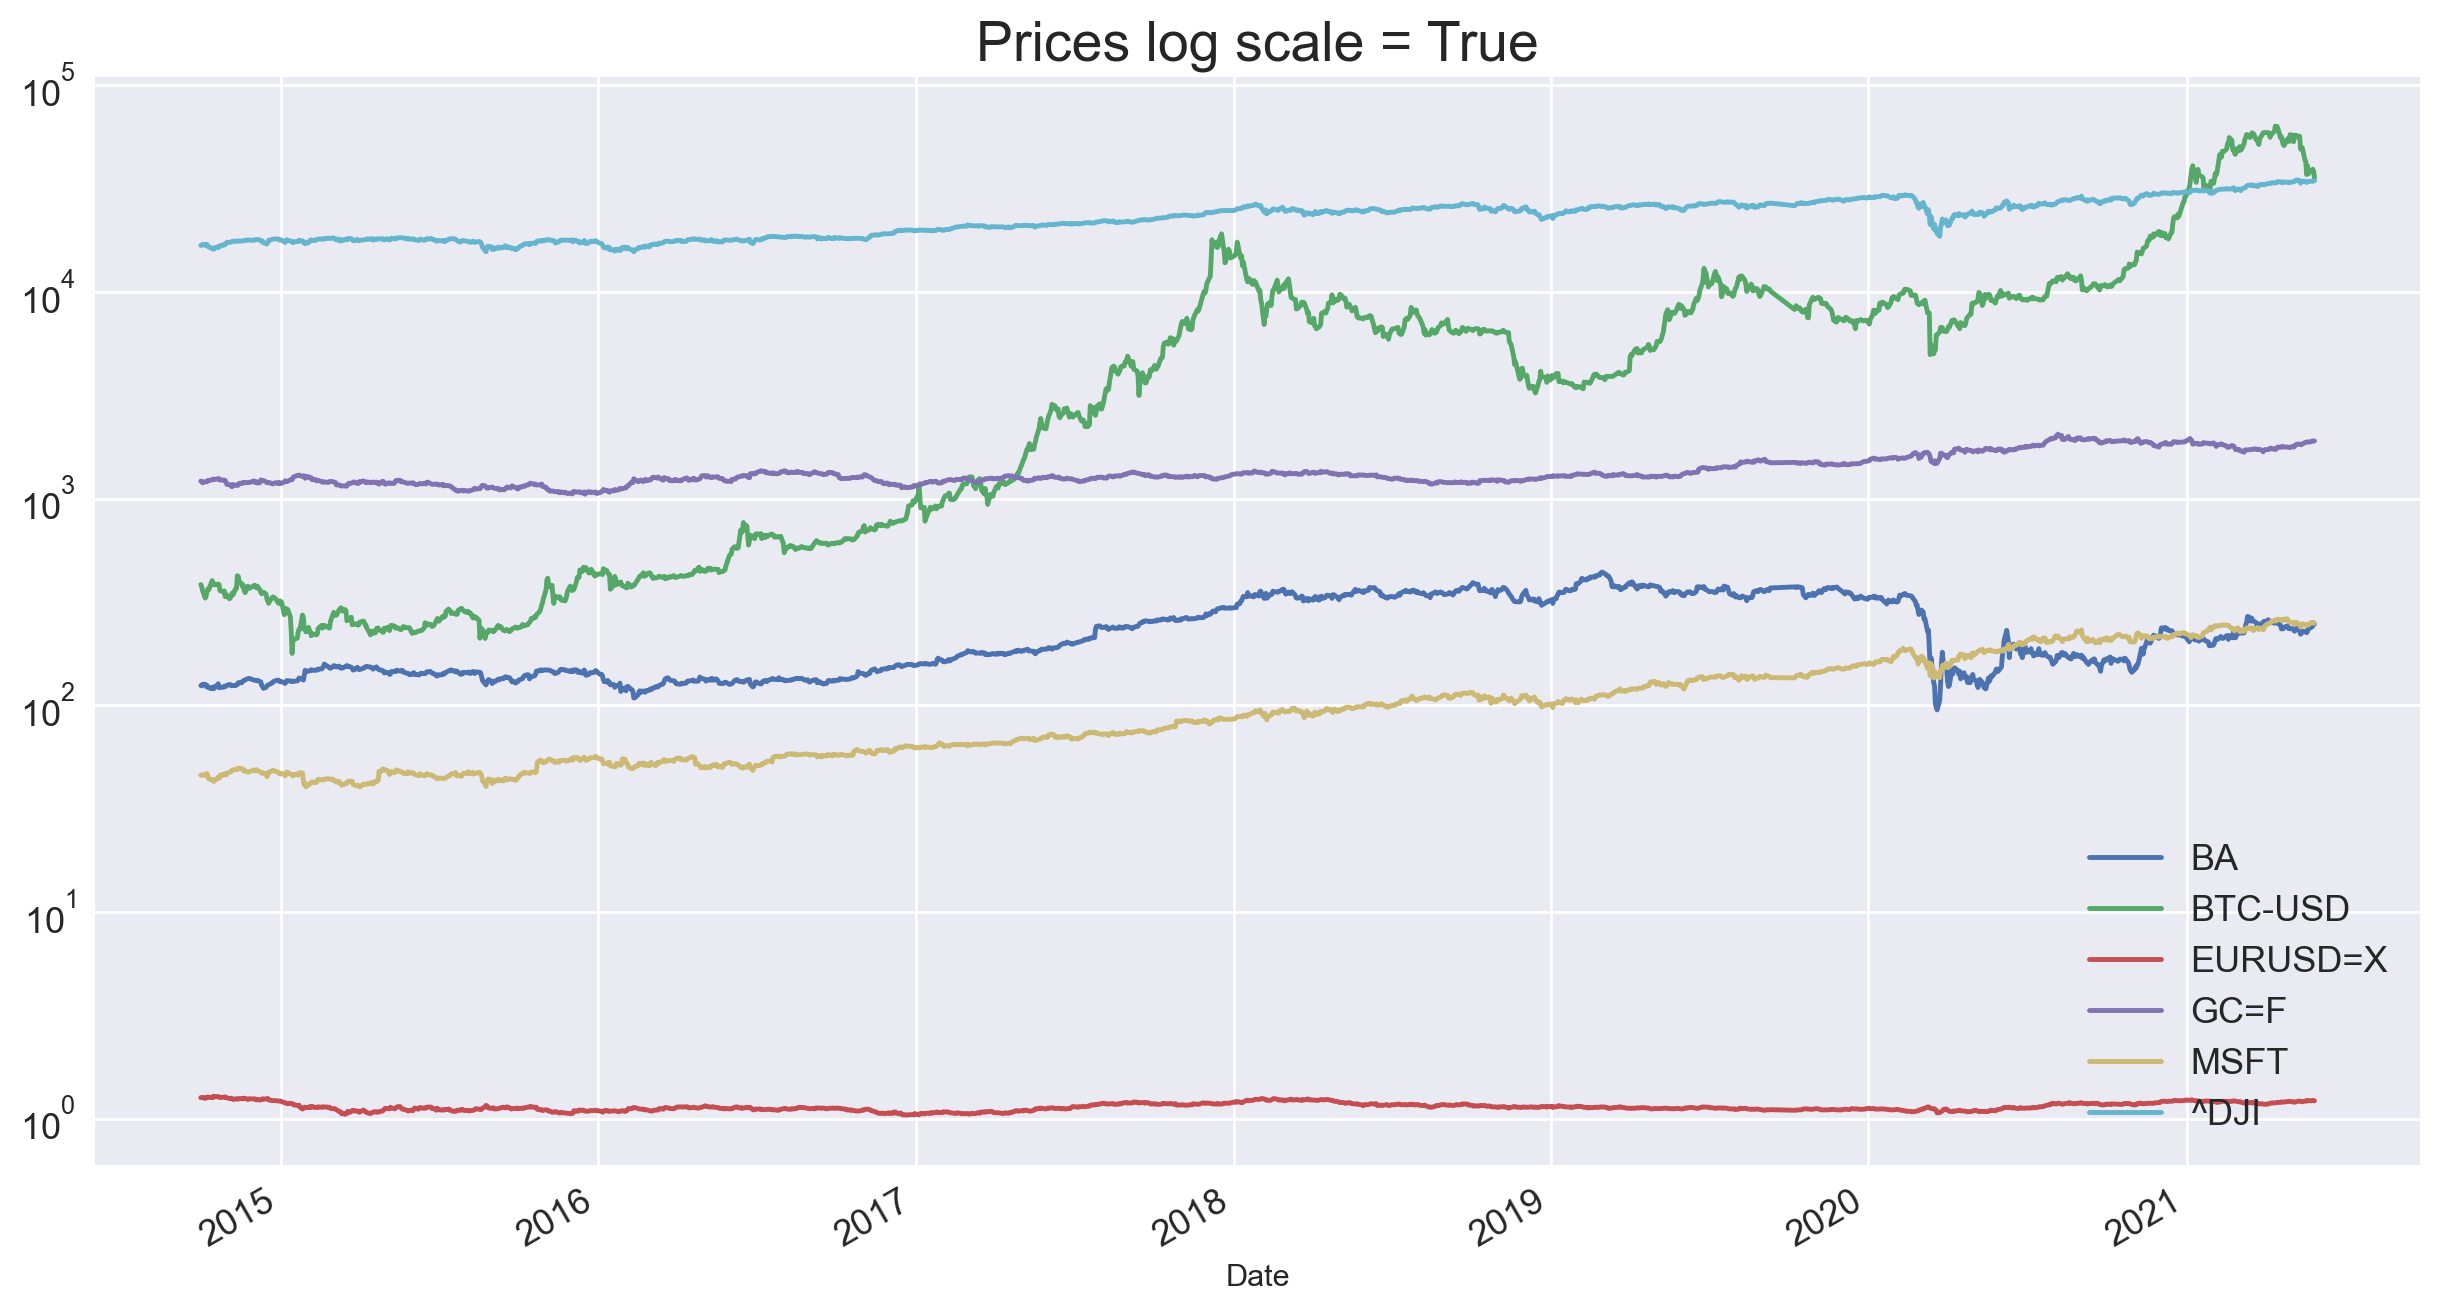

In [ ]:
close.plot(figsize = (15, 8), fontsize = 13 , logy = True)
plt.title("Prices log scale = True", fontsize = 20)
plt.legend(fontsize = 13)
plt.show()

__Take Home: Absolute Prices are absolutely meaningless/useless (in most cases)__ <br>
- Prices that are on a different scale are hard to compare 
- A higher Price does not imply a higher value or a better performance

## Normalizing Financial Time Series to a Base Value (100)

__-> all instruments start at the very same Level (Base Value)__

In [ ]:
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,124.6700,383.6150,1.2628,1214.6000,45.9000,16804.7109
2014-10-02,124.1700,375.0720,1.2624,1214.2000,45.7600,16801.0508
2014-10-03,126.3600,359.5120,1.2671,1192.2000,46.0900,17009.6895
2014-10-06,126.2600,330.0790,1.2514,1206.7000,46.0900,16991.9102
2014-10-07,123.3200,336.1870,1.2646,1211.7000,45.5300,16719.3906
...,...,...,...,...,...,...
2021-05-24,237.4400,38705.9805,1.2183,1884.6000,250.7800,34393.9805
2021-05-25,240.7400,38402.2227,1.2215,1898.1000,251.7200,34312.4609
2021-05-26,241.3700,39294.1992,1.2249,1901.3000,251.4900,34323.0508


In [ ]:
close.iloc[0,0] # first price BA

np.float64(124.66999816894533)

In [ ]:
close.BA.div(close.iloc[0,0]).mul(100)

Date
2014-10-01   100.0000
2014-10-02    99.5989
2014-10-03   101.3556
2014-10-06   101.2754
2014-10-07    98.9171
               ...   
2021-05-24   190.4548
2021-05-25   193.1018
2021-05-26   193.6071
2021-05-27   201.0909
2021-05-28   198.1391
Name: BA, Length: 1635, dtype: float64

In [ ]:
close.iloc[0] # first Price all tickers

BA           124.6700
BTC-USD      383.6150
EURUSD=X       1.2628
GC=F        1214.6000
MSFT          45.9000
^DJI       16804.7109
Name: 2014-10-01 00:00:00, dtype: float64

In [ ]:
norm = close.div(close.iloc[0]).mul(100)
norm

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000
2014-10-02,99.5989,97.7730,99.9672,99.9671,99.6950,99.9782
2014-10-03,101.3556,93.7169,100.3345,98.1558,100.4139,101.2198
2014-10-06,101.2754,86.0443,99.0915,99.3496,100.4139,101.1140
2014-10-07,98.9171,87.6366,100.1404,99.7612,99.1939,99.4923
...,...,...,...,...,...,...
2021-05-24,190.4548,10089.7987,96.4754,155.1622,546.3616,204.6687
2021-05-25,193.1018,10010.6158,96.7240,156.2737,548.4096,204.1836
2021-05-26,193.6071,10243.1344,96.9969,156.5371,547.9085,204.2466


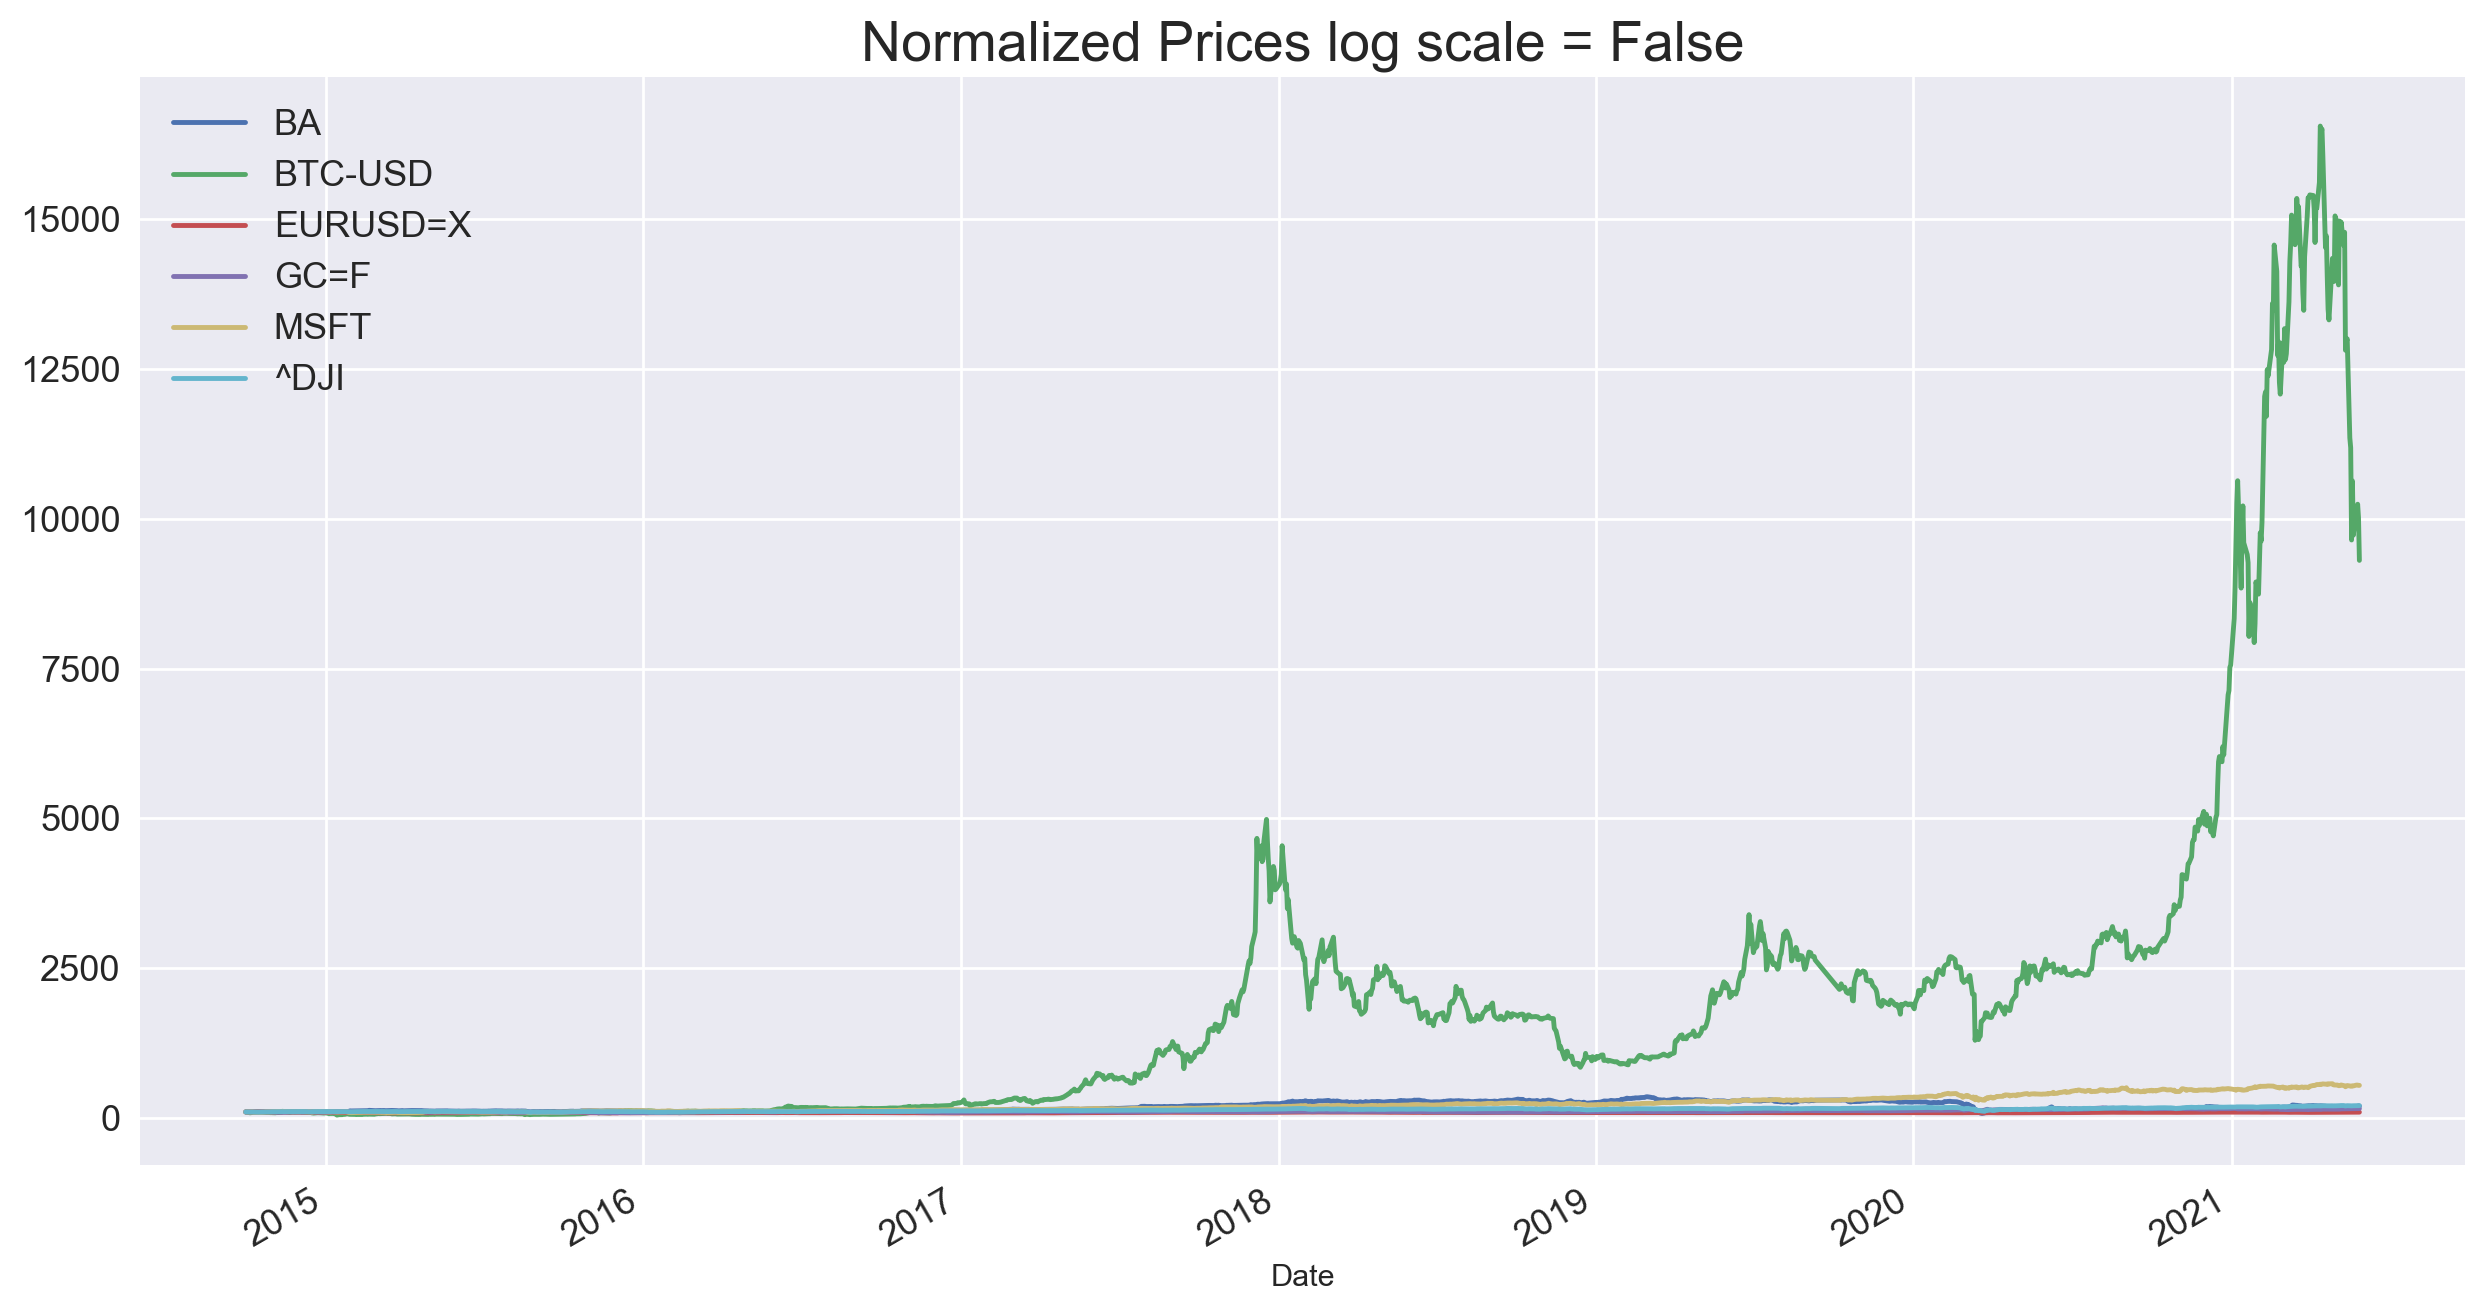

In [ ]:
norm.dropna().plot(figsize = (15, 8), fontsize = 13, logy = False)
plt.title("Normalized Prices log scale = False", fontsize = 20)
plt.legend(fontsize = 13)
plt.show()

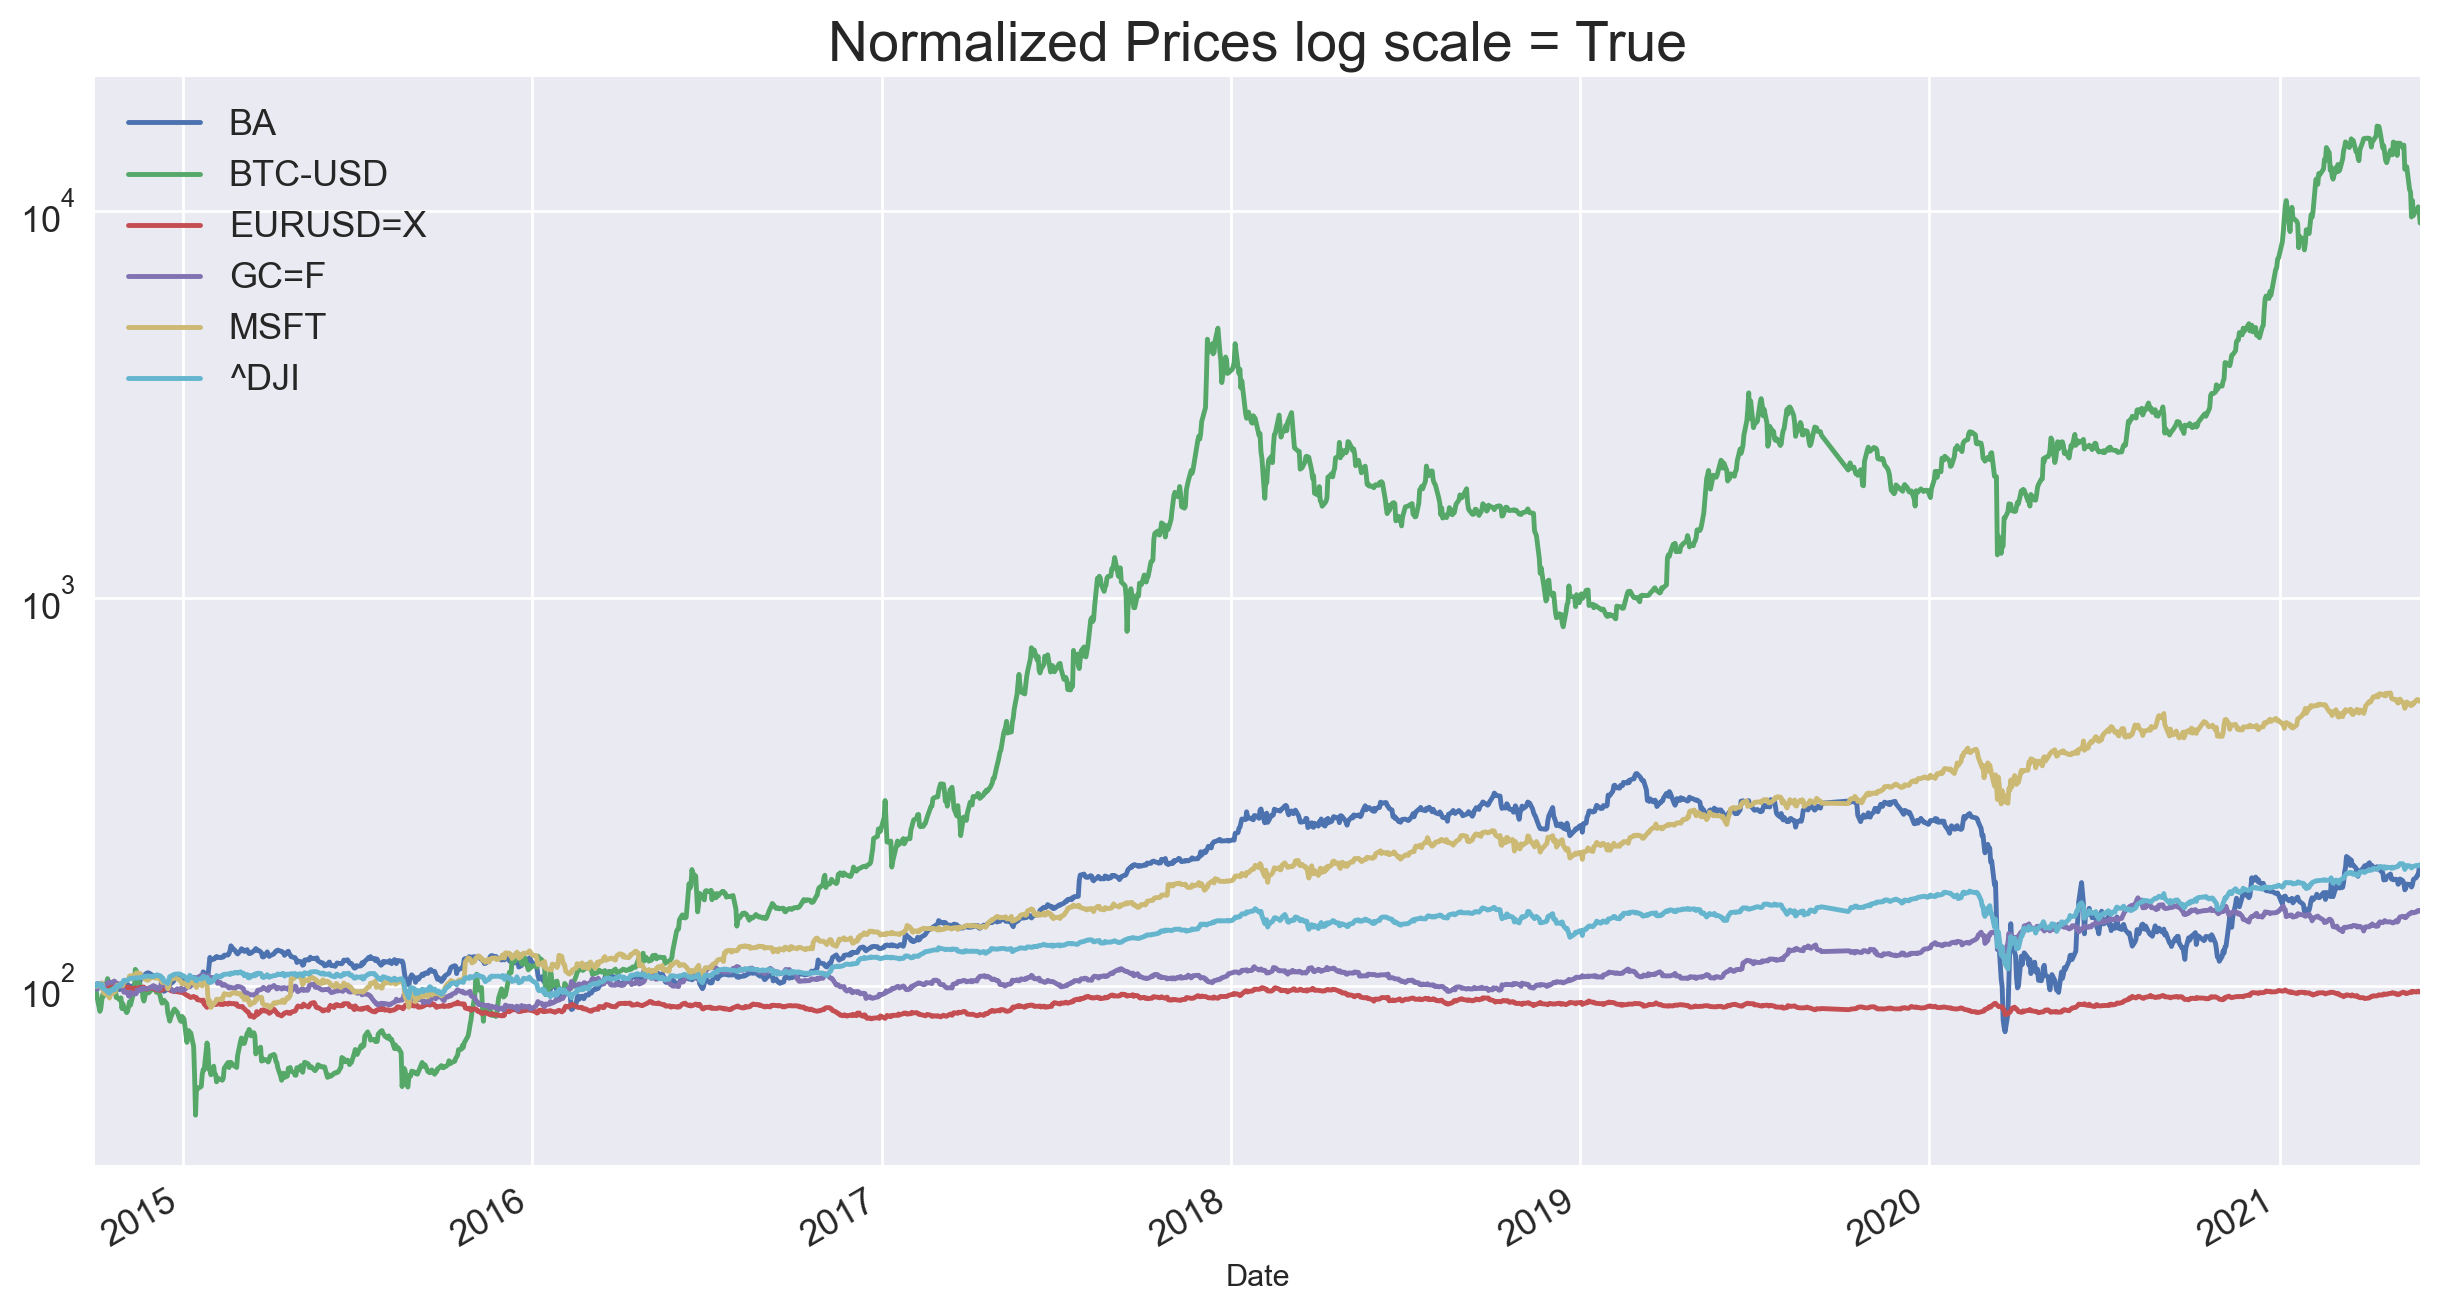

In [ ]:
norm.dropna().plot(figsize = (15, 8), fontsize = 13, logy = True)
plt.title("Normalized Prices log scale = True", fontsize = 20)
plt.legend(fontsize = 13)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

__Take Home: Normalized Prices help to compare Financial Instruments...<br>
...but they are limited when it comes to measuring/comparing Performance in more detail.__

In [ ]:
close.to_csv("close.csv")

---------------------------------------------

__Coding Challenge #1__

1. Load Stock Price Data for General Electric (GE) and another ticker symbol of your choice from 2015-01-02 until 2020-12-31.<br>
Go to https://finance.yahoo.com/ and get the right ticker symbol. For instruments traded outside the US, you have to add a country/exchange suffix. <br>
Check the suffix list here https://help.yahoo.com/kb/exchanges-data-providers-yahoo-finance-sln2310.html As an example, the suffix for the National Indian Stock Exchange is .NS -> Ticker Symbol for Reliance is Reliance.NS

2. Select Close prices only and create a price chart for GE.

3. Normalize the stock prices for GE and the Ticker Symbol of your choice (Base Value: 1) and visualize! What´s the final normalized price for GE on 2020-12-30? 

_You can find the solution for the Coding Challenges at the end of this notebook_.

-----------------------------------------------------

In [ ]:
import yfinance as yf

In [ ]:
tickers = ["GE" , "Reliance.NS"]
start_date = "2015-01-02"
end_date = "2020-12-31"

In [ ]:
df = yf.download(tickers, start = start_date, end = end_date , multi_level_index = False)

[*********************100%***********************]  2 of 2 completed


In [ ]:
df

Price         Close                 High                  Low              \
Ticker           GE RELIANCE.NS       GE RELIANCE.NS       GE RELIANCE.NS   
Date                                                                        
2015-01-02 102.3032    188.6248 103.9361    190.8613 101.5275    188.3586   
2015-01-05 100.4253    186.5587 102.0991    189.7644 100.0987    186.1859   
2015-01-06  98.2617    178.0918 100.3028    185.9516  97.6901    177.2185   
2015-01-07  98.3025    181.9684  99.5680    182.9270  97.8943    178.2835   
2015-01-08  99.4864    179.3592  99.5272    183.8003  98.5066    178.9545   
...             ...         ...      ...         ...      ...         ...   
2020-12-23  52.7691    877.3458  53.3522    880.7760  51.6029    866.8746   
2020-12-24  51.7487    900.0486  52.7205    902.1473  51.6029    878.2712   
2020-12-28  51.7001    904.1783  52.3804    910.8131  51.4086    900.5676   
2020-12-29  51.3114    898.1980  52.3318    908.2404  51.2142    894.8129   
2020-12-30  52.0403    900.6578  52.7205    905.9386  51.2628    891.6535   

Price          Open                    Volume                
Ticker           GE RELIANCE.NS            GE   RELIANCE.NS  
Date                                                         
2015-01-02 103.4462    189.1680  8538620.0000  7331366.0000  
2015-01-05 102.0991    188.5077  8770735.0000 10103941.0000  
2015-01-06  99.8538    185.3126 13304295.0000 18627980.0000  
2015-01-07  98.8332    178.3048  9106535.0000 20720312.0000  
2015-01-08  99.2823    183.2039  9019294.0000 19872227.0000  
...             ...         ...           ...           ...  
2020-12-23  51.8945    871.0947 12139419.0000 19501410.0000  
2020-12-24  52.7205    878.7676  6029070.0000 20776988.0000  
2020-12-28  51.9917    905.7129 10793588.0000 17221499.0000  
2020-12-29  51.7973    906.7510 10640944.0000 18611939.0000  
2020-12-30  51.4086    900.5450 10156427.0000 22043630.0000  

[1552 rows x 10 columns]

In [ ]:
df = df.Close.copy()
df

Ticker,GE,RELIANCE.NS
Date,,
2015-01-02,102.3032,188.6248
2015-01-05,100.4253,186.5587
2015-01-06,98.2617,178.0918
2015-01-07,98.3025,181.9684
2015-01-08,99.4864,179.3592
...,...,...
2020-12-23,52.7691,877.3458
2020-12-24,51.7487,900.0486
2020-12-28,51.7001,904.1783


In [ ]:
df_normalized = df.div(df.iloc[0]).mul(1)
df_normalized

Ticker,GE,RELIANCE.NS
Date,,
2015-01-02,1.0000,1.0000
2015-01-05,0.9816,0.9890
2015-01-06,0.9605,0.9442
2015-01-07,0.9609,0.9647
2015-01-08,0.9725,0.9509
...,...,...
2020-12-23,0.5158,4.6513
2020-12-24,0.5058,4.7716
2020-12-28,0.5054,4.7935


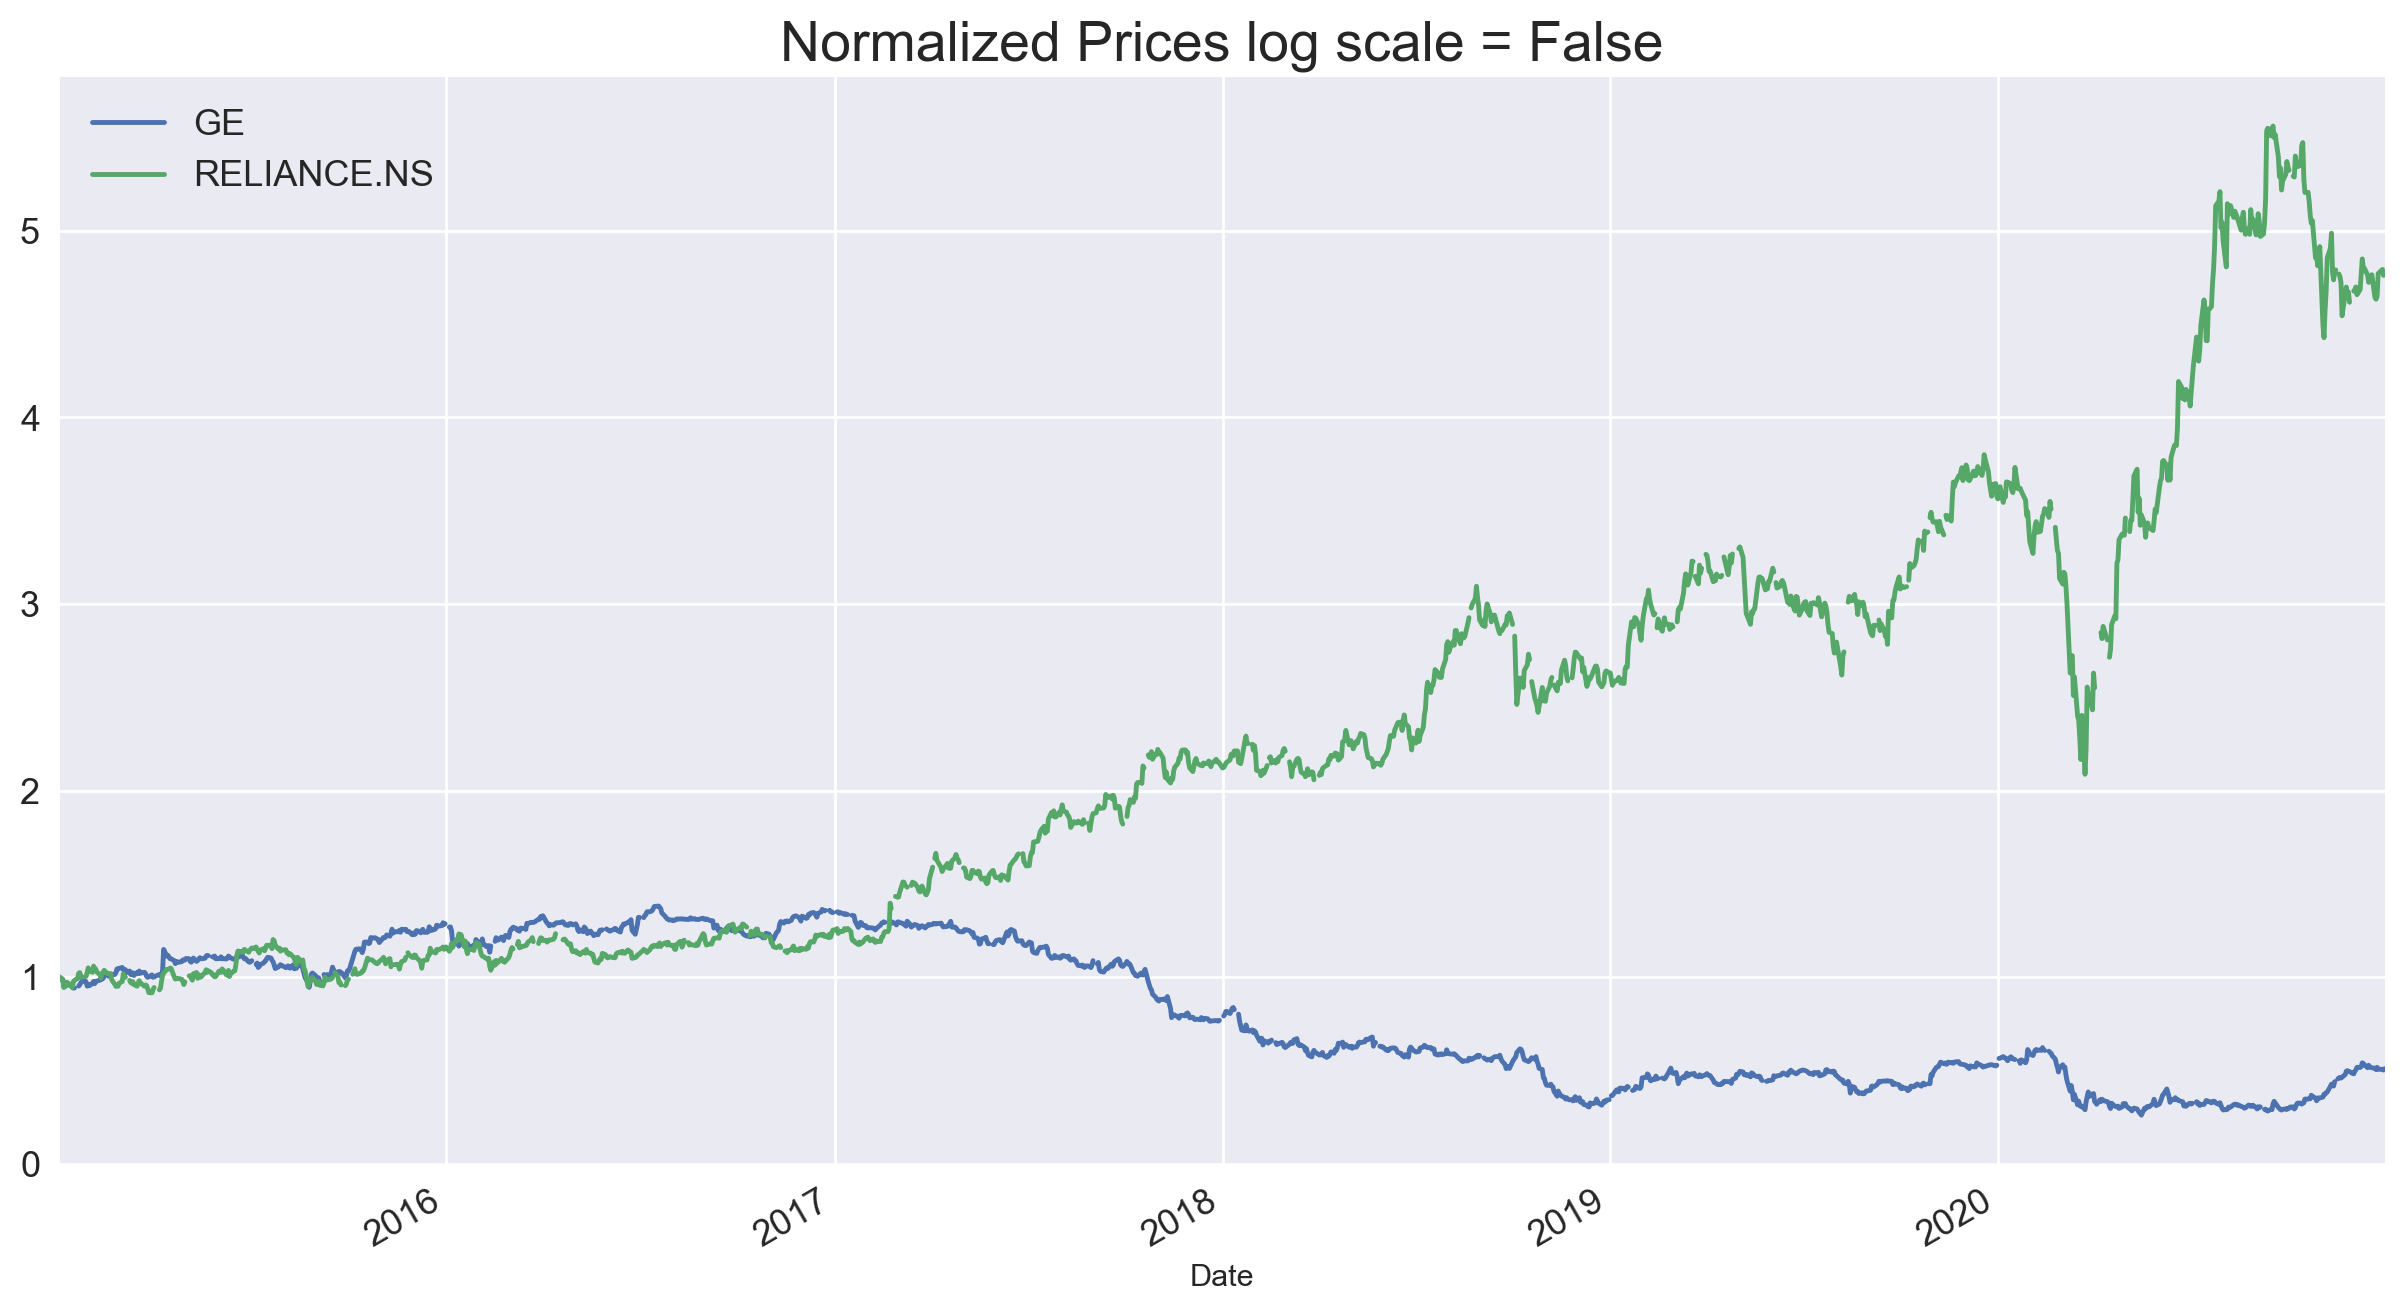

In [ ]:
df_normalized.plot(figsize = (15, 8), fontsize = 13, logy = False)
plt.title("Normalized Prices log scale = False", fontsize = 20)
plt.legend(fontsize = 13)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

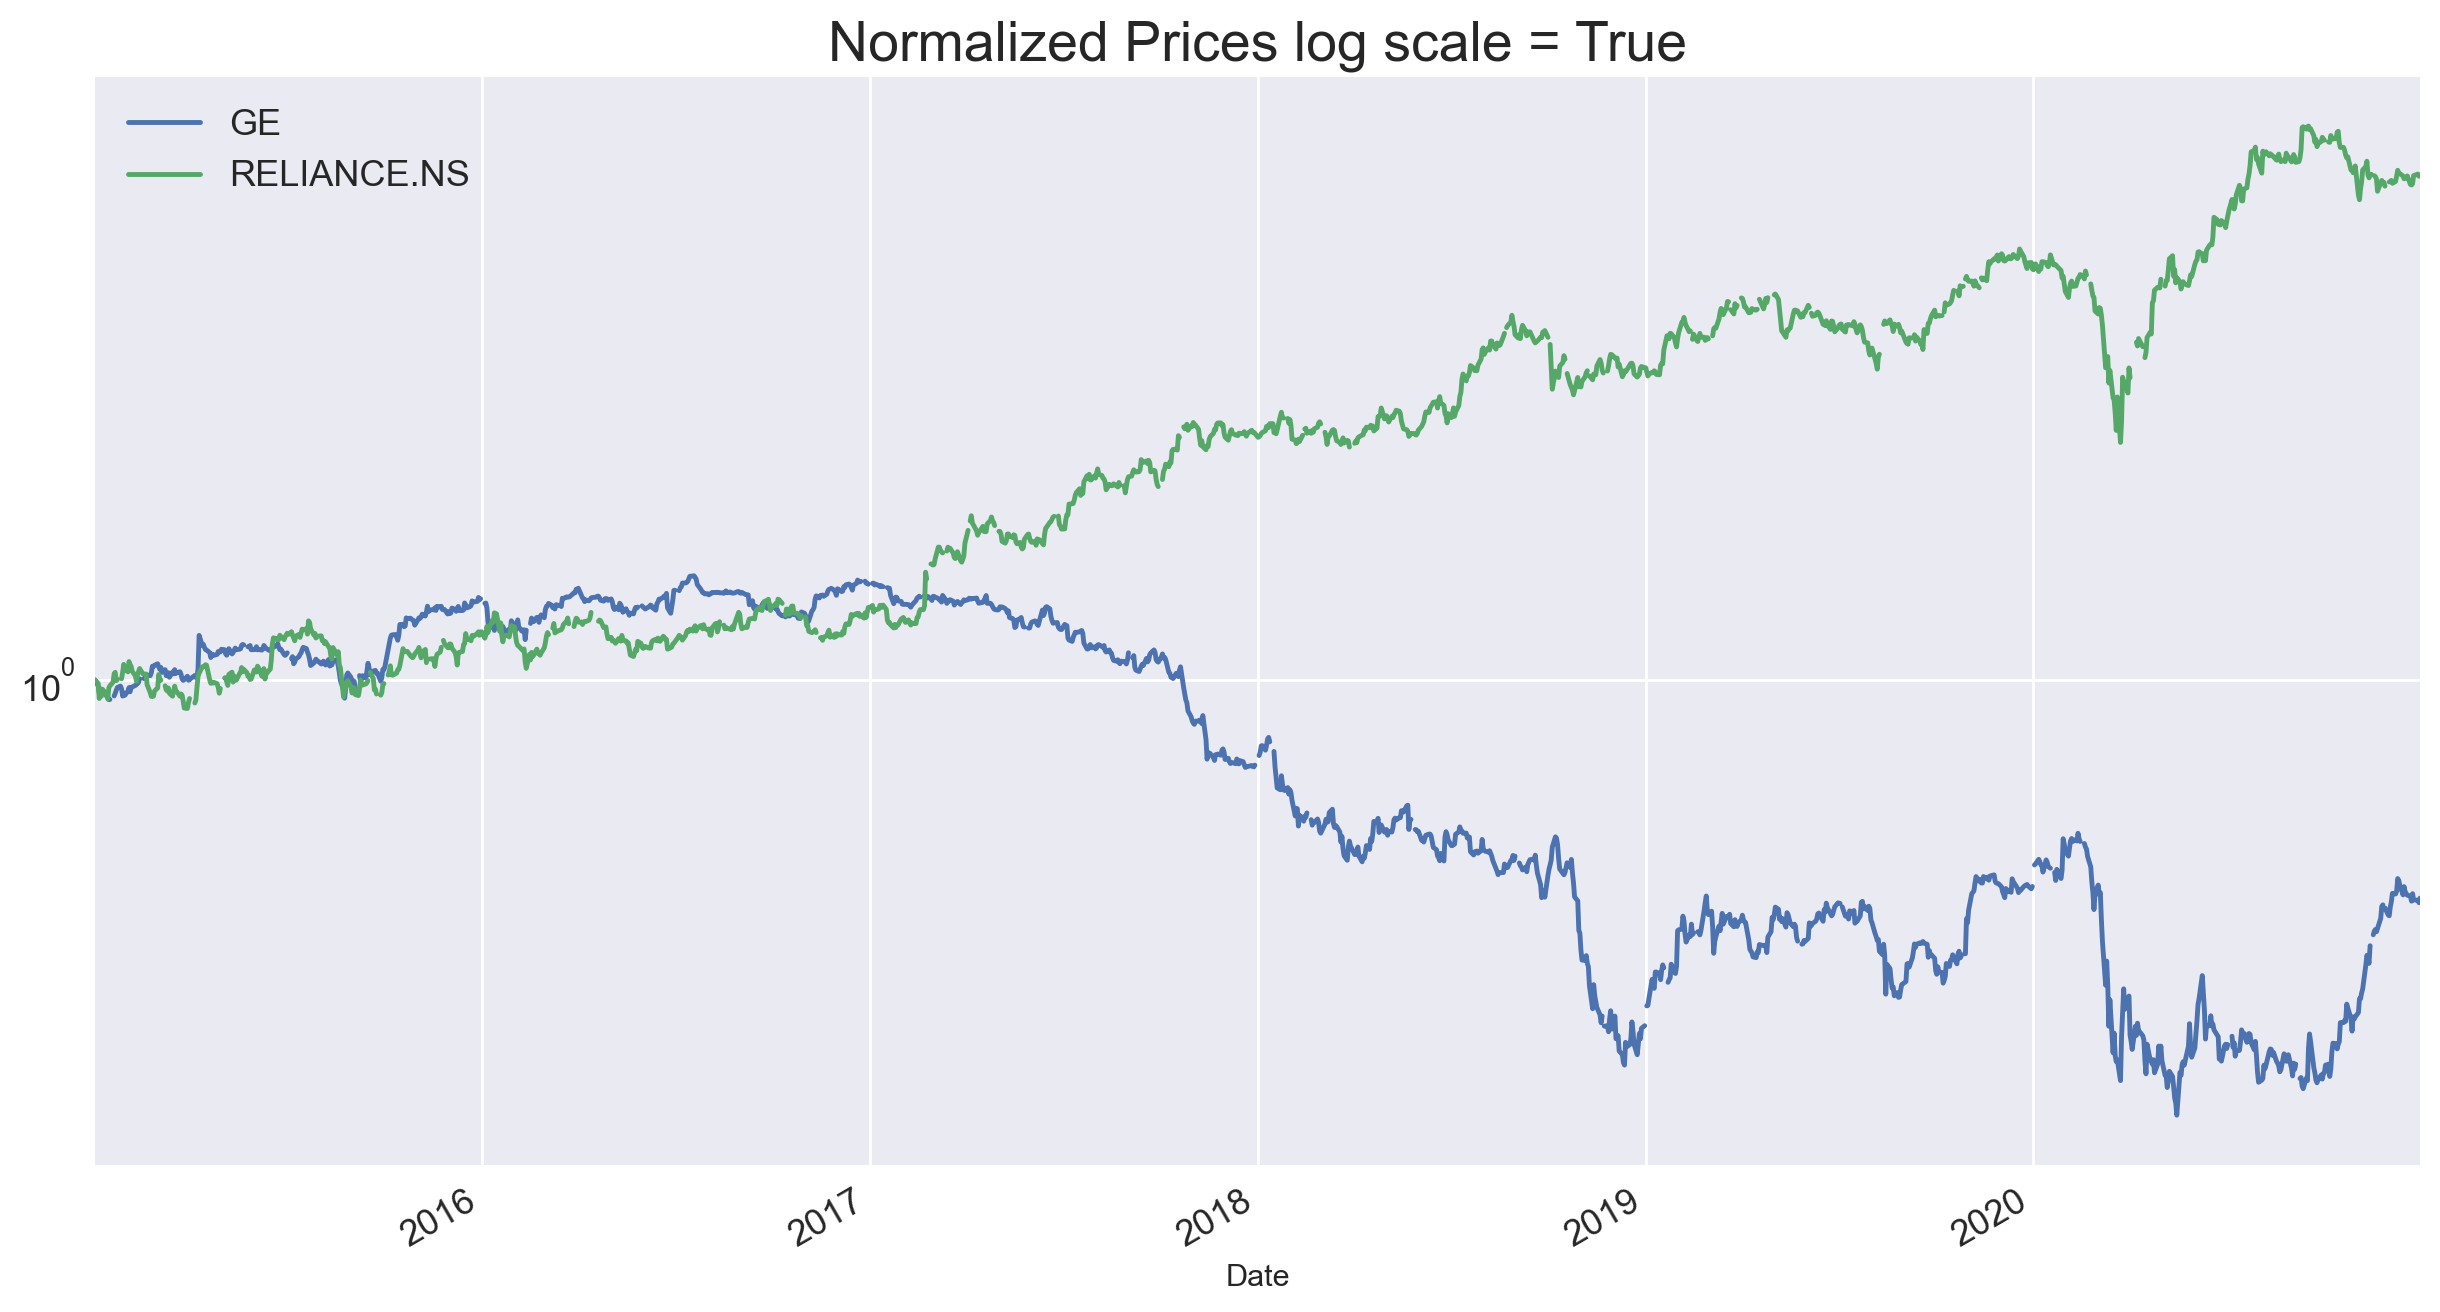

In [ ]:
df_normalized.plot(figsize = (15, 8), fontsize = 13, logy = True)
plt.title("Normalized Prices log scale = True", fontsize = 20)
plt.legend(fontsize = 13)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

In [ ]:
df_normalized.iloc[-1]

Ticker
GE            0.5087
RELIANCE.NS   4.7749
Name: 2020-12-30 00:00:00, dtype: float64

## Price Changes and Financial Returns

__More meaningful/useful than Prices: Price changes__

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.4f}'.format
plt.style.use("seaborn-v0_8")

import seaborn as sns

import datetime as dt
from scipy import stats
%config InlineBackend.figure_format = 'retina'

In [ ]:
close = pd.read_csv("close.csv", index_col = "Date", parse_dates = ["Date"])
close = close.dropna()
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,124.6700,383.6150,1.2628,1214.6000,45.9000,16804.7109
2014-10-02,124.1700,375.0720,1.2624,1214.2000,45.7600,16801.0508
2014-10-03,126.3600,359.5120,1.2671,1192.2000,46.0900,17009.6895
2014-10-06,126.2600,330.0790,1.2514,1206.7000,46.0900,16991.9102
2014-10-07,123.3200,336.1870,1.2646,1211.7000,45.5300,16719.3906
...,...,...,...,...,...,...
2021-05-24,237.4400,38705.9805,1.2183,1884.6000,250.7800,34393.9805
2021-05-25,240.7400,38402.2227,1.2215,1898.1000,251.7200,34312.4609
2021-05-26,241.3700,39294.1992,1.2249,1901.3000,251.4900,34323.0508


In [ ]:
msft = close.MSFT.to_frame().copy()
msft

,MSFT
Date,
2014-10-01,45.9000
2014-10-02,45.7600
2014-10-03,46.0900
2014-10-06,46.0900
2014-10-07,45.5300
...,...
2021-05-24,250.7800
2021-05-25,251.7200
2021-05-26,251.4900


In [ ]:
msft.rename(columns = {"MSFT":"Price_t"}, inplace = True)
msft

,Price_t
Date,
2014-10-01,45.9000
2014-10-02,45.7600
2014-10-03,46.0900
2014-10-06,46.0900
2014-10-07,45.5300
...,...
2021-05-24,250.7800
2021-05-25,251.7200
2021-05-26,251.4900


We see that the $\text{Price}_{t}$ is non-stationary in terms of its mean :$\mu$ and its risk: $\sigma$, look at its plot:
We can't see a constants risk: $\sigma$ and a constant mean :$\mu$

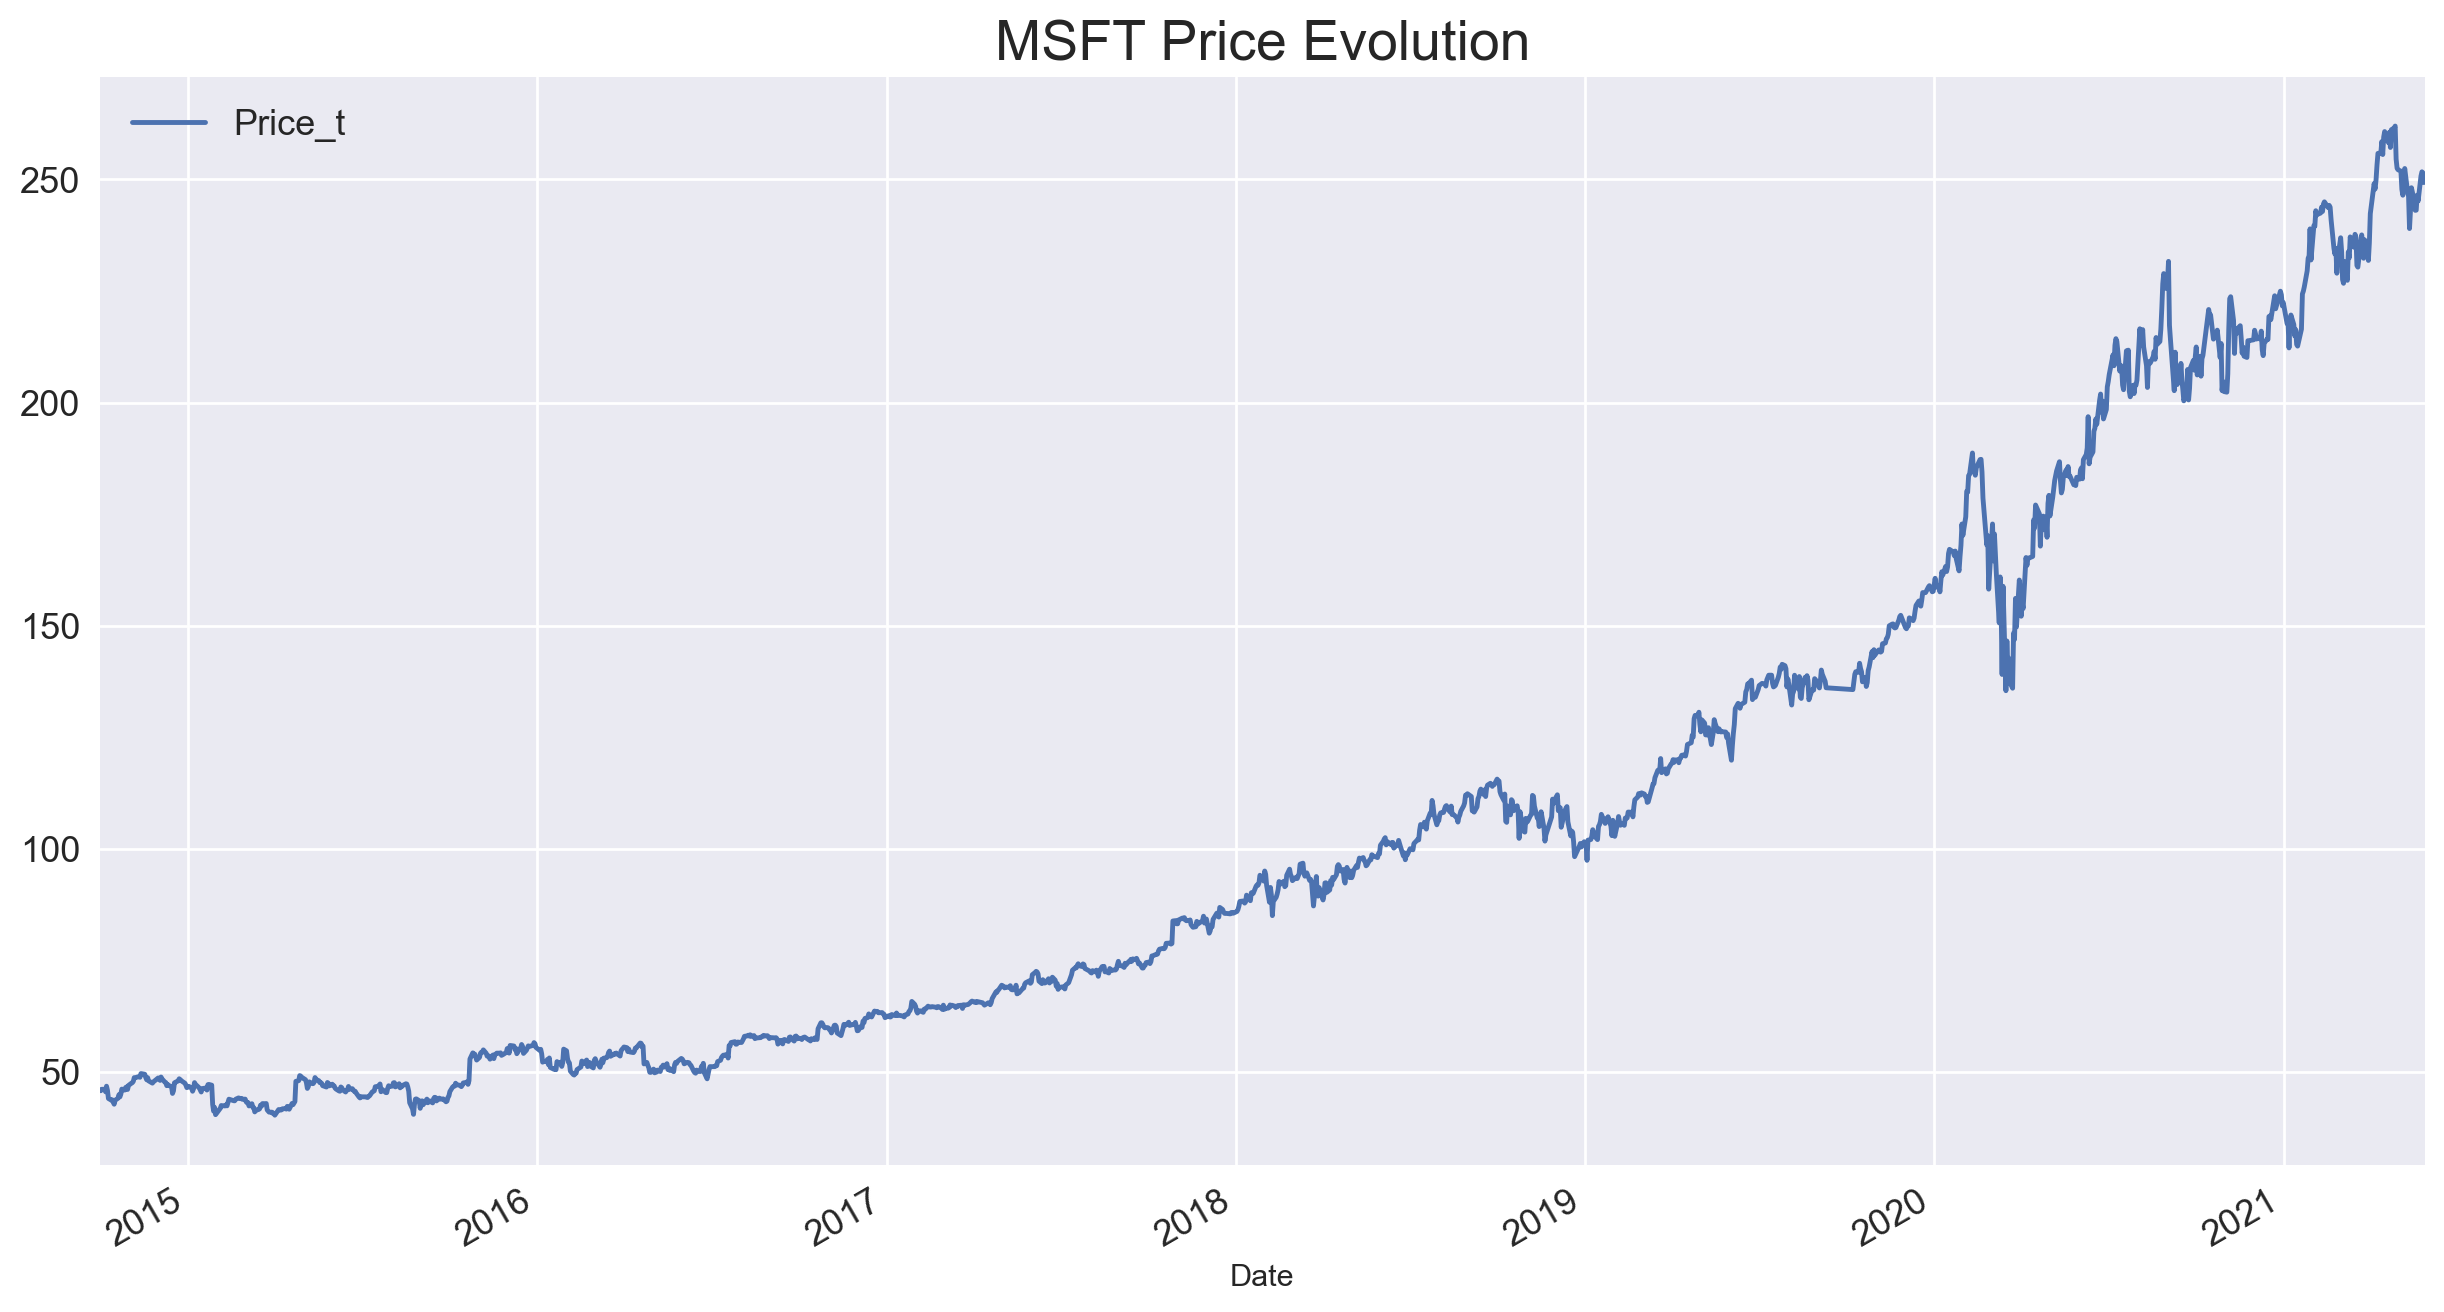

In [ ]:
msft.plot(figsize = (15, 8), fontsize = 13)
plt.title("MSFT Price Evolution", fontsize = 20)
plt.legend(fontsize = 13)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

The first approach to see if a time series is stationary or not is the `ADFULLER test`:

### Augmented Dickey-Fuller test:

In [ ]:
def adf_test(series, signif=0.05, name='', verbose=False):
    """
    Perform Augmented Dickey-Fuller test:
    H0(null): Series is not stationary & has a unit root
    H1(alt): Series is stationary & has no unit root
    :param series: Time series
    :param signif: Significance Level, default: 0.05
    :param name: Name of time series
    :param verbose: Print summary
    :return: ADF report
    """
    from statsmodels.tsa.stattools import adfuller

    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    out = pd.Series(result[0:4], index=labels)

    print(f'Augmented Dickey-Fuller Test on "{name}"', "\n" + "-"*25)

    for key, val in result[4].items():
        out[f'Critical Value ({key})'] = val


    print(out.to_string() , "ADF Test Conclusion: ", sep = "\n" + "*"*25 + "\n" + "*"*25 + "\n")

    if result[1] <= signif: # 0.005 = 0.01/2 < 0.025 = 0.05/2 < 0.05 = 0.1/2
        print("Strong evidence against the null hypothesis(Ho).")
        print("Reject the null hypothesis.")
        print("Data has no unit root and is stationary.")
    else: # result[1] > signif = 0.05 = 0.1/2 > 0.025 = 0.05/2 > 0.005 = 0.01/2
        print("Weak evidence against null hypothesis.")
        print("Time series has a unit root.")
        print("indicating it is non-stationary.")

In [ ]:
adf_test(msft["Price_t"], name = "MSFT Price (2014-2021)", verbose = True)

Augmented Dickey-Fuller Test on "MSFT Price (2014-2021)" 
-------------------------
ADF Test Statistic               2.6327
p-value                          0.9991
#Lags Used                      25.0000
Number of Observations Used   1609.0000
Critical Value (1%)             -3.4344
Critical Value (5%)             -2.8633
Critical Value (10%)            -2.5677
*************************
*************************
ADF Test Conclusion: 
Weak evidence against null hypothesis.
Time series has a unit root.
indicating it is non-stationary.


The second apprach is to plot_acf and plot_pacf functions from statsmodels to visualize the autocorrelation and partial autocorrelation of the time series data.<br> This can help in identifying the order of AR and MA components for ARIMA modeling.

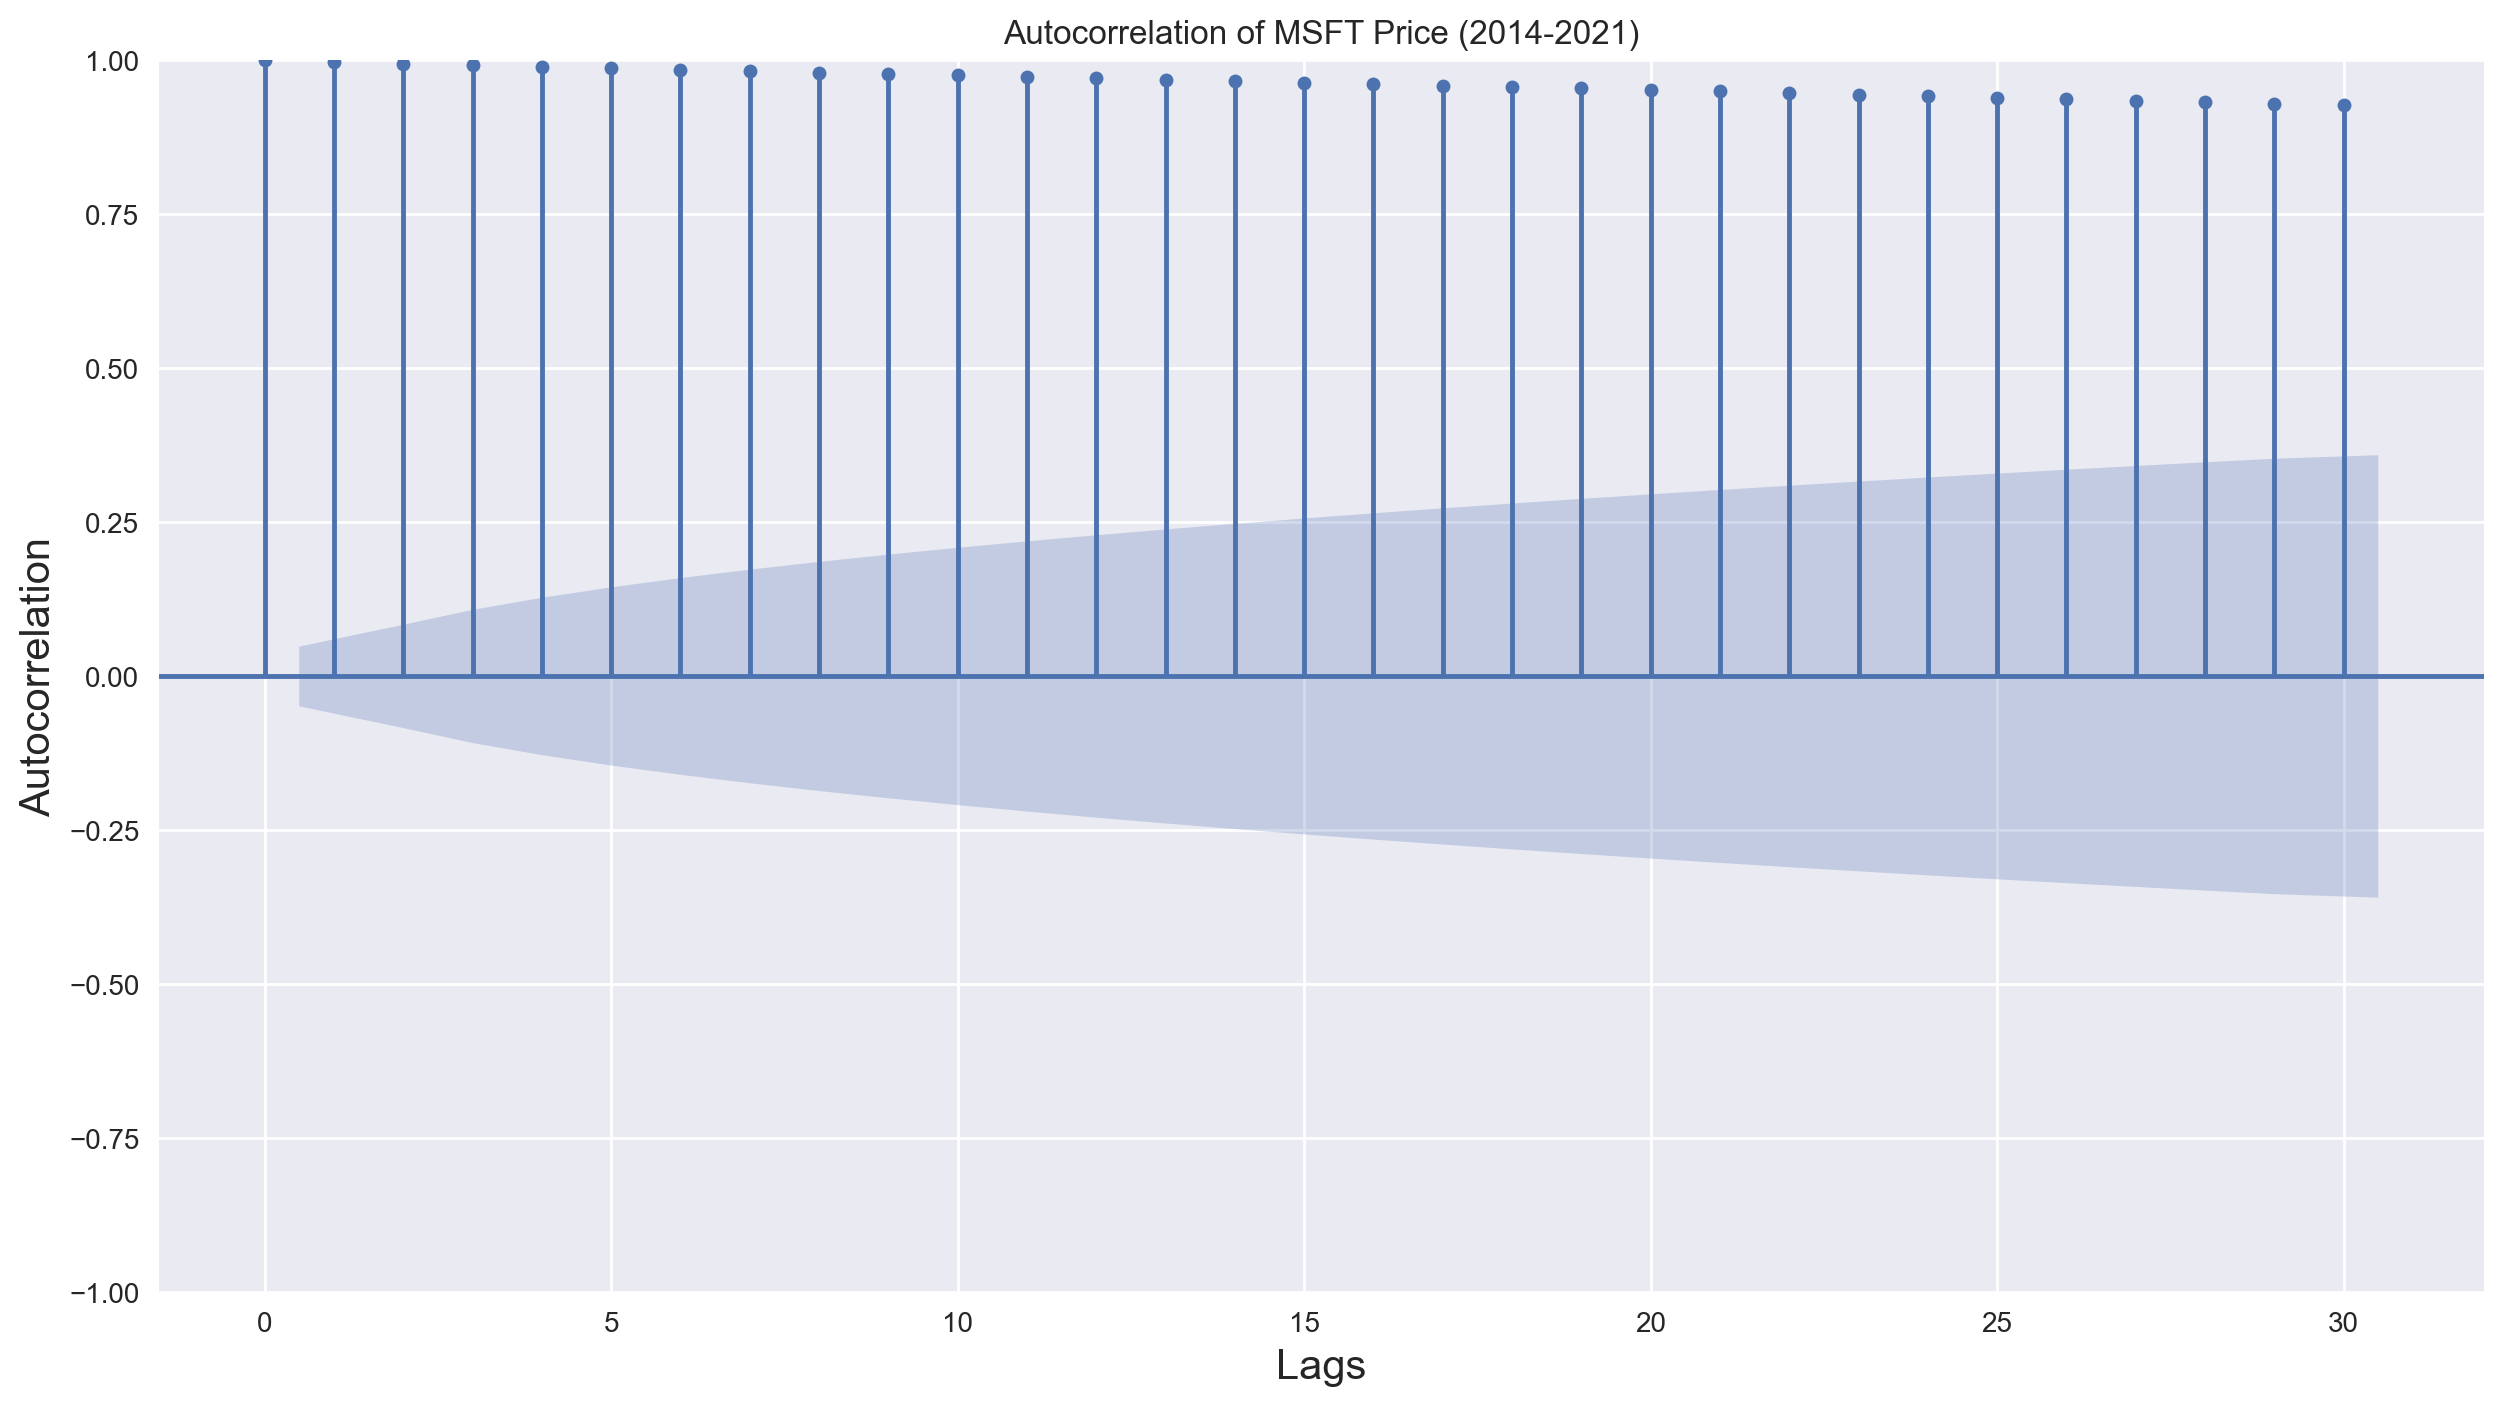

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
title = "Autocorrelation of MSFT Price (2014-2021)"
lags = 30
fig , ax = plt.subplots(figsize = (15, 8))
plot_acf(msft["Price_t"], lags = lags, title = title , ax = ax)
plt.ylabel("Autocorrelation", fontsize = 15)
plt.xlabel("Lags", fontsize = 15)
plt.show()

The autocorrelation plot indicates that the MSFT stock price series is highly `non-stationary` and exhibits a strong trend, meaning it cannot be used for direct forecasting without preprocessing.
## Key Observations

* `High, Persistent Autocorrelation`: The autocorrelation values start near 1.0 and decrease very slowly across all 30 lags.
* `Significant Above Confidence Intervals`: Every single lag falls well outside the shaded light-blue confidence interval band.

## Practical Conclusions

* Presence of a Trend: This slow, linear decay is a textbook signature of a strong underlying trend (upward or downward) in the raw price data.
* `Non-Stationarity: The series does not have a constant mean or variance over time.`
* Required Next Step: We must differencing the data (e.g., computing daily returns instead of raw prices) by using `diff()` method to make the time series stationary before applying forecasting models like ARIMA. 


## Calculating Price Changes in Pandas:
You can calculate the difference between the current price $\text{Price}_{t}$ and the previous price $\text{Price}_{t-1}$ using two distinct methods:
- Manual Calculation: Create a lagged price column using the `shift()` method, then subtract `.sub()` it from the original price.
- Automated Calculation: Apply the `diff()` method directly to the price column to find the difference in a single step.

In [ ]:
msft.shift(periods = 1)

,Price_t
Date,
2014-10-01,NaN
2014-10-02,45.9000
2014-10-03,45.7600
2014-10-06,46.0900
2014-10-07,46.0900
...,...
2021-05-24,245.1700
2021-05-25,250.7800
2021-05-26,251.7200


Now, we create a new column named as $\text{Price}_{t-1}$ known as lag1 which follows the formula: <br>
`msft.shift(periods = 1)` <br>
Indeed, the $\text{Price}_{t-1}$ column is the lagged version of the $\text{Price}_{t}$ column. <br>
The first row of the $\text{Price}_{t-1}$ column is NaN because there is no previous price for the first date in the dataset. <br>


In [ ]:
msft["Price_t-1"] = msft.shift(periods = 1)
msft

,Price_t,Price_t-1
Date,,
2014-10-01,45.9000,NaN
2014-10-02,45.7600,45.9000
2014-10-03,46.0900,45.7600
2014-10-06,46.0900,46.0900
2014-10-07,45.5300,46.0900
...,...,...
2021-05-24,250.7800,245.1700
2021-05-25,251.7200,250.7800
2021-05-26,251.4900,251.7200


__Absolute Price Changes__ (Difference)

In [ ]:
msft["Price_Change_manual"] = msft["Price_t"].sub(msft["Price_t-1"]) # Alternative 1
msft

,Price_t,Price_t-1,Price_Change_manual
Date,,,
2014-10-01,45.9000,NaN,NaN
2014-10-02,45.7600,45.9000,-0.1400
2014-10-03,46.0900,45.7600,0.3300
2014-10-06,46.0900,46.0900,0.0000
2014-10-07,45.5300,46.0900,-0.5600
...,...,...,...
2021-05-24,250.7800,245.1700,5.6100
2021-05-25,251.7200,250.7800,0.9400
2021-05-26,251.4900,251.7200,-0.2300


In [ ]:
msft["Price_Change_method"] = msft["Price_t"].diff(periods = 1)  # Alternative 2
msft

,Price_t,Price_t-1,Price_Change_manual,Price_Change_method
Date,,,,
2014-10-01,45.9000,NaN,NaN,NaN
2014-10-02,45.7600,45.9000,-0.1400,-0.1400
2014-10-03,46.0900,45.7600,0.3300,0.3300
2014-10-06,46.0900,46.0900,0.0000,0.0000
2014-10-07,45.5300,46.0900,-0.5600,-0.5600
...,...,...,...,...
2021-05-24,250.7800,245.1700,5.6100,5.6100
2021-05-25,251.7200,250.7800,0.9400,0.9400
2021-05-26,251.4900,251.7200,-0.2300,-0.2300


In [ ]:
msft.Price_Change_manual.equals(msft.Price_Change_method)

True

### Now let's check the Dickey-Fuller test on the first difference of the MSFT price series to see if it is stationary:

In [ ]:
adf_test(msft["Price_Change_method"], 
         name = "MSFT Price Differences (2014-2021)", 
         verbose = True)

Augmented Dickey-Fuller Test on "MSFT Price Differences (2014-2021)" 
-------------------------
ADF Test Statistic             -10.7490
p-value                          0.0000
#Lags Used                      25.0000
Number of Observations Used   1608.0000
Critical Value (1%)             -3.4344
Critical Value (5%)             -2.8633
Critical Value (10%)            -2.5677
*************************
*************************
ADF Test Conclusion: 
Strong evidence against the null hypothesis(Ho).
Reject the null hypothesis.
Data has no unit root and is stationary.


In [ ]:
msft["Price_Change_method"].value_counts(dropna = False , 
                                         ascending = True)

Price_Change_method
NaN         1
-3.8400     1
3.3200      1
2.6700      1
1.9900      1
           ..
0.5000      8
-0.1100     8
-0.5000     9
-0.1000     9
0.0000     15
Name: count, Length: 1146, dtype: int64

Since there is at least one row with `NaN` value. So it will cause an empty act plot:

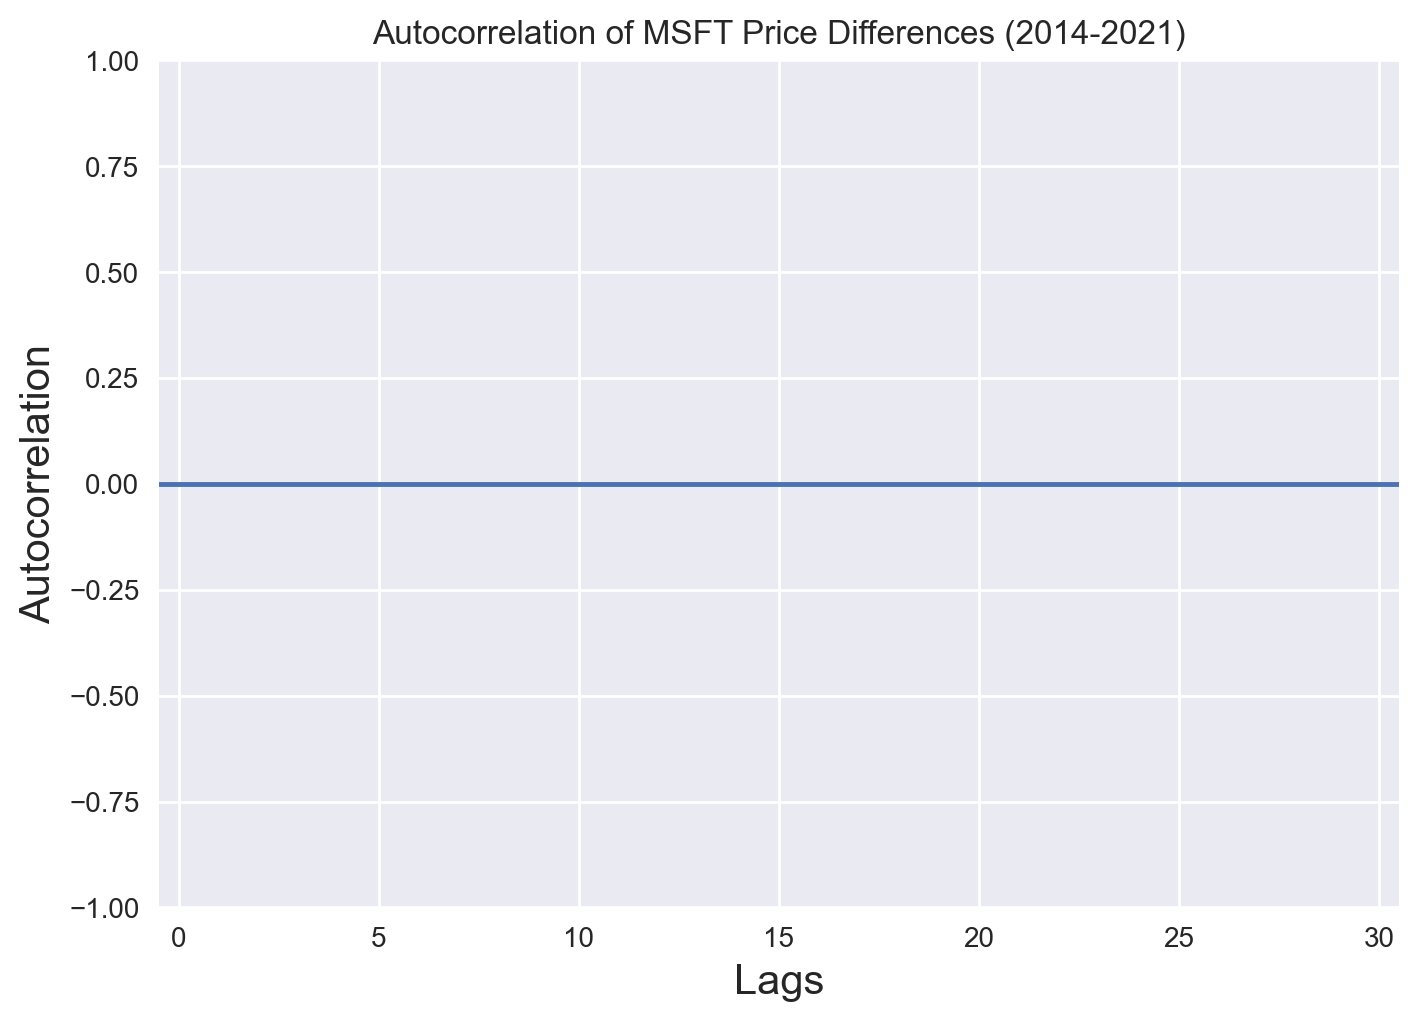

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
title = "Autocorrelation of MSFT Price Differences (2014-2021)"
lags = 30
#fig , ax = plt.subplots(figsize = (15, 6))
plot_acf(msft["Price_Change_method"], lags = lags, title = title)
plt.ylabel("Autocorrelation", fontsize = 15)
plt.xlabel("Lags", fontsize = 15)
#plt.xticks(range(0, lags + 1))
plt.xlim(-0.5, lags + 0.5)
plt.show()

It is better to apply `dropna()` method on it:

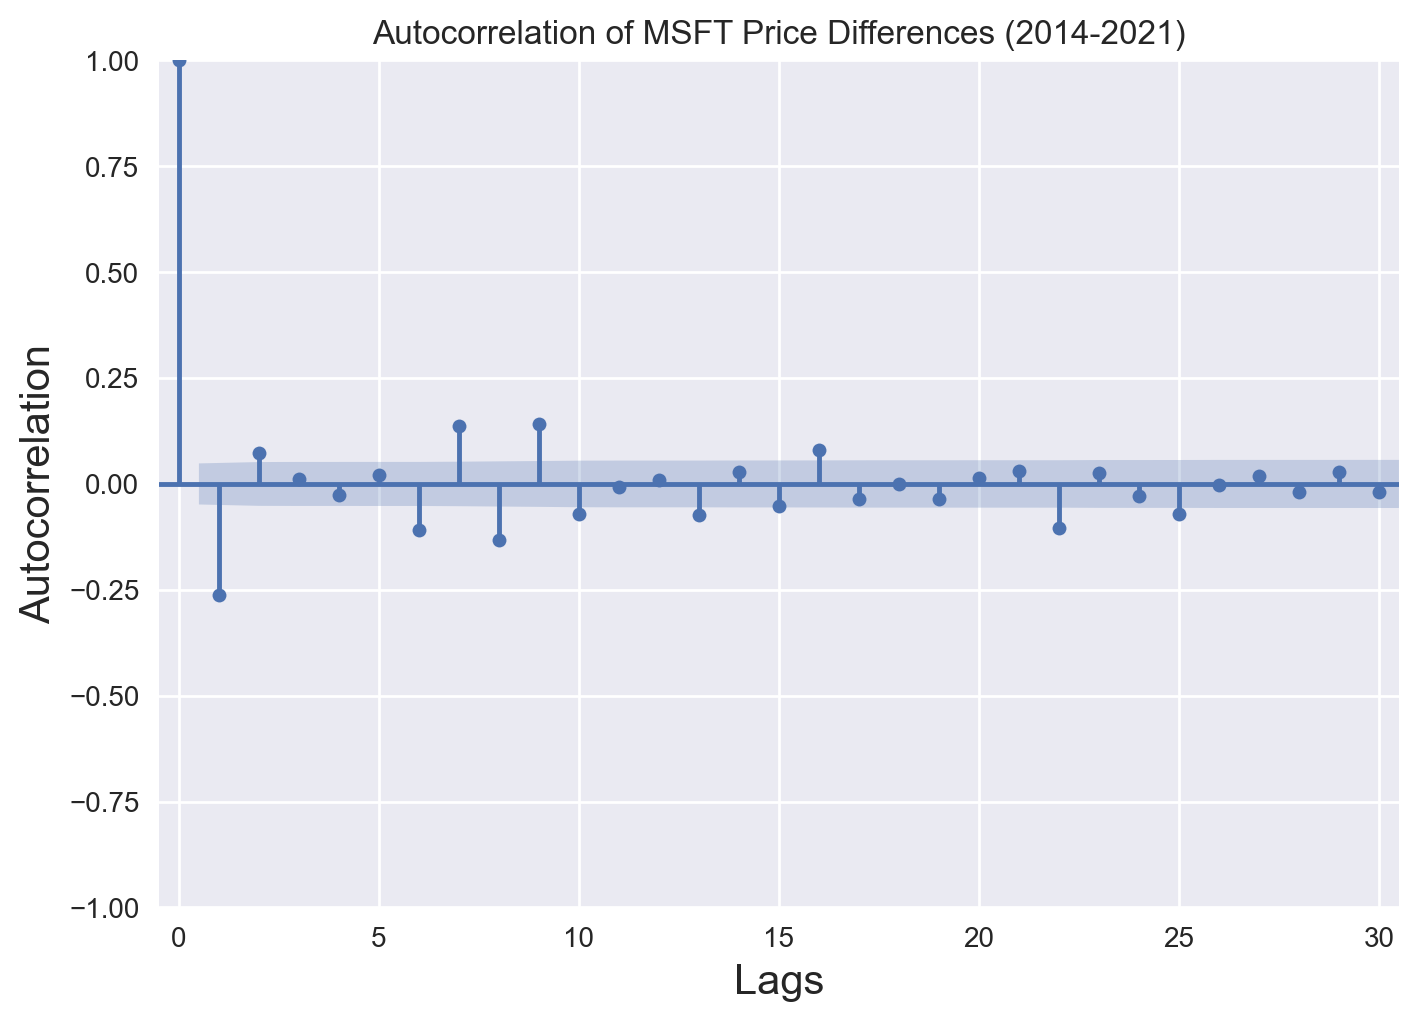

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
title = "Autocorrelation of MSFT Price Differences (2014-2021)"
lags = 30
#fig , ax = plt.subplots(figsize = (15, 6))
plot_acf(msft["Price_Change_method"].dropna(), lags = lags, title = title , use_vlines = True)
plt.ylabel("Autocorrelation", fontsize = 15)
plt.xlabel("Lags", fontsize = 15)
#plt.xticks(range(0, lags + 1))
plt.xlim(-0.5, lags + 0.5)
plt.show()

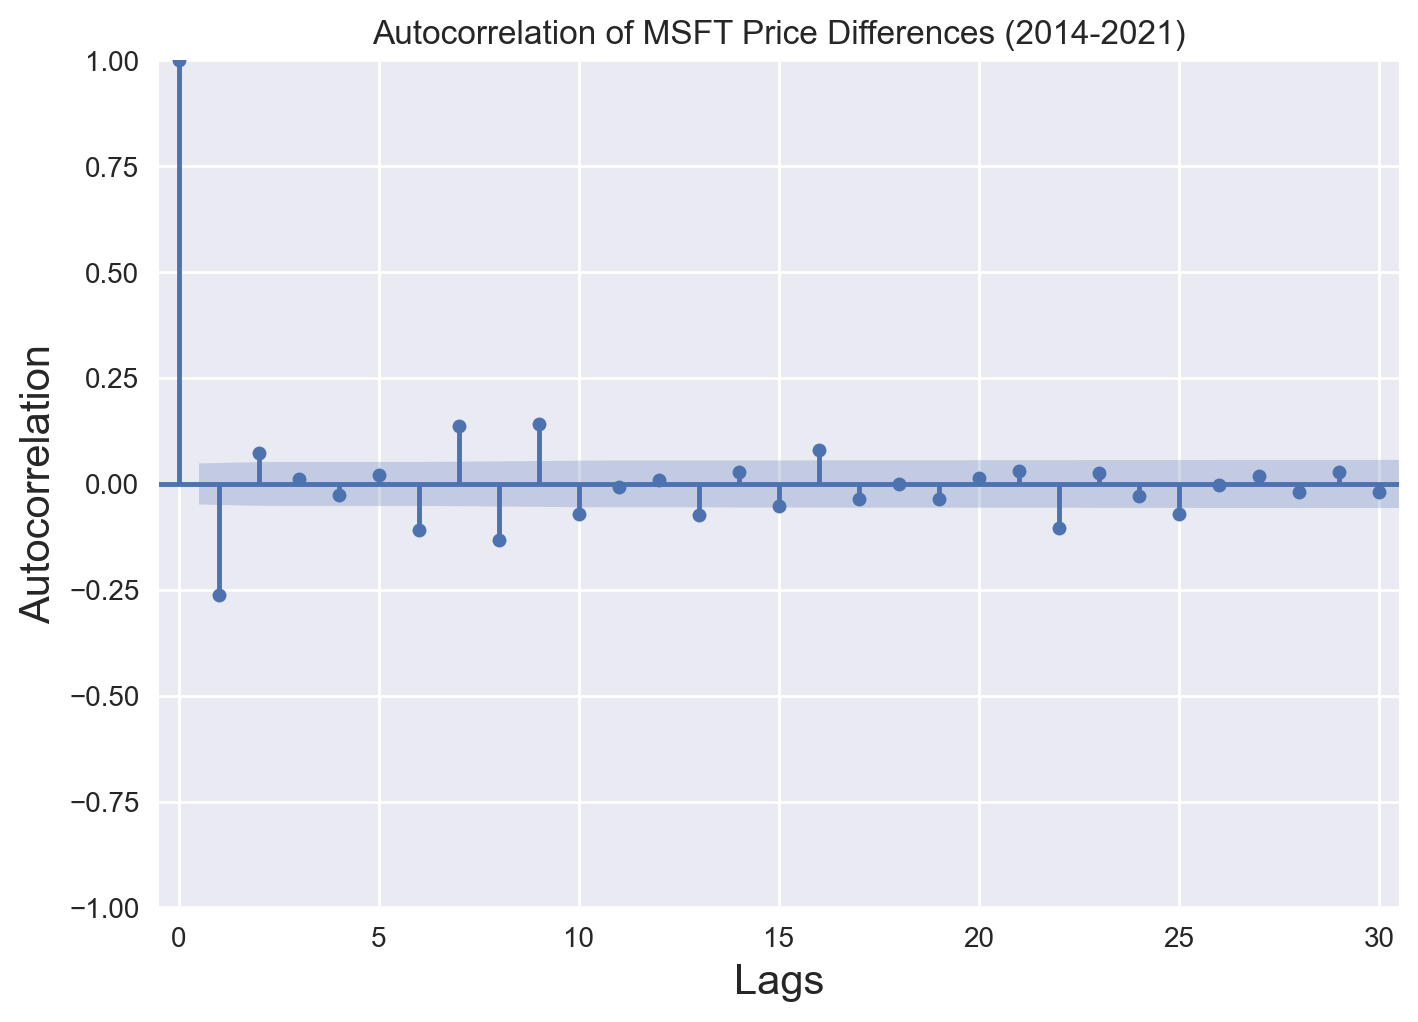

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
title = "Autocorrelation of MSFT Price Differences (2014-2021)"
lags = 30
#fig , ax = plt.subplots(figsize = (15, 6))
plot_acf(msft["Price_Change_method"], lags = lags, title = title , missing = "drop")
plt.ylabel("Autocorrelation", fontsize = 15)
plt.xlabel("Lags", fontsize = 15)
#plt.xticks(range(0, lags + 1))
plt.xlim(-0.5, lags + 0.5)
plt.show()

__-> Absolute Price Changes are not meaningful__ <br>

### Here are three definitive, academically sound reasons to justify transitioning from `diff()` to `pct_change()`:
------------------------------
#### 1. Eliminates Scale Bias (Price Dependency)

* The Problem: The `diff()` method calculates raw dollar changes, which completely ignores the underlying stock price. A $5 change on a $50 stock is a massive 10% move, while a $5 change on a $500 stock is a minor 1% move.
* The Solution: The `pct_change()` method normalizes the data relative to the starting price, allowing you to accurately compare a stock's volatility in 2014 against its volatility in 2021.

#### 2. Enables Cross-Asset Benchmarking

* The Problem: Raw differences cannot be used to compare different companies. If MSFT trades at $400 and AAPL trades at $180, a `diff()` comparison of their daily price movements is statistically meaningless.
* The Solution: Percentage returns put all assets on an identical scale. This makes it possible to compare MSFT directly against Apple, Bitcoin, the S&P 500, or any other financial asset.

#### 3. Aligns with Capital Allocation and Portfolios

* The Problem: Investors do not allocate capital based on "number of dollars a stock moves." They allocate capital based on percentage growth and portfolio weights.
* The Solution: Using `pct_change()` maps directly to actual investment returns. It allows you to easily calculate compound growth, portfolio variances, and risk-adjusted metrics like the Sharpe Ratio.



__Relative/Percentage Price Changes__ (Returns)

In [ ]:
msft["Simple_Return_manual"] = msft["Price_t"].div(msft["Price_t-1"]) - 1 # Alternative 1
msft

,Price_t,Price_t-1,Price_Change_manual,Price_Change_method,Simple_Return_manual
Date,,,,,
2014-10-01,45.9000,NaN,NaN,NaN,NaN
2014-10-02,45.7600,45.9000,-0.1400,-0.1400,-0.0031
2014-10-03,46.0900,45.7600,0.3300,0.3300,0.0072
2014-10-06,46.0900,46.0900,0.0000,0.0000,0.0000
2014-10-07,45.5300,46.0900,-0.5600,-0.5600,-0.0122
...,...,...,...,...,...
2021-05-24,250.7800,245.1700,5.6100,5.6100,0.0229
2021-05-25,251.7200,250.7800,0.9400,0.9400,0.0037
2021-05-26,251.4900,251.7200,-0.2300,-0.2300,-0.0009


In [ ]:
msft["Simple_Return_method"] = msft["Price_t"].pct_change(periods = 1) # Alternative 2
msft

,Price_t,Price_t-1,Price_Change_manual,Price_Change_method,Simple_Return_manual,Simple_Return_method
Date,,,,,,
2014-10-01,45.9000,NaN,NaN,NaN,NaN,NaN
2014-10-02,45.7600,45.9000,-0.1400,-0.1400,-0.0031,-0.0031
2014-10-03,46.0900,45.7600,0.3300,0.3300,0.0072,0.0072
2014-10-06,46.0900,46.0900,0.0000,0.0000,0.0000,0.0000
2014-10-07,45.5300,46.0900,-0.5600,-0.5600,-0.0122,-0.0122
...,...,...,...,...,...,...
2021-05-24,250.7800,245.1700,5.6100,5.6100,0.0229,0.0229
2021-05-25,251.7200,250.7800,0.9400,0.9400,0.0037,0.0037
2021-05-26,251.4900,251.7200,-0.2300,-0.2300,-0.0009,-0.0009


__Take Home: Relative Price Changes (Returns) are meaningful and comparable across instruments__

In [ ]:
msft.columns

Index(['Price_t', 'Price_t-1', 'Price_Change_manual', 'Price_Change_method',
       'Simple_Return_manual', 'Simple_Return_method'],
      dtype='object')

In [ ]:
msft.drop(columns = ["Price_t-1", "Price_Change_manual", "Price_Change_method" , "Simple_Return_manual"] , inplace = True)
msft

,Price_t,Simple_Return_method
Date,,
2014-10-01,45.9000,NaN
2014-10-02,45.7600,-0.0031
2014-10-03,46.0900,0.0072
2014-10-06,46.0900,0.0000
2014-10-07,45.5300,-0.0122
...,...,...
2021-05-24,250.7800,0.0229
2021-05-25,251.7200,0.0037
2021-05-26,251.4900,-0.0009


In [ ]:
msft["Simple_Return_method"] = msft["Simple_Return_method"] *100
msft

,Price_t,Simple_Return_method
Date,,
2014-10-01,45.9000,NaN
2014-10-02,45.7600,-0.3050
2014-10-03,46.0900,0.7212
2014-10-06,46.0900,0.0000
2014-10-07,45.5300,-1.2150
...,...,...
2021-05-24,250.7800,2.2882
2021-05-25,251.7200,0.3748
2021-05-26,251.4900,-0.0914


In [ ]:
msft = msft.rename(columns = {"Simple_Return_method":"Simple_Returns" , "Price_t":"Price"})
msft.columns

Index(['Price', 'Simple_Returns'], dtype='object')

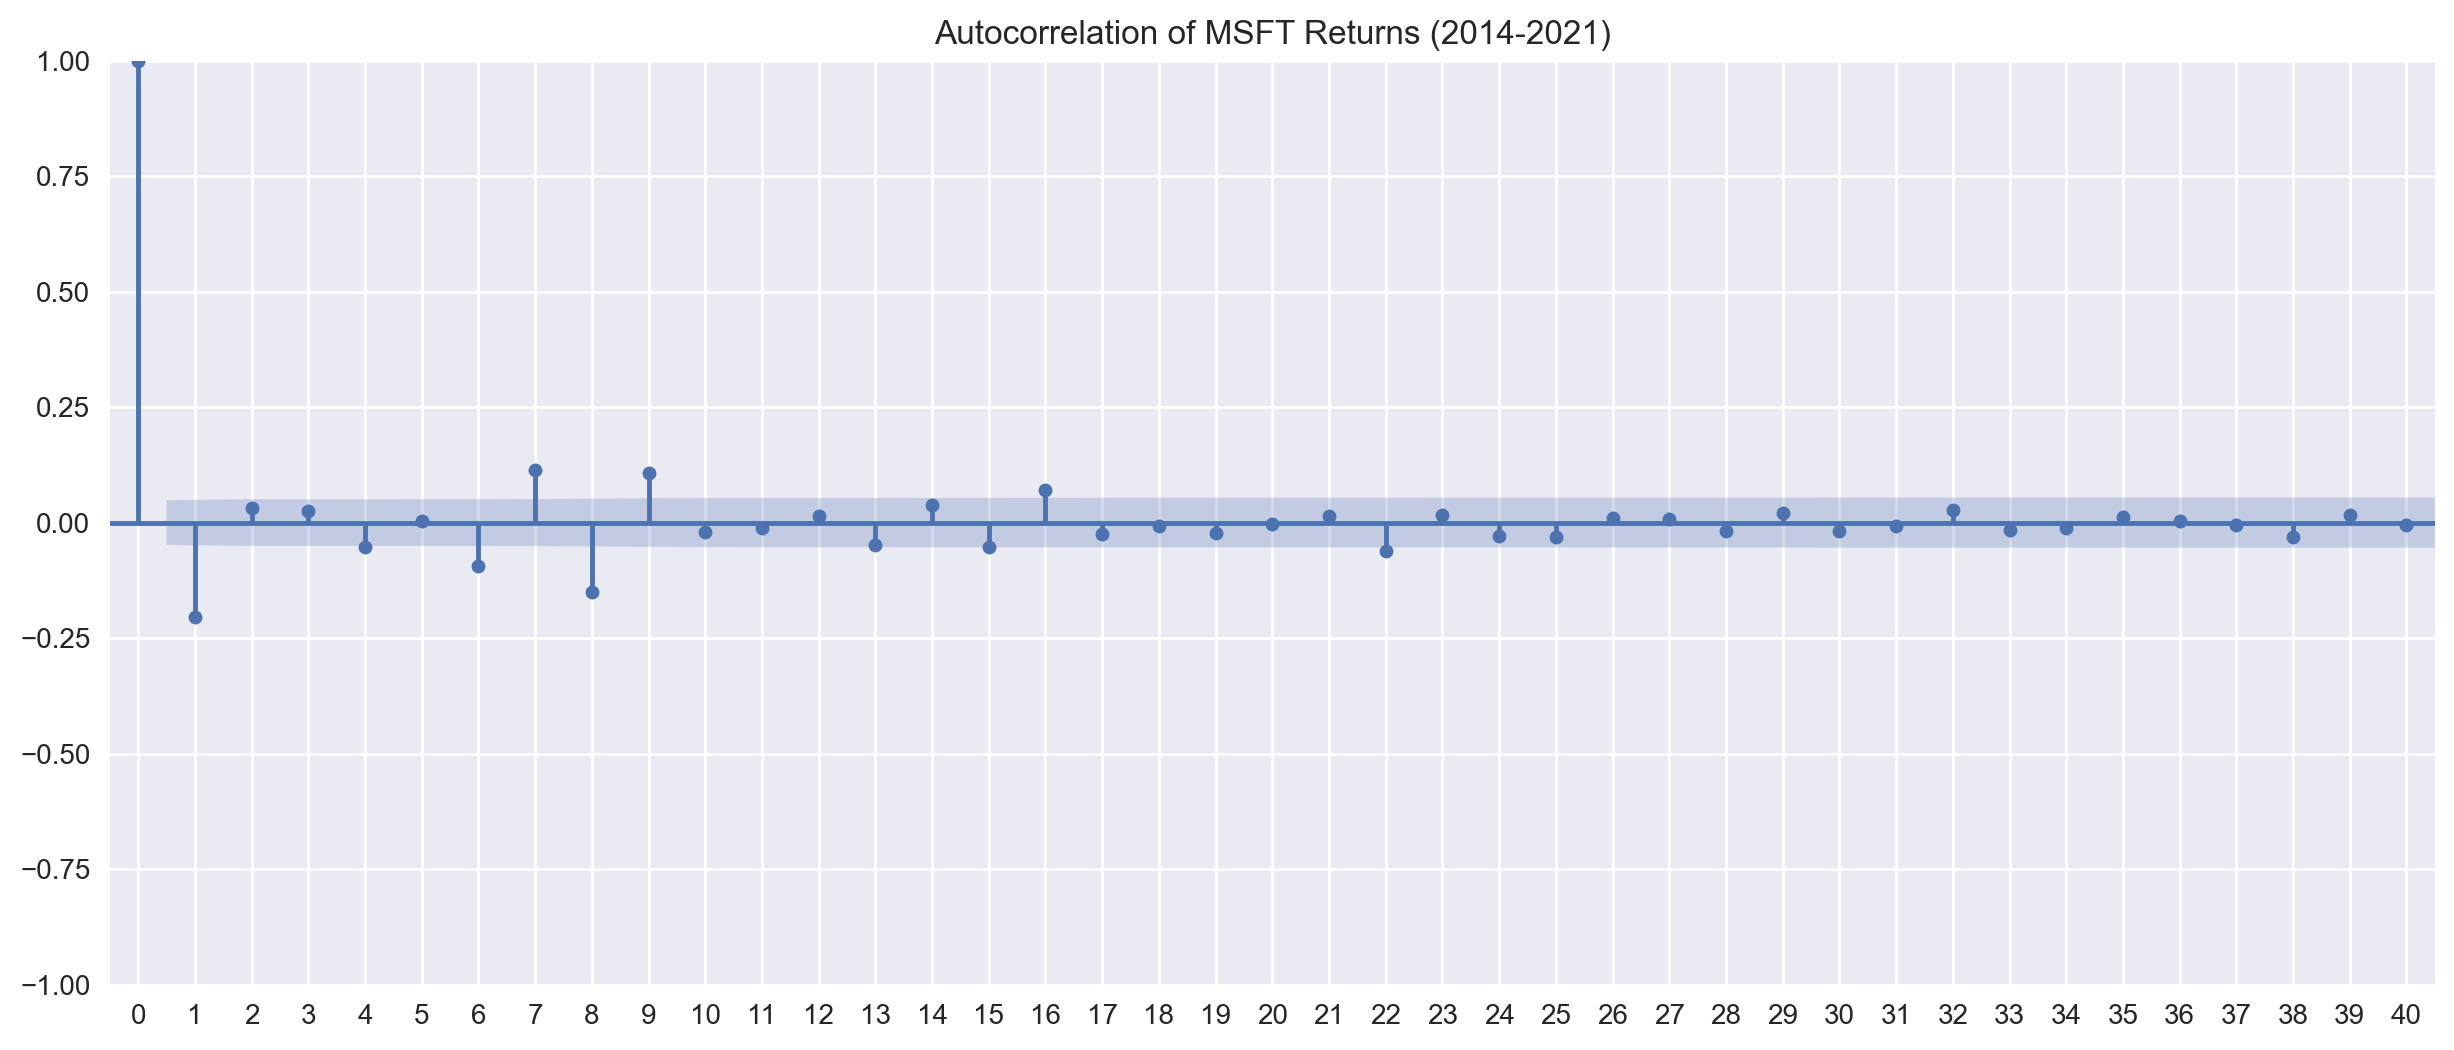

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
title = "Autocorrelation of MSFT Returns (2014-2021)"
lags = 40
fig , ax = plt.subplots(figsize = (15, 6))
plot_acf(msft["Simple_Returns"], lags = lags, title = title , ax = ax , missing ="drop")
plt.xticks(range(0, lags + 1))
plt.xlim(-0.5, lags + 0.5)
plt.show()

In [ ]:
msft.to_csv("msft.csv", index=True)

In [ ]:
import scipy.stats as stats

In [ ]:
# H0: Data is normally distributed
# H1: Data is not normally distributed
if stats.normaltest(msft["Simple_Returns"]).pvalue < 0.05:
    print("Reject H0 - Data is not normally distributed")
else:
    print("Fail to reject H0 - Data is normally distributed")

Fail to reject H0 - Data is normally distributed


In [ ]:
def normality_test(data):
    # H0: Data is normally distributed
    # H1: Data is not normally distributed
    if stats.normaltest(data).pvalue < 0.05:
        print("Reject H0 - Data is not normally distributed")
    else:
        print("Fail to reject H0 - Data is normally distributed")
    return

In [ ]:
normality_test(msft["Simple_Returns"])

Fail to reject H0 - Data is normally distributed


In [ ]:
stats.skew(msft["Simple_Returns"].dropna())

np.float64(0.10674866623940628)

In [ ]:
stats.skewtest(msft["Simple_Returns"].dropna()).pvalue

np.float64(0.07761669712168706)

In [ ]:
def skewness_test(data):
    # H0: Data's skewness is equal to 0 (data is symmetric)
    # H1: Data's skewness is not equal to 0 (data is asymmetric)
    if stats.skewtest(data).pvalue < 0.05:
        print("Reject H0 - Data is asymmetric")
    else:
        print("Fail to reject H0 - Data is symmetric")
    return

In [ ]:
skewness_test(msft["Simple_Returns"])

Fail to reject H0 - Data is symmetric


In [ ]:
stats.kurtosistest(msft["Simple_Returns"].dropna()).pvalue

np.float64(2.368344476190016e-67)

In [ ]:
def kurtosis_test(data):
    # H0: Data's kurtosis is equal to 3 (or excess kurtosis is 0 / normal tails)
    # H1: Data's kurtosis is not equal to 3 (heavy or thin tails)
    
    result = stats.kurtosistest(data, nan_policy='omit')
    
    if result.pvalue < 0.05:
        print(f"Reject H0 (p={result.pvalue:.4f}) - Data is not mesokurtic & has non-normal tails (fat/thin tails)")
    else:
        print(f"Fail to reject H0 (p={result.pvalue:.4f}) - Data is mesokurtic & has normal tails")
    return

In [ ]:
kurtosis_test(msft["Simple_Returns"])

Reject H0 (p=0.0000) - Data is not mesokurtic & has non-normal tails (fat/thin tails)


To wrap up:

In [ ]:
normality_test(msft["Simple_Returns"])
skewness_test(msft["Simple_Returns"])
kurtosis_test(msft["Simple_Returns"])

Fail to reject H0 - Data is normally distributed
Fail to reject H0 - Data is symmetric
Reject H0 (p=0.0000) - Data is not mesokurtic & has non-normal tails (fat/thin tails)


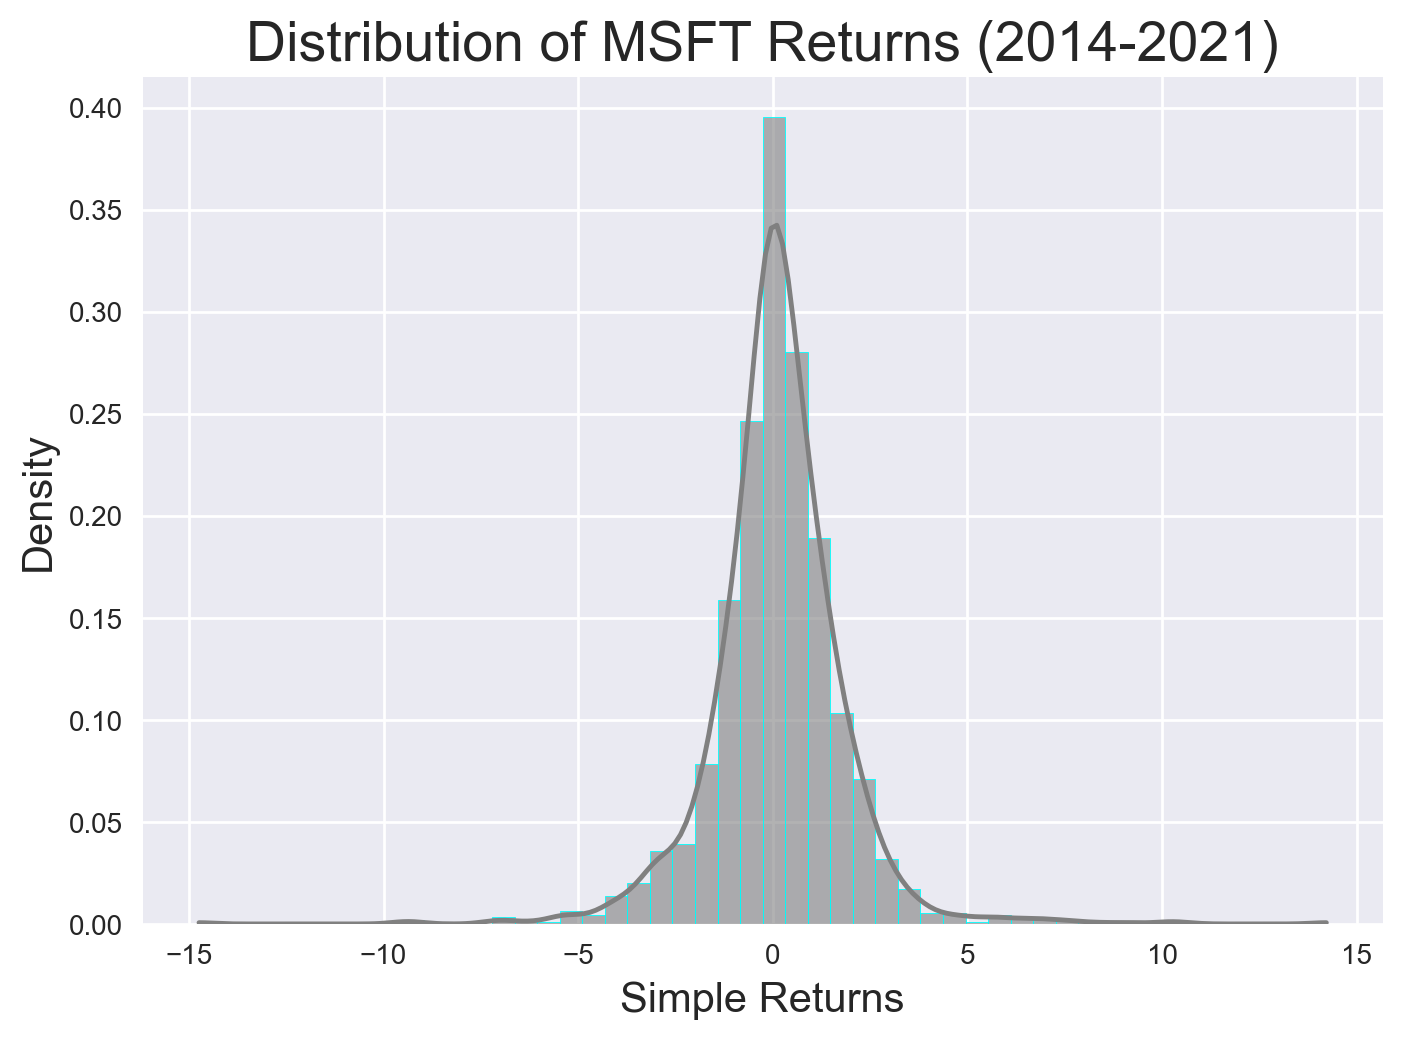

In [ ]:
sns.histplot(msft["Simple_Returns"], bins = 50, kde = True, stat = "density", color = "grey",edgecolor = "cyan", alpha = 0.6 )
plt.title("Distribution of MSFT Returns (2014-2021)", fontsize = 20)
plt.xlabel("Simple Returns", fontsize = 15)
plt.ylabel("Density", fontsize = 15)
plt.show()

## Measuring Reward and Risk of an Investment

__General Rule in Finance/Investing: Higher Risk must be rewarded with higher Returns__.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.4f}'.format
plt.style.use("seaborn-v0_8")

import seaborn as sns

%config InlineBackend.figure_format = 'retina'

In [ ]:
msft = pd.read_csv("msft.csv", index_col = "Date", parse_dates = ["Date"])
msft

,Price,Simple_Returns
Date,,
2014-10-01,45.9000,NaN
2014-10-02,45.7600,-0.3050
2014-10-03,46.0900,0.7212
2014-10-06,46.0900,0.0000
2014-10-07,45.5300,-1.2150
...,...,...
2021-05-24,250.7800,2.2882
2021-05-25,251.7200,0.3748
2021-05-26,251.4900,-0.0914


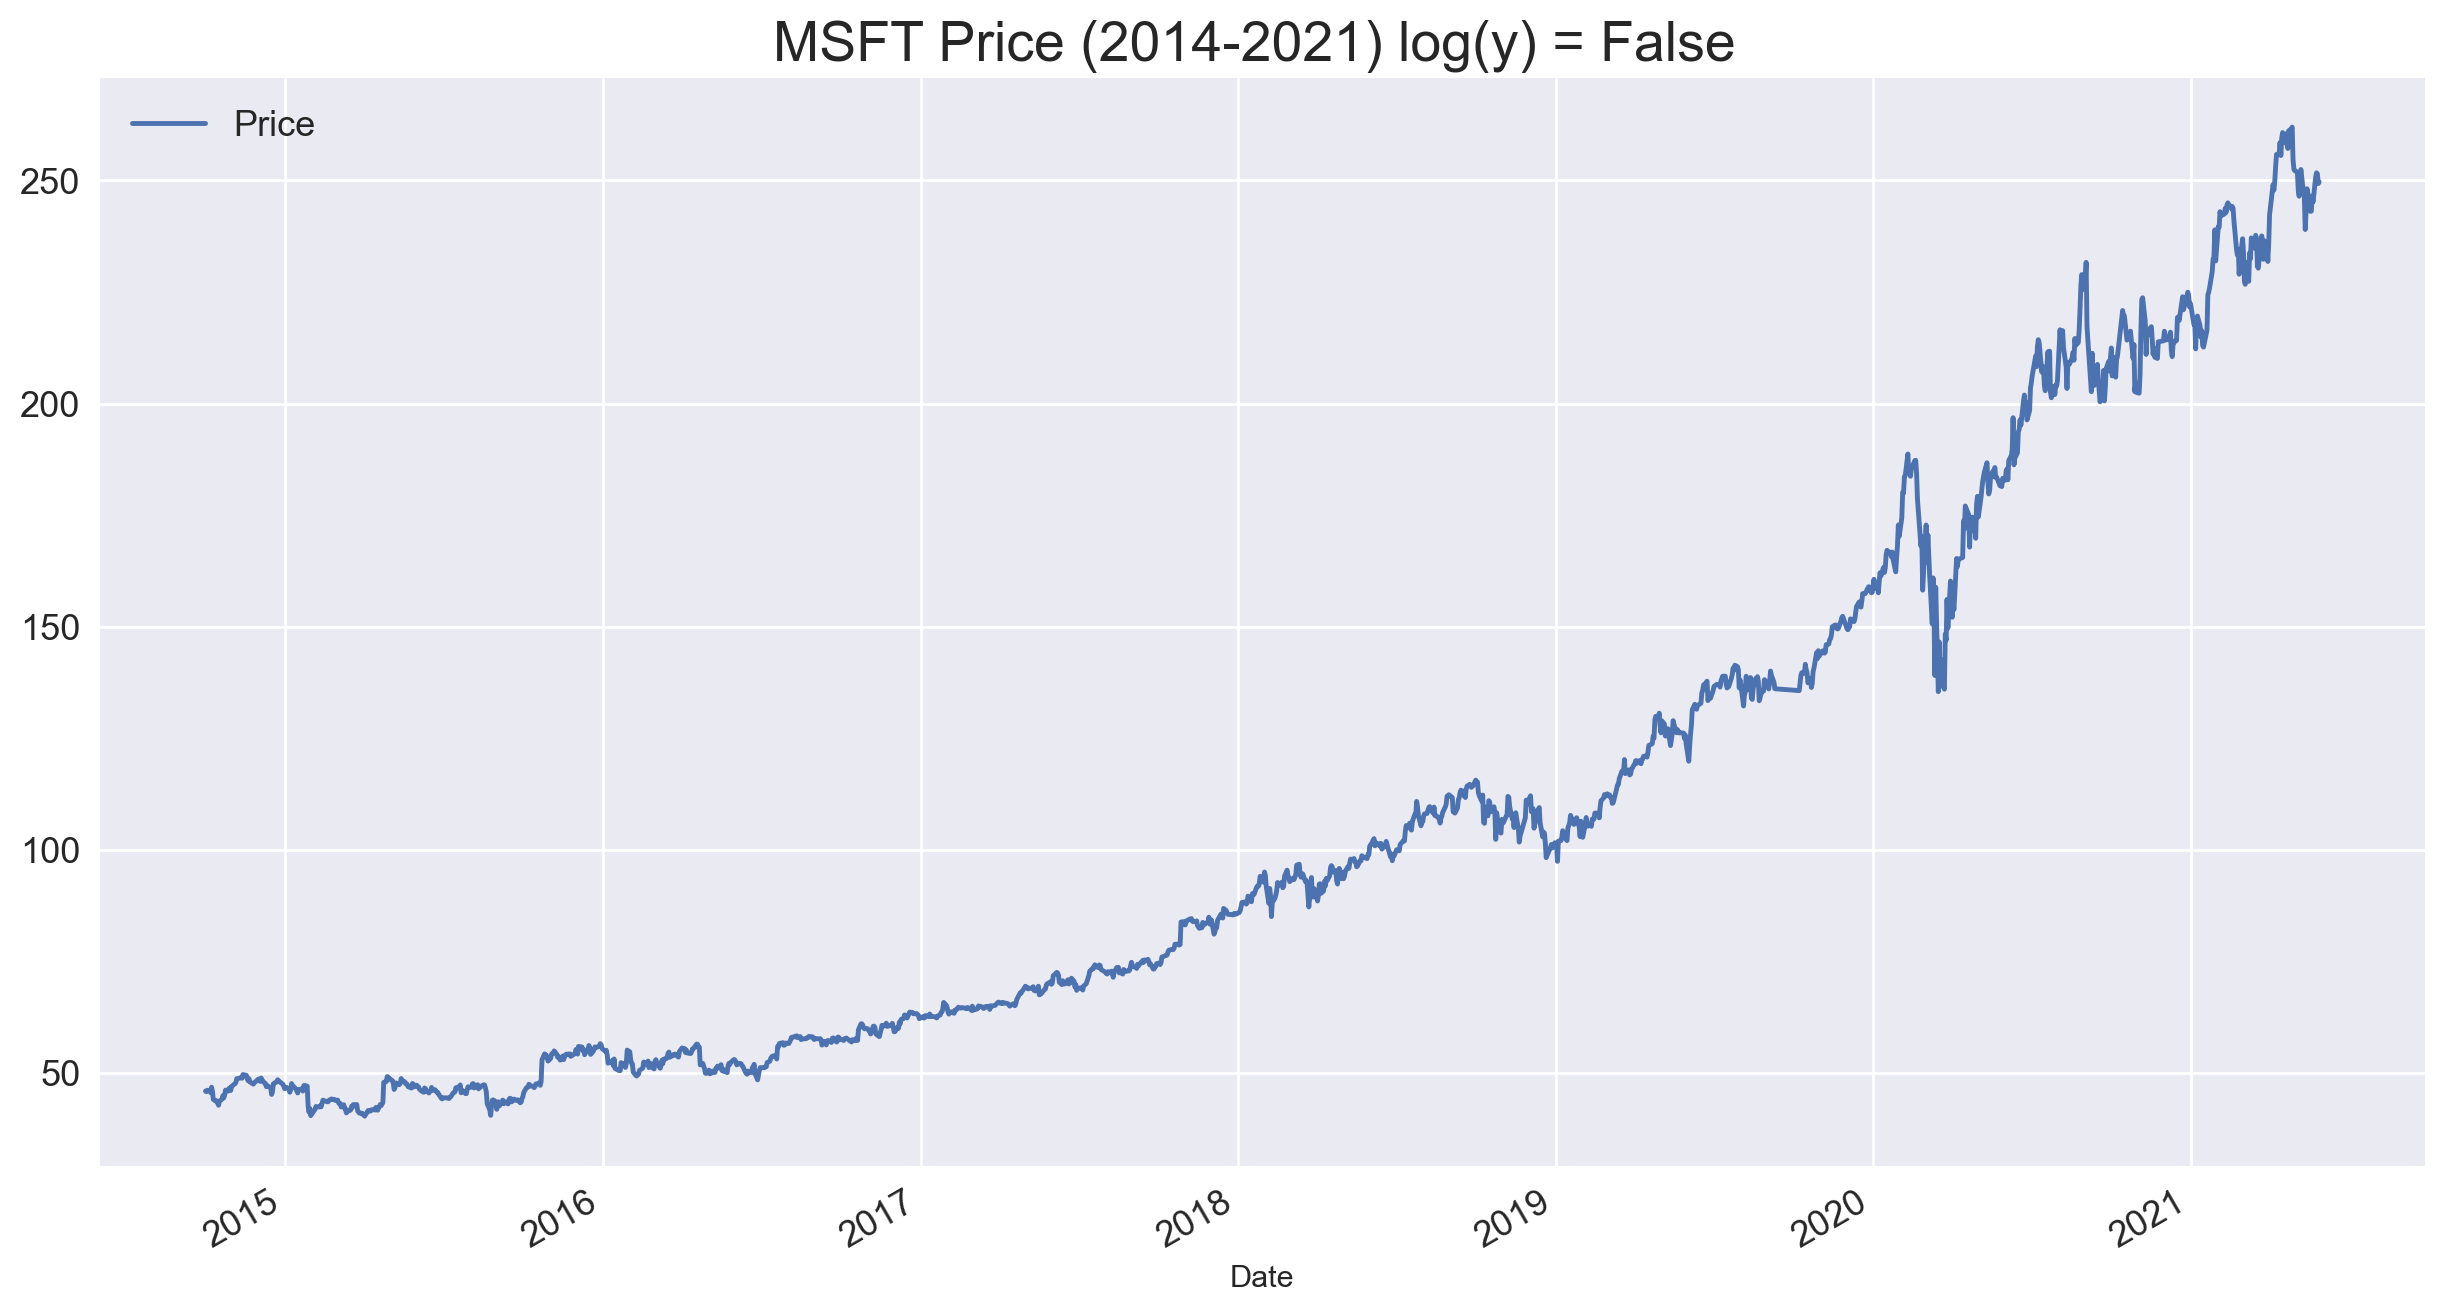

In [ ]:
msft.Price.plot(figsize = (15, 8), fontsize = 13 )
plt.title("MSFT Price (2014-2021) log(y) = False ", fontsize = 20)
plt.legend(fontsize = 13)
plt.show()

- Reward: Positive Returns
- Risk: Volatility of Returns

In [ ]:
msft.describe()

,Price,Simple_Returns
count,1635.0000,1634.0000
mean,105.6719,0.1187
std,60.9903,1.7336
min,40.2900,-14.7390
25%,54.4100,-0.6120
50%,88.0000,0.0918
75%,138.6950,0.9154
max,261.9700,14.2169


In [ ]:
mu = msft.Simple_Returns.mean() # arithmetic mean return -> Reward
mu

np.float64(0.11871914366078709)

In [ ]:
sigma = msft.Simple_Returns.std() # standard deviation of returns -> Risk/Volatility
sigma

1.7336331154480296

In [ ]:
np.sqrt(msft.Simple_Returns.var())

np.float64(1.7336331154480296)

----------------------------------------

__Coding Challenge #2__

1. Calculate daily returns for Bitcoin.

2. Calculate the arithmetic mean return and the standard deviation of returns for Bitcoin. 

3. Compare Bitcoin with Microsoft (mu = 0.00116, sigma = 0.01726). Does the rule "Higher Risk -> Higher Reward" hold?

-----------------------------------

In [ ]:
df = pd.read_csv("close.csv", index_col = "Date", parse_dates = ["Date"])
df

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,124.6700,383.6150,1.2628,1214.6000,45.9000,16804.7109
2014-10-02,124.1700,375.0720,1.2624,1214.2000,45.7600,16801.0508
2014-10-03,126.3600,359.5120,1.2671,1192.2000,46.0900,17009.6895
2014-10-06,126.2600,330.0790,1.2514,1206.7000,46.0900,16991.9102
2014-10-07,123.3200,336.1870,1.2646,1211.7000,45.5300,16719.3906
...,...,...,...,...,...,...
2021-05-24,237.4400,38705.9805,1.2183,1884.6000,250.7800,34393.9805
2021-05-25,240.7400,38402.2227,1.2215,1898.1000,251.7200,34312.4609
2021-05-26,241.3700,39294.1992,1.2249,1901.3000,251.4900,34323.0508


In [ ]:
btc = df["BTC-USD"].to_frame().copy()
btc

,BTC-USD
Date,
2014-10-01,383.6150
2014-10-02,375.0720
2014-10-03,359.5120
2014-10-06,330.0790
2014-10-07,336.1870
...,...
2021-05-24,38705.9805
2021-05-25,38402.2227
2021-05-26,39294.1992


In [ ]:
btc["Simple_Returns"] = btc["BTC-USD"].pct_change(periods = 1) * 100
btc = btc.dropna()
btc

,BTC-USD,Simple_Returns
Date,,
2014-10-02,375.0720,-2.2270
2014-10-03,359.5120,-4.1485
2014-10-06,330.0790,-8.1869
2014-10-07,336.1870,1.8505
2014-10-08,352.9400,4.9832
...,...,...
2021-05-24,38705.9805,3.7563
2021-05-25,38402.2227,-0.7848
2021-05-26,39294.1992,2.3227


In [ ]:
btc.describe()

,BTC-USD,Simple_Returns
count,1634.0000,1634.0000
mean,7588.5712,0.3882
std,11737.8214,4.6789
min,178.1030,-37.1695
25%,459.8230,-1.4462
50%,4191.3000,0.2449
75%,9192.3413,2.1946
max,63503.4570,25.2472


In [ ]:
btc.Simple_Returns.mean()

np.float64(0.38824228522935594)

In [ ]:
btc.Simple_Returns.std()

4.678893787421197

In [ ]:
df_concat = pd.concat([msft.describe(), btc.describe()], axis = 1)
df_concat.columns = ["MSFT_Price", "MSFT_Returns", "BTC-USD", "BTC_Returns"]
df_concat

,MSFT_Price,MSFT_Returns,BTC-USD,BTC_Returns
count,1635.0000,1634.0000,1634.0000,1634.0000
mean,105.6719,0.1187,7588.5712,0.3882
std,60.9903,1.7336,11737.8214,4.6789
min,40.2900,-14.7390,178.1030,-37.1695
25%,54.4100,-0.6120,459.8230,-1.4462
50%,88.0000,0.0918,4191.3000,0.2449
75%,138.6950,0.9154,9192.3413,2.1946
max,261.9700,14.2169,63503.4570,25.2472


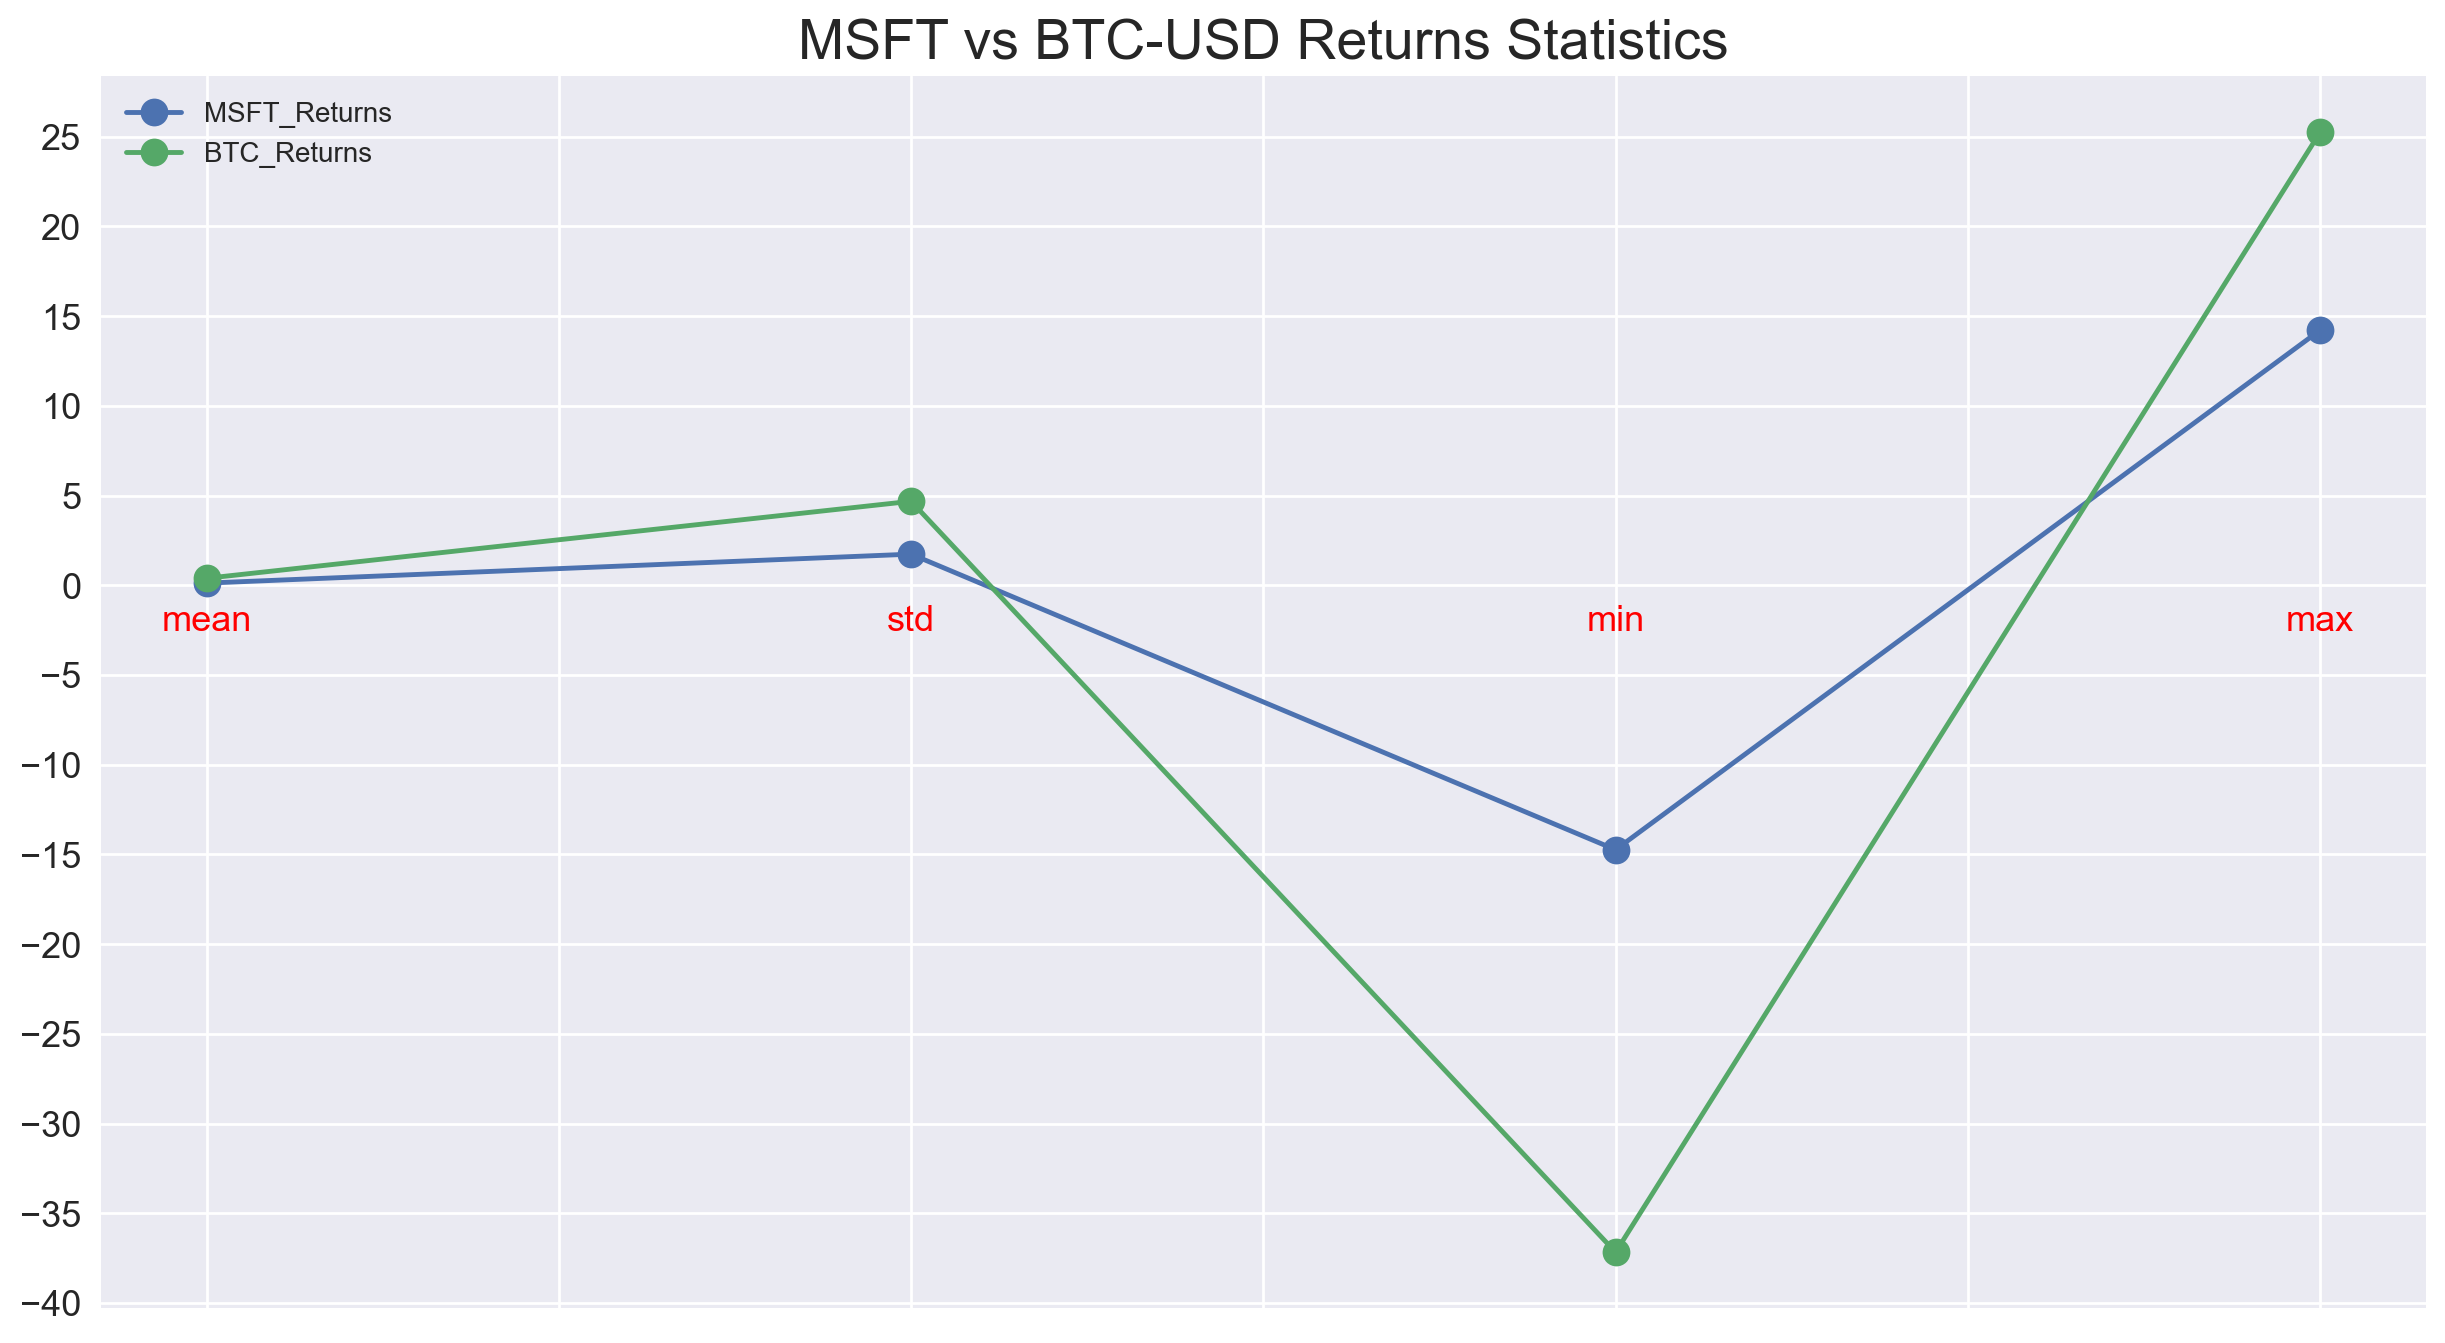

In [ ]:
fig , ax = plt.subplots(figsize = (15, 8))
df_concat.loc[["mean" , "std" , "min" , "max"] , ["MSFT_Returns", "BTC_Returns"]].plot(marker ="o" , ms = 10, fontsize = 13 , ax = ax)
ax.spines["bottom"].set_position(("data", 0))
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 13 , color = "red")
ax.set_title("MSFT vs BTC-USD Returns Statistics", fontsize = 20)
ax.set_yticks(range(-40, 30, 5))
plt.show()

## Investment Multiple and CAGR 

__Two alternative reward metrics that are more intuitive and easier to interpret.__

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.4f}'.format
plt.style.use("seaborn-v0_8")

import seaborn as sns
%config InlineBackend.figure_format = 'retina'

In [ ]:
msft = pd.read_csv("msft.csv", index_col = "Date", parse_dates = ["Date"])
msft

,Price,Simple_Returns
Date,,
2014-10-01,45.9000,NaN
2014-10-02,45.7600,-0.3050
2014-10-03,46.0900,0.7212
2014-10-06,46.0900,0.0000
2014-10-07,45.5300,-1.2150
...,...,...
2021-05-24,250.7800,2.2882
2021-05-25,251.7200,0.3748
2021-05-26,251.4900,-0.0914


__Investment Multiple__: Ending Value of 1 [Dollar] invested. <br>
Multiple = Ending Value / Initial Investment

In [ ]:
multiple = (msft.Price.iloc[-1] / msft.Price.iloc[0]) # NEW: use iloc[]
multiple

np.float64(5.43965107571966)

__Price Increase (in %)__

In [ ]:
(multiple - 1) * 100

np.float64(443.96510757196603)

In [ ]:
msft.Price / msft.Price.iloc[0] # similar/identical concept: Normalized Price with Base Value 1

Date
2014-10-01   1.0000
2014-10-02   0.9969
2014-10-03   1.0041
2014-10-06   1.0041
2014-10-07   0.9919
              ...  
2021-05-24   5.4636
2021-05-25   5.4841
2021-05-26   5.4791
2021-05-27   5.4316
2021-05-28   5.4397
Name: Price, Length: 1635, dtype: float64

In [ ]:
((msft.Price / msft.Price.iloc[0]).iloc[-1] - (msft.Price / msft.Price.iloc[0]).iloc[0])*100

np.float64(443.96510757196603)

__Drawback of Investment Multiple: Doesn´t take into account investment Period. Meaningful only in conjunction with Investment Period.__

__Compound Annual Growth Rate (CAGR)__: The (constant annual) rate of return that would be required for an investment to grow from its beginning balance to its ending balance, assuming the profits were reinvested at the end of each year of the investment's lifespan. (Wikipedia)

In [ ]:
start = msft.index[0]
start

Timestamp('2014-10-01 00:00:00')

In [ ]:
end = msft.index[-1]
end

Timestamp('2021-05-28 00:00:00')

In [ ]:
td = end - start # timedelta
td

Timedelta('2431 days 00:00:00')

In [ ]:
td.components

Components(days=2431, hours=0, minutes=0, seconds=0, milliseconds=0, microseconds=0, nanoseconds=0)

In [ ]:
td.days

2431

In [ ]:
td_years = td.days / 365.25
td_years

6.655715263518139

$$\text{multiple} = \frac{\text{Last Price}}{\text{First Price}}$$
$$CAGR = \sqrt[\text{Number of Years}]{\text{multiple}} - 1 $$

In [ ]:
cagr = multiple**(1 / td_years) - 1 # short version
cagr

np.float64(0.2897846506194157)

In [ ]:
cagr = (msft.Price.iloc[-1]/msft.Price.iloc[0])**(1/((msft.index[-1] - msft.index[0]).days / 365.25)) - 1 # long
cagr

np.float64(0.2897846506194157)

In [ ]:
(1 + cagr)**(td_years) # alternative #2 to calculate multiple (cagr)

np.float64(5.439651075719659)

__-> CAGR can be used to compare Investments with different investment horizons.__

## Compound Returns & Geometric Mean Return

In [ ]:
msft

,Price,Simple_Returns
Date,,
2014-10-01,45.9000,NaN
2014-10-02,45.7600,-0.3050
2014-10-03,46.0900,0.7212
2014-10-06,46.0900,0.0000
2014-10-07,45.5300,-1.2150
...,...,...
2021-05-24,250.7800,2.2882
2021-05-25,251.7200,0.3748
2021-05-26,251.4900,-0.0914


We know the Simple Return's formula as follows:
$$
R_{t} = \frac{S_{t+1}}{S_{t}} - 1
$$
Also we can define the $\log$ Return's formula:
$$
r_{t} = \log(\frac{S_{t+1}}{S_{t}})
$$
New We have:
$$
1 + R_{t} = \frac{S_{t+1}}{S_{t}} \\
r_{t} = \log(1 + R_{t})
$$
Given than, let recalculate the multiplier:

$$
\frac{S_{m}}{S_{n}} = \frac{S_{n+1}}{S_{n}}\times\frac{S_{n+2}}{S_{n+1}}\times\cdots\times\frac{S_{m-2}}{S_{m-1}}\times\frac{S_{m}}{S_{m-1}}
$$
Hence:
\begin{align}
\frac{S_{m}}{S_{n}} &= 
\frac{S_{n+1}}{S_{n}}\times\frac{S_{n+2}}{S_{n+1}}\times\cdots\times\frac{S_{m-2}}{S_{m-1}}\times\frac{S_{m}}{S_{m-1}}\\
&=
(1 + R_{n})\times(1 + R_{n+1})\times\cdots\times(1 + R_{m-1})\times(1 + R_{m})\\
\end{align}


So we can rewrite the multiplier formula in term of it:

$$
\text{multiple} = \frac{P_{Last(N)}}{P_{First(0)}} = \prod_{i=0}^{N} (1 + R_{i})
$$

We also know that:
$$
\text{Geometric Mean Return} = \sqrt[\frac{1}{N}]{\prod_{i=0}^{N} (1 + R_{i})} - 1 = \sqrt[\frac{1}{N}]{\text{multiple}} - 1
$$
Here N is the number of days, not years. So this formula is similar to CAGR but there is a big difference between them: N

In [ ]:
multiple = (1 + msft.Simple_Returns).prod() # alternative #3 to calculate multiple (compounding daily returns)
multiple

np.float64(1.9129132360650302e+46)

In [ ]:
n = msft.Simple_Returns.count() # number of observations (daily returns) len(msft.Returns) this is the N in the formula of Geometric Mean Return
n

np.int64(1634)

In [ ]:
geo_mean = multiple**(1/n) - 1 # Geometric mean return (daily)
geo_mean

np.float64(0.06739255896543384)

In [ ]:
(1 + geo_mean)**n # alternative #4 to calculate multiple = Last Price/First Price (geometric mean)

np.float64(1.912913236065267e+46)

__-> Compound returns, CAGR & geometric mean return are closely related concepts__.

In [ ]:
msft.columns

Index(['Price', 'Simple_Returns'], dtype='object')

In [ ]:
mu = msft.Simple_Returns.mean() # arithmetic mean return
mu

np.float64(0.11871914366078709)

__The arithmetic mean return is always greater than the geometric mean return... and less useful__. 

In [ ]:
(1 + mu)**n # calculate multiple? not possible with arithmetic mean!

np.float64(4.075943241624603e+79)

----------------------------

__Coding Challenge #3__

In [ ]:
ba = df.BA.to_frame().dropna().copy()
ba

,BA
Date,
2014-10-01,124.6700
2014-10-02,124.1700
2014-10-03,126.3600
2014-10-06,126.2600
2014-10-07,123.3200
...,...
2021-05-24,237.4400
2021-05-25,240.7400
2021-05-26,241.3700


In [ ]:
ba["Simple_Returns"] = ba.pct_change(periods = 1).mul(100)
ba = ba.dropna()
ba

,BA,Simple_Returns
Date,,
2014-10-02,124.1700,-0.4011
2014-10-03,126.3600,1.7637
2014-10-06,126.2600,-0.0791
2014-10-07,123.3200,-2.3285
2014-10-08,124.9800,1.3461
...,...,...
2021-05-24,237.4400,1.1157
2021-05-25,240.7400,1.3898
2021-05-26,241.3700,0.2617


In [ ]:
#ba["Simple_Returns%"] = ba["Simple_Returns%"].map("{:.2%}".format)

In [ ]:
ba

,BA,Simple_Returns
Date,,
2014-10-02,124.1700,-0.4011
2014-10-03,126.3600,1.7637
2014-10-06,126.2600,-0.0791
2014-10-07,123.3200,-2.3285
2014-10-08,124.9800,1.3461
...,...,...
2021-05-24,237.4400,1.1157
2021-05-25,240.7400,1.3898
2021-05-26,241.3700,0.2617


In [ ]:
ba.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1634 entries, 2014-10-02 to 2021-05-28
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   BA              1634 non-null   float64
 1   Simple_Returns  1634 non-null   float64
dtypes: float64(2)
memory usage: 38.3 KB


1. Calculate Boeing´s Investment Multiple 

$$\text{multiple} = \frac{\text{Last Price}}{\text{First Price}}$$

In [ ]:
ba_investment_multiple = ba.BA.iloc[-1] / ba.BA.iloc[0]
ba_investment_multiple

np.float64(1.9893694766457695)

2. Calculate Boeing´s CAGR

In [ ]:
start = ba.index[0]
end = ba.index[-1]

td = end - start # timedelta
td

Timedelta('2430 days 00:00:00')

In [ ]:
td.components

Components(days=2430, hours=0, minutes=0, seconds=0, milliseconds=0, microseconds=0, nanoseconds=0)

In [ ]:
n_years = td.days/365.25
n_years

6.652977412731006

$$\text{multiple} = \frac{\text{Last Price}}{\text{First Price}}$$
$$CAGR = \sqrt[\text{Number of Years}]{\text{multiple}} - 1 $$

In [ ]:
cagr = ba_investment_multiple**(1/n_years) - 1
cagr

np.float64(0.10891820589580248)

3. Calculate Boeing´s Geometric Mean Return

In [ ]:
n_days = len(ba.BA)
n_days

1634

So we can rewrite the geometric mean in terms of the multiple:

$$
\text{multiple} = \frac{P_{Last(N)}}{P_{First(0)}} = \prod_{i=0}^{N} (1 + R_{i})
$$

We also know that:
$$
\text{Geometric Mean Return} = \sqrt[\frac{1}{N}]{\prod_{i=0}^{N} (1 + R_{i})} - 1 = \sqrt[\frac{1}{N}]{\text{multiple}} - 1 \\
\text{multiple} = (1 + \text{Geometric Mean Return})^{N}
$$
Therefore, we can calculate the Future Value in term of the Present Value:
$$
FV = \text{multiple}\times PV = (1 + \text{Geometric Mean Return})^{N} \times PV
$$

In [ ]:
ba_geo_mean = (ba_investment_multiple)**(1/n_days) - 1
ba_geo_mean

np.float64(0.00042102969909030286)

4. Calculate Boeing´s Investment Multiple with compound daily returns

In [ ]:
ba_investment_multiple_alternative = (1 + ba['Simple_Returns']).prod()
ba_investment_multiple_alternative

np.float64(-7.335023642630495e+88)

----------------------------------

## Preview: Simple Returns vs. Logarithmic Returns (log returns)

Very often log returns are used instead of simple returns.<br>
- favourable characteristics of log returns
- drawbacks of simple returns

Problem: Many Students / Practitioners feel uncomfortable with log returns. <br>
-> more detailed background on log returns in the next two Lectures (Discrete vs. Continuous Compounding)

## Discrete Compounding

__Annual Compounding__ -> Interests accrue once a year at the end of the year

Your Savings Bank offers an interest rate of __8% p.a. (stated rate)__ with __annual compounding__ on your savings (__USD 100__).<br>
Calculate the __value__ of your savings account __after one year__ and the corresponding __effective annual interest rate__. 

__-> Interests are calculated and added to your savings account once at the end of each year.__

In [ ]:
PV = 100
r = 0.08 # fixed rate of return
n = 1

In [ ]:
100 * 1.08

108.0

In [ ]:
FV = PV * (1 + r)**n
FV

108.0

In [ ]:
effective_annual_rate = (FV / PV)**(1/n) - 1 # effective annual rate of return when the rate of return is fixed = r
effective_annual_rate

0.08000000000000007

__Quarterly Compounding__ -> Interests accrue once a quarter at the end of the quarter

Your Savings Bank offers an interest rate of __8% p.a. (stated rate)__ with __quarterly compounding__ on your savings (__USD 100__).<br>
Calculate the __value__ of your savings account __after one year__ and the corresponding __effective annual interest rate__. 

__-> Interests are calculated and added to your savings account at the end of each quarter.__

In [ ]:
PV = 100 # Present value
r = 0.08 # Interest rate of 8% per year 
n = 1 # 1 year
m = 4 # 4 months

In [ ]:
r/m

0.02

In [ ]:
1 + r/m

1.02

In [ ]:
100 * 1.02 * 1.02 * 1.02 * 1.02

108.243216

in this case the multiple is : $(1 + \frac{r}{m})^{n \times m}$, hence:
$$
FV = \text{Multiple}\times PV = (1 + \frac{r}{m})^{n \times m} \times PV
$$

In [ ]:
PV*(1+r/m)**(n*m)

108.243216

In [ ]:
FV = PV * (1 + r/m)**(n*m)
FV

108.243216

In [ ]:
effective_annual_rate = (FV / PV)**(1/n) - 1 
effective_annual_rate

0.08243215999999998

__-> Quarterly compounding is favourable (everything else equal) as we earn compound interest (interest on interest).__

__Monthly Compounding__ -> Interests accrue once a month at the end of the month

Your Savings Bank offers an interest rate of __8% p.a. (stated rate)__ with __monthly compounding__ on your savings (__USD 100__).<br>
Calculate the __value__ of your savings account __after one year__ and the corresponding __effective annual interest rate__. 

__-> Interests are calculated and added to your savings account at the end of each month.__

In [ ]:
PV = 100
r = 0.08
n = 1
m = 12

In [ ]:
FV = PV * (1 + r/m)**(n*m)
FV

108.29995068075098

In [ ]:
effective_annual_rate = ((FV / PV)**(1/n) - 1) 
effective_annual_rate

0.08299950680750978

In [ ]:
(1 + r/m)**(m) - 1 # second method to calculate the effective annual rate

0.08299950680750978

## Continuous Compounding 

Remember : the case that multiple is : $(1 + \frac{r}{m})^{n \times m}$, hence:
$$
FV = \text{Multiple}\times PV = (1 + \frac{r}{m})^{n \times m} \times PV
$$

so when we tend $m \to\infty$: 

\begin{align}
\text{Multiple} &= \lim_{m \to\infty} (1 + \frac{r}{m})^{m\times n} \\
&= \exp(r)^{n}
\end{align}


In [ ]:
import numpy as np

Your Savings Bank offers an interest rate of __8% p.a. (stated rate)__ with __continuous compounding__ on your savings (__USD 100__).<br>
Calculate the __value__ of your savings account __after one year__ and the corresponding __effective annual interest rate__. 

__-> Interests are calculated and added to your savings account continuously (infinitely large number of compounding events).__ -> continuous exponential growth that can be observed in nature

In [ ]:
PV = 100
r = 0.08
n = 1
m = 100000 # approx.infinity

Recap:

We know that:

$$
\exp(x) = \lim_{n \to \infty} \big(1 + \frac{x}{n}\big)^n
$$

So 

\begin{align}
\lim_{m \to\infty} \big(1 + \frac{r}{m}\big)^{n\times m} &= \lim_{m \to\infty} \Big(\big(1 + \frac{r}{m}\big)^{m}\Big)^{n} \\
&= \Big(\lim_{m \to\infty} \big(1 + \frac{r}{m}\big)^{m}\Big)^{n} \\
&= \exp(r)^{n} \\
&= \exp(r\times n)
\end{align}

Now let's compute the FV (Future Value) in terms of PV(Present Value), r(interest rate), and for a very large m: $m \to\infty$ :

- PV = Present value (initial investment)
- FV = Future value (final amount)  
- r  = annual nominal interest rate (as a decimal)
- n  = number of years
- m  = number of compounding periods per year

\begin{align}
FV &= PV \times (1 + \frac{r}{m})^{m\times n} \\
&= PV \times\lim_{m \to\infty} (1 + \frac{r}{m})^{m\times n} \\
&= PV \times \exp(r)^{n}
\end{align}

So the we can obtain the r:
$$
\exp(r)^{n} =\frac{FV}{PV} \\
\exp(r) = \sqrt[n]{\frac{FV}{PV}}
$$

So:
$$
r = \log(\sqrt[n]{\frac{FV}{PV}}) = \frac{1}{n}\log(\frac{FV}{PV})
$$

In [ ]:
FV = PV * (1 + r/m)**(n*m) # approx. with large m = 100000
FV

108.32870330122834

In [ ]:
FV = PV * np.exp(n * r) # exact math with e (euler number)
FV

np.float64(108.32870676749586)

In [ ]:
np.log(FV / PV)/n

np.float64(0.08000000000000007)

In [ ]:
euler = np.exp(1)
euler

np.float64(2.718281828459045)

In [ ]:
PV * euler**(n * r)

np.float64(108.32870676749586)

$$
r = \log(\sqrt[n]{\frac{FV}{PV}}) = \frac{1}{n}\log(\frac{FV}{PV})
$$

In [ ]:
effective_annual_rate = ((FV / PV)**(1/n) - 1) # Alt 1
effective_annual_rate

np.float64(0.08328706767495864)

In [ ]:
effective_annual_rate = np.exp(r) - 1 # Alt 2
effective_annual_rate

np.float64(0.08328706767495864)

Let´s assume we only observe PV and FV, how to calculate the stated rate/continuously compounded rate of 8%?

In [ ]:
r = np.log(FV / PV) # inverse calculation -> use log (Alt 1)
r

np.float64(0.08000000000000007)

In [ ]:
r = np.log(effective_annual_rate + 1) # inverse calculation -> use log (Alt 2)
r

np.float64(0.08000000000000007)

__Take Home: Prices of traded Financial Instruments change (approx.) continuously. <br>
-> Intuitively, it makes a lot of sense to work with log returns.__ 

## Log Returns

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
pd.options.display.float_format = '{:.6f}'.format
%config InlineBackened.figure_format = 'retina'

In [ ]:
msft = pd.read_csv("msft.csv", index_col = "Date", parse_dates = ["Date"])
msft

,Price,Simple_Returns
Date,,
2014-10-01,45.900002,NaN
2014-10-02,45.759998,-0.305018
2014-10-03,46.090000,0.721158
2014-10-06,46.090000,0.000000
2014-10-07,45.529999,-1.215017
...,...,...
2021-05-24,250.779999,2.288208
2021-05-25,251.720001,0.374832
2021-05-26,251.490005,-0.091370


In [ ]:
np.log(msft.Price / msft.Price.shift())

Date
2014-10-01         NaN
2014-10-02   -0.003055
2014-10-03    0.007186
2014-10-06    0.000000
2014-10-07   -0.012225
                ...   
2021-05-24    0.022624
2021-05-25    0.003741
2021-05-26   -0.000914
2021-05-27   -0.008706
2021-05-28    0.001483
Name: Price, Length: 1635, dtype: float64

In [ ]:
np.log(msft.Price).diff()

Date
2014-10-01         NaN
2014-10-02   -0.003055
2014-10-03    0.007186
2014-10-06    0.000000
2014-10-07   -0.012225
                ...   
2021-05-24    0.022624
2021-05-25    0.003741
2021-05-26   -0.000914
2021-05-27   -0.008706
2021-05-28    0.001483
Name: Price, Length: 1635, dtype: float64

In [ ]:
msft["log_ret"] = np.log(msft.Price / msft.Price.shift()) # daily log returns
# or
msft["log_ret2"] = np.log(msft.Price).diff() # daily log returns

In [ ]:
msft

,Price,Simple_Returns,log_ret,log_ret2
Date,,,,
2014-10-01,45.900002,NaN,NaN,NaN
2014-10-02,45.759998,-0.305018,-0.003055,-0.003055
2014-10-03,46.090000,0.721158,0.007186,0.007186
2014-10-06,46.090000,0.000000,0.000000,0.000000
2014-10-07,45.529999,-1.215017,-0.012225,-0.012225
...,...,...,...,...
2021-05-24,250.779999,2.288208,0.022624,0.022624
2021-05-25,251.720001,0.374832,0.003741,0.003741
2021-05-26,251.490005,-0.091370,-0.000914,-0.000914


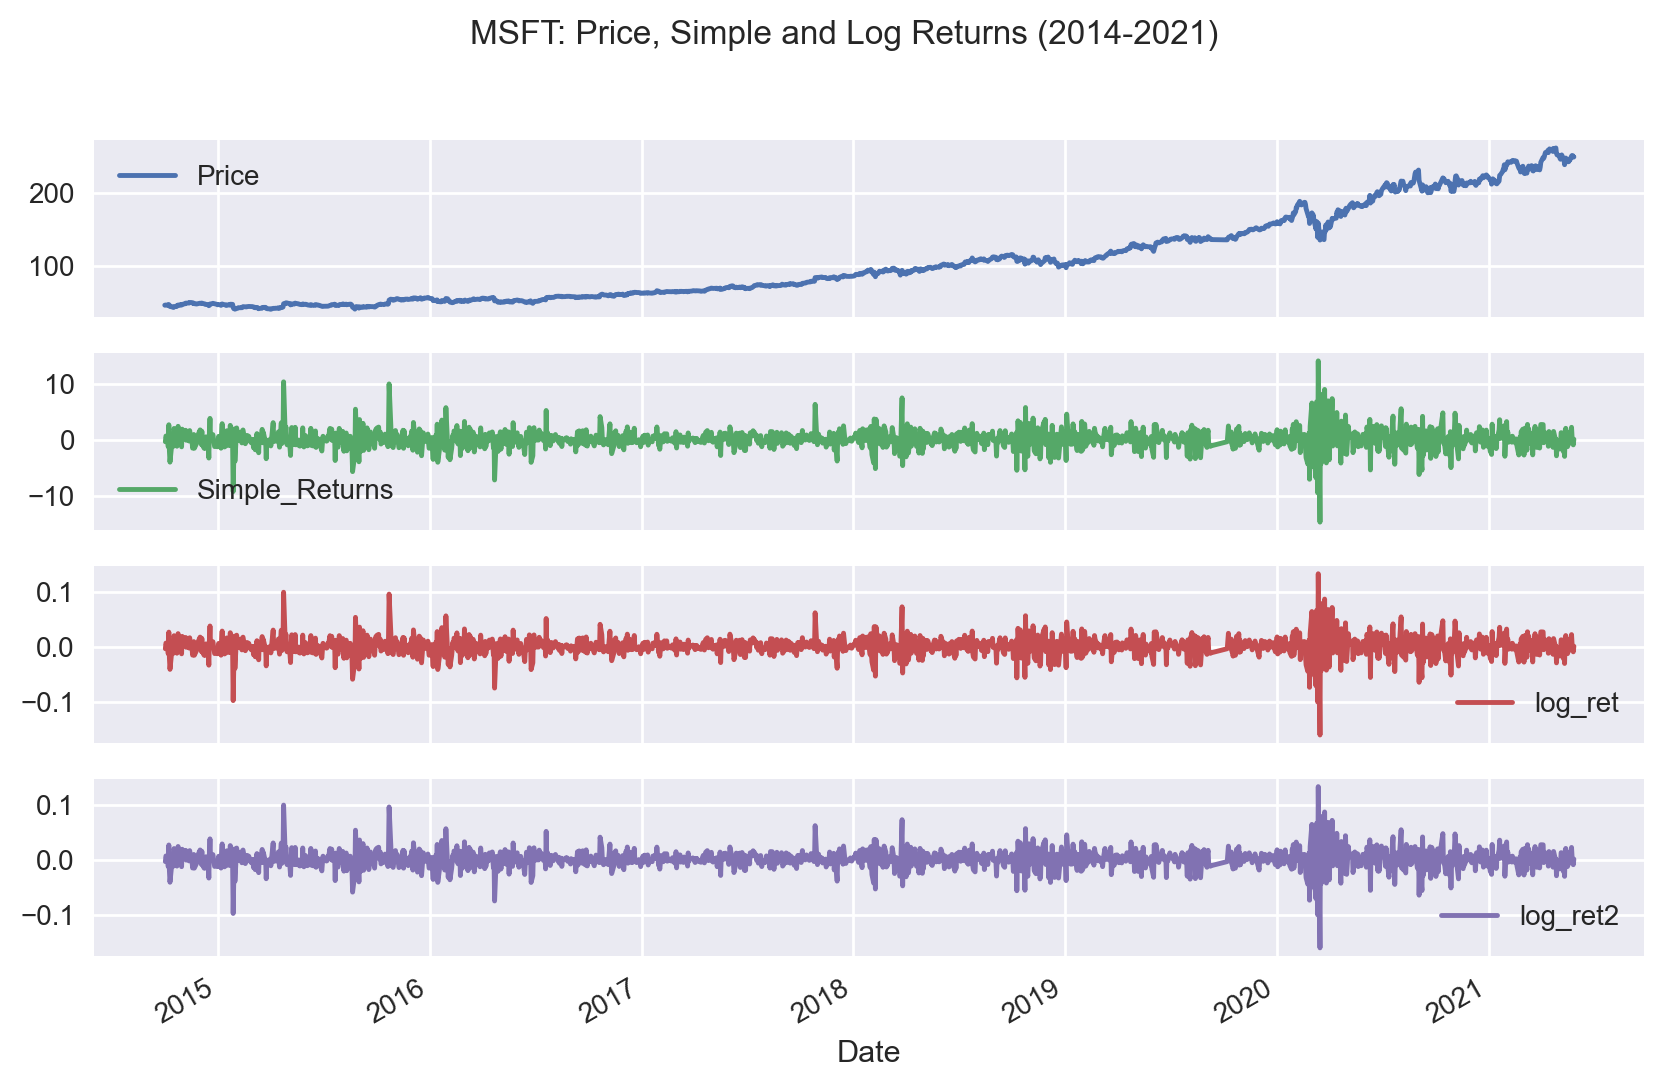

In [ ]:
msft.plot(subplots = True, figsize = (10, 6) , title = "MSFT: Price, Simple and Log Returns (2014-2021)")
plt.show()

In [ ]:
normality_test(msft.Returns)

In [ ]:
normality_test(msft.log_ret)

Fail to reject H0 - Data is normally distributed.


In [ ]:
adf_test(msft.log_ret)

Augmented Dickey-Fuller Test on "" 
-------------------------
ADF Test Statistic             -14.481435
p-value                          0.000000
#Lags Used                       8.000000
Number of Observations Used   1624.000000
Critical Value (1%)             -3.434383
Critical Value (5%)             -2.863321
Critical Value (10%)            -2.567718
*************************
*************************
ADF Test Conclusion: 
Strong evidence against the null hypothesis(Ho).
Reject the null hypothesis.
Data has no unit root and is stationary.


In [ ]:
adf_test(msft.Returns)

Augmented Dickey-Fuller Test on "" 
-------------------------
ADF Test Statistic             -14.547867
p-value                          0.000000
#Lags Used                       8.000000
Number of Observations Used   1625.000000
Critical Value (1%)             -3.434381
Critical Value (5%)             -2.863320
Critical Value (10%)            -2.567718
*************************
*************************
ADF Test Conclusion: 
Strong evidence against the null hypothesis(Ho).
Reject the null hypothesis.
Data has no unit root and is stationary.


In [ ]:
msft

,Price,Simple_Returns,log_ret,log_ret2
Date,,,,
2014-10-01,45.900002,NaN,NaN,NaN
2014-10-02,45.759998,-0.305018,-0.003055,-0.003055
2014-10-03,46.090000,0.721158,0.007186,0.007186
2014-10-06,46.090000,0.000000,0.000000,0.000000
2014-10-07,45.529999,-1.215017,-0.012225,-0.012225
...,...,...,...,...
2021-05-24,250.779999,2.288208,0.022624,0.022624
2021-05-25,251.720001,0.374832,0.003741,0.003741
2021-05-26,251.490005,-0.091370,-0.000914,-0.000914


In [ ]:
msft.describe()

,Price,Simple_Returns,log_ret,log_ret2
count,1635.000000,1634.000000,1634.000000,1634.000000
mean,105.671865,0.118719,0.001037,0.001037
std,60.990283,1.733633,0.017331,0.017331
min,40.290001,-14.739031,-0.159453,-0.159453
25%,54.410000,-0.611982,-0.006139,-0.006139
50%,88.000000,0.091835,0.000918,0.000918
75%,138.695000,0.915400,0.009112,0.009112
max,261.970001,14.216888,0.132929,0.132929


In [ ]:
mu = msft.log_ret.mean() # mean log return -> Reward
mu

np.float64(0.0010365452376487453)

In [ ]:
sigma = msft.log_ret.std() # standard deviation of log returns -> Risk/Volatility
sigma

0.017331006025787906

## Simple Returns vs Log Returns ( Part 1)

In [ ]:
import pandas as pd
import numpy as np
pd.options.display.float_format = '{:.6f}'.format

In [ ]:
df = pd.DataFrame(data = [100, 50, 90], 
                  columns = ["Price"])
df

,Price
0,100
1,50
2,90


In [ ]:
df["SR"] = df.Price.pct_change() # simple returns: df.Price/df.Price.shift() -1

In [ ]:
df["LR"] = np.log(df.Price).diff() # log returns

In [ ]:
df

,Price,SR,LR
0,100,NaN,NaN
1,50,-0.500000,-0.693147
2,90,0.800000,0.587787


In [ ]:
periods = df.SR.count()
periods

np.int64(2)

__The arithmetic mean of simple returns can be misleading!__

In [ ]:
# mean of simple returns
mean_sr = df.SR.mean()
mean_sr

np.float64(0.15000000000000002)

In [ ]:
100 * (1 + mean_sr)**periods # wrong!!!

np.float64(132.24999999999997)

__We should use Compound Simple Returns / Geometric Mean, or even better...__

In [ ]:
geo_mean = (1 + df.SR).prod()**(1 / periods) - 1
geo_mean

np.float64(-0.05131670194948623)

In [ ]:
100 * (1 + geo_mean)**periods # correct!!!

np.float64(89.99999999999999)

__...Log Returns which are additive over time!__

In [ ]:
sum_lr = df.LR.sum()
sum_lr

np.float64(-0.10536051565782678)

In [ ]:
100 * np.exp(sum_lr) # correct!!!

np.float64(89.99999999999996)

In [ ]:
mean_lr = df.LR.mean()
mean_lr

np.float64(-0.05268025782891339)

In [ ]:
100 * np.exp(mean_lr * periods) # correct!!!

np.float64(90.0)

__Take Home: Log Returns are additive over time. Simple Returns are not additive over time (but they can be multiplied/compounded)__

## Simple Returns vs. Log Returns (Part 2)

In [ ]:
import pandas as pd
import numpy as np
pd.options.display.float_format = '{:.6f}'.format

In [ ]:
msft = pd.read_csv("msft.csv", index_col = "Date", parse_dates = ["Date"])

In [ ]:
msft["log_ret"] = np.log(msft.Price / msft.Price.shift())

In [ ]:
msft

,Price,Simple_Returns,log_ret
Date,,,
2014-10-01,45.900002,NaN,NaN
2014-10-02,45.759998,-0.305018,-0.003055
2014-10-03,46.090000,0.721158,0.007186
2014-10-06,46.090000,0.000000,0.000000
2014-10-07,45.529999,-1.215017,-0.012225
...,...,...,...
2021-05-24,250.779999,2.288208,0.022624
2021-05-25,251.720001,0.374832,0.003741
2021-05-26,251.490005,-0.091370,-0.000914


__Investment Multiple__:

We can sum up all the daily returns whether simple returns or the log returns. Let's define two multiples:

Suppose that we have the $N$ closing price: $S_{1}\cdots S_{N}$ <br>
We know that the daily simple returns is computed as follows:
$$
R_{i} = \frac{S_{i}}{S_{i-1}} - 1 , \quad i = 1 , \cdots , N
$$
Suppose we have $R_{1} , \cdots , R_{N}$:

So the multiple in this case will be:

$$
Multiple(\text{Simple Returns Approach}) = (1 + R_{1})\times\cdots\times(1+R_{N})
$$

```
Multiple(Simple Returns' approach) = df["Simple_Returns"].add(1).prod()
```
Let's define the log returns:
$$
r_{i} = \log(\frac{S_{i}}{S_{i-1}}) = \log(1 + R_{i}) , \quad i = 1 , \cdots , N
$$
$$
Multiple(\text{Log Returns Approach}) = \sum_{i=1}^{N} r_{i} = \sum_{i=1}^{N} \log(\frac{S_{i}}{S_{i-1}}) 
= \log\Big(\prod_{i=1}^{N}\frac{S_{i}}{S_{i-1}}\Big) = \log(\frac{S_{N}}{S_{0}})
$$
So:
$$
\exp\Big(\text{ Multiple(Log Returns Approach) }\Big) = \frac{S_{N}}{S_{0}}
$$

```
Multiple(Log Returns' approach) = df["Log_Returns"].sum()
```

In [ ]:
msft.Returns.add(1).prod() # compounding simple returns ("compound returns")

np.float64(1.912913236065172e+46)

In [ ]:
np.exp(msft.log_ret.sum())  # adding log returns ("cumulative returns")

np.float64(5.439651075719646)

__Normalized Prices with Base 1__

In [ ]:
msft.Returns.add(1).cumprod() # compounding simple returns ("compound returns")

Date
2014-10-01                                                  NaN
2014-10-02                                             0.694982
2014-10-03                                             1.196174
2014-10-06                                             1.196174
2014-10-07                                            -0.257198
                                    ...                        
2021-05-24   10013324467608254310993474781297388533982009753...
2021-05-25   13766633938842559549498817998506745720508042444...
2021-05-26   12508781176577721377464271154761899638862014054...
2021-05-27   16657092368916918176640716243767102126904311808...
2021-05-28   19129132360651719609571020953027407520796246016...
Name: Returns, Length: 1635, dtype: float64

So
```
msft.Returns.add(1).cumprod()[-1] = msft.Returns.add(1).prod()
```

In [ ]:
np.exp(msft.log_ret.cumsum()) # adding log returns ("cumulative returns")

Date
2014-10-01        NaN
2014-10-02   0.996950
2014-10-03   1.004139
2014-10-06   1.004139
2014-10-07   0.991939
               ...   
2021-05-24   5.463616
2021-05-25   5.484096
2021-05-26   5.479085
2021-05-27   5.431590
2021-05-28   5.439651
Name: log_ret, Length: 1635, dtype: float64

In [ ]:
msft.log_ret.cumsum().apply(np.exp) # adding log returns ("cumulative returns")

Date
2014-10-01        NaN
2014-10-02   0.996950
2014-10-03   1.004139
2014-10-06   1.004139
2014-10-07   0.991939
               ...   
2021-05-24   5.463616
2021-05-25   5.484096
2021-05-26   5.479085
2021-05-27   5.431590
2021-05-28   5.439651
Name: log_ret, Length: 1635, dtype: float64

So:
```
np.exp(msft.log_ret.cumsum())[-1] =  np.exp(msft.log_ret.sum())
```

__CAGR__:

There are two methods to calculate the CAGR:

* 1. with the main formula comes from its defintion:

In [ ]:
(msft.Price.iloc[-1]/msft.Price.iloc[0])**(1/((msft.index[-1] - msft.index[0]).days / 365.25)) - 1

np.float64(0.2897846506194157)

* 2. Using the mean of the log returns:

We know that the mean of the Log_Return is defined as follows:
$$
\overline{r} = \frac{\sum_{i=1}^{N} r_{i}}{N} = \log(\frac{S_{N}}{S_{0}})
$$
Hence:
$$
\overline{r}\times N = \log(\frac{S_{N}}{S_{0}})
$$
Also, we can reformulate N in terms of the number of trading years (Y) and the number of the trading days in a year $T_{y}$

$$
N = Y \times T_{y}
$$
So let's replace it in the above formula:

$$
\overline{r}\times N = \overline{r}\times(Y \times T_{y}) = \log(\frac{S_{N}}{S_{0}})
$$

Equivalently:
$$
\exp(\overline{r}\times(Y \times T_{y})) = \frac{S_{N}}{S_{0}}
$$

Therefore, we have:

\begin{align}
CAGR &= \sqrt[\text{Y}]{\frac{S_{N}}{S_{0}}} - 1 \\
&= \sqrt[\text{Y}]{\exp(\overline{r}\times(Y \times T_{y}))} - 1 \\
&= \exp(\overline{r}\times T_{y}) - 1
\end{align}

In [ ]:
trading_years = (msft.index[-1] - msft.index[0]).days / 365.25 # Y = years
trading_years

6.655715263518139

In [ ]:
msft.Returns.count()

np.int64(1634)

In [ ]:
trading_days_year = msft.Returns.count() / trading_years # T_y = trading days per year
trading_days_year

np.float64(245.50329082682023)

In [ ]:
cagr = np.exp(msft.log_ret.mean() * trading_days_year) - 1 # correct with mean of daily log returns!

np.float64(0.2897846506194153)

In [ ]:
msft.Simple_Returns.mean() * trading_days_year # incorrect with mean of daily simple returns!

np.float64(29.145940452865272)

In [ ]:
np.exp(msft.log_ret.mean() * 252) - 1 # good approximation (for us stocks)

np.float64(0.29849954262529343)

--------------------------------------------

__Coding Challenge #4__

1. Calculate daily log returns for Boeing.

In [ ]:
df = pd.read_csv("close.csv", index_col = "Date", parse_dates = ["Date"])
ba = df.BA.to_frame().copy()
ba.columns = ["price"]
ba

,price
Date,
2014-10-01,124.6700
2014-10-02,124.1700
2014-10-03,126.3600
2014-10-06,126.2600
2014-10-07,123.3200
...,...
2021-05-24,237.4400
2021-05-25,240.7400
2021-05-26,241.3700


In [ ]:
ba["log_ret"] = np.log(ba / ba.shift())

In [ ]:
ba

,price,log_ret
Date,,
2014-10-01,124.6700,NaN
2014-10-02,124.1700,-0.0040
2014-10-03,126.3600,0.0175
2014-10-06,126.2600,-0.0008
2014-10-07,123.3200,-0.0236
...,...,...
2021-05-24,237.4400,0.0111
2021-05-25,240.7400,0.0138
2021-05-26,241.3700,0.0026


2. Use Boeing´s log returns to calculate 
- Investment Multiple
- CAGR (assuming 252 trading days)
- Normalized Prices (Base = 1)

In [ ]:
multiplier_investment = ba.log_ret.sum()
multiplier_investment

np.float64(0.6837990906362091)

In [ ]:
cagr = np.exp(ba.log_ret.mean() * 252) - 1
cagr

np.float64(0.11121875147729177)

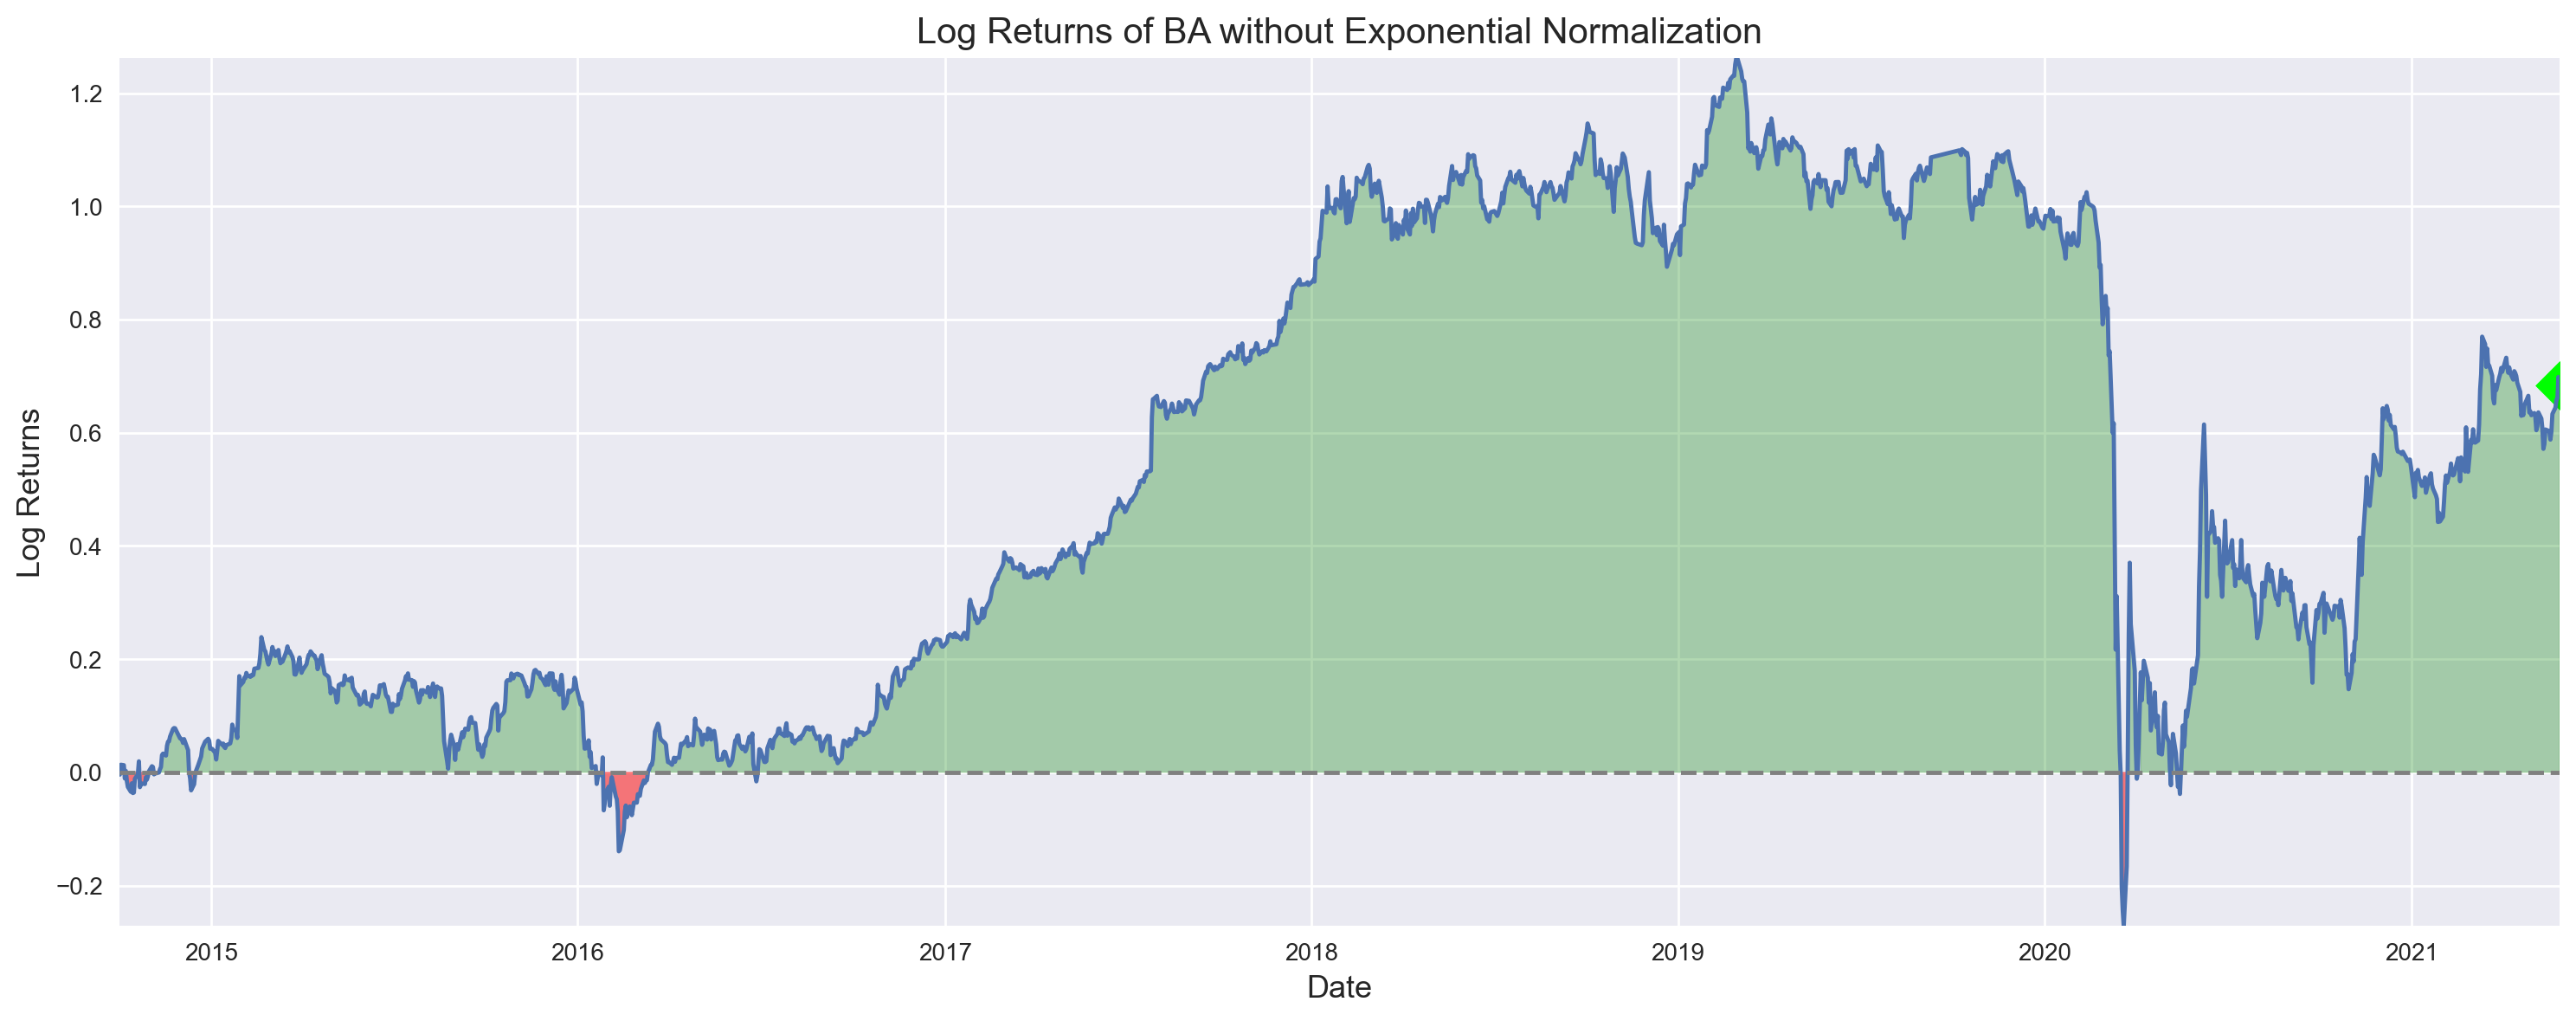

In [ ]:
fig , ax = plt.subplots(figsize = (15, 6))
ax.plot(ba.index, ba.log_ret.cumsum())
ax.scatter(ba.index[-1] , ba.log_ret.sum() , color = "lime" , s = 200 , marker = "D")
ax.axhline(y = 0, color = "red" , ls = "--" , c ="grey")
ax.fill_between(x = ba.index , y1 = ba.log_ret.cumsum() , y2 = 0 , where = (ba.log_ret.cumsum() > 0) , color = "green" , alpha = 0.3)
ax.fill_between(x = ba.index , y1 = ba.log_ret.cumsum() , y2 = 0 , where = (ba.log_ret.cumsum() < 0) , color = "red" , alpha = 0.5)
ax.set_title("Log Returns of BA without Exponential Normalization", fontsize = 15)
ax.set_xlabel("Date", fontsize = 13)
ax.set_ylabel("Log Returns", fontsize = 13)
ax.autoscale(True, axis = "both", tight = True)
plt.tight_layout()
plt.show()

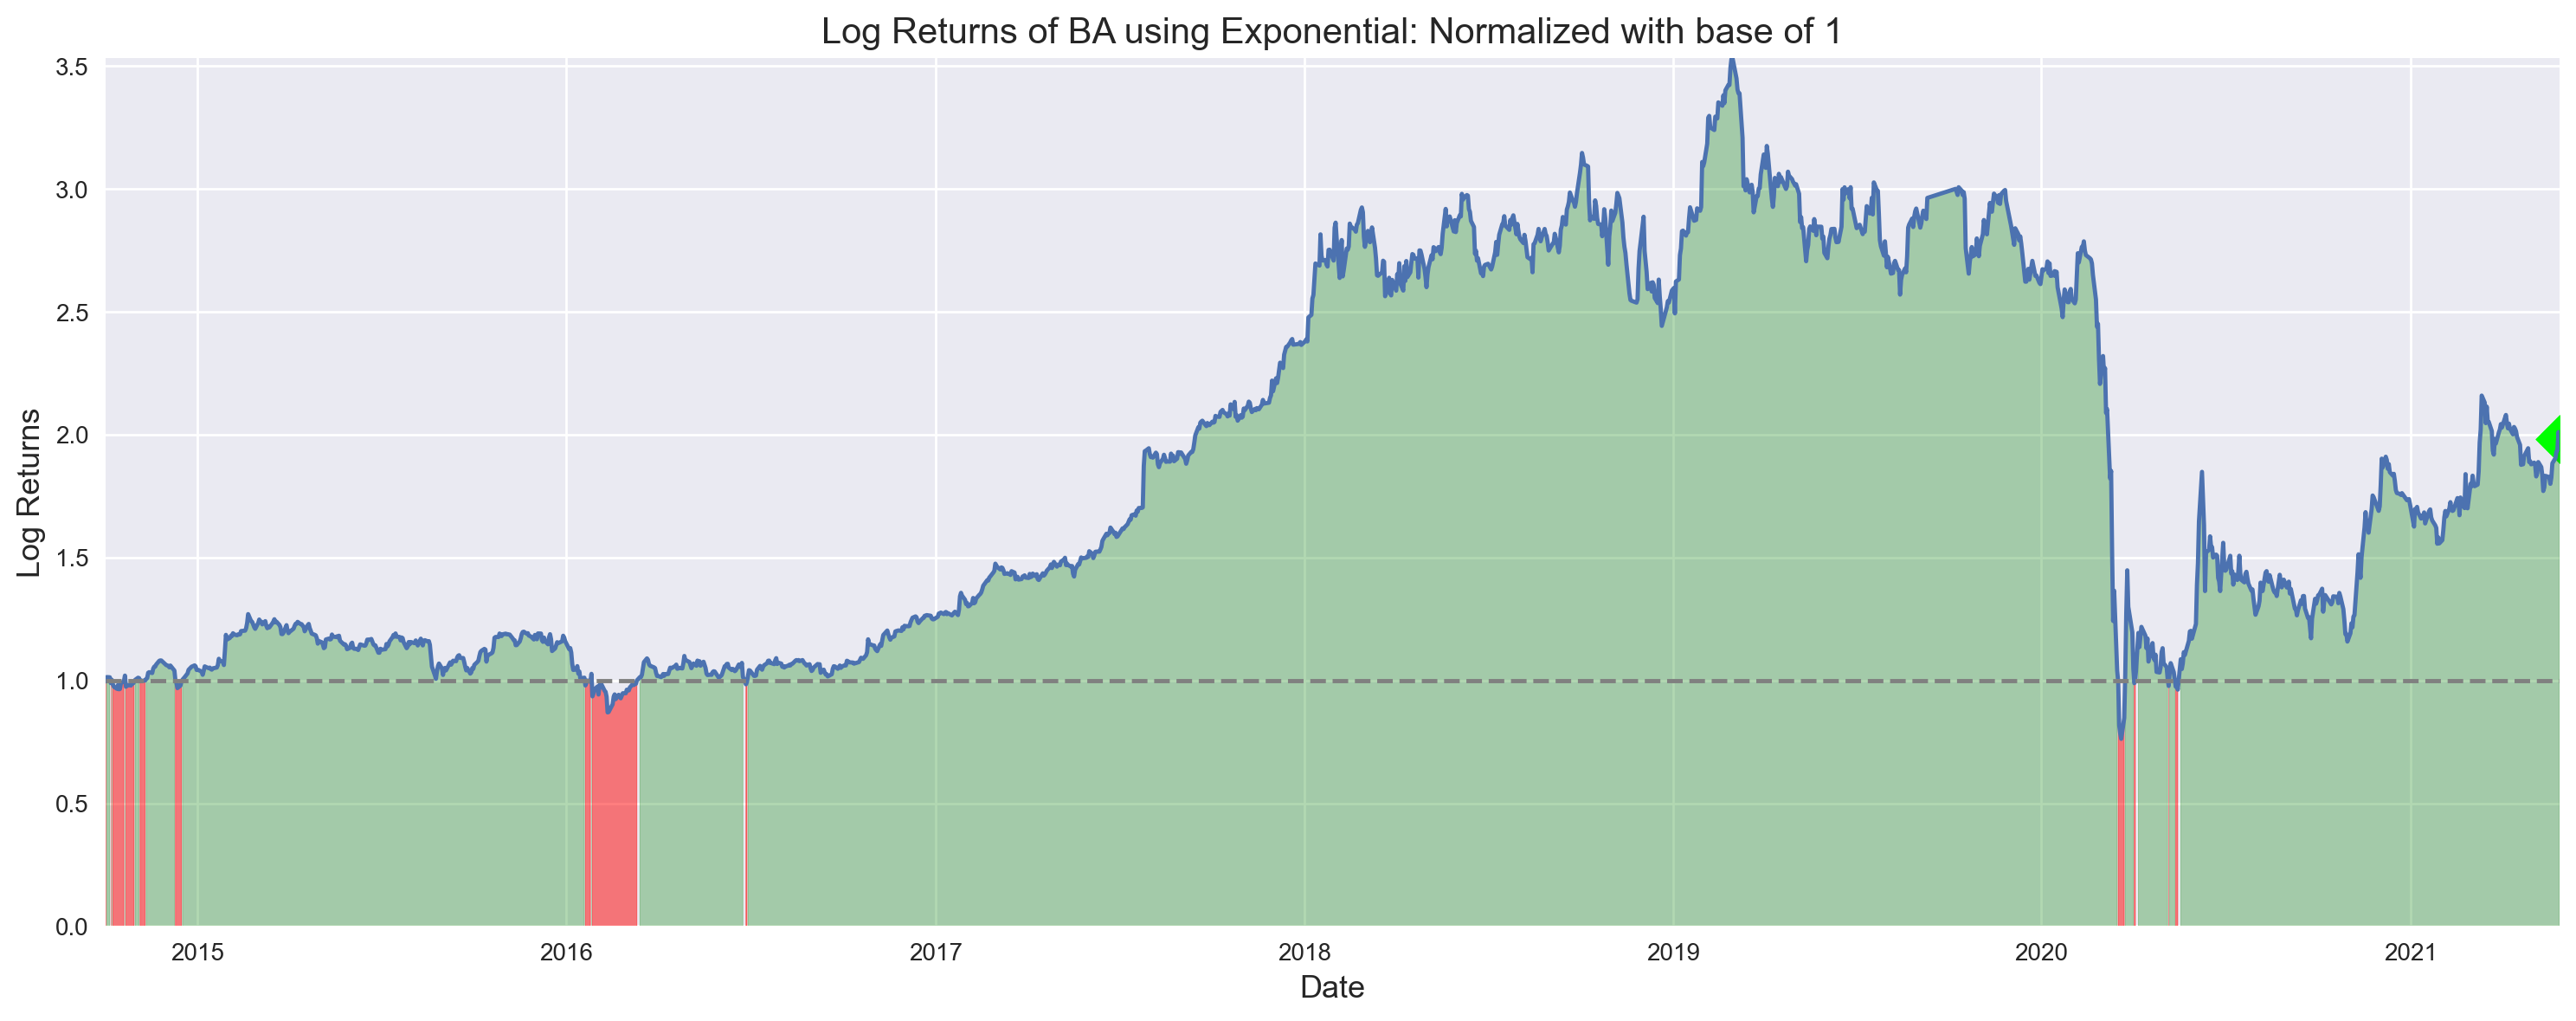

In [ ]:
fig , ax = plt.subplots(figsize = (15, 6))
ax.plot(ba.index, np.exp(ba.log_ret.cumsum()))
ax.scatter(ba.index[-1] , np.exp(ba.log_ret.sum()) , color = "lime" , s = 200 , marker = "D")
ax.axhline(y = 1, color = "red" , ls = "--" , c ="grey")
ax.fill_between(x = ba.index , y1 = np.exp(ba.log_ret.cumsum()) , y2 = 0 , where = (np.exp(ba.log_ret.cumsum()) > 1) , color = "green" , alpha = 0.3)
ax.fill_between(x = ba.index , y1 = np.exp(ba.log_ret.cumsum()) , y2 = 0 , where = (np.exp(ba.log_ret.cumsum()) < 1) , color = "red" , alpha = 0.5)
ax.set_title("Log Returns of BA using Exponential: Normalized with base of 1", fontsize = 15)
ax.set_xlabel("Date", fontsize = 13)
ax.set_ylabel("Log Returns", fontsize = 13)
ax.autoscale(True, axis = "both", tight = True)
plt.tight_layout()
plt.show()

In [ ]:
np.exp(ba.log_ret.sum())

np.float64(1.9813909352730907)

---------------------------------------------

## Performance Comparison

__General Rule in Finance/Investing: Higher Risk must be rewarded with higher Returns__.

__Which instrument(s) performed best/worst in the past in terms of risk & return?__

In [ ]:
import pandas as pd
import numpy as np
pd.options.display.float_format = '{:.4f}'.format
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [ ]:
close = pd.read_csv("close.csv", index_col = "Date", parse_dates = ["Date"])
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,124.669998,383.614990,1.262834,1214.599976,45.900002,16804.710938
2014-10-02,124.169998,375.071991,1.262419,1214.199951,45.759998,16801.050781
2014-10-03,126.360001,359.511993,1.267058,1192.199951,46.090000,17009.689453
2014-10-06,126.260002,330.079010,1.251361,1206.699951,46.090000,16991.910156
2014-10-07,123.320000,336.187012,1.264606,1211.699951,45.529999,16719.390625
...,...,...,...,...,...,...
2021-05-24,237.440002,38705.980469,1.218324,1884.599976,250.779999,34393.980469
2021-05-25,240.740005,38402.222656,1.221464,1898.099976,251.720001,34312.460938
2021-05-26,241.369995,39294.199219,1.224909,1901.300049,251.490005,34323.050781


In [ ]:
close.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1635 entries, 2014-10-01 to 2021-05-28
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BA        1635 non-null   float64
 1   BTC-USD   1635 non-null   float64
 2   EURUSD=X  1635 non-null   float64
 3   GC=F      1635 non-null   float64
 4   MSFT      1635 non-null   float64
 5   ^DJI      1635 non-null   float64
dtypes: float64(6)
memory usage: 89.4 KB


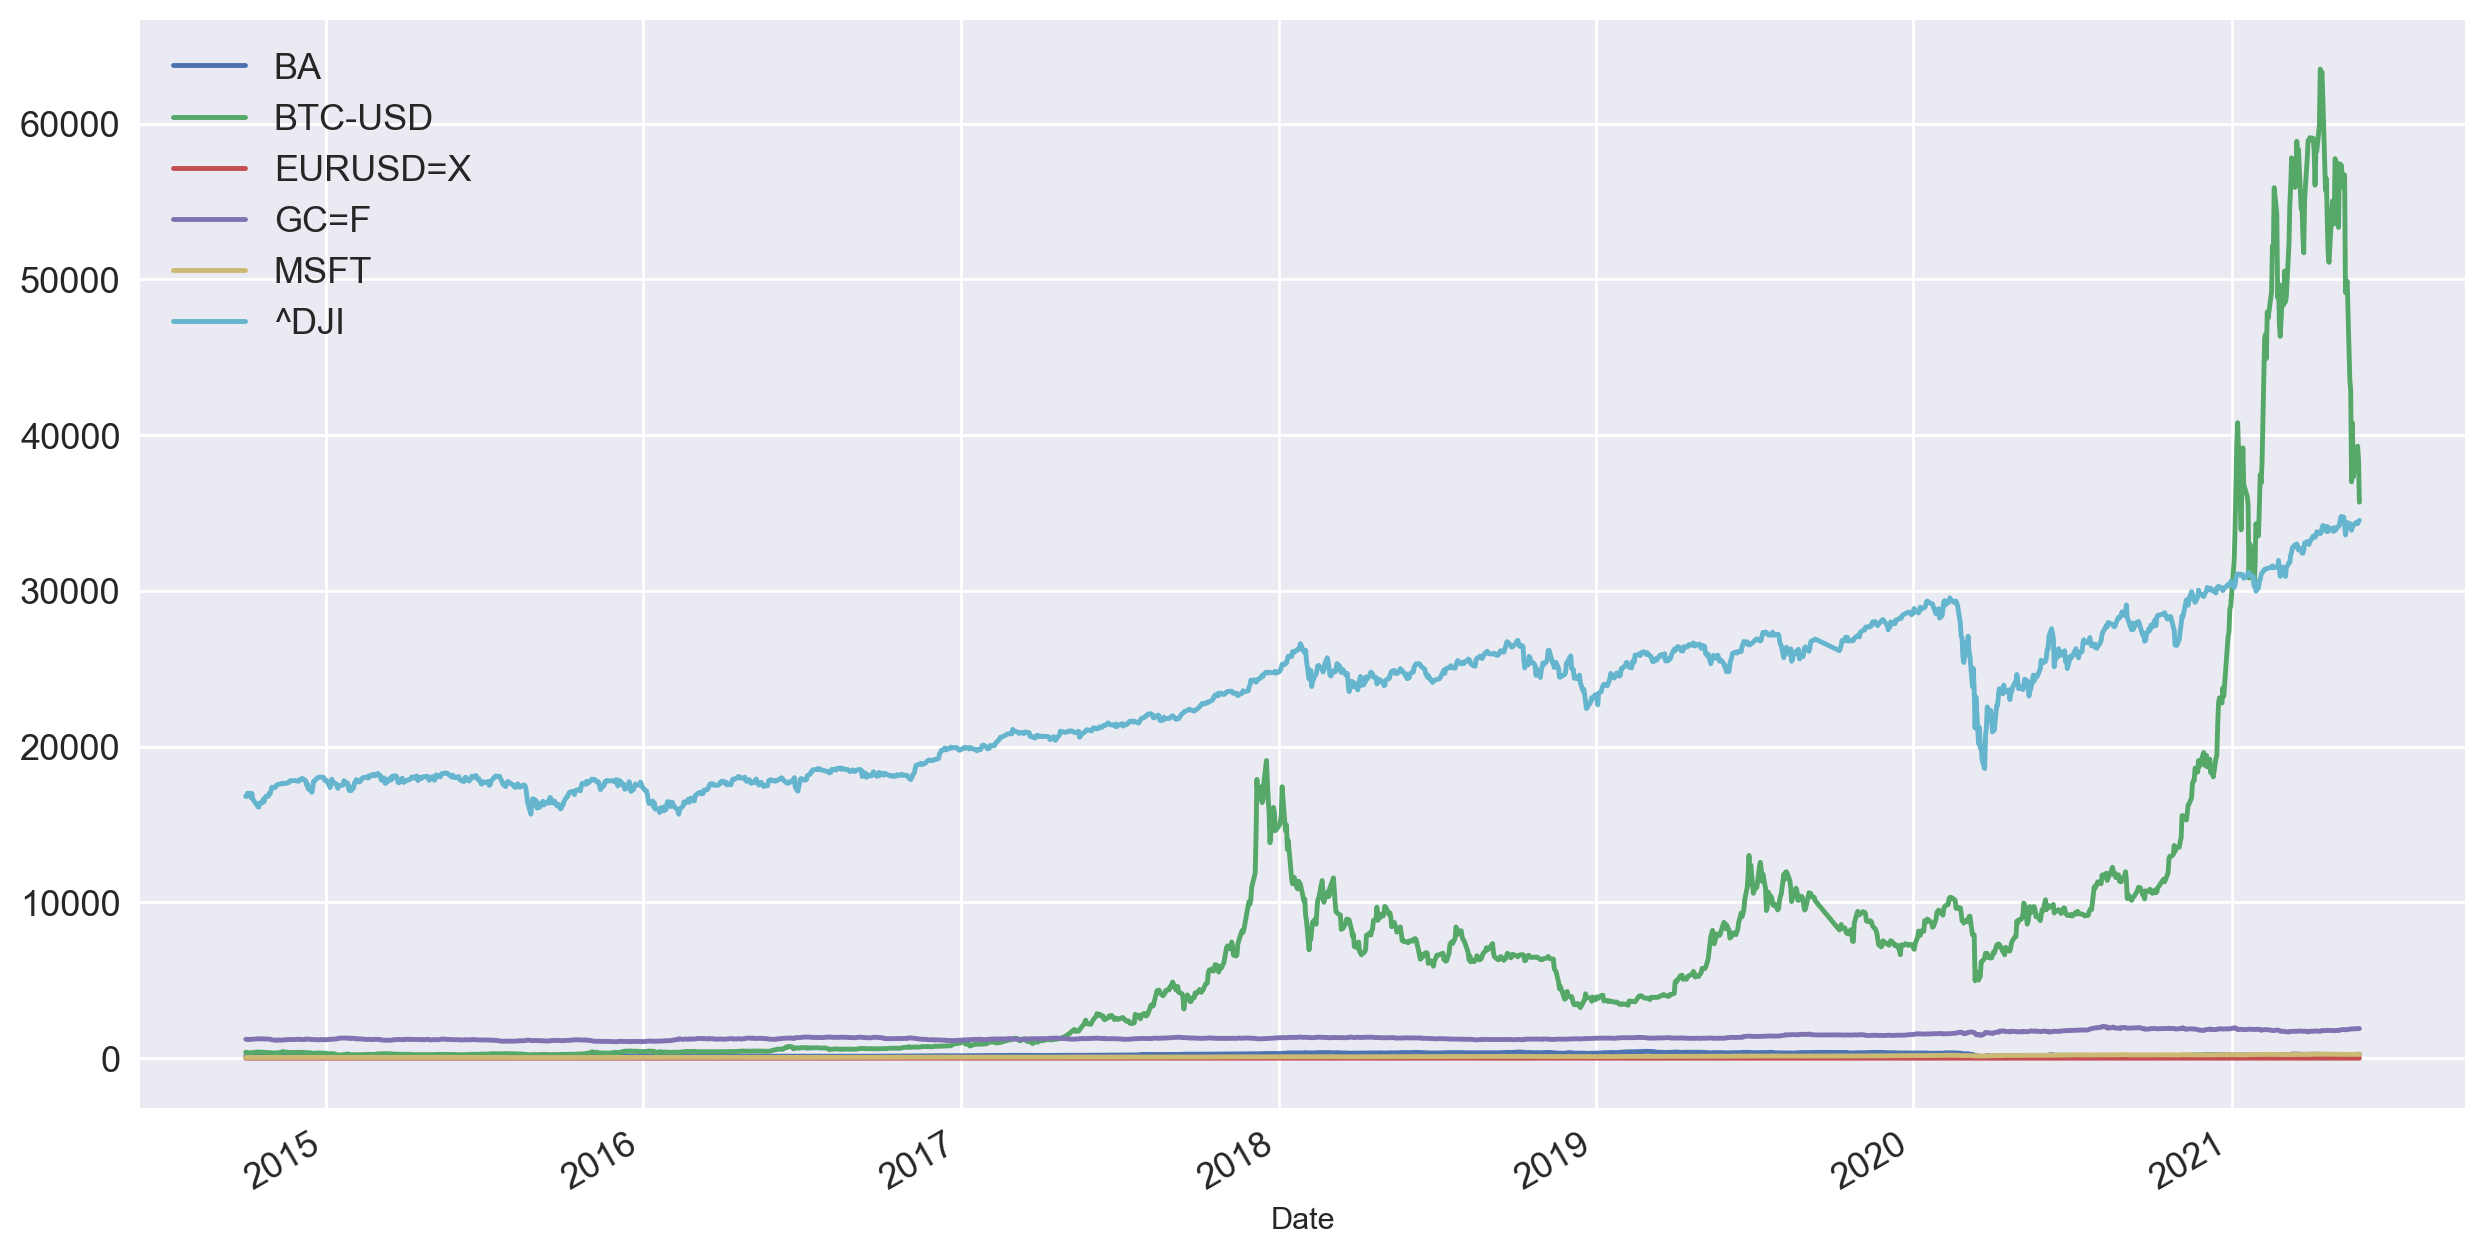

In [ ]:
close.dropna().plot(figsize = (15, 8), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

In [ ]:
np.log(close / close.shift()).info() # keep NaN

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1635 entries, 2014-10-01 to 2021-05-28
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BA        1634 non-null   float64
 1   BTC-USD   1634 non-null   float64
 2   EURUSD=X  1634 non-null   float64
 3   GC=F      1634 non-null   float64
 4   MSFT      1634 non-null   float64
 5   ^DJI      1634 non-null   float64
dtypes: float64(6)
memory usage: 89.4 KB


In [ ]:
close.apply(lambda x: np.log(x.dropna() / x.dropna().shift())).info() # remove NaN

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1635 entries, 2014-10-01 to 2021-05-28
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BA        1634 non-null   float64
 1   BTC-USD   1634 non-null   float64
 2   EURUSD=X  1634 non-null   float64
 3   GC=F      1634 non-null   float64
 4   MSFT      1634 non-null   float64
 5   ^DJI      1634 non-null   float64
dtypes: float64(6)
memory usage: 89.4 KB


In [ ]:
returns = close.apply(lambda x: np.log(x.dropna() / x.dropna().shift()))
returns = returns.dropna()
returns
#returns = returns.map(lambda x: {":.2%"}.format(x))

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-02,-0.0040,-0.0225,-0.0003,-0.0003,-0.0031,-0.0002
2014-10-03,0.0175,-0.0424,0.0037,-0.0183,0.0072,0.0123
2014-10-06,-0.0008,-0.0854,-0.0125,0.0121,0.0000,-0.0010
2014-10-07,-0.0236,0.0183,0.0105,0.0041,-0.0122,-0.0162
2014-10-08,0.0134,0.0486,0.0017,-0.0053,0.0271,0.0163
...,...,...,...,...,...,...
2021-05-24,0.0111,0.0369,-0.0035,0.0042,0.0226,0.0054
2021-05-25,0.0138,-0.0079,0.0026,0.0071,0.0037,-0.0024
2021-05-26,0.0026,0.0230,0.0028,0.0017,-0.0009,0.0003


## There are two ways to dispaly the contents of a dataframe in %:
```
1. returns.map(lambda x: "{:.4%}".format(x))

2. returns.mul(100)


```

In [ ]:
returns.map(lambda x: "{:.4%}".format(x))

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-02,-0.4019%,-2.2521%,-0.0328%,-0.0329%,-0.3055%,-0.0218%
2014-10-03,1.7483%,-4.2370%,0.3668%,-1.8285%,0.7186%,1.2342%
2014-10-06,-0.0792%,-8.5415%,-1.2466%,1.2089%,0.0000%,-0.1046%
2014-10-07,-2.3561%,1.8336%,1.0529%,0.4135%,-1.2225%,-1.6168%
2014-10-08,1.3371%,4.8630%,0.1734%,-0.5296%,2.7084%,1.6304%
...,...,...,...,...,...,...
2021-05-24,1.1096%,3.6875%,-0.3454%,0.4201%,2.2624%,0.5427%
2021-05-25,1.3803%,-0.7879%,0.2574%,0.7138%,0.3741%,-0.2373%
2021-05-26,0.2613%,2.2962%,0.2817%,0.1685%,-0.0914%,0.0309%


In [ ]:
returns*100

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-02,-0.4019,-2.2521,-0.0328,-0.0329,-0.3055,-0.0218
2014-10-03,1.7483,-4.2370,0.3668,-1.8285,0.7186,1.2342
2014-10-06,-0.0792,-8.5415,-1.2466,1.2089,0.0000,-0.1046
2014-10-07,-2.3561,1.8336,1.0529,0.4135,-1.2225,-1.6168
2014-10-08,1.3371,4.8630,0.1734,-0.5296,2.7084,1.6304
...,...,...,...,...,...,...
2021-05-24,1.1096,3.6875,-0.3454,0.4201,2.2624,0.5427
2021-05-25,1.3803,-0.7879,0.2574,0.7138,0.3741,-0.2373
2021-05-26,0.2613,2.2962,0.2817,0.1685,-0.0914,0.0309


In [ ]:
returns = returns.mul(100)

In [ ]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1634 entries, 2014-10-02 to 2021-05-28
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BA        1634 non-null   float64
 1   BTC-USD   1634 non-null   float64
 2   EURUSD=X  1634 non-null   float64
 3   GC=F      1634 non-null   float64
 4   MSFT      1634 non-null   float64
 5   ^DJI      1634 non-null   float64
dtypes: float64(6)
memory usage: 89.4 KB


In [ ]:
returns.describe()

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
count,1634.0000,1634.0000,1634.0000,1634.0000,1634.0000,1634.0000
mean,0.0418,0.2774,-0.0021,0.0275,0.1037,0.0441
std,2.6372,4.7177,0.5292,0.9380,1.7331,1.1995
min,-27.2444,-46.4730,-2.8144,-5.1069,-15.9453,-13.8418
25%,-0.9223,-1.4567,-0.3198,-0.4185,-0.6139,-0.3266
50%,0.0752,0.2446,-0.0063,0.0225,0.0918,0.0752
75%,1.0536,2.1709,0.2995,0.5088,0.9112,0.5388
max,21.7677,22.5119,2.8145,5.7775,13.2929,10.7643


### 📝 Daily vs. Annualized Metrics: Quick Reference

*   **(Daily Summary):** 
    *   **Mean:** The raw, tiny daily crawl of the stock (e.g., 0.05%). Invisible to human perception due to market noise.
    *   **Std:** The daily "shake" or bounce of the price (e.g., 1-3%). Measures short-term daily noise.

*   **(Annualized Scale-Up):**
    *   **Mean (`* 252`):** Extrapolates daily growth to a full 1-year horizon. Used to compare against annual benchmarks (e.g., S&P 500 averages ~10%/year).
    *   **Std (`* sqrt(252)`):** Wall Street's standard definition of Volatility. Measures structural, long-term uncertainty over a one-year horizon.

*   **The Scaling Math:** 
    *   Log returns compound continuously, so expected return scales linearly (`* 252`).
    *   Variance (risk) scales linearly with time, so Standard Deviation scales by the square root of time (`* sqrt(252)`).

So let's define the daily `mean` and `std` on our returns:

In [ ]:
summary = returns.agg(["mean", "std"]).T
summary

,mean,std
BA,0.0418,2.6372
BTC-USD,0.2774,4.7177
EURUSD=X,-0.0021,0.5292
GC=F,0.0275,0.9380
MSFT,0.1037,1.7331
^DJI,0.0441,1.1995


In [ ]:
summary.columns = ["Mean", "Std"]
summary

,Mean,Std
BA,0.0418,2.6372
BTC-USD,0.2774,4.7177
EURUSD=X,-0.0021,0.5292
GC=F,0.0275,0.9380
MSFT,0.1037,1.7331
^DJI,0.0441,1.1995


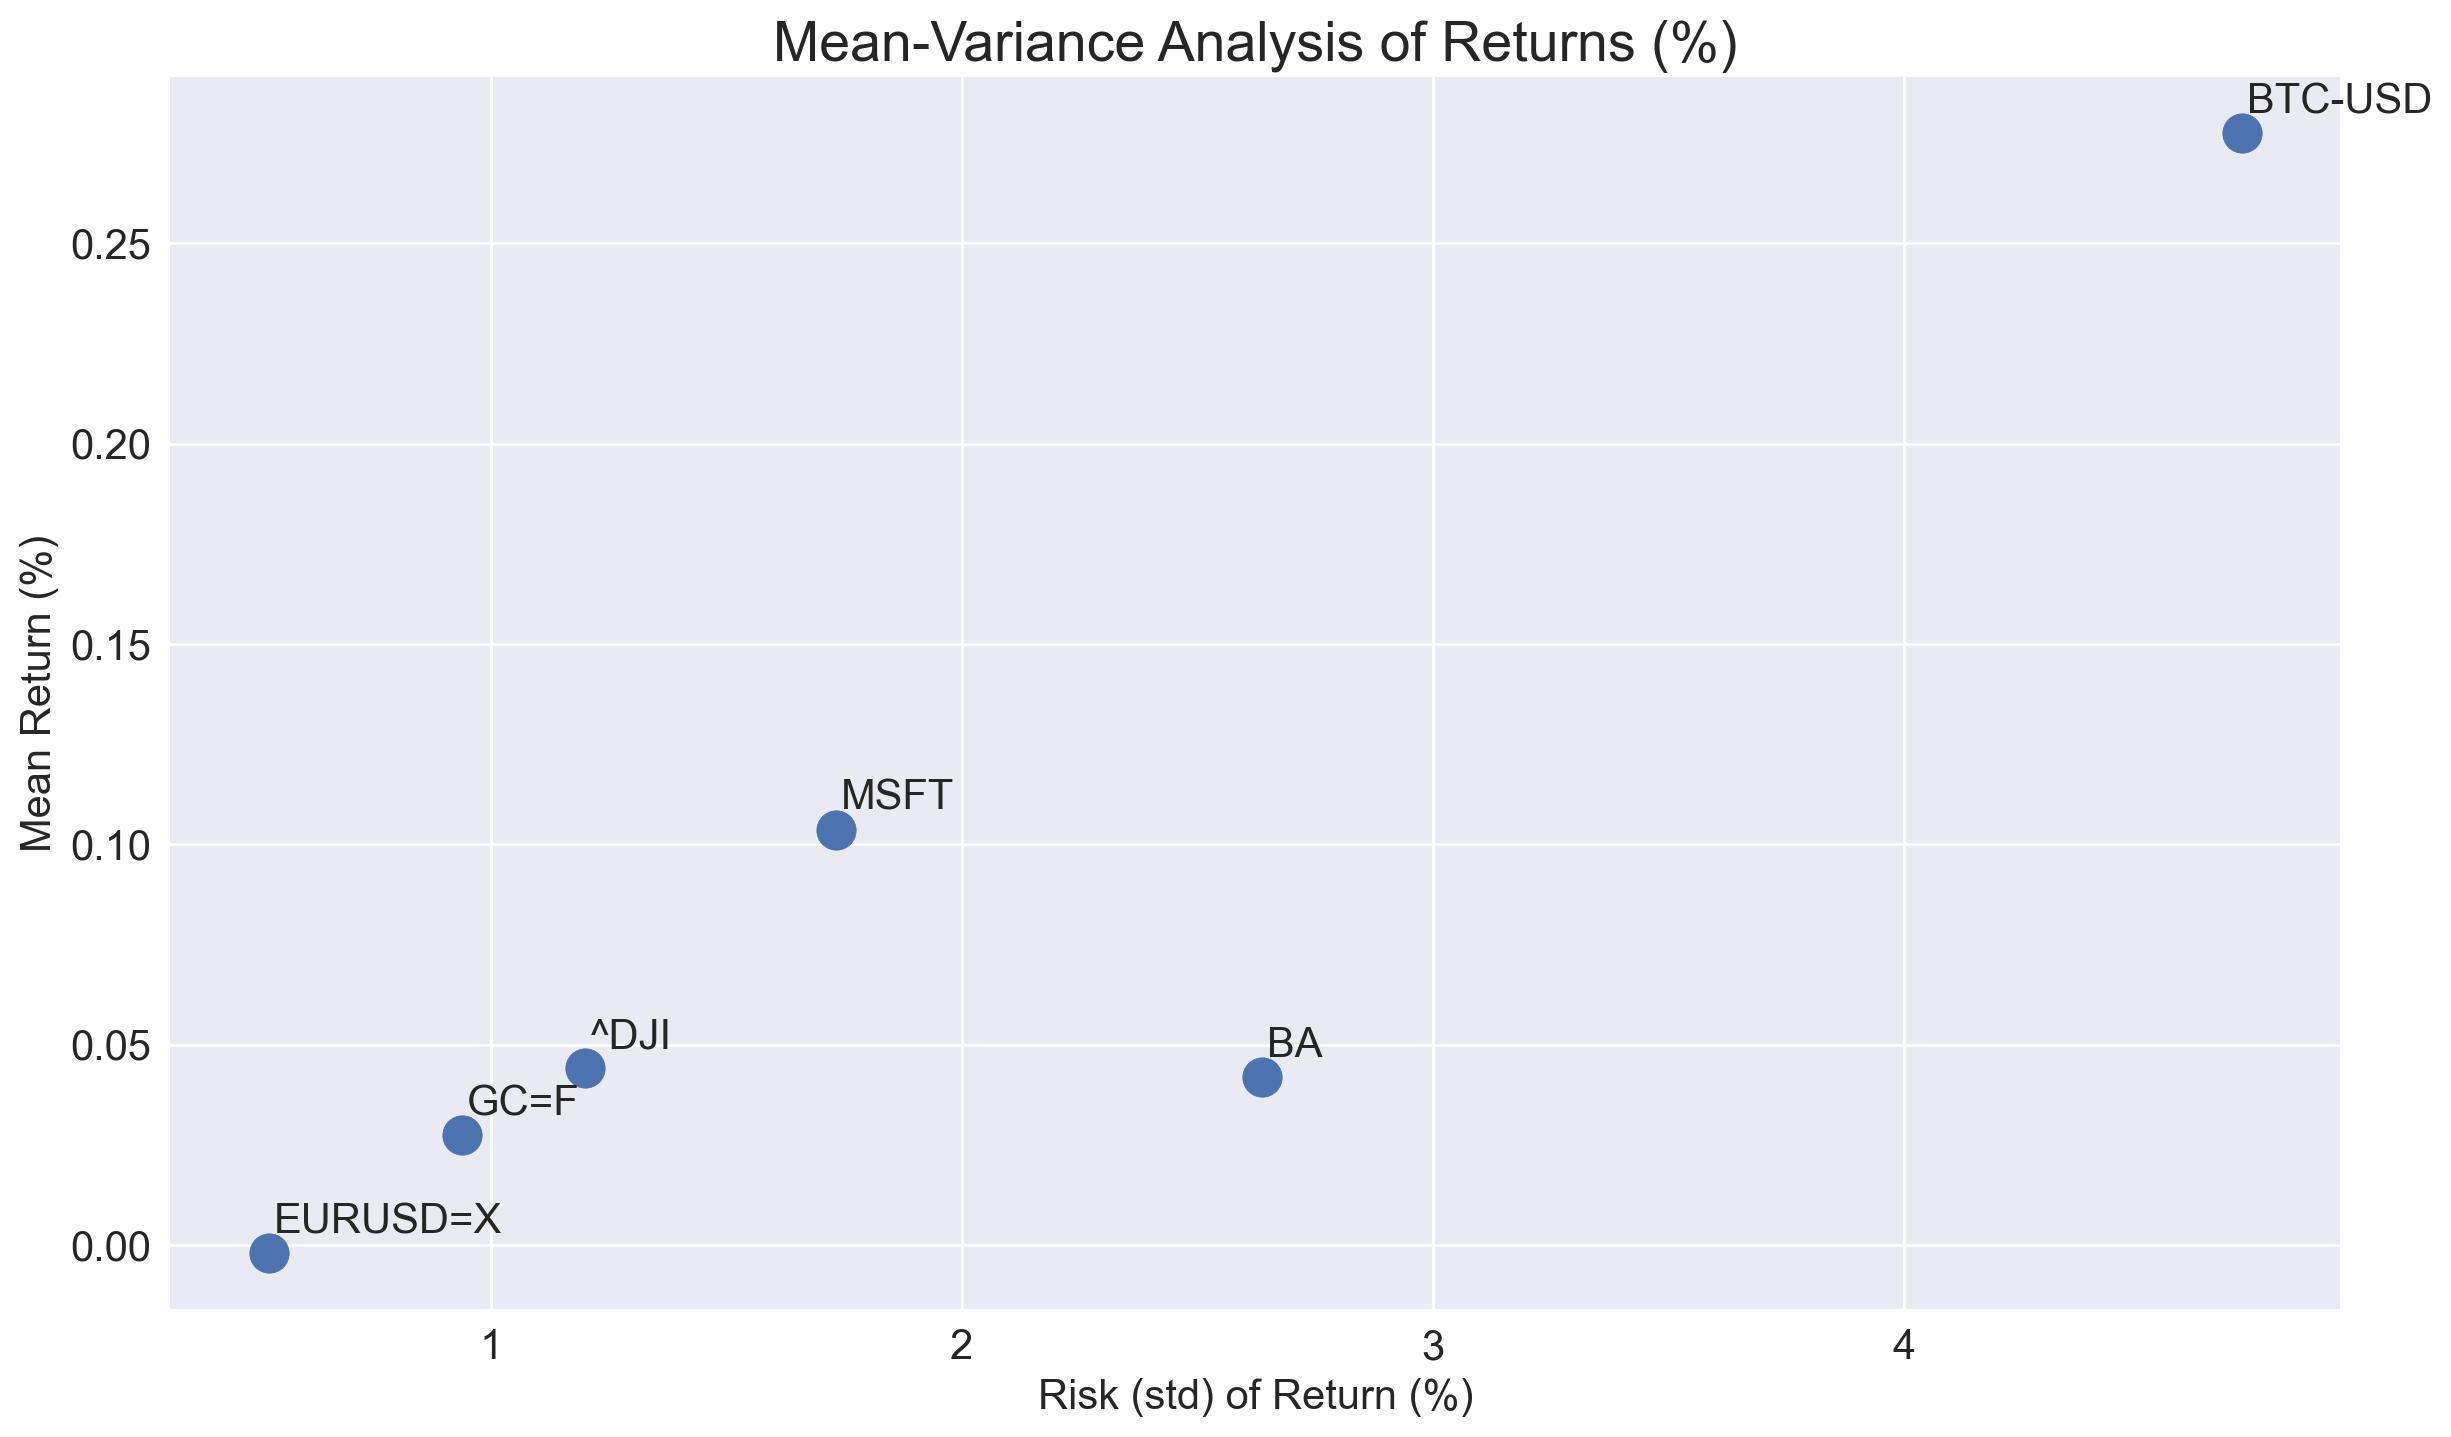

In [ ]:
summary.plot(kind = "scatter", x = "Std", y = "Mean", figsize = (14,8), s = 200, fontsize = 15)
for i in summary.index:
    plt.annotate(i, xy=(summary.loc[i, "Std"]+0.01, summary.loc[i, "Mean"]+0.01/2), size = 15)
plt.xlabel("Risk (std) of Return (%)", fontsize = 15)
plt.ylabel("Mean Return (%)", fontsize = 15)
plt.title("Mean-Variance Analysis of Returns (%)", fontsize = 20)
plt.show()

In [ ]:
def mean_var_analysis(df):
    ''' Mean-Variance Analysis of Returns (%)  
    Args:
        df (pandas.DataFrame): DataFrame of stock prices
    Returns:
        matplotlib.pyplot.Figure
    '''
    log_returns = df.apply(lambda x:np.log(x.dropna()/x.dropna().shift(1)))
    summary = log_returns.agg(["mean", "std"]).T
    summary.columns = ["Mean", "Std"]
    summary.plot(kind = "scatter", x = "Std", y = "Mean", figsize = (14,8), s = 200, fontsize = 15) 
    for i in summary.index:
        plt.annotate(i, xy=(summary.loc[i, "Std"]+0.01, summary.loc[i, "Mean"]+0.01), size = 12)
    plt.xlabel("Risk (std) of Return (%)", fontsize = 15)
    plt.ylabel("Mean Return (%)", fontsize = 15)
    plt.title("Mean-Variance Analysis of Returns (%)", fontsize = 20)
    plt.show()

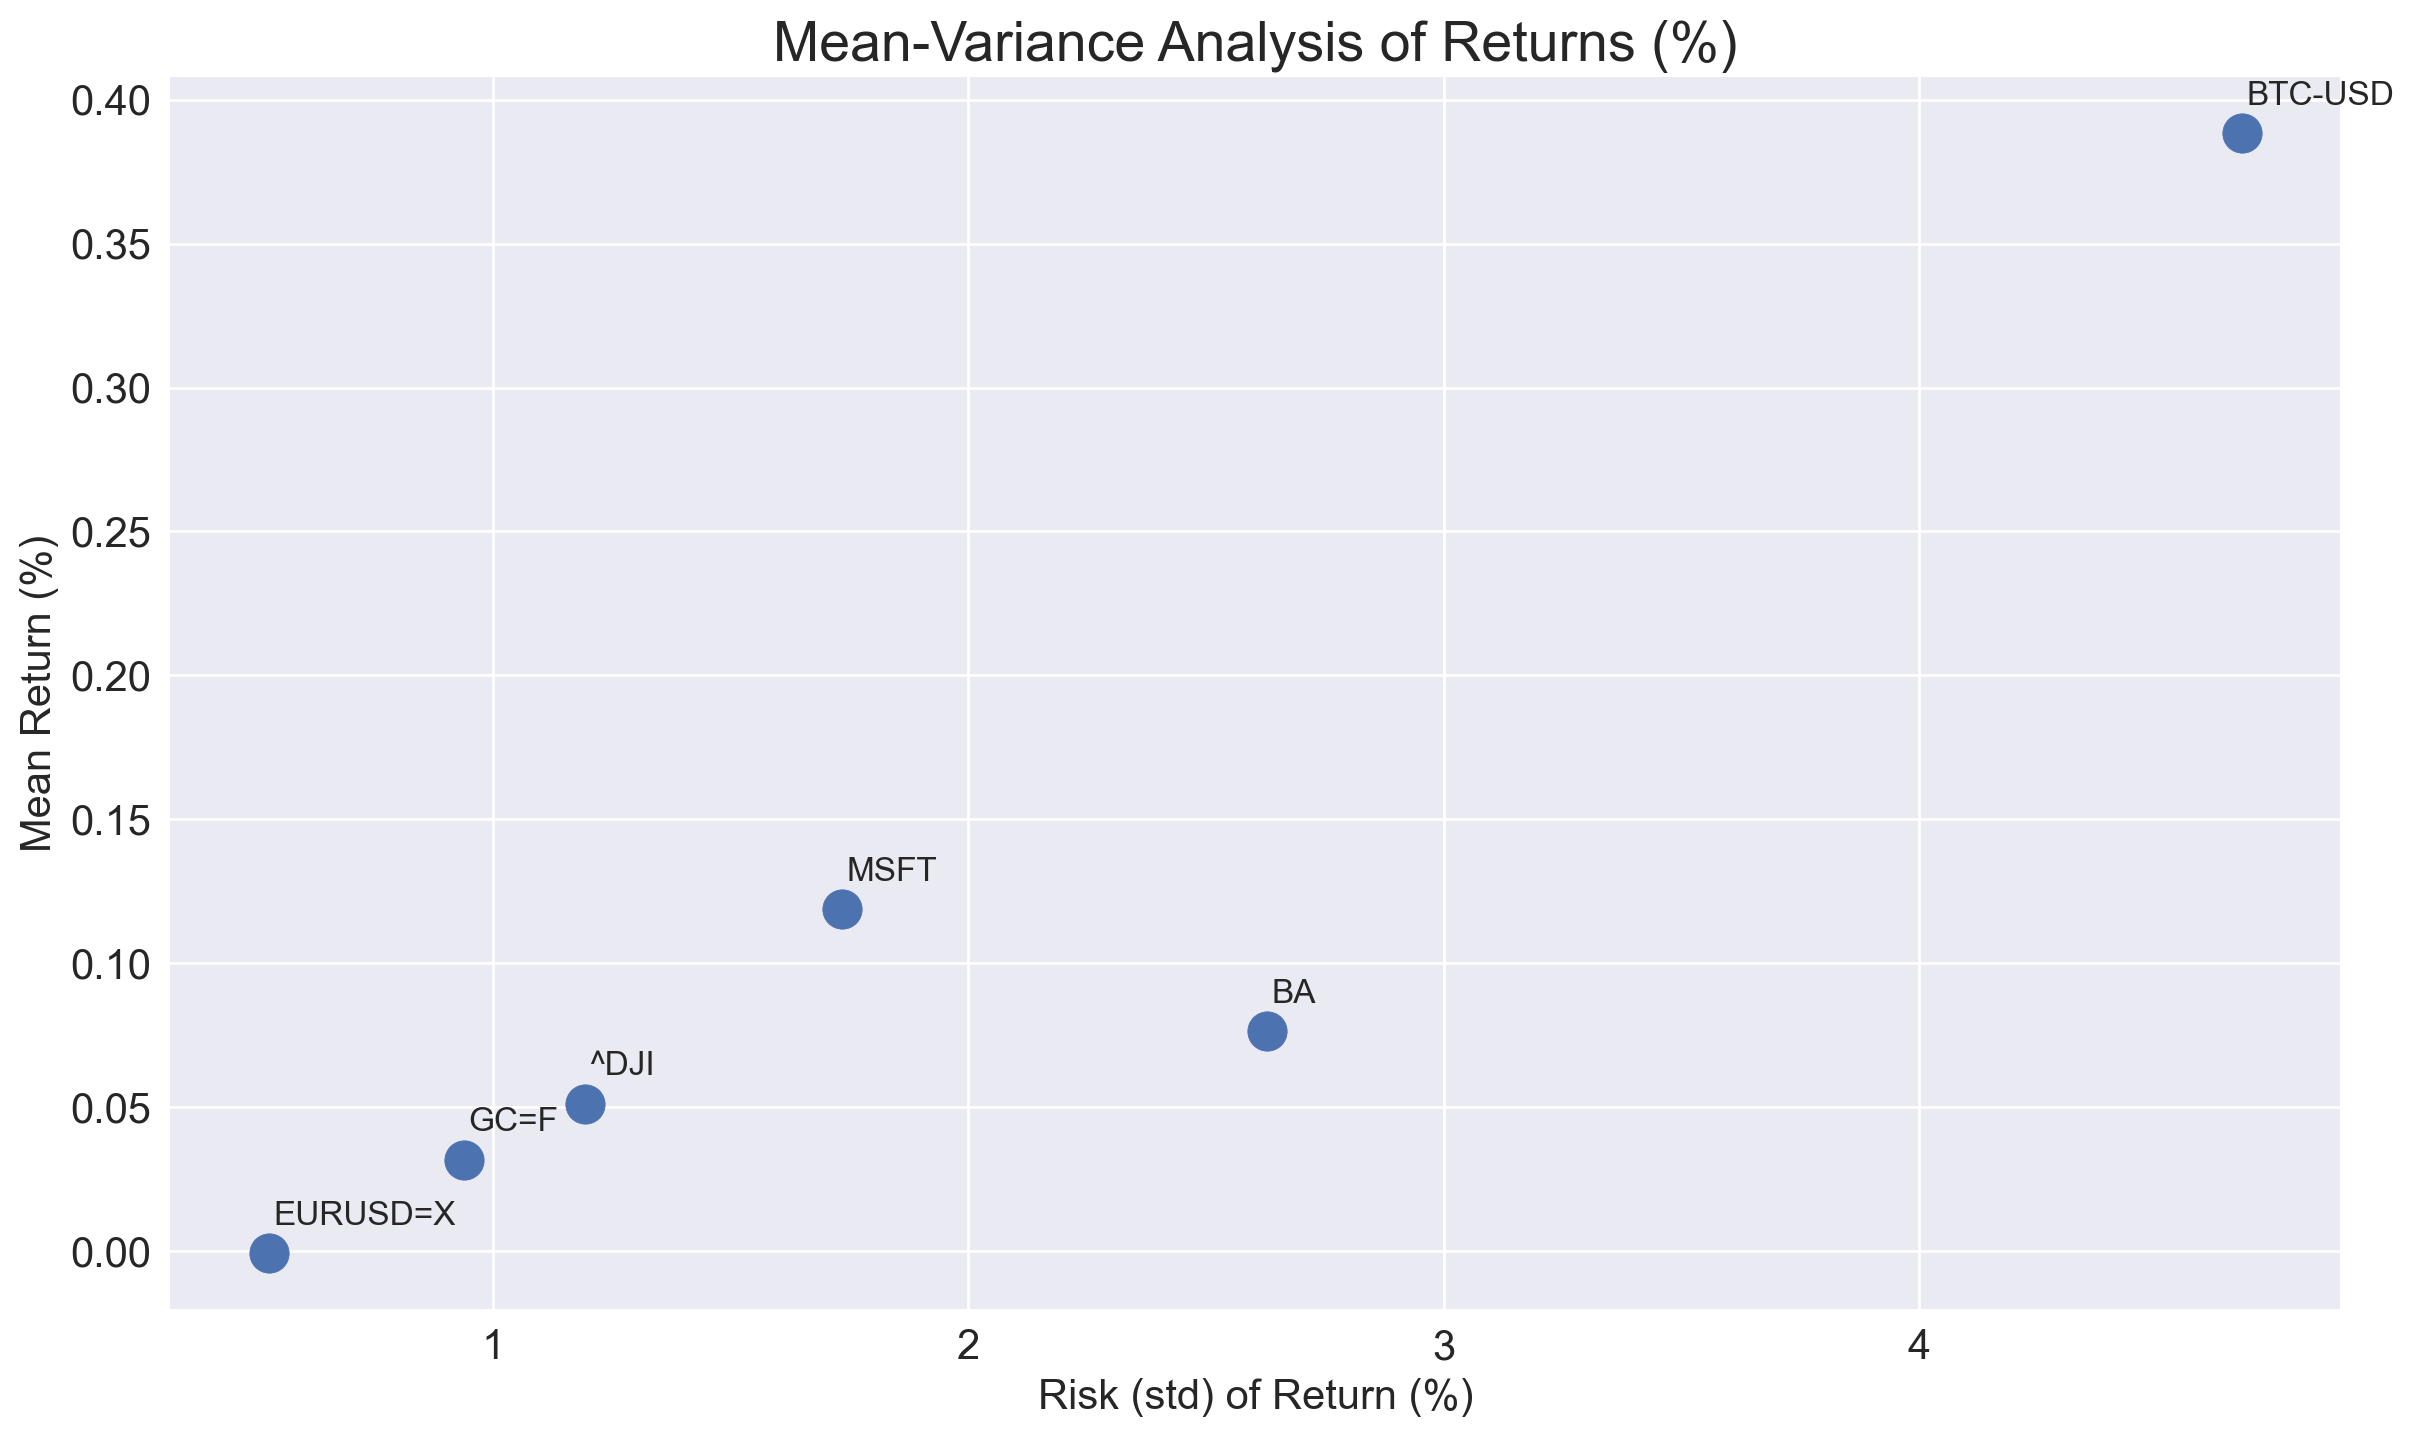

In [ ]:
mean_var_analysis(close)

-> There is __no clear "best-performer"__ among ["EURUSD=X", "GC=F", "^DJI", "MSFT", "BTC-USD"] (without further analysis). __Higher risk__ is getting rewarded with __higher returns__. __BA underperformed__.

__Take Home: Mean-Variance Analysis has one major shortcoming: It assumes that financial returns follow a Normal Distribution. That´s (typically) not True.<br> -> Standard Deviation of Returns underestimates the true/full risk of an Investment as it fails to measure "Tail Risks".__ 

## Price Return vs. Total Return (Equities)

Recap:

__Total Return = Price Return + Dividend Yield__ (good approx.: __Adjusted Close Price__)

In [ ]:
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,124.669998,383.614990,1.262834,1214.599976,45.900002,16804.710938
2014-10-02,124.169998,375.071991,1.262419,1214.199951,45.759998,16801.050781
2014-10-03,126.360001,359.511993,1.267058,1192.199951,46.090000,17009.689453
2014-10-06,126.260002,330.079010,1.251361,1206.699951,46.090000,16991.910156
2014-10-07,123.320000,336.187012,1.264606,1211.699951,45.529999,16719.390625
...,...,...,...,...,...,...
2021-05-24,237.440002,38705.980469,1.218324,1884.599976,250.779999,34393.980469
2021-05-25,240.740005,38402.222656,1.221464,1898.099976,251.720001,34312.460938
2021-05-26,241.369995,39294.199219,1.224909,1901.300049,251.490005,34323.050781


In [ ]:
df = pd.read_csv("multi_assets.csv", header = [0, 1], index_col = 0, parse_dates = [0])["Adj Close"]
df

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,108.406662,383.614990,1.262834,1214.599976,40.333351,16804.710938
2014-10-02,107.971893,375.071991,1.262419,1214.199951,40.210331,16801.050781
2014-10-03,109.876213,359.511993,1.267058,1192.199951,40.500313,17009.689453
2014-10-04,NaN,328.865997,NaN,NaN,NaN,NaN
2014-10-05,NaN,320.510010,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2021-05-27,250.699997,38436.968750,1.219260,1895.699951,249.309998,34464.640625
2021-05-28,247.020004,35697.605469,1.219319,1902.500000,249.679993,34529.449219
2021-05-29,NaN,34616.066406,NaN,NaN,NaN,NaN


In [ ]:
close["BA_TR"] = df.BA
close["MSFT_TR"] = df.MSFT

In [ ]:
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,BA_TR,MSFT_TR
Date,,,,,,,,
2014-10-01,124.669998,383.614990,1.262834,1214.599976,45.900002,16804.710938,108.406662,40.333351
2014-10-02,124.169998,375.071991,1.262419,1214.199951,45.759998,16801.050781,107.971893,40.210331
2014-10-03,126.360001,359.511993,1.267058,1192.199951,46.090000,17009.689453,109.876213,40.500313
2014-10-06,126.260002,330.079010,1.251361,1206.699951,46.090000,16991.910156,109.789253,40.500313
2014-10-07,123.320000,336.187012,1.264606,1211.699951,45.529999,16719.390625,107.232796,40.008217
...,...,...,...,...,...,...,...,...
2021-05-24,237.440002,38705.980469,1.218324,1884.599976,250.779999,34393.980469,237.440002,250.779999
2021-05-25,240.740005,38402.222656,1.221464,1898.099976,251.720001,34312.460938,240.740005,251.720001
2021-05-26,241.369995,39294.199219,1.224909,1901.300049,251.490005,34323.050781,241.369995,251.490005


In [ ]:
returns = close.apply(lambda x: np.log(x.dropna() / x.dropna().shift()))
returns

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,BA_TR,MSFT_TR
Date,,,,,,,,
2014-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-10-02,-0.004019,-0.022521,-0.000328,-0.000329,-0.003055,-0.000218,-0.004019,-0.003055
2014-10-03,0.017483,-0.042370,0.003668,-0.018285,0.007186,0.012342,0.017483,0.007186
2014-10-06,-0.000792,-0.085415,-0.012466,0.012089,0.000000,-0.001046,-0.000792,0.000000
2014-10-07,-0.023561,0.018336,0.010529,0.004135,-0.012225,-0.016168,-0.023561,-0.012225
...,...,...,...,...,...,...,...,...
2021-05-24,0.011096,0.036875,-0.003454,0.004201,0.022624,0.005427,0.011096,0.022624
2021-05-25,0.013803,-0.007879,0.002574,0.007138,0.003741,-0.002373,0.013803,0.003741
2021-05-26,0.002613,0.022962,0.002817,0.001685,-0.000914,0.000309,0.002613,-0.000914


In [ ]:
summary = returns.dropna().agg(["mean", "std"]).T
summary

,mean,std
BA,0.000418,0.026372
BTC-USD,0.002774,0.047177
EURUSD=X,-0.000021,0.005292
GC=F,0.000275,0.009380
MSFT,0.001037,0.017331
^DJI,0.000441,0.011995
BA_TR,0.000504,0.026348
MSFT_TR,0.001116,0.017314


In [ ]:
summary.columns = ["Mean", "Std"]
summary

,Mean,Std
BA,0.000418,0.026372
BTC-USD,0.002774,0.047177
EURUSD=X,-0.000021,0.005292
GC=F,0.000275,0.009380
MSFT,0.001037,0.017331
^DJI,0.000441,0.011995
BA_TR,0.000504,0.026348
MSFT_TR,0.001116,0.017314


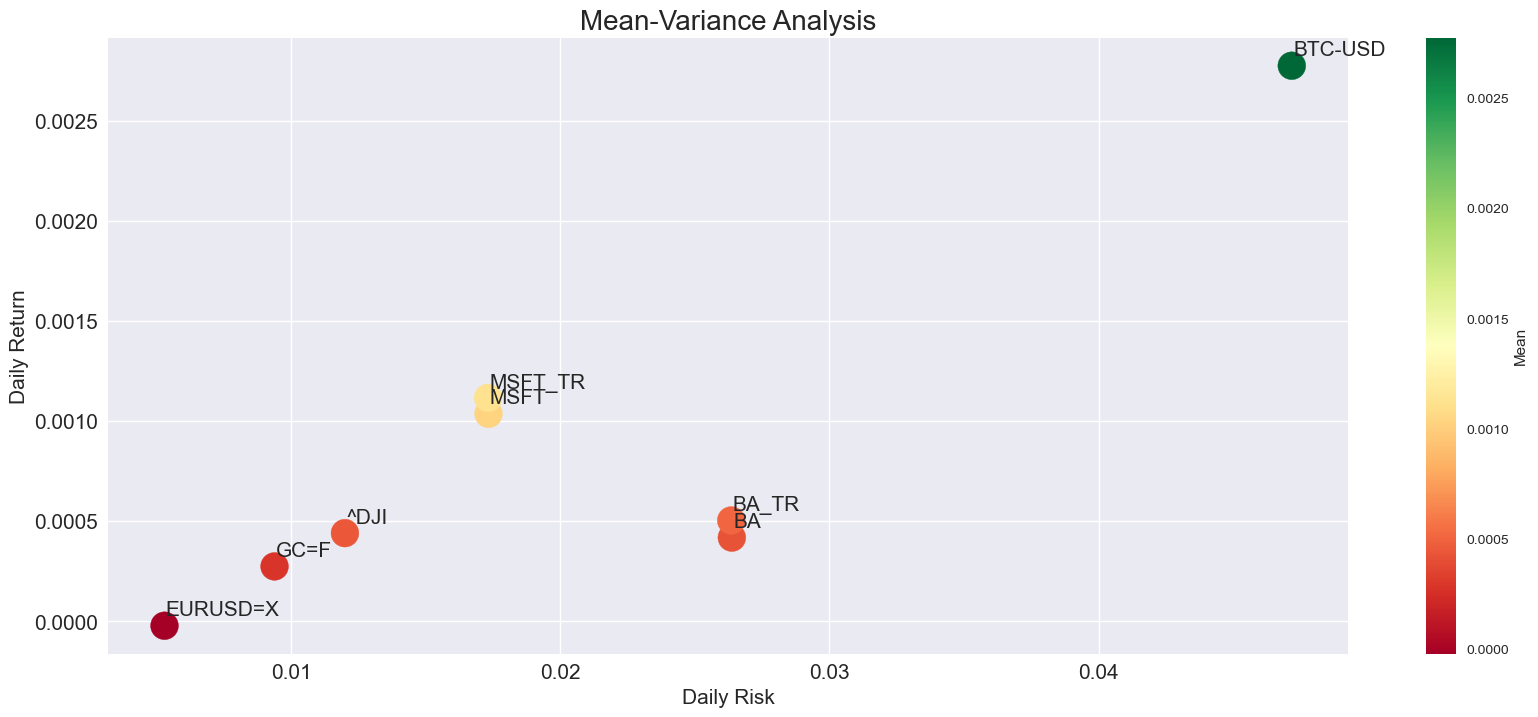

In [ ]:
summary.plot(kind = "scatter", x = "Std", y = "Mean", figsize = (20,8), c = "Mean", cmap = "RdYlGn",s = 400 , fontsize = 15)
for i in summary.index:
    plt.annotate(i, xy=(summary.loc[i, "Std"]+0.00005, summary.loc[i, "Mean"]+0.00005), size = 15)
plt.xlabel("Daily Risk", fontsize = 15)
plt.ylabel("Daily Return", fontsize = 15)
plt.title("Mean-Variance Analysis", fontsize = 20)
plt.show()

-> __Don´t omit Dividends!__

## Normality of Financial Returns 

In [ ]:
import pandas as pd
import numpy as np
pd.options.display.float_format = '{:.4f}'.format
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
%config InlineBackend.figure_format = 'retina'

In [ ]:
msft = pd.read_csv("msft.csv", index_col = "Date", parse_dates = ["Date"])
msft

,Price,Returns
Date,,
2014-10-01,45.9000,NaN
2014-10-02,45.7600,-0.3050
2014-10-03,46.0900,0.7212
2014-10-06,46.0900,0.0000
2014-10-07,45.5300,-1.2150
...,...,...
2021-05-24,250.7800,2.2882
2021-05-25,251.7200,0.3748
2021-05-26,251.4900,-0.0914


In [ ]:
msft["log_ret"] = np.log(msft.Price / msft.Price.shift()) 
msft

,Price,Returns,log_ret
Date,,,
2014-10-01,45.9000,NaN,NaN
2014-10-02,45.7600,-0.3050,-0.0031
2014-10-03,46.0900,0.7212,0.0072
2014-10-06,46.0900,0.0000,0.0000
2014-10-07,45.5300,-1.2150,-0.0122
...,...,...,...
2021-05-24,250.7800,2.2882,0.0226
2021-05-25,251.7200,0.3748,0.0037
2021-05-26,251.4900,-0.0914,-0.0009


In [ ]:
msft.describe()

,Price,Returns,log_ret
count,1635.0000,1634.0000,1634.0000
mean,105.6719,0.1187,0.0010
std,60.9903,1.7336,0.0173
min,40.2900,-14.7390,-0.1595
25%,54.4100,-0.6120,-0.0061
50%,88.0000,0.0918,0.0009
75%,138.6950,0.9154,0.0091
max,261.9700,14.2169,0.1329


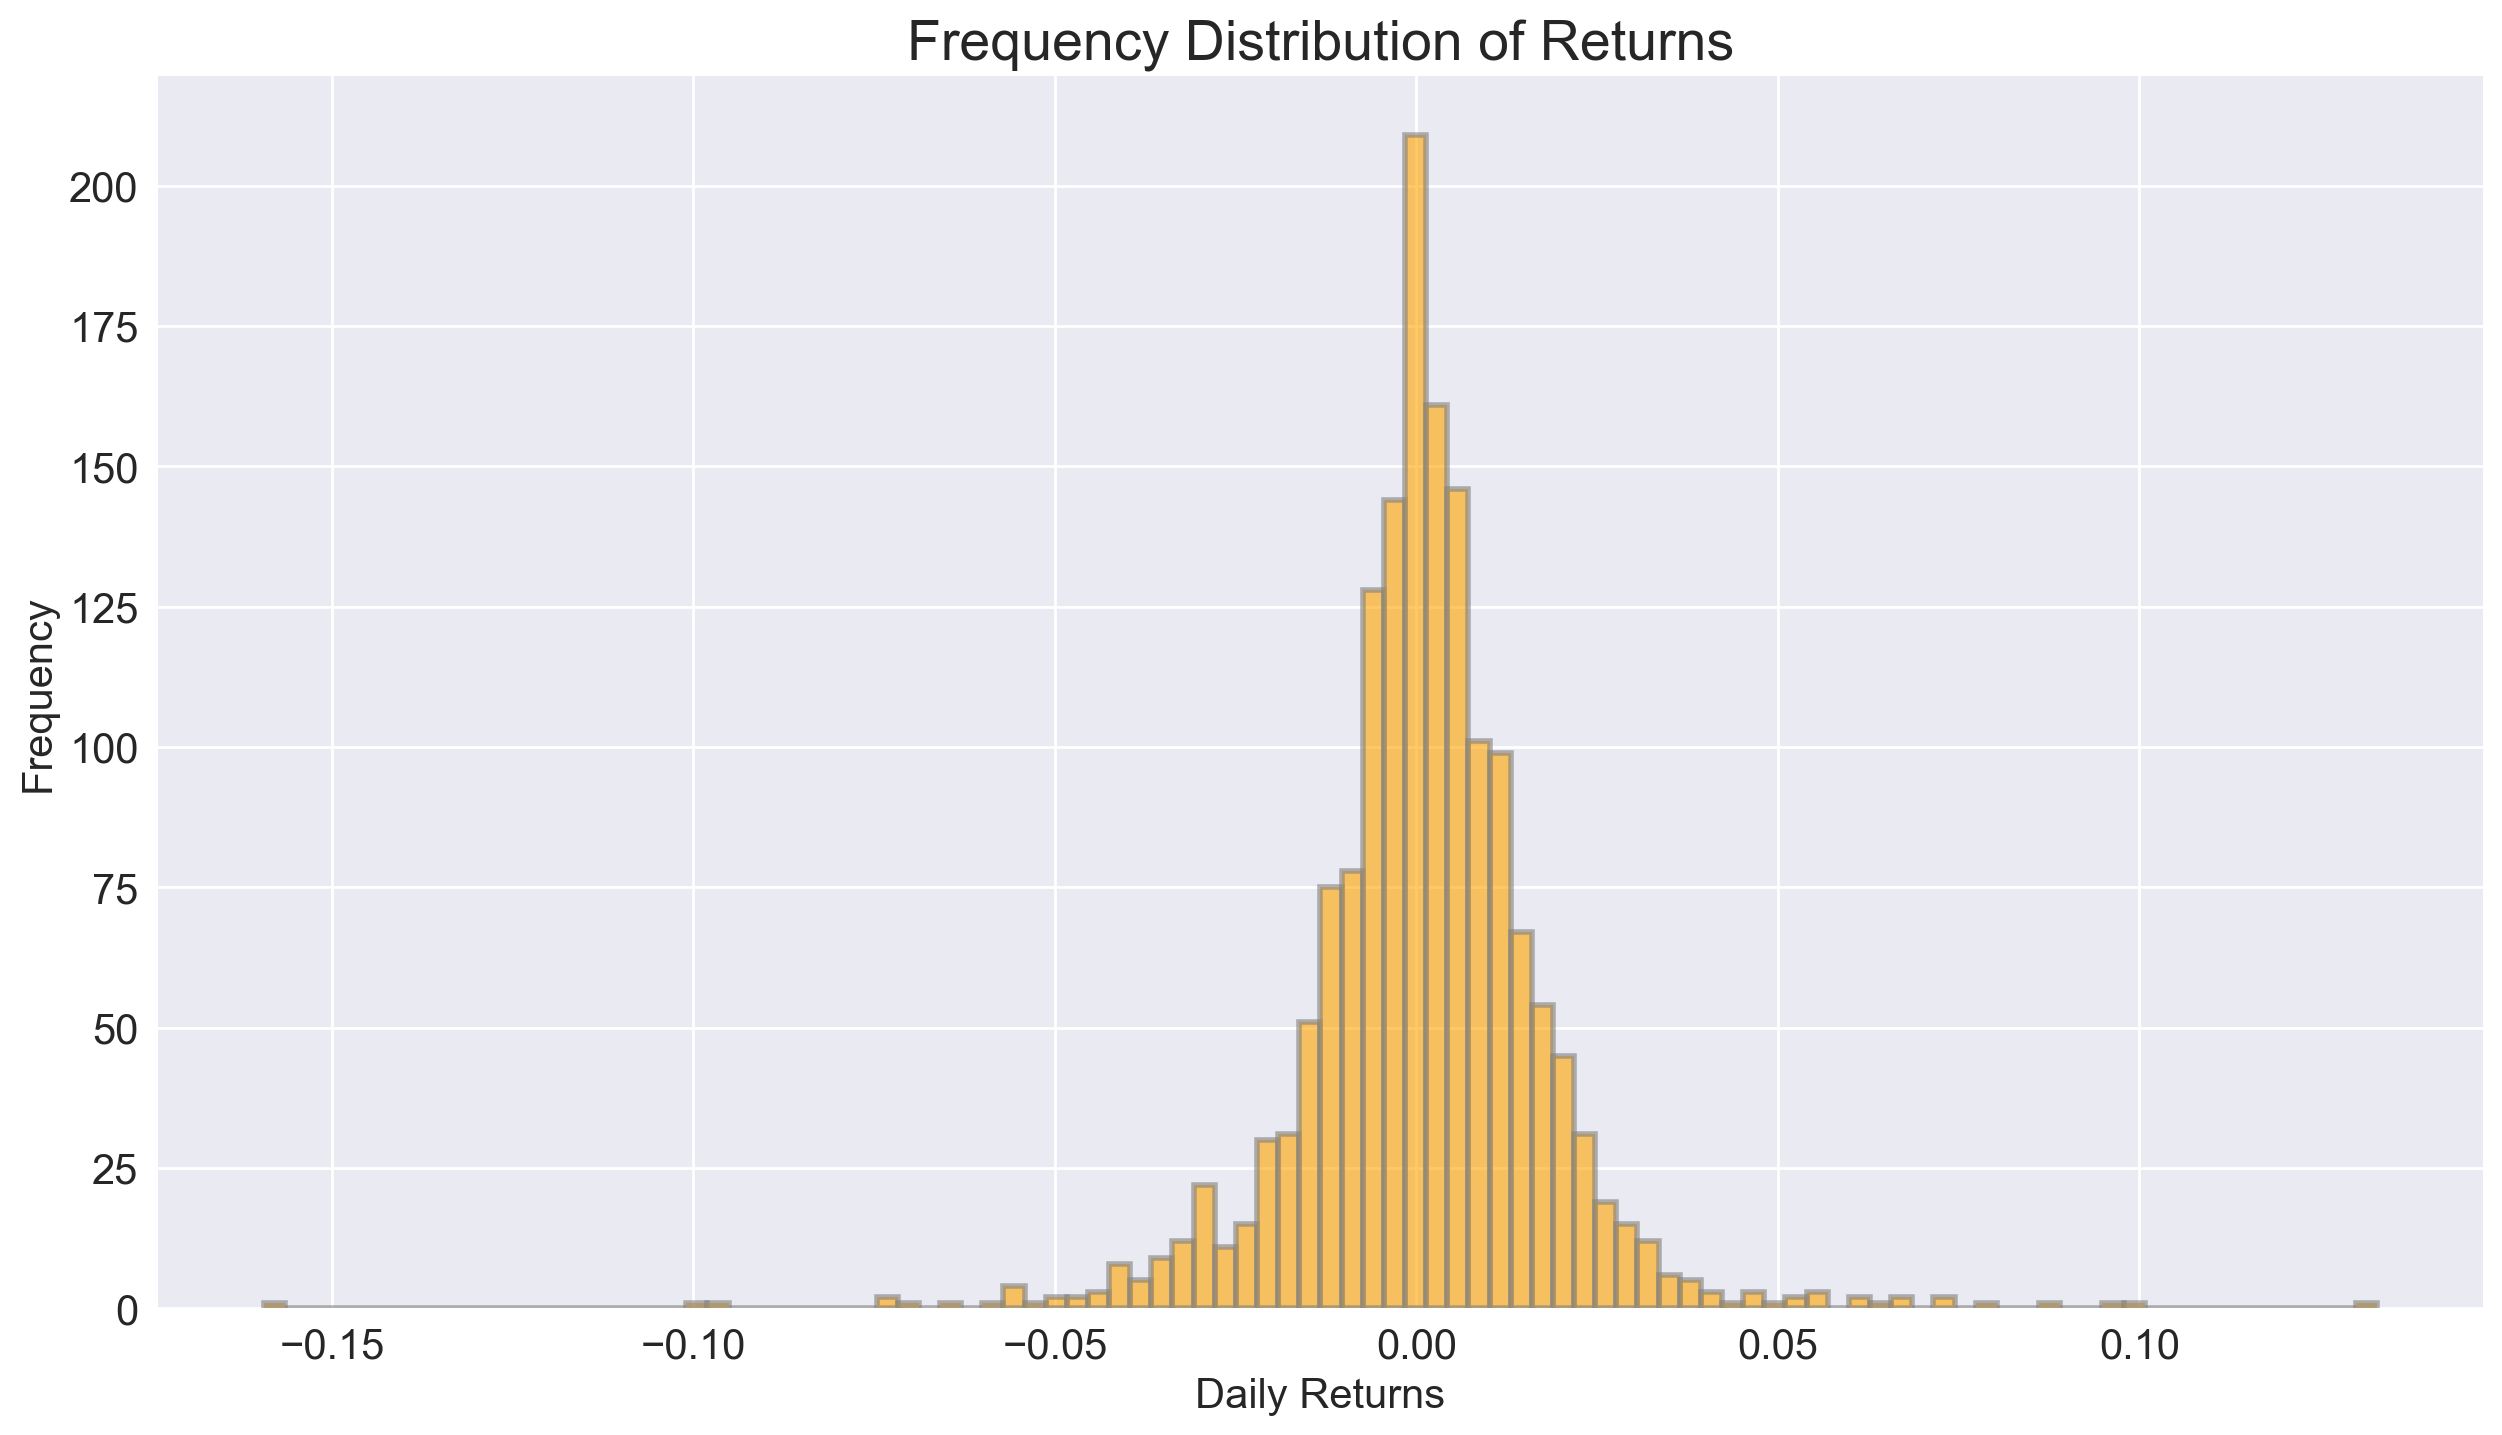

In [ ]:
msft.log_ret.plot(kind = "hist", figsize = (15 ,8), bins = 100, fontsize = 15, density = False , edgecolor = "gray", color ="orange",lw = 2, alpha = 0.6) # Frequency Distribution of log returns
plt.xlabel("Daily Returns", fontsize = 15)
plt.ylabel("Frequency", fontsize = 15)
plt.title("Frequency Distribution of Returns", fontsize = 20)
plt.show()

__Do MSFT Returns follow a Normal Distribution?__ <br><br>
A normally distributed random variable can be fully described by its 
- mean
- standard deviation

Higher Central Moments are zero:
- Skew = 0 (measures symmetrie around the mean)
- (Excess) Kurtosis = 0 (positve excess Kurtosis -> more observations in the "tails")

In [ ]:
mu = msft.log_ret.mean()
mu

np.float64(0.0010365452376487453)

In [ ]:
sigma = msft.log_ret.std()
sigma

0.017331006025787906

In [ ]:
mf.normality_test(msft.log_ret.dropna())

H0: Data is normally distributed 
 H1: Data is not normally distributed 

Reject H0 - Data is not normally distributed.


In [ ]:
mf.skewness_test(msft.log_ret.dropna())

H0: Data's skewness is equal to 0 (data is symmetric) 
 H1: Data's skewness is not equal to 0 (data is asymmetric) 

Reject H0 (p=0.0004) - Data is asymmetric


In [ ]:
mf.kurtosis_test(msft.log_ret.dropna())

H0: Data's kurtosis is equal to 3 (or excess kurtosis is 0 / normal tails) 
 H1: Data's kurtosis is not equal to 3 (heavy or thin tails) 

Reject H0 (p=0.0000) - Data is not mesokurtic & has non-normal tails (fat/thin tails)


In [ ]:
stats.kurtosis(msft.log_ret.dropna(), fisher = True) # in a Normal Distribution: (fisher) kurtosis == 0

np.float64(10.702480851389131)

__-> MSFT Returns exhibit "Fat Tails" (extreme positive/negative outcomes).__

In [ ]:
mu = msft.log_ret.mean()
mu

np.float64(0.0010365452376487453)

In [ ]:
sigma = msft.log_ret.std()
sigma

0.017331006025787906

In [ ]:
x = np.linspace(msft.log_ret.min(), msft.log_ret.max(), 10000)
x

array([-0.15945341, -0.15942417, -0.15939493, ...,  0.1328705 ,
        0.13289974,  0.13292898], shape=(10000,))

In [ ]:
mu , sigma

(np.float64(0.0010365452376487453), 0.017331006025787906)

In [ ]:
y = stats.norm.pdf(x, loc = mu, scale = sigma) # creating y values a for normal distribution with mu, sigma
y

array([5.50944552e-18, 5.59619365e-18, 5.68429148e-18, ...,
       6.26786973e-12, 6.18793081e-12, 6.10899403e-12], shape=(10000,))

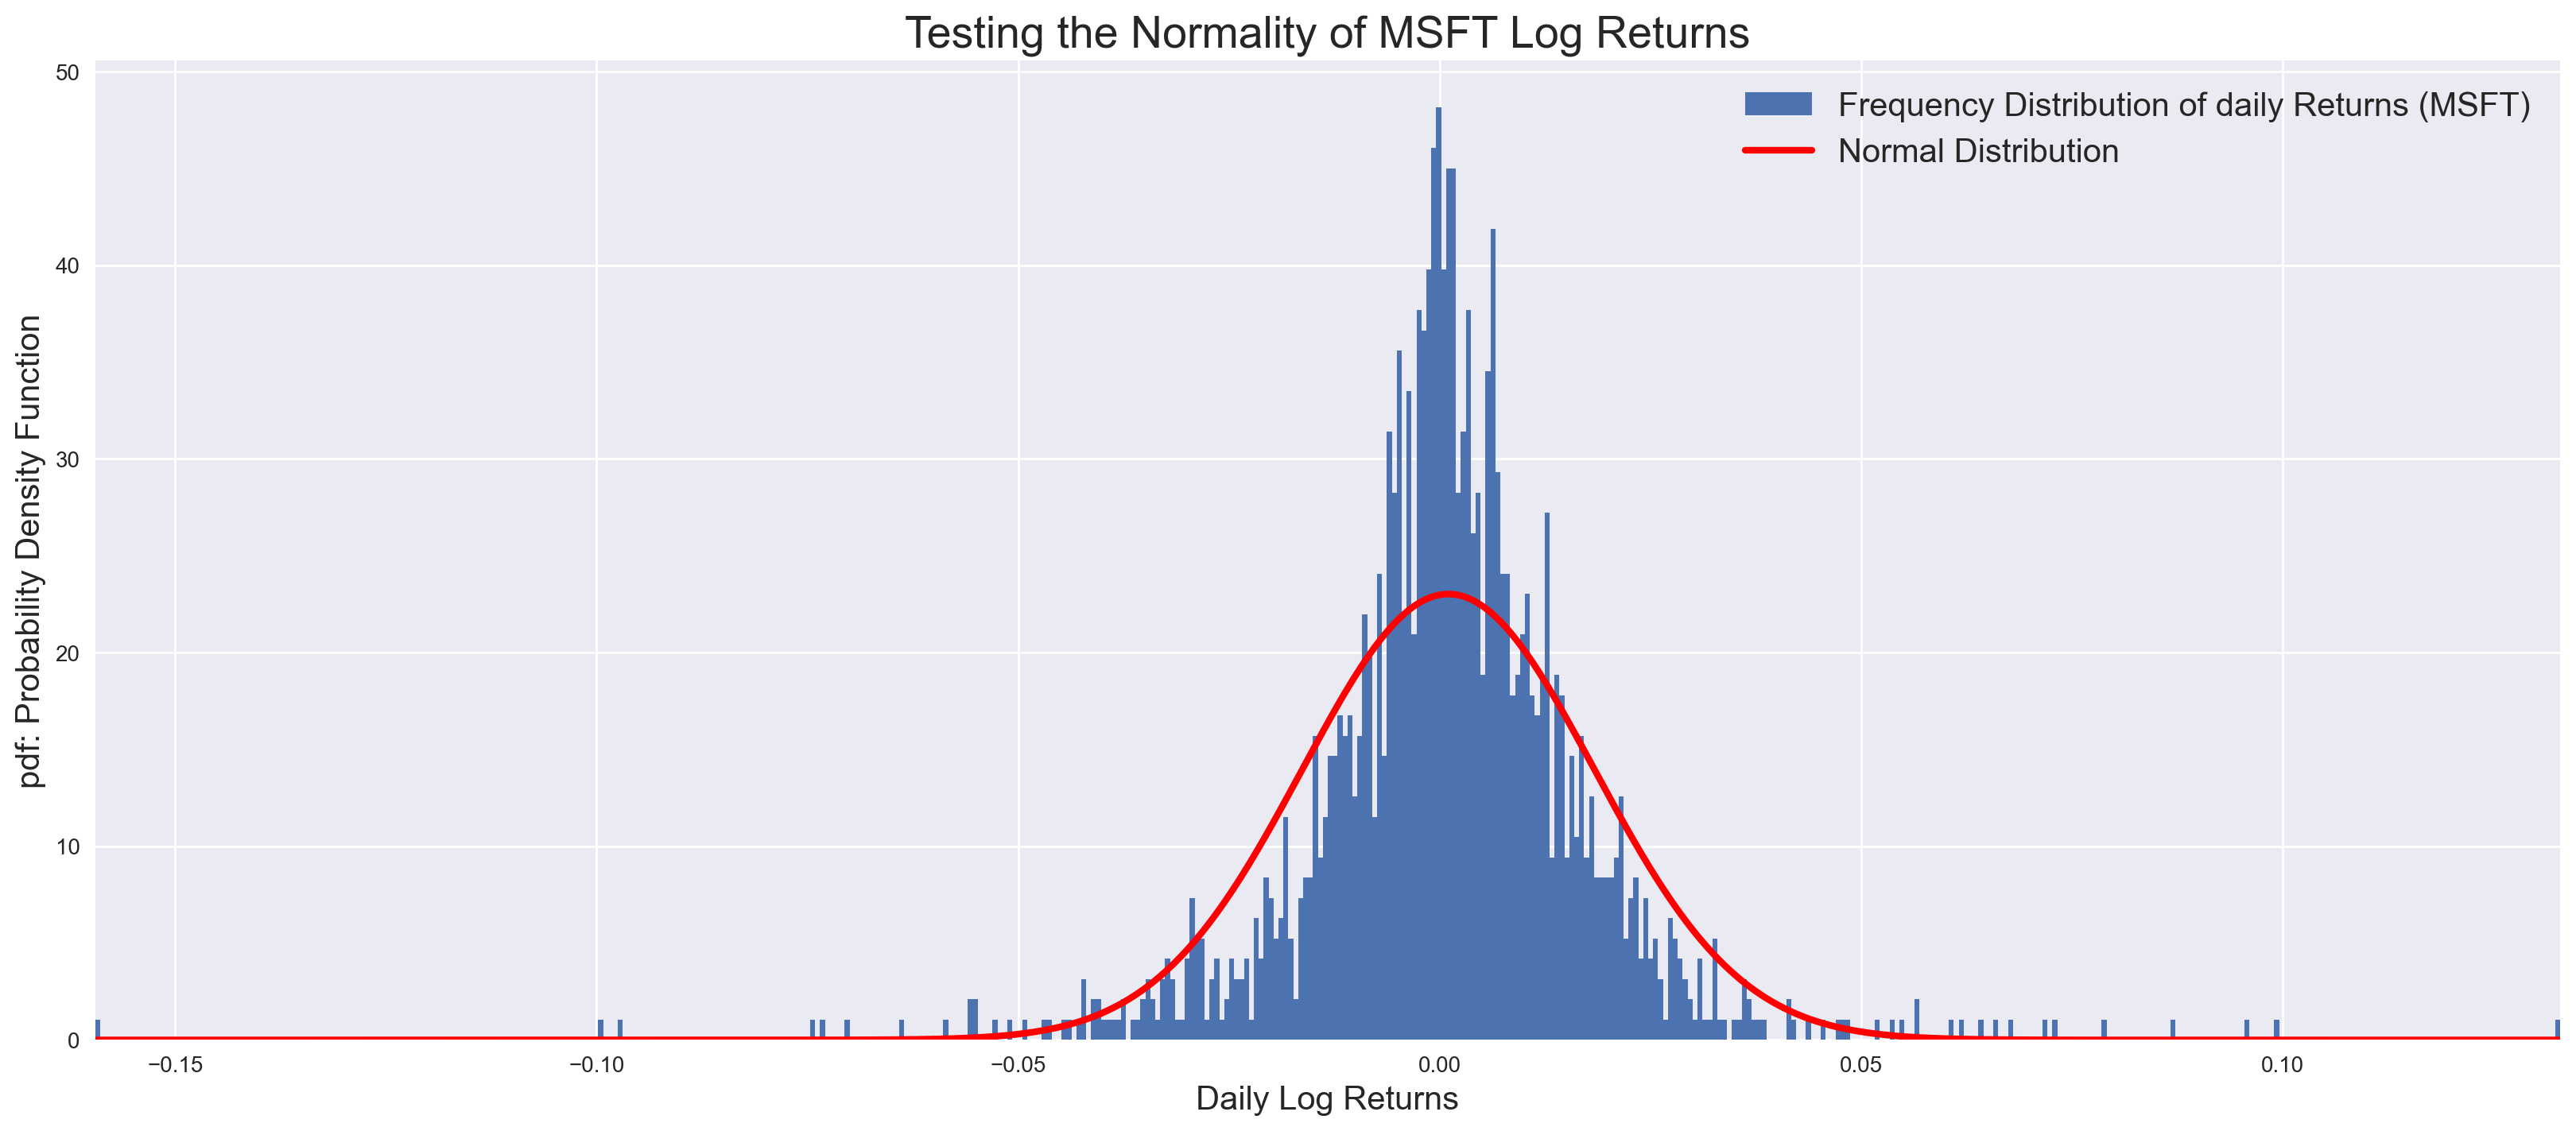

In [ ]:
plt.figure(figsize = (20, 8))
plt.hist(msft.log_ret, bins = 500, density = True, label = "Frequency Distribution of daily Returns (MSFT)")
plt.plot(x, y, linewidth = 3, color = "red", label = "Normal Distribution")
plt.title("Testing the Normality of MSFT Log Returns" , fontsize = 20)
plt.xlabel("Daily Log Returns", fontsize = 15)
plt.ylabel("pdf: Probability Density Function", fontsize = 15)
plt.legend(fontsize = 15)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

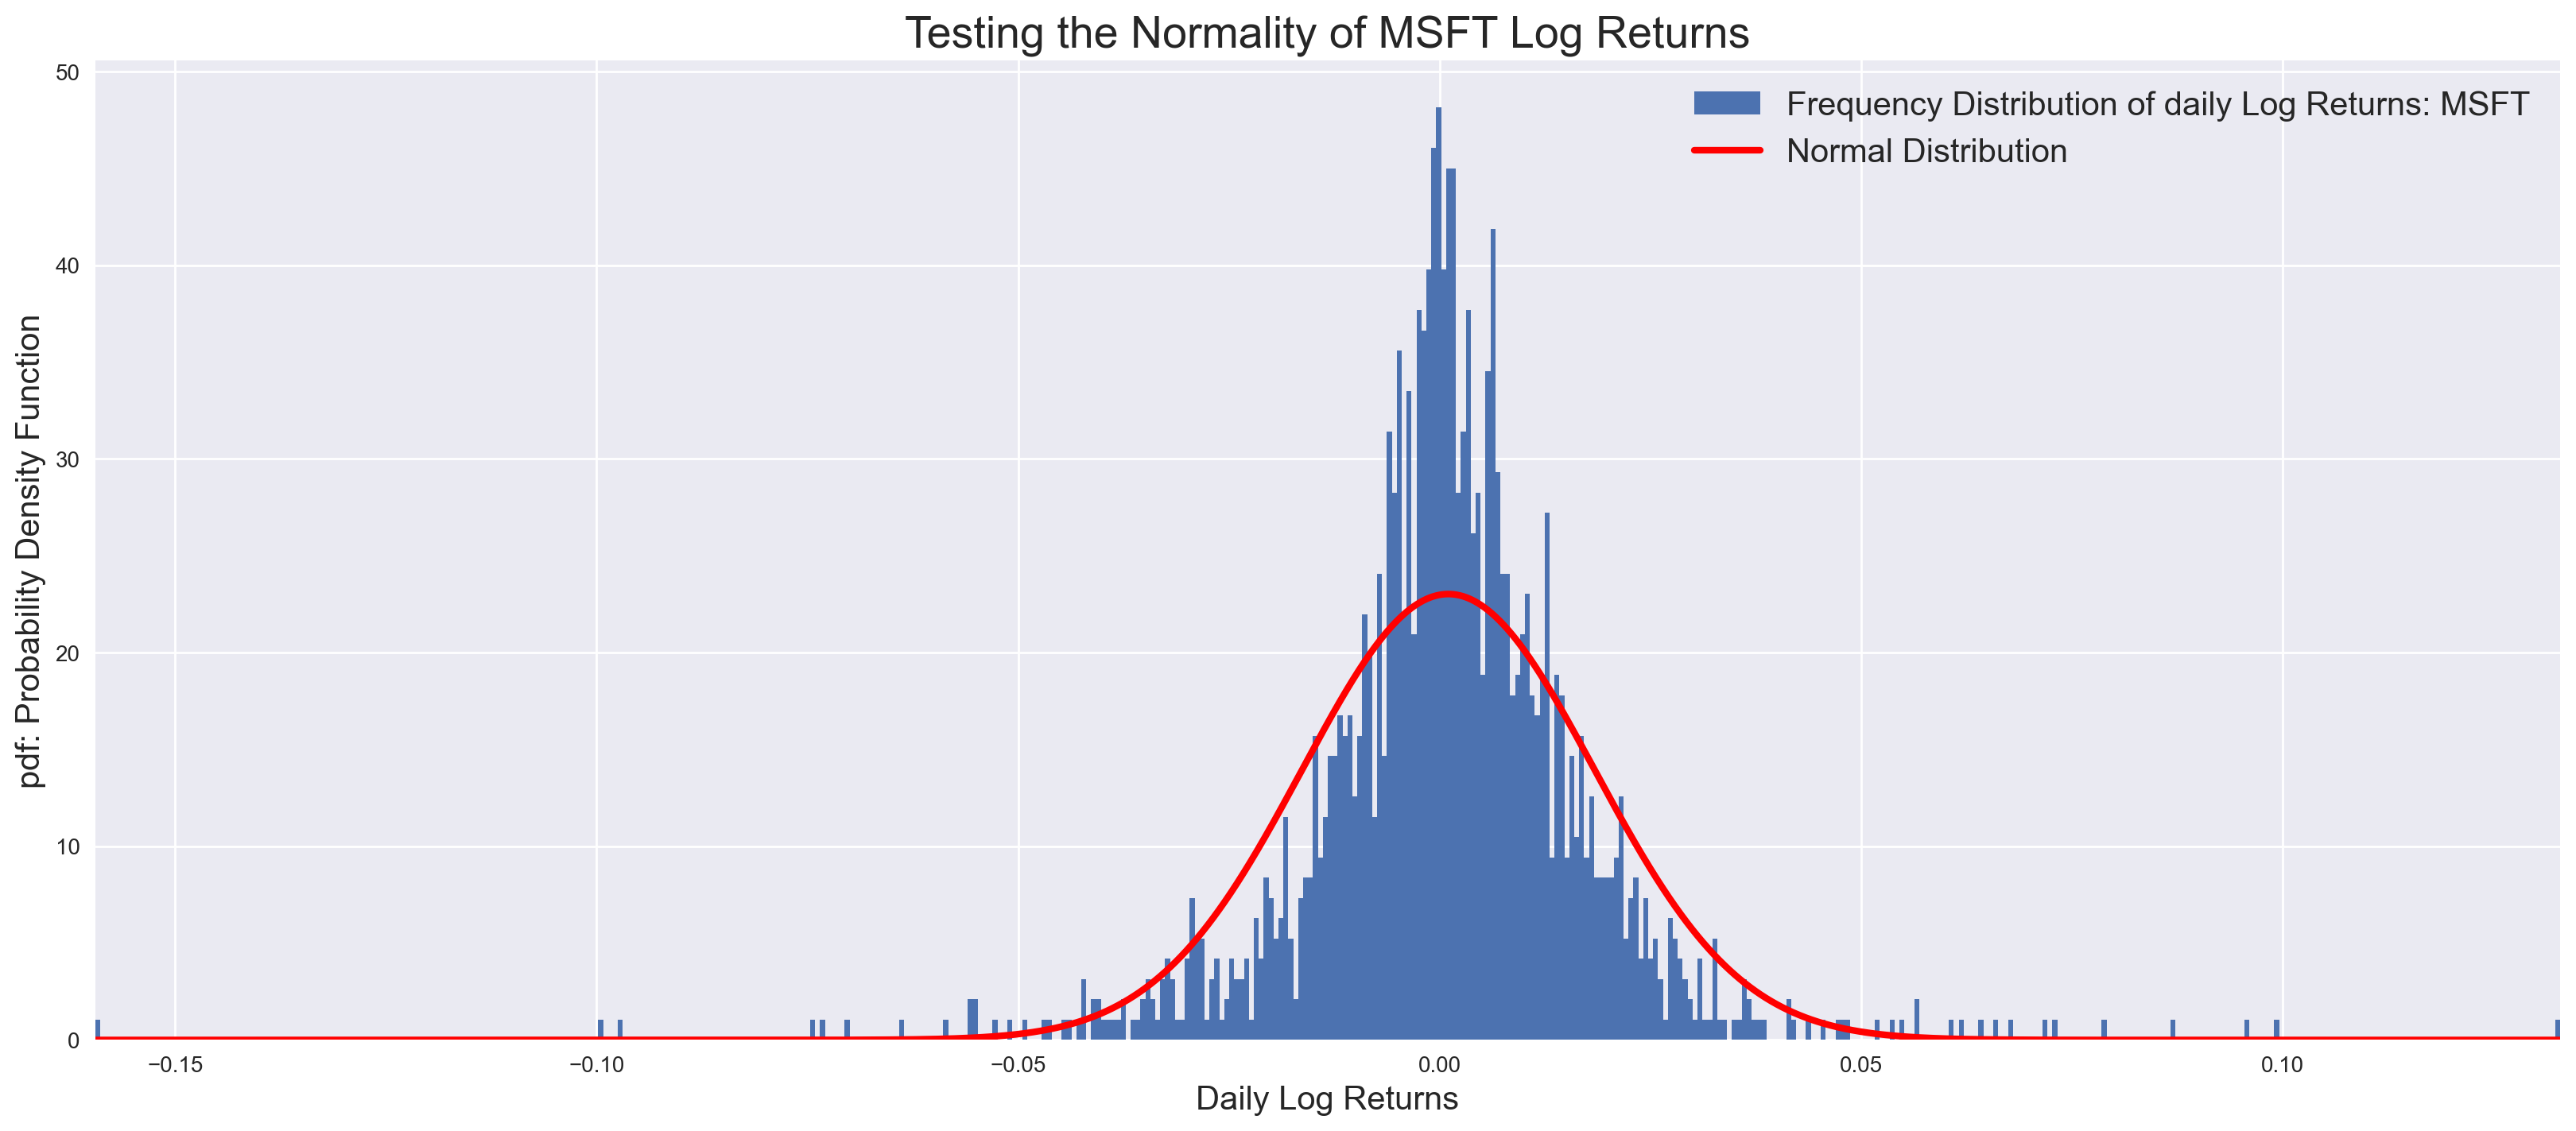

In [ ]:
plot_testing_normality(msft["Price"].to_frame() , ticker = "MSFT")

__-> MSFT Returns exhibit "Fat Tails" (extreme positive/negative outcomes).__ 

__Testing the normality of MSFT Returns based on the sample (Oct 2014 to May 2021):__ <br>
__-> Hypothesis Test with H0 Hypothesis: MSFT Returns (full population) follow a normal Distribution.__ 

In [ ]:
z_stat , p_value = stats.normaltest(msft.log_ret.dropna())

In [ ]:
z_stat # high values -> reject H0

np.float64(320.2696045982004)

In [ ]:
p_value # low values (close to zero) -> reject H0

np.float64(2.8466822987543892e-70)

In [ ]:
round(p_value, 10)

np.float64(0.0)

In [ ]:
mf.normality_test(msft.log_ret.dropna())

H0: Data is normally distributed 
 H1: Data is not normally distributed 

Reject H0 - Data is not normally distributed.


__-> Assuming that MSFT Returns (generally) follow a Normal Distribution, there is 0% probability that we get that extreme outcomes in a sample.__ 

__Take Home: MSFT Returns don´t follow a Normal Distribution as they exhibit "Fat Tails". Extreme Events/Outcomes are not reflected in the Mean-Variance Analysis. The Standard Deviation of Returns underestimates true Risk.__

This text is the output of a **normality test** (likely the Shapiro-Wilk or Jarque-Bera test) performed on Microsoft (MSFT) stock returns. 

Here’s what it’s saying in plain English:

**1. The Statistical Test**
- It tested whether MSFT's daily returns follow a **Normal Distribution** (the classic "bell curve").
- The test got a **0% probability** (p-value ≈ 0) that the data came from a normal distribution.

**2. The Verdict**
- It **rejects** the idea that the returns are normally distributed. 
- In other words, MSFT returns **do not** follow a bell curve.
```
mf.normality_test(msft.log_ret.dropna())
H0: Data is normally distributed 
H1: Data is not normally distributed 

Reject H0 - Data is not normally distributed.
```
**3. Why this matters (The "Fat Tails" explanation)**
- Real-world stock returns have **"fat tails"** — meaning extreme events (huge crashes or massive spikes) happen much more often than a normal distribution would predict.
- A normal distribution says extreme 5+ standard deviation moves should almost never happen. In reality, they happen fairly regularly.
```
mf.kurtosis_test(msft.log_ret.dropna())
H0: Data's kurtosis is equal to 3 (or excess kurtosis is 0 / normal tails) 
H1: Data's kurtosis is not equal to 3 (heavy or thin tails) 

Reject H0 (p=0.0000) - Data is not mesokurtic & has non-normal tails (fat/thin tails)
```

**4. The takeaway for investing/risk**
- **Mean-Variance Analysis** (like the Efficient Frontier or Modern Portfolio Theory) relies on normal distributions. Since returns aren't normal, this analysis **underestimates true risk**.
- **Standard Deviation** (volatility) is used as the standard measure of risk, but because it ignores fat tails, it tells you that big losses are rarer than they actually are. 
- **Bottom line:** MSFT is riskier than a normal bell curve would suggest. The "textbook" risk metrics don't capture the real danger of extreme market drops.

## Annualizing Mean Return and Std of Returns

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.6f}'.format
plt.style.use("seaborn-v0_8")
%config InlineBackend.figure_format = 'retina'

In [ ]:
msft = pd.read_csv("msft.csv", 
                   index_col = "Date", 
                   parse_dates = ["Date"], 
                   usecols = ["Date" , "Price"])
msft

,Price
Date,
2014-10-01,45.900002
2014-10-02,45.759998
2014-10-03,46.090000
2014-10-06,46.090000
2014-10-07,45.529999
...,...
2021-05-24,250.779999
2021-05-25,251.720001
2021-05-26,251.490005


In [ ]:
msft["log_ret"] = np.log(msft.Price / msft.Price.shift())

In [ ]:
msft.log_ret.agg(["mean", "std"]) # mean and std based on daily returns

mean   0.001037
std    0.017331
Name: log_ret, dtype: float64

In [ ]:
ann_mu = msft.log_ret.mean() * 252 # T_y = 252 , r = msft.log_ret.mean()
ann_mu

np.float64(0.2612093998874838)

In [ ]:
cagr = np.exp(ann_mu) - 1 # don´t mix up with cagr
cagr

np.float64(0.29849954262529343)

In [ ]:
ann_std = msft.log_ret.std() * np.sqrt(252) 
ann_std

np.float64(0.27512119148878006)

In [ ]:
ann_std = np.sqrt(msft.log_ret.var() * 252) # annualized std of returns (Alt 2)
ann_std

np.float64(0.27512119148878)

## Resampling / Smoothing

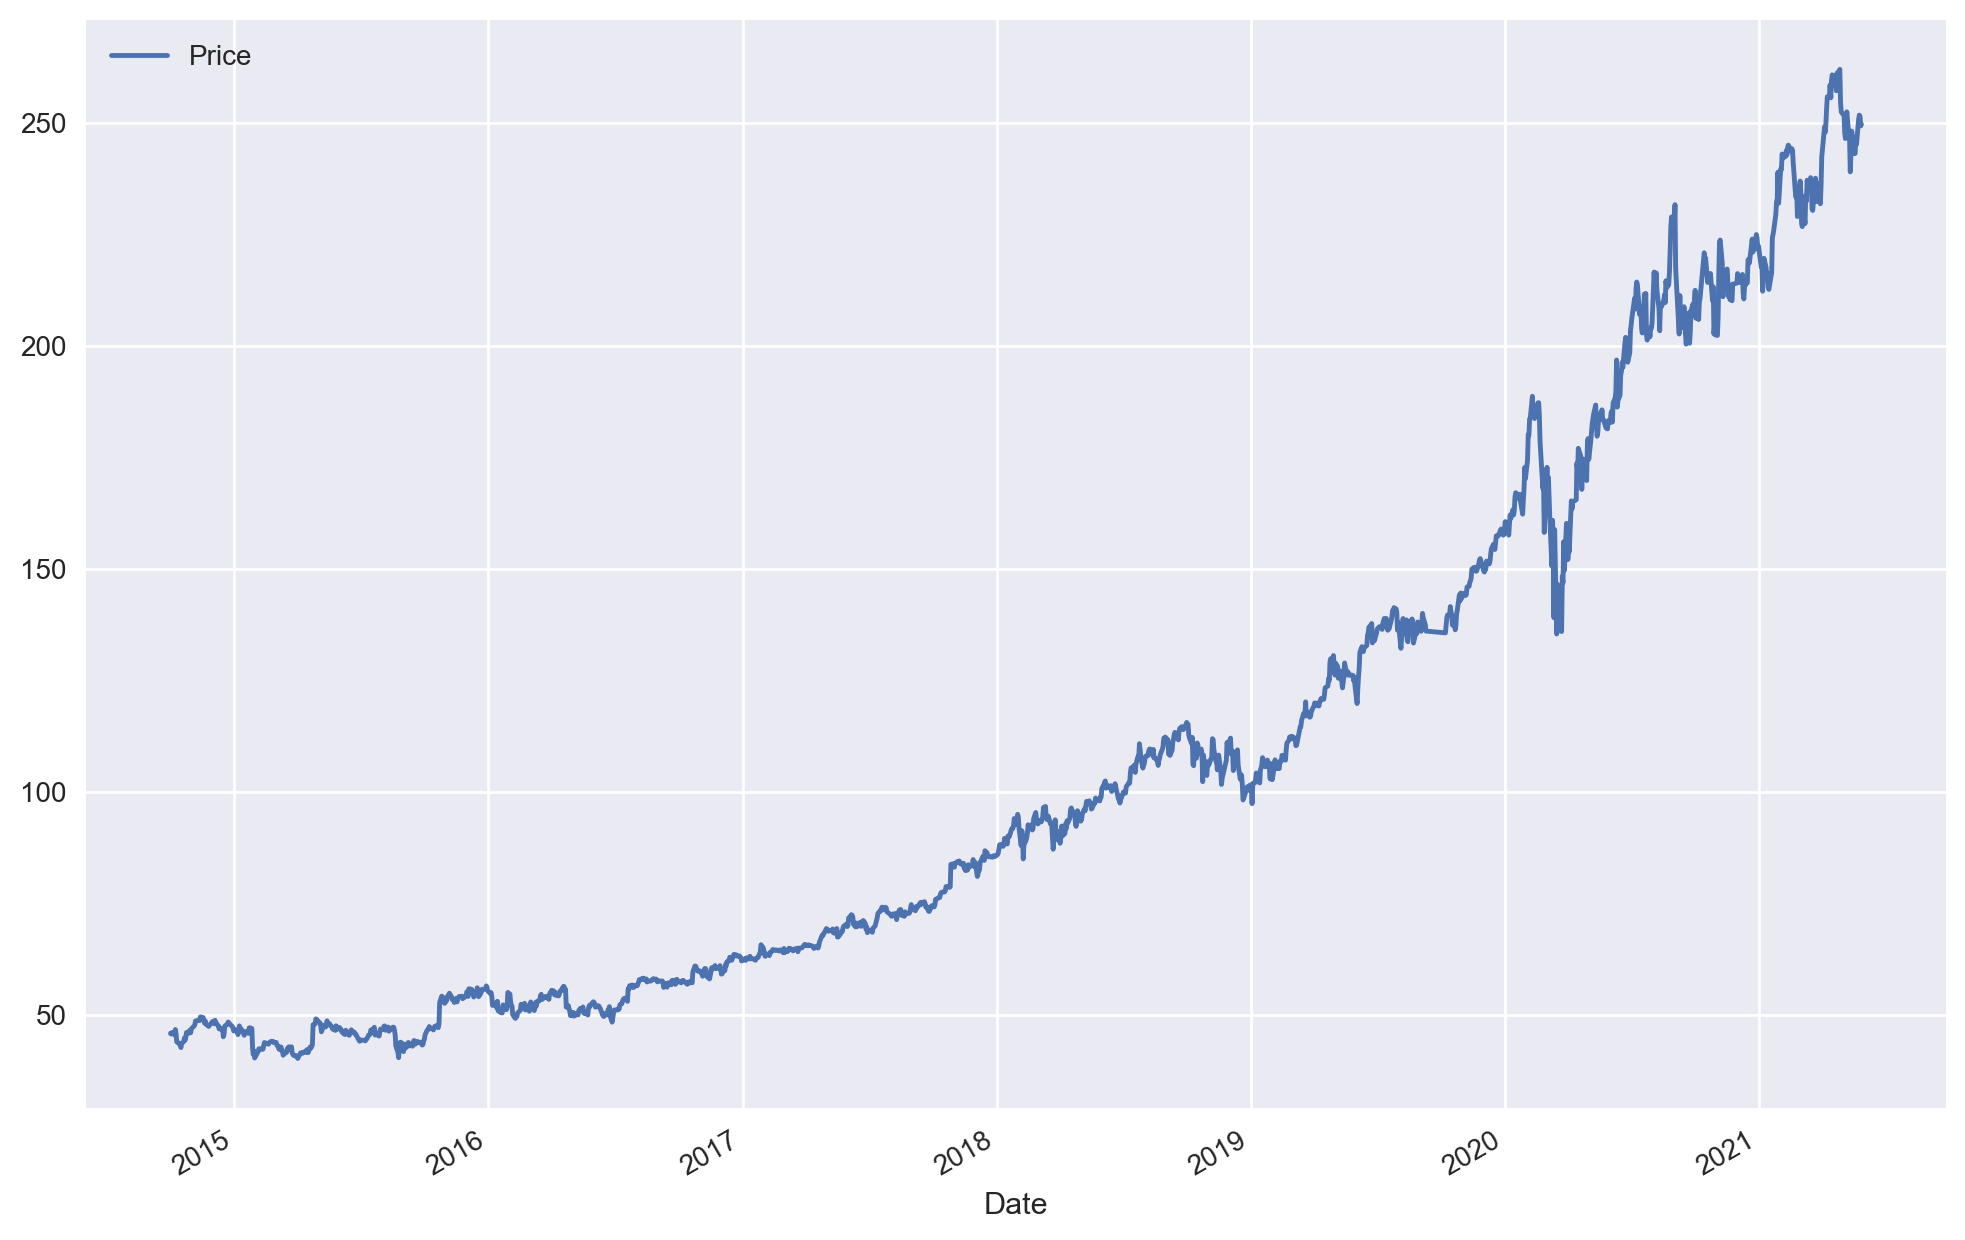

In [ ]:
msft.Price.plot(figsize = (12, 8))
plt.legend()
plt.show()

In [ ]:
monthly = msft.Price.resample("ME").last() ## resample to monthly (month end)
monthly

Date
2014-10-31    46.950001
2014-11-30    47.750000
2014-12-31    46.450001
2015-01-31    40.400002
2015-02-28    43.849998
                ...    
2021-01-31   231.960007
2021-02-28   232.380005
2021-03-31   235.770004
2021-04-30   252.179993
2021-05-31   249.679993
Freq: ME, Name: Price, Length: 80, dtype: float64

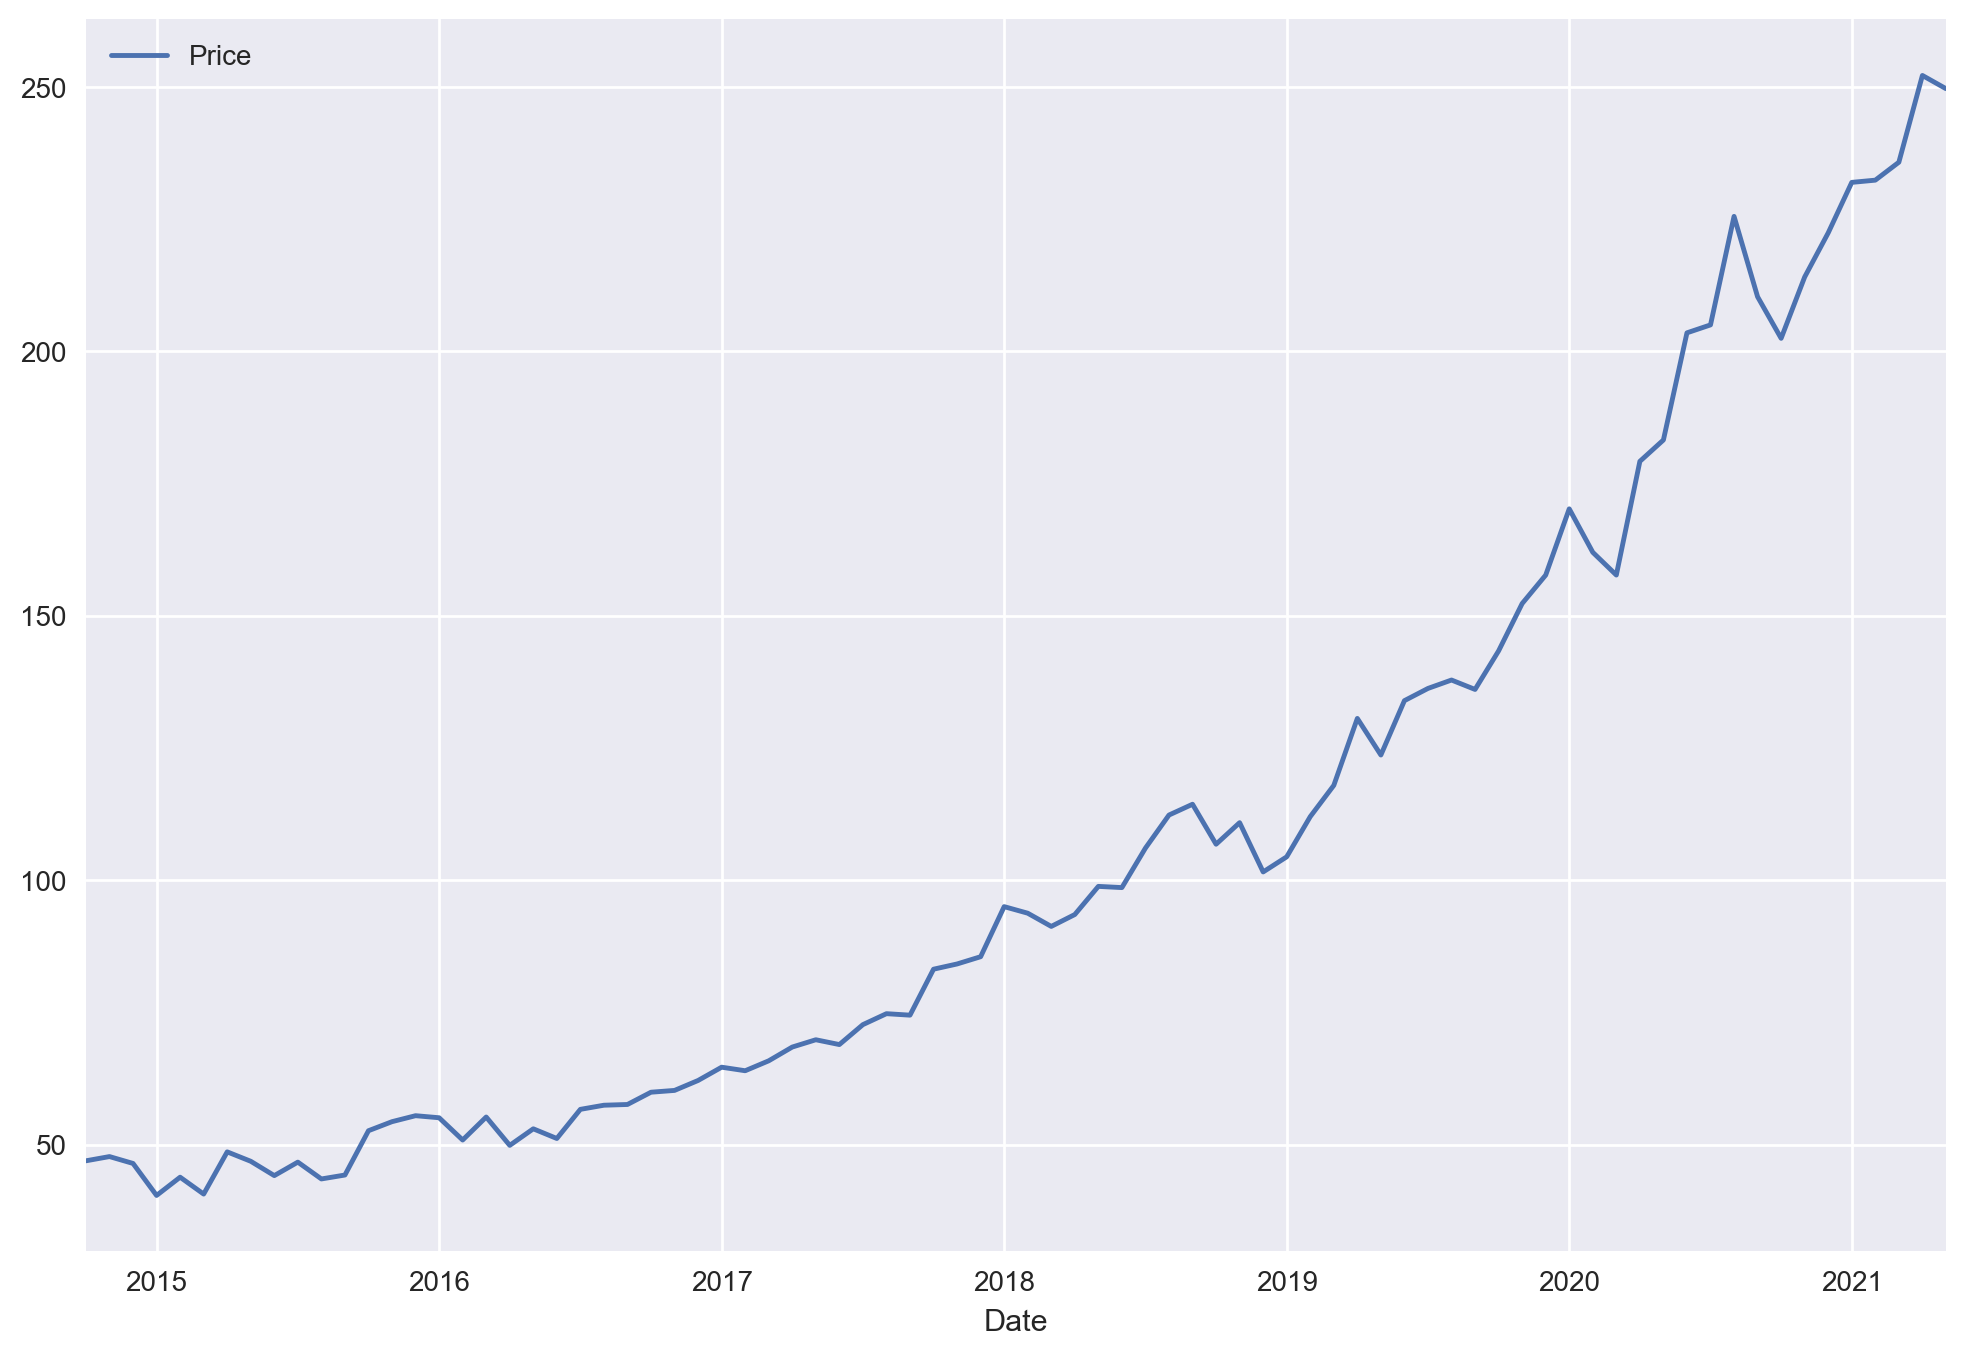

In [ ]:
monthly.plot(figsize = (12, 8))
plt.legend()
plt.show()

__How will the Mean-Variance Analysis change with smoothed data?__

In [ ]:
freqs = ["YE", "QE", "ME", "W-FRI", "D"]
periods = [1, 4, 12, 52, 252]
ann_mean = []
ann_std = []

In [ ]:
for i in range(5):
    resamp = msft.Price.resample(freqs[i]).last() # resample
    ann_mean.append(np.log(resamp / resamp.shift()).mean() * periods[i]) # calc. period mean
    ann_std.append(np.log(resamp / resamp.shift()).std() * np.sqrt(periods[i])) # calc. period std

In [ ]:
ann_mean

[np.float64(0.24025765527761314),
 np.float64(0.25873901337589106),
 np.float64(0.253837495704879),
 np.float64(0.25218832357021603),
 np.float64(0.25213419621385025)]

In [ ]:
summary = pd.DataFrame(data = {"ann_std":ann_std, "ann_mean":ann_mean}, index = freqs)
summary

,ann_std,ann_mean
YE,0.127250,0.240258
QE,0.181412,0.258739
ME,0.205721,0.253837
W-FRI,0.231585,0.252188
D,0.269462,0.252134


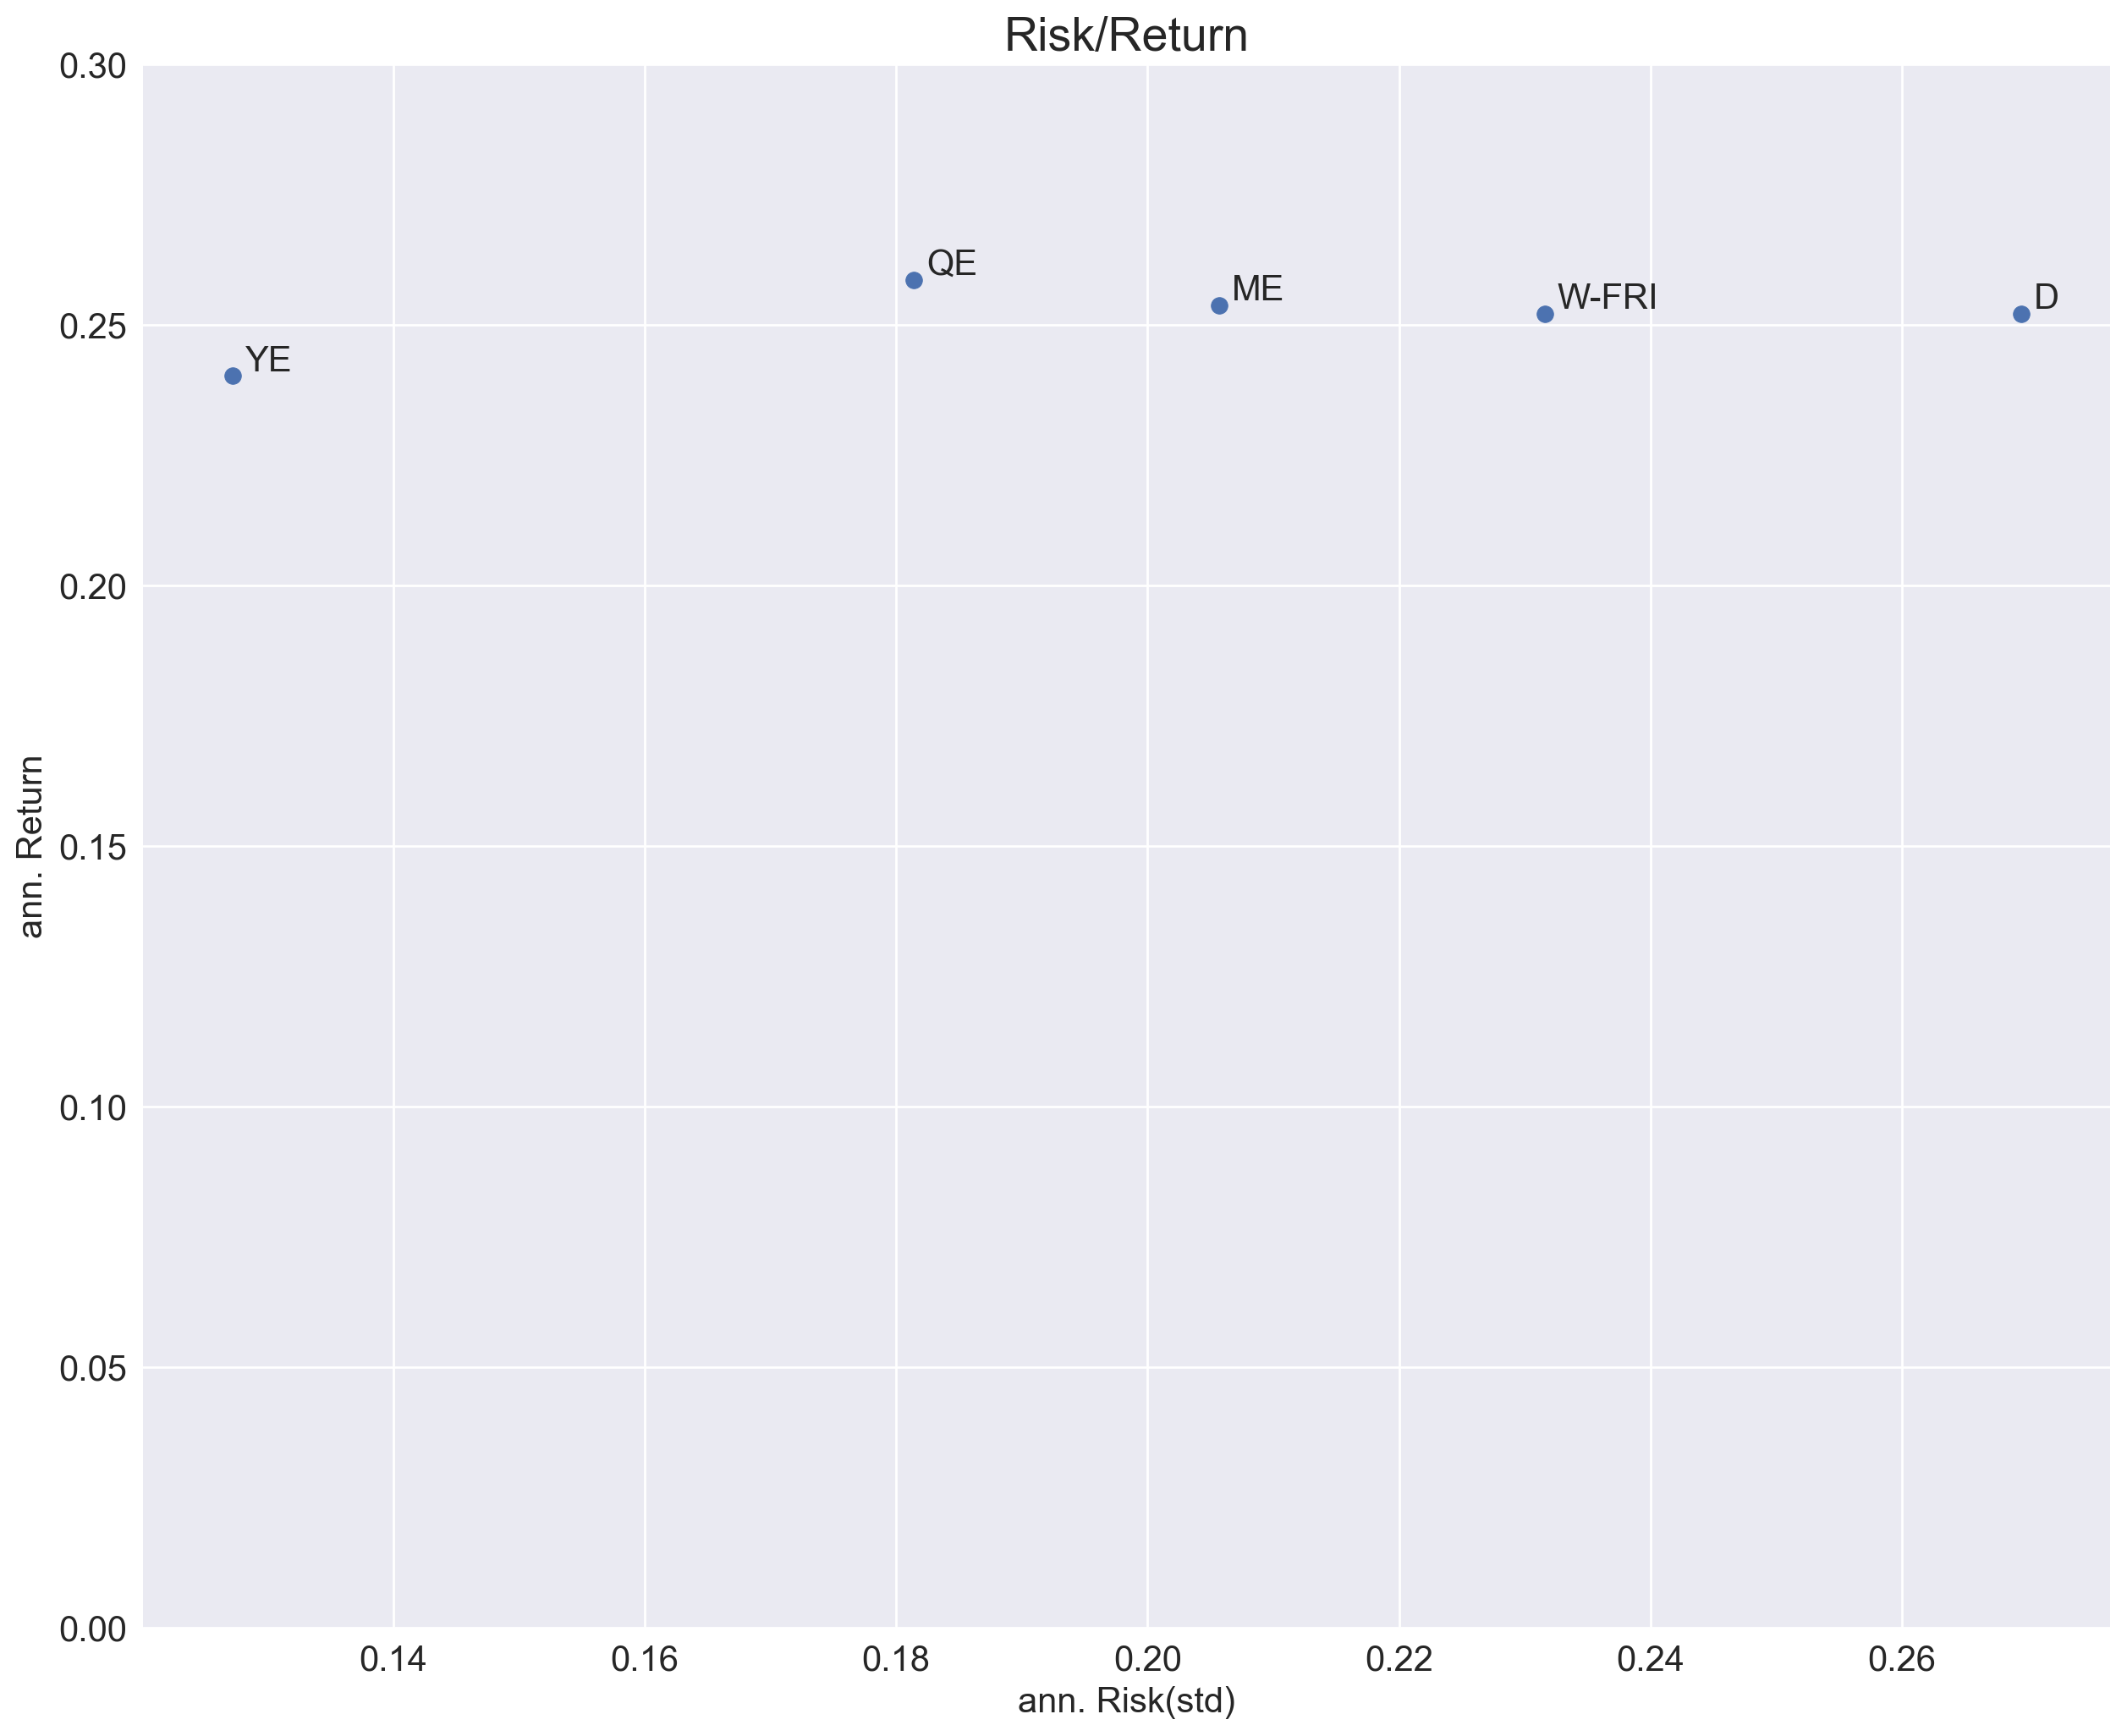

In [ ]:
summary.plot(kind = "scatter", x = "ann_std", y = "ann_mean", figsize = (15,12), s = 50, fontsize = 15)
for i in summary.index:
    plt.annotate(i, xy=(summary.loc[i, "ann_std"]+0.001, summary.loc[i, "ann_mean"]+0.001), size = 15)
plt.ylim(0, 0.3)
plt.xlabel("ann. Risk(std)", fontsize = 15)
plt.ylabel("ann. Return", fontsize = 15)
plt.title("Risk/Return", fontsize = 20)
plt.show()

__-> Smoothing reduces (observed) Risk__. 

Dubious practices:
- Managing (Manipulating) Performance in Performance Reportings.
- Comparing assets with different granularity and pricing mechanisms -> e.g. non-listed (alternative assets) vs. listed assets 
- Adjusting granularity to investor´s (average) holding period -> Volatility is still there.

## Rolling Statistics

__(Another) general Rule in Finance/Investing: Past performance is not an indicator of future performance__.

In [ ]:
msft

,Price,Simple_Returns,log_ret
Date,,,
2014-10-01,45.900002,NaN,NaN
2014-10-02,45.759998,-0.305018,-0.003055
2014-10-03,46.090000,0.721158,0.007186
2014-10-06,46.090000,0.000000,0.000000
2014-10-07,45.529999,-1.215017,-0.012225
...,...,...,...
2021-05-24,250.779999,2.288208,0.022624
2021-05-25,251.720001,0.374832,0.003741
2021-05-26,251.490005,-0.091370,-0.000914


In [ ]:
ann_mu = msft.log_ret.mean() * 252 # annualized mean return
ann_mu

np.float64(0.2612093998874838)

In [ ]:
ann_std = msft.log_ret.std() * np.sqrt(252) # annualized std of returns (Alt 1)
ann_std

np.float64(0.27512119148878006)

__Are Return and Risk constant over time? No, of course not! They change over time.__

__Let´s measure/quantify this with rolling statistics!__

In [ ]:
window = 252 # rolling window 252 trading days (~ 1 Year)

In [ ]:
msft.log_ret.rolling(window = 252)

Rolling [window=252,center=False,axis=0,method=single]

In [ ]:
msft.log_ret.rolling(window = 252).sum() # Alt 1

Date
2014-10-01        NaN
2014-10-02        NaN
2014-10-03        NaN
2014-10-06        NaN
2014-10-07        NaN
               ...   
2021-05-24   0.314216
2021-05-25   0.308448
2021-05-26   0.314480
2021-05-27   0.294780
2021-05-28   0.308347
Name: log_ret, Length: 1635, dtype: float64

In [ ]:
roll_mean = msft.log_ret.rolling(window = 252).mean() * 252 # Alt 2
roll_mean

Date
2014-10-01        NaN
2014-10-02        NaN
2014-10-03        NaN
2014-10-06        NaN
2014-10-07        NaN
               ...   
2021-05-24   0.314216
2021-05-25   0.308448
2021-05-26   0.314480
2021-05-27   0.294780
2021-05-28   0.308347
Name: log_ret, Length: 1635, dtype: float64

In [ ]:
roll_mean.iloc[250:]

Date
2015-10-01        NaN
2015-10-02        NaN
2015-10-05   0.015779
2015-10-06   0.021404
2015-10-07   0.015287
               ...   
2021-05-24   0.314216
2021-05-25   0.308448
2021-05-26   0.314480
2021-05-27   0.294780
2021-05-28   0.308347
Name: log_ret, Length: 1385, dtype: float64

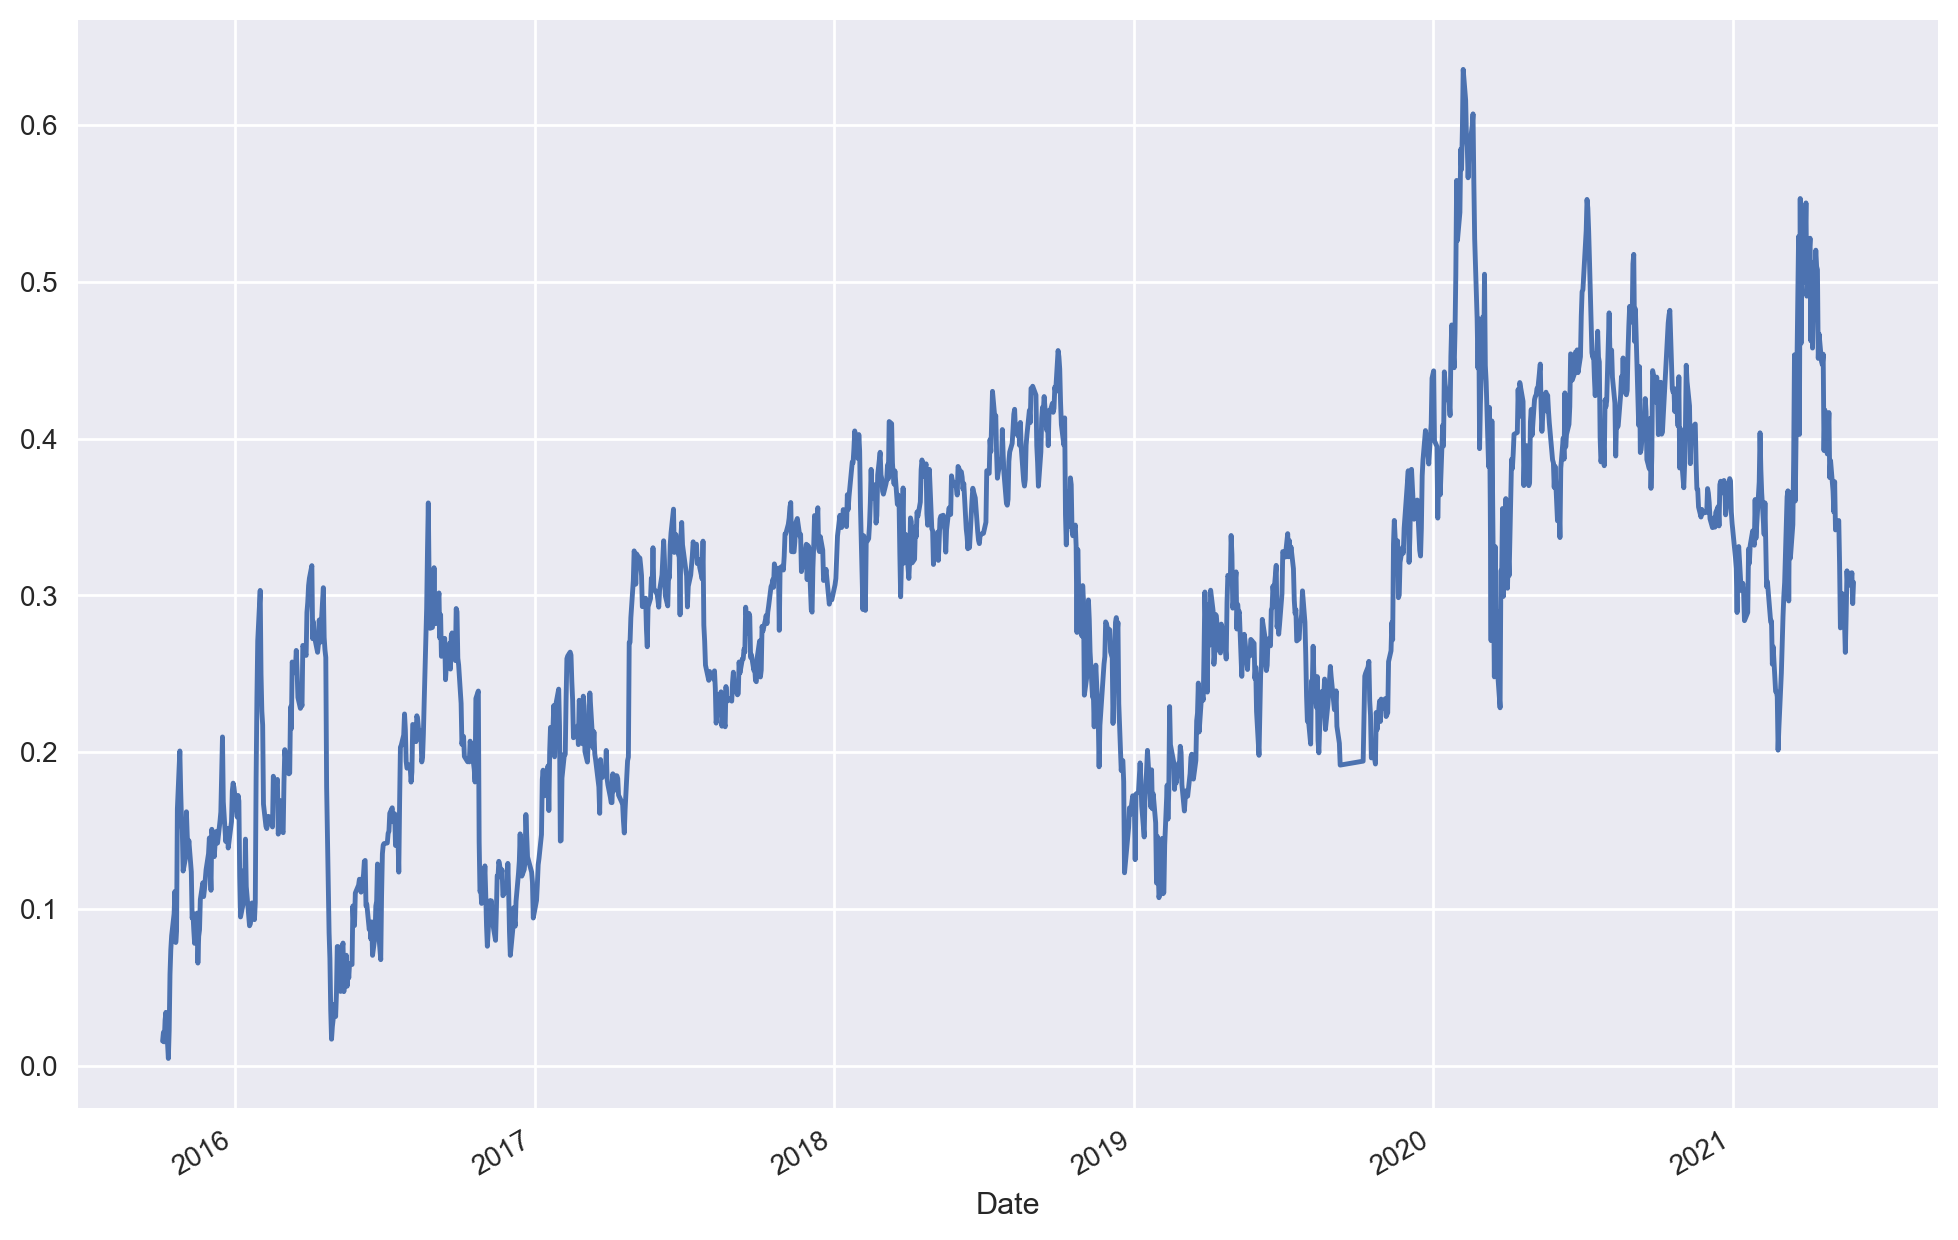

In [ ]:
roll_mean.plot(figsize = (12, 8))
plt.show()

In [ ]:
roll_std = msft.log_ret.rolling(window = 252).std() * np.sqrt(252)
roll_std

Date
2014-10-01        NaN
2014-10-02        NaN
2014-10-03        NaN
2014-10-06        NaN
2014-10-07        NaN
               ...   
2021-05-24   0.281893
2021-05-25   0.281782
2021-05-26   0.281671
2021-05-27   0.281676
2021-05-28   0.281361
Name: log_ret, Length: 1635, dtype: float64

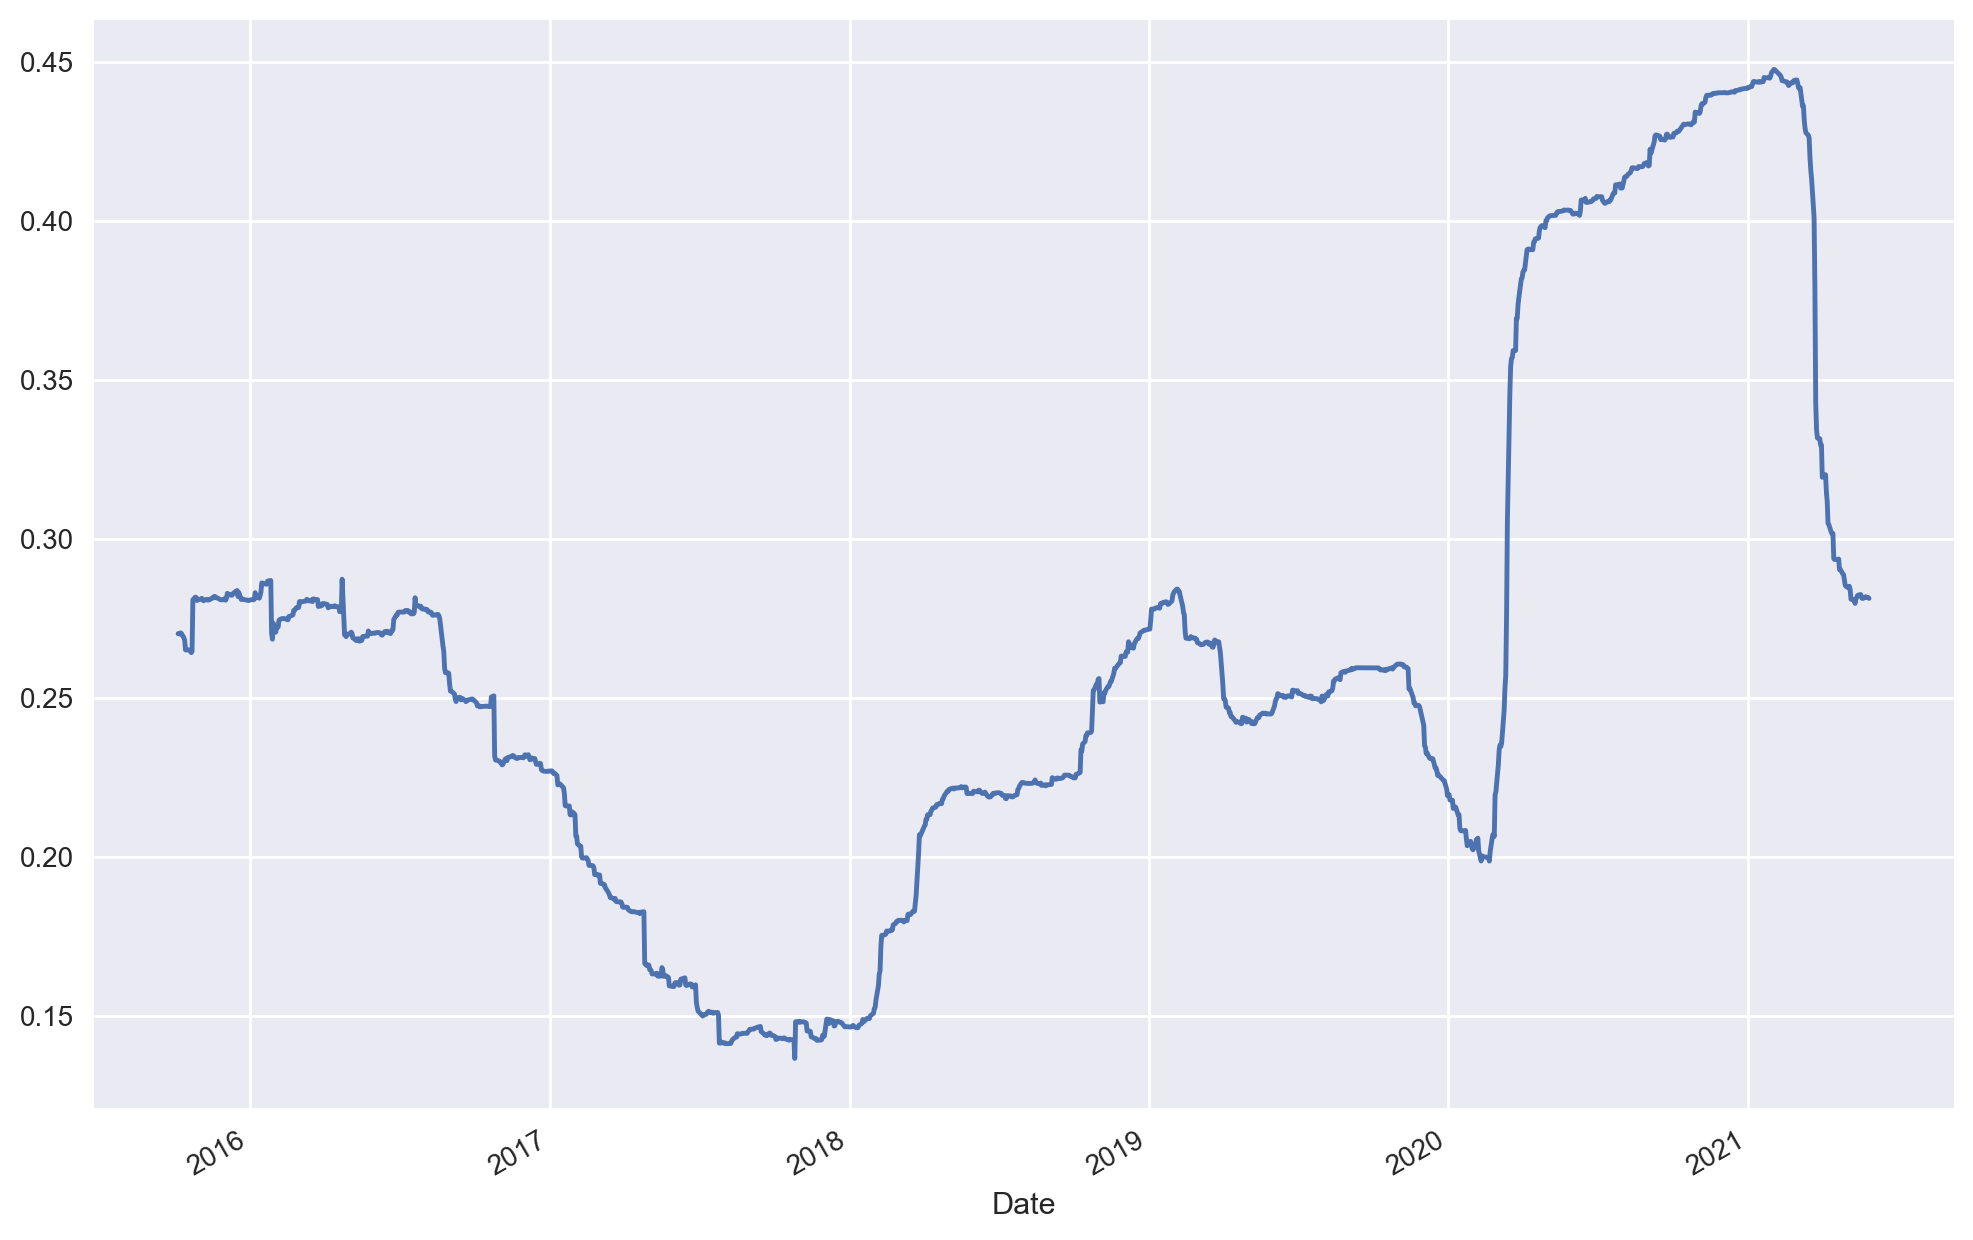

In [ ]:
roll_std.plot(figsize = (12, 8))
plt.show()

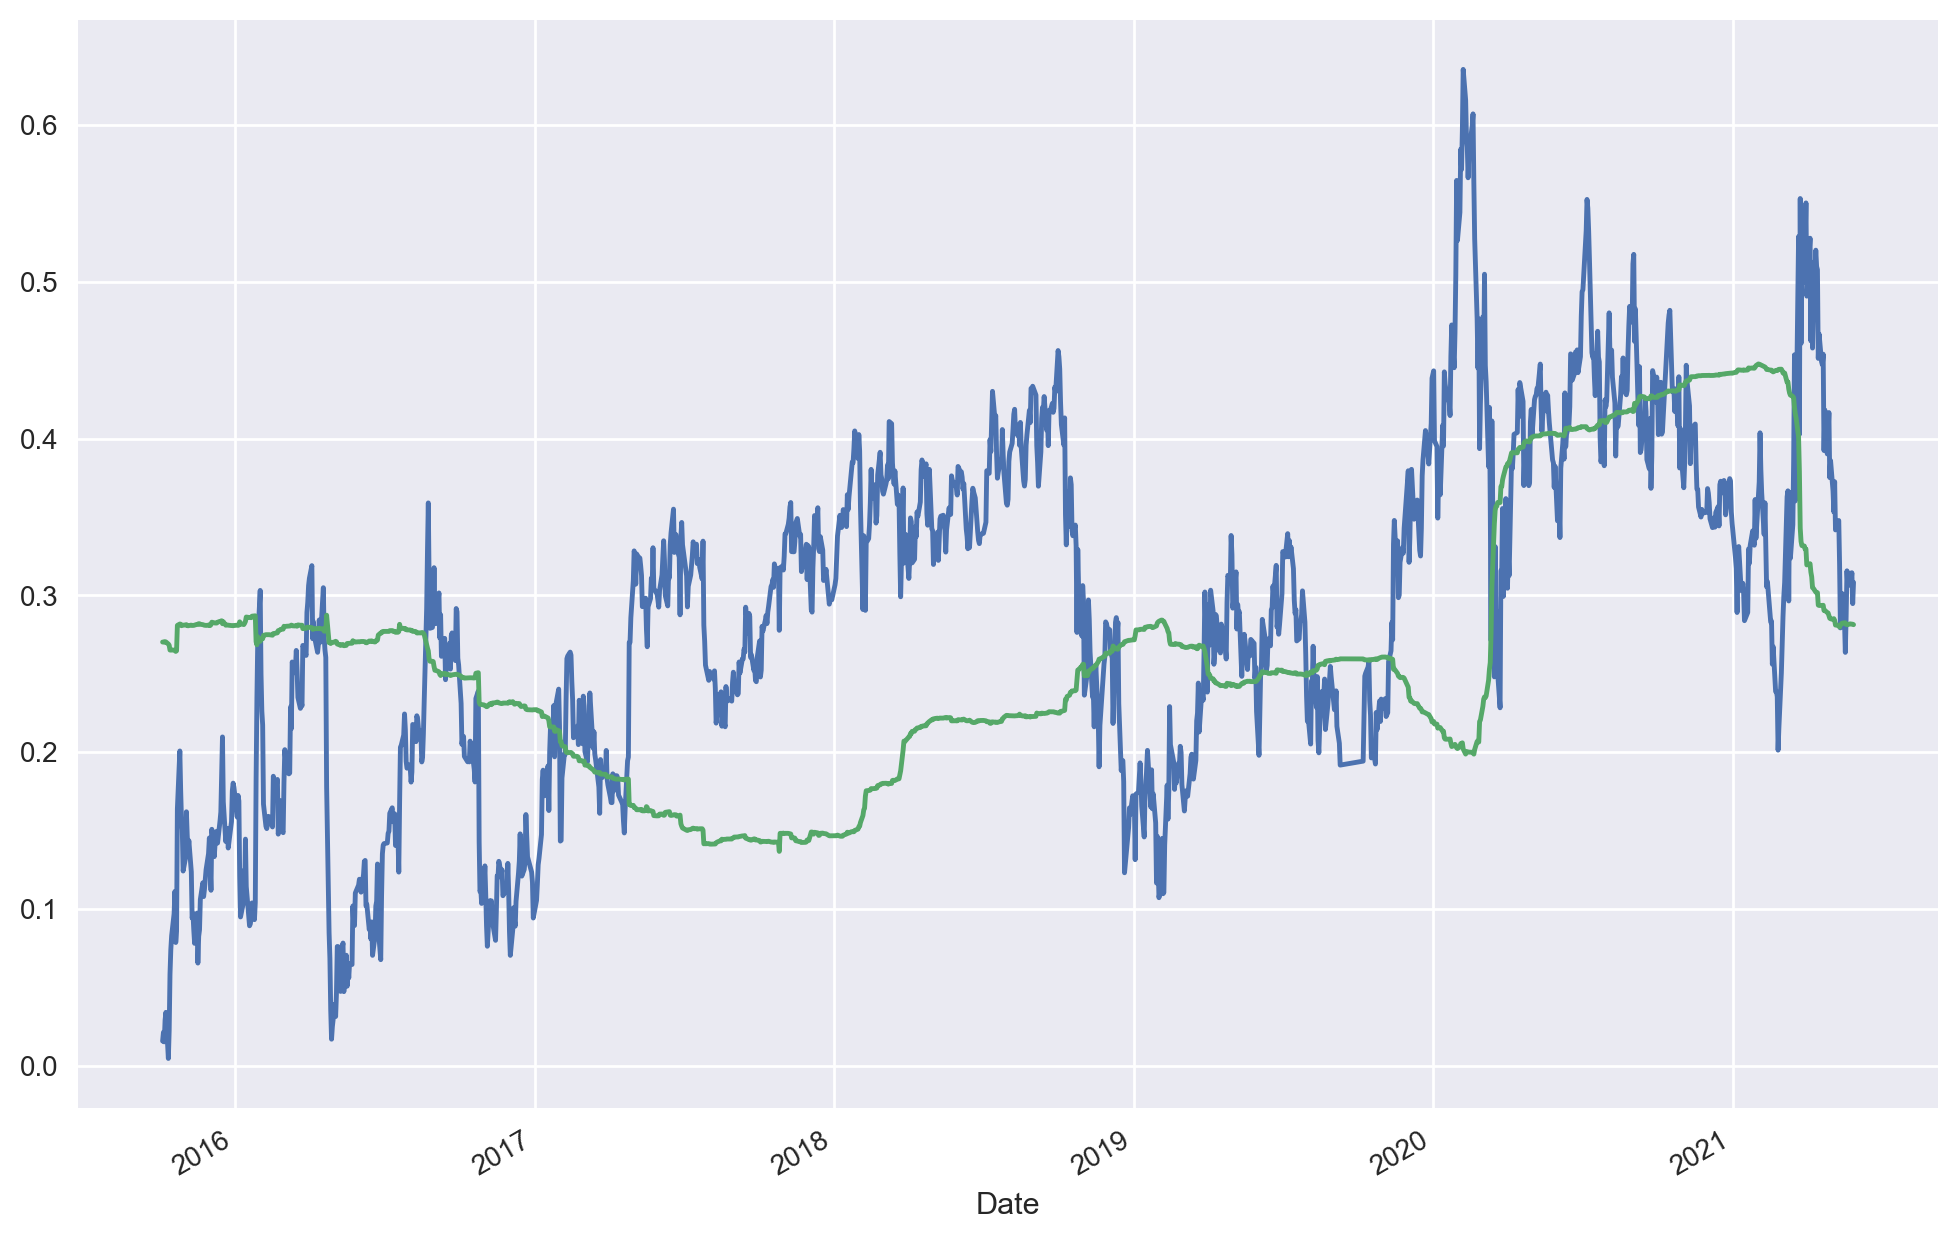

In [ ]:
roll_mean.plot(figsize = (12, 8))
roll_std.plot()
plt.show()

__Take Home__: Be careful, you´ll always find (sub-)periods with __low returns & high risk__ and __high returns & low risk__. 

- Analysis Period must be __sufficiently long__ to reduce impact of random noise. <br>
- Analysis Period should be __as short as possible__ and should only include the __latest trends / regimes__.
- Commonly used reporting period: __3 Years / 36 Months__

__Another Example: Simple Moving Average (Prices) - SMA__

In [ ]:
sma_window = 50

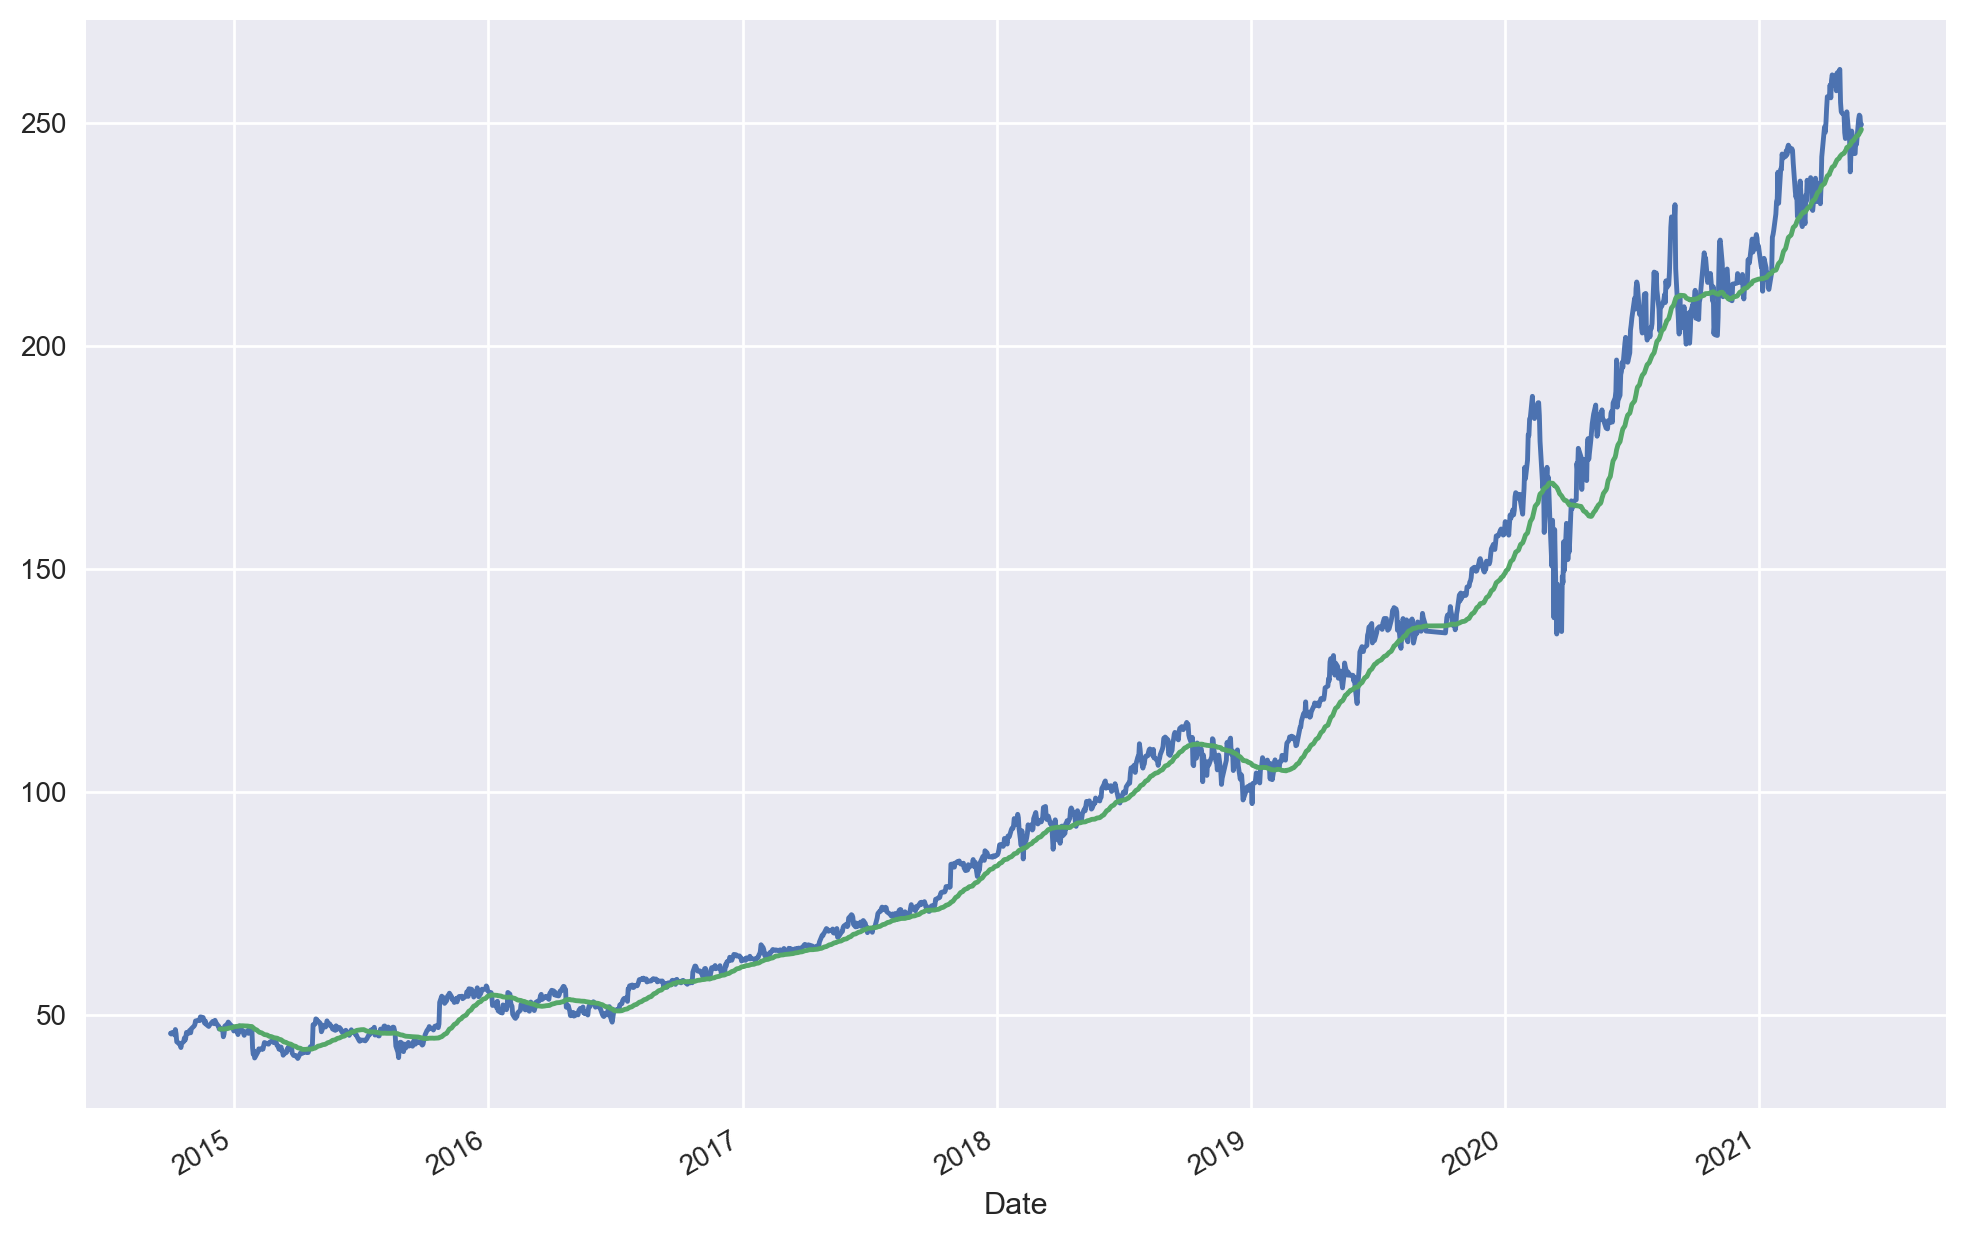

In [ ]:
msft.Price.plot(figsize = (12, 8))
msft.Price.rolling(sma_window).mean().plot()
plt.show()

--------------------------------------------

__Coding Challenge #5__

1. Calculate daily log returns for Boeing.

2. Use Boeing´s daily log returns to calculate the annualized mean and annualized std (assume 252 trading days per year).

3. Resample to monthly prices and compare the annualized std (monthly) with the annualized std (daily). Any differences?

4. Keep working with monthly data and calculate/visualize the rolling 36 months mean return (annualized).

---------------------------------------------

In [ ]:
ba["log_ret"] = np.log(ba.BA).diff()
ba

C:\Users\ahmad\AppData\Local\Temp\ipykernel_16120\3648267329.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ba["log_ret"] = np.log(ba.BA).diff()


,BA,Simple_Returns,log_ret
Date,,,
2014-10-02,124.169998,-0.401059,NaN
2014-10-03,126.360001,1.763713,0.017483
2014-10-06,126.260002,-0.079138,-0.000792
2014-10-07,123.320000,-2.328530,-0.023561
2014-10-08,124.980003,1.346094,0.013371
...,...,...,...
2021-05-24,237.440002,1.115746,0.011096
2021-05-25,240.740005,1.389826,0.013803
2021-05-26,241.369995,0.261689,0.002613


In [ ]:
ba_annualized_mu = ba.log_ret.mean() * 252
ba_annualized_std = ba.log_ret.std() * np.sqrt(252)
ba_annualized_mu*100, ba_annualized_std*100

(np.float64(10.614211337484239), np.float64(41.875969916333666))

In [ ]:
monthly_price = ba.BA.resample("ME").last()
monthly_log_ret = np.log(monthly_price).diff()
monthly_mu = monthly_log_ret.mean() * 12 # monthly mean
monthly_mu*100

np.float64(10.35760731660879)

In [ ]:
monthly_std = monthly_log_ret.std() * np.sqrt(12)
monthly_std*100


np.float64(40.62799023301141)

In [ ]:
monthly_log_ret.rolling(36).mean() * 12

Date
2014-10-31         NaN
2014-11-30         NaN
2014-12-31         NaN
2015-01-31         NaN
2015-02-28         NaN
                ...   
2021-01-31   -0.200501
2021-02-28   -0.178530
2021-03-31   -0.084161
2021-04-30   -0.117726
2021-05-31   -0.118205
Freq: ME, Name: BA, Length: 80, dtype: float64

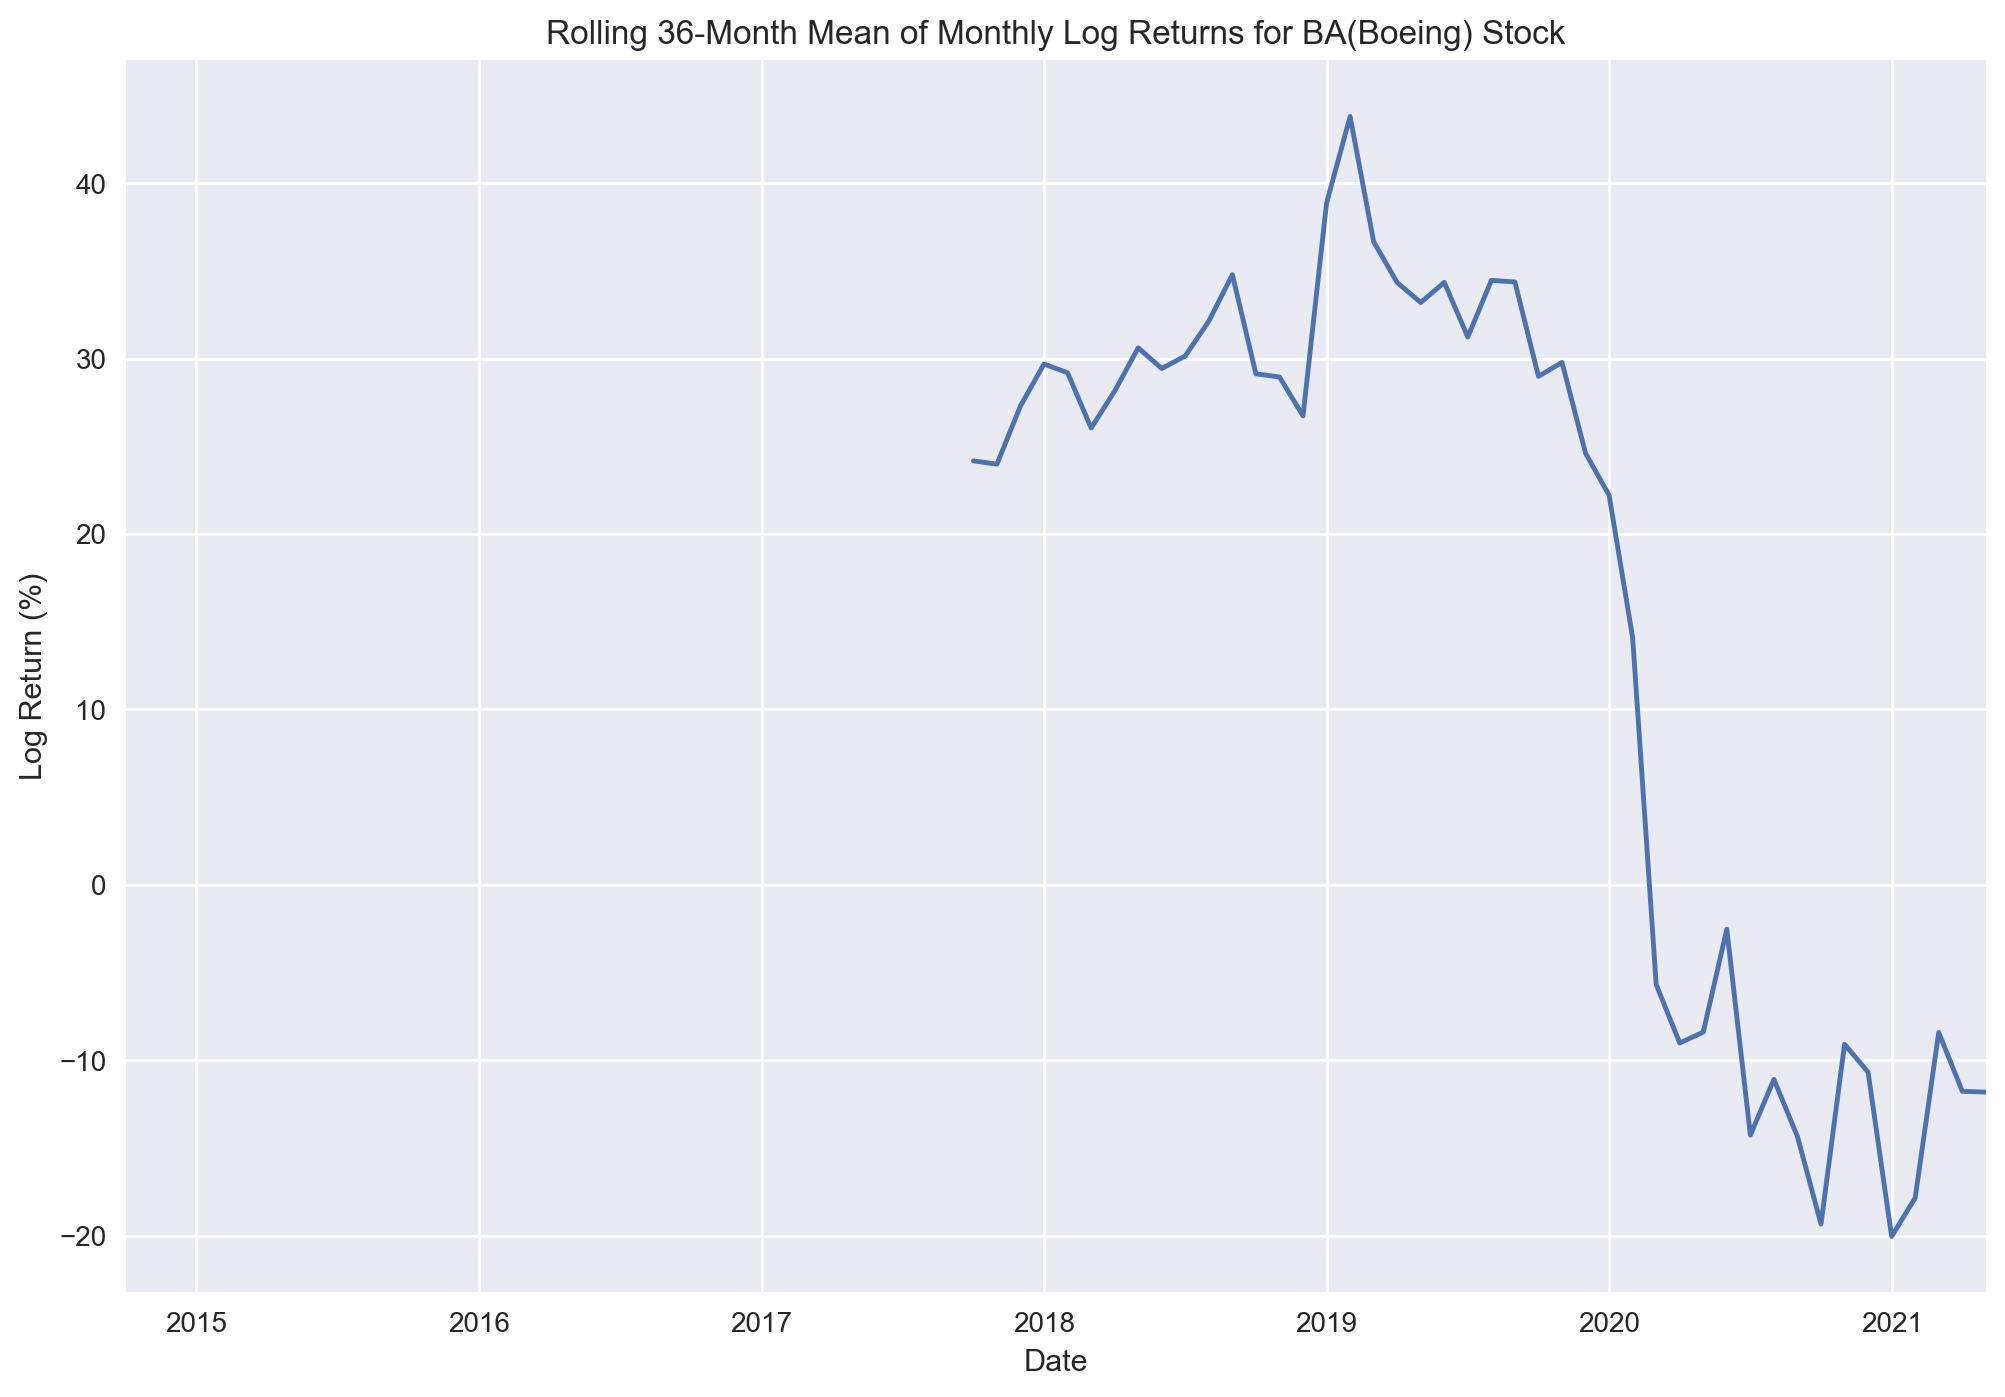

In [ ]:
monthly_log_ret.rolling(36).mean().mul(12*100).plot(figsize = (12, 8))
plt.title("Rolling 36-Month Mean of Monthly Log Returns for BA(Boeing) Stock")
plt.ylabel("Log Return (%)")
plt.xlabel("Date")
plt.show()

## Short Selling / Short Positions (Part 1)

What´s the rational behind short selling an instrument? <br>
__-> making profits/positive returns when prices fall.__

__Stocks Example:__

Today an Investor __buys__ the ABC Stock for USD 100. One day later he __sells__ the stock for USD 110. <br> 
__-> Profit: USD 10__ <br>
->__Long Position__ (benefit from rising prices):

Today an Investor __borrows__ the ABC Stock from another Investor and __sells__ it for USD 100. One day later he __buys__ the stock for USD 90 and __returns__ it to the lender.<br>
__-> Profit: USD 10__  <br>
->__Short Position__ (benefit from falling prices):

In some countries (and for some instruments like stocks) short selling is prohibited. <br>
Most intuitive/popular use case for short selling: __Currencies (Forex)__

## Short Selling / Short Positions (Part 2)

__EUR/USD__ ("Long Euro" == "Short USD")

In [ ]:
t0 = 1.10
t1 = 1.25

Today an Investor __buys__ EUR 1 and pays USD 1.10. One day later he __sells__ EUR 1 for USD 1.25 <br>
__-> Profit: USD 0.15__  <br>
->__Long Position Euro__ (benefit from rising EUR prices):

In [ ]:
t1 / t0 - 1 # The EUR appreciates by 13.64% relative to USD (simple return)

-> EUR __Long__ Position returns __+13.64%__ (simple return) 

What return would you expect for the corresponding EUR __Short__ position? That´s a "no brainer": __-13.64%__, right? 

__Surprisingly, that´s incorrect!!!__

Inverse Rate: __USD/EUR__ ("Short Euro" == "Long USD")

In [ ]:
t0 = 1 / 1.10
t1 = 1 / 1.25

In [ ]:
print(t0, t1)

0.9090909090909091 0.8


Today an Investor __buys__ USD 1 and pays 0.9091 Euro. One day later he __sells__ USD 1 for EUR 0.8 __<br>
-> Loss: EUR 0.1091__  <br>

In [ ]:
t1 / t0 - 1 # The USD depreciates by 12.0% relative to EUR

-0.11999999999999988

-> EUR __Short__ Position returns __-12.0%__ (simple return)

__Take Home: When using simple returns, long position return != short position return * (-1)__ <br>
__-> Use log returns!__

## Short Selling / Short Positions (Part 3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.6f}'.format
plt.style.use("seaborn-v0_8")

In [ ]:
close = pd.read_csv("close.csv", index_col = "Date", parse_dates = ["Date"])
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,124.669998,383.614990,1.262834,1214.599976,45.900002,16804.710938
2014-10-02,124.169998,375.071991,1.262419,1214.199951,45.759998,16801.050781
2014-10-03,126.360001,359.511993,1.267058,1192.199951,46.090000,17009.689453
2014-10-06,126.260002,330.079010,1.251361,1206.699951,46.090000,16991.910156
2014-10-07,123.320000,336.187012,1.264606,1211.699951,45.529999,16719.390625
...,...,...,...,...,...,...
2021-05-24,237.440002,38705.980469,1.218324,1884.599976,250.779999,34393.980469
2021-05-25,240.740005,38402.222656,1.221464,1898.099976,251.720001,34312.460938
2021-05-26,241.369995,39294.199219,1.224909,1901.300049,251.490005,34323.050781


In [ ]:
close["USDEUR=X"] = 1/close["EURUSD=X"]

In [ ]:
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
Date,,,,,,,
2014-10-01,124.669998,383.614990,1.262834,1214.599976,45.900002,16804.710938,0.791870
2014-10-02,124.169998,375.071991,1.262419,1214.199951,45.759998,16801.050781,0.792130
2014-10-03,126.360001,359.511993,1.267058,1192.199951,46.090000,17009.689453,0.789230
2014-10-06,126.260002,330.079010,1.251361,1206.699951,46.090000,16991.910156,0.799130
2014-10-07,123.320000,336.187012,1.264606,1211.699951,45.529999,16719.390625,0.790760
...,...,...,...,...,...,...,...
2021-05-24,237.440002,38705.980469,1.218324,1884.599976,250.779999,34393.980469,0.820800
2021-05-25,240.740005,38402.222656,1.221464,1898.099976,251.720001,34312.460938,0.818690
2021-05-26,241.369995,39294.199219,1.224909,1901.300049,251.490005,34323.050781,0.816387


In [ ]:
fx = close[["EURUSD=X", "USDEUR=X"]].dropna().copy()
fx

,EURUSD=X,USDEUR=X
Date,,
2014-10-01,1.262834,0.791870
2014-10-02,1.262419,0.792130
2014-10-03,1.267058,0.789230
2014-10-06,1.251361,0.799130
2014-10-07,1.264606,0.790760
...,...,...
2021-05-24,1.218324,0.820800
2021-05-25,1.221464,0.818690
2021-05-26,1.224909,0.816387


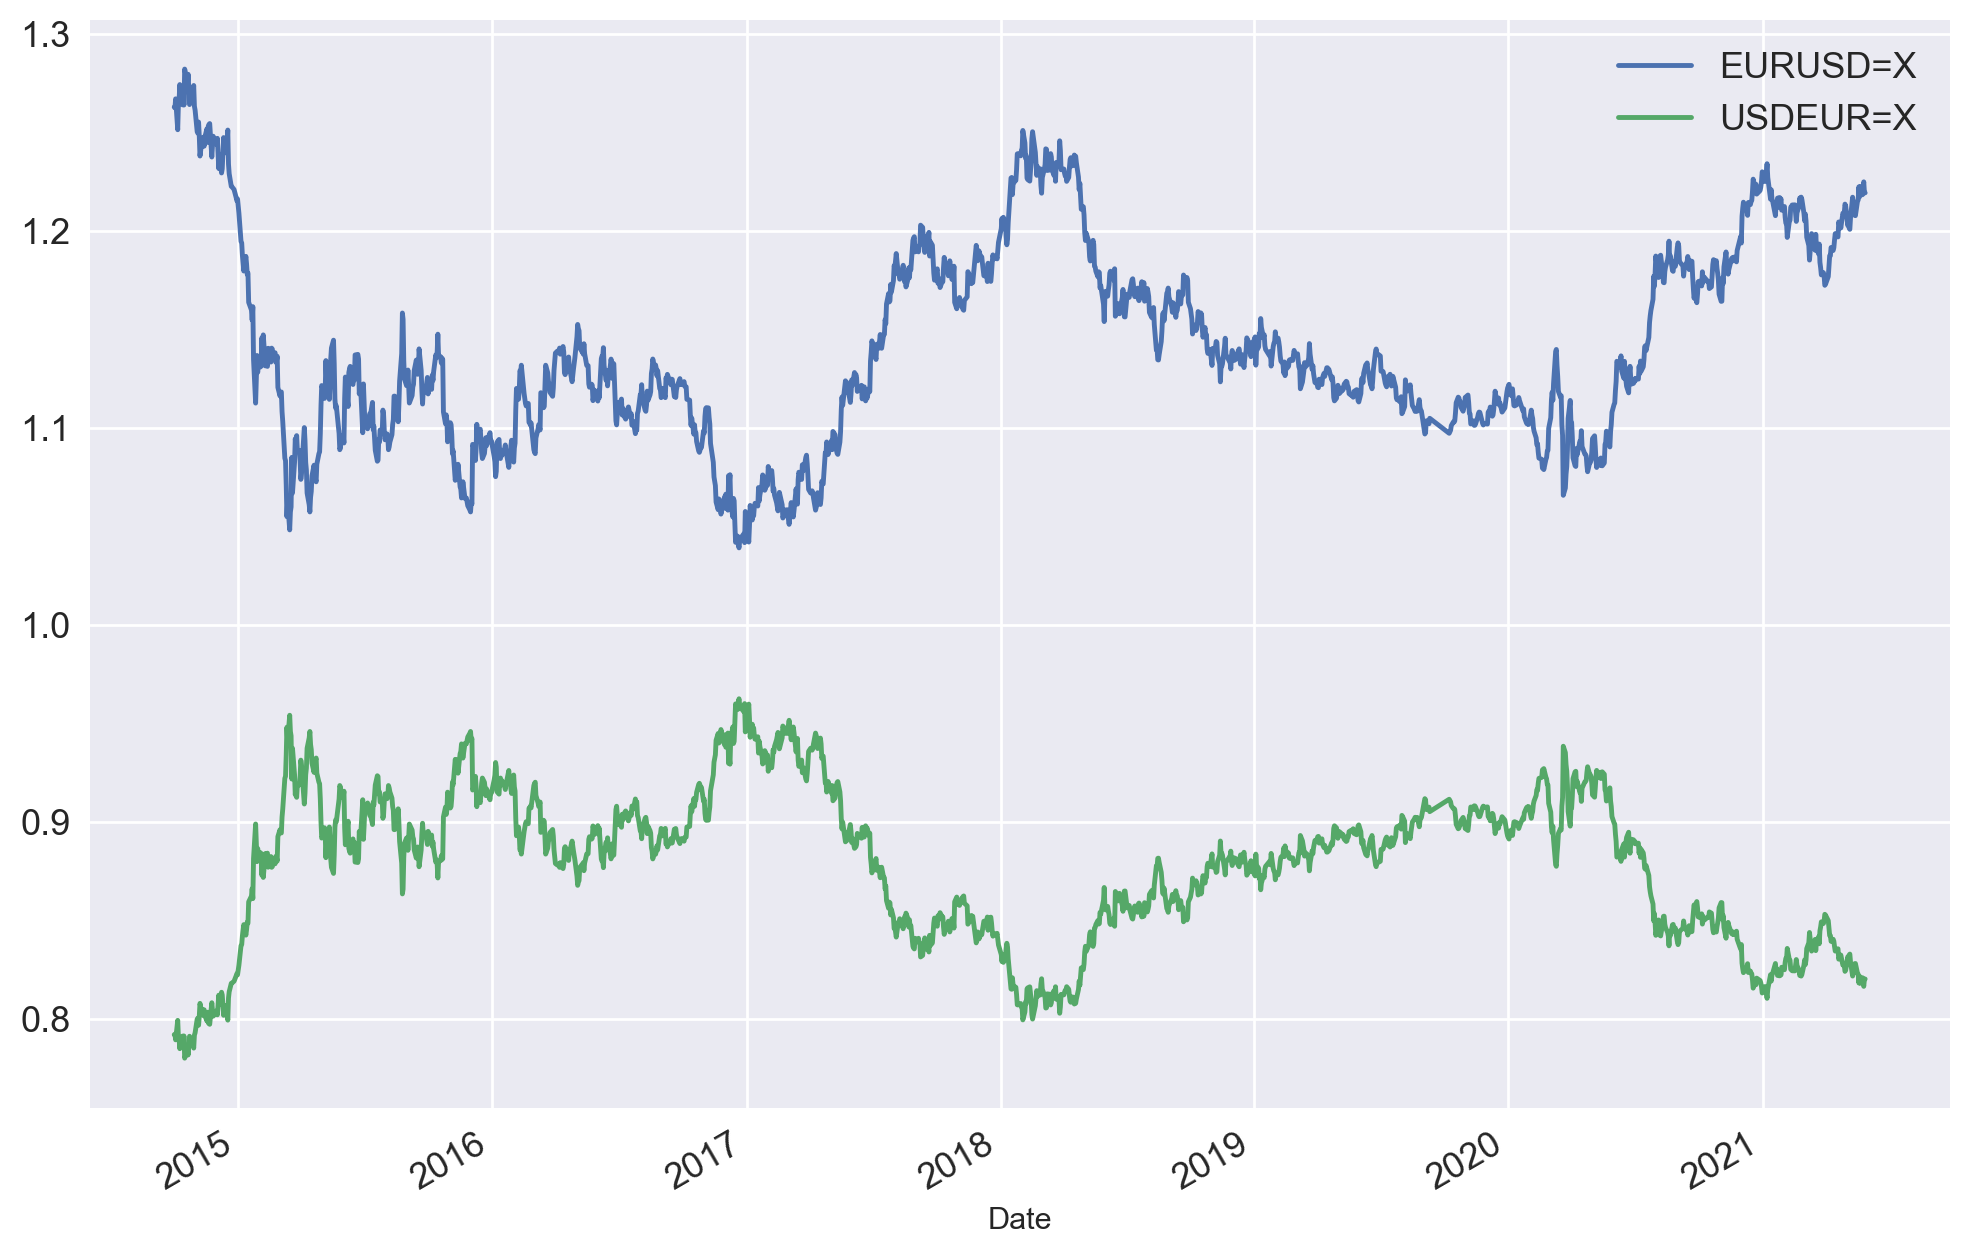

In [ ]:
fx.plot(figsize = (12,8), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

In [ ]:
simple_ret = fx.pct_change() # simple returns
simple_ret

,EURUSD=X,USDEUR=X
Date,,
2014-10-01,NaN,NaN
2014-10-02,-0.000328,0.000328
2014-10-03,0.003674,-0.003661
2014-10-06,-0.012389,0.012544
2014-10-07,0.010585,-0.010474
...,...,...
2021-05-24,-0.003448,0.003460
2021-05-25,0.002577,-0.002571
2021-05-26,0.002821,-0.002813


In [ ]:
simple_ret.add(1).prod() - 1 # compound simple returns

EURUSD=X   -0.034458
USDEUR=X    0.035688
dtype: float64

__-> For simple returns: long position returns != short position returns * (-1)__

In [ ]:
log_ret = np.log(fx).diff() # log returns
log_ret

,EURUSD=X,USDEUR=X
Date,,
2014-10-01,NaN,NaN
2014-10-02,-0.000328,0.000328
2014-10-03,0.003668,-0.003668
2014-10-06,-0.012466,0.012466
2014-10-07,0.010529,-0.010529
...,...,...
2021-05-24,-0.003454,0.003454
2021-05-25,0.002574,-0.002574
2021-05-26,0.002817,-0.002817


In [ ]:
log_ret.sum() # cumulative log returns

EURUSD=X   -0.035066
USDEUR=X    0.035066
dtype: float64

__-> For log returns: long position returns == short position returns * (-1)__

In [ ]:
norm_fx = log_ret.cumsum().apply(np.exp) # normalized prices (Base 1)
norm_fx

,EURUSD=X,USDEUR=X
Date,,
2014-10-01,NaN,NaN
2014-10-02,0.999672,1.000328
2014-10-03,1.003345,0.996666
2014-10-06,0.990915,1.009168
2014-10-07,1.001404,0.998598
...,...,...
2021-05-24,0.964754,1.036534
2021-05-25,0.967240,1.033869
2021-05-26,0.969969,1.030961


In [ ]:
norm_fx.iloc[0] = [1, 1]

In [ ]:
norm_fx

,EURUSD=X,USDEUR=X
Date,,
2014-10-01,1.000000,1.000000
2014-10-02,0.999672,1.000328
2014-10-03,1.003345,0.996666
2014-10-06,0.990915,1.009168
2014-10-07,1.001404,0.998598
...,...,...
2021-05-24,0.964754,1.036534
2021-05-25,0.967240,1.033869
2021-05-26,0.969969,1.030961


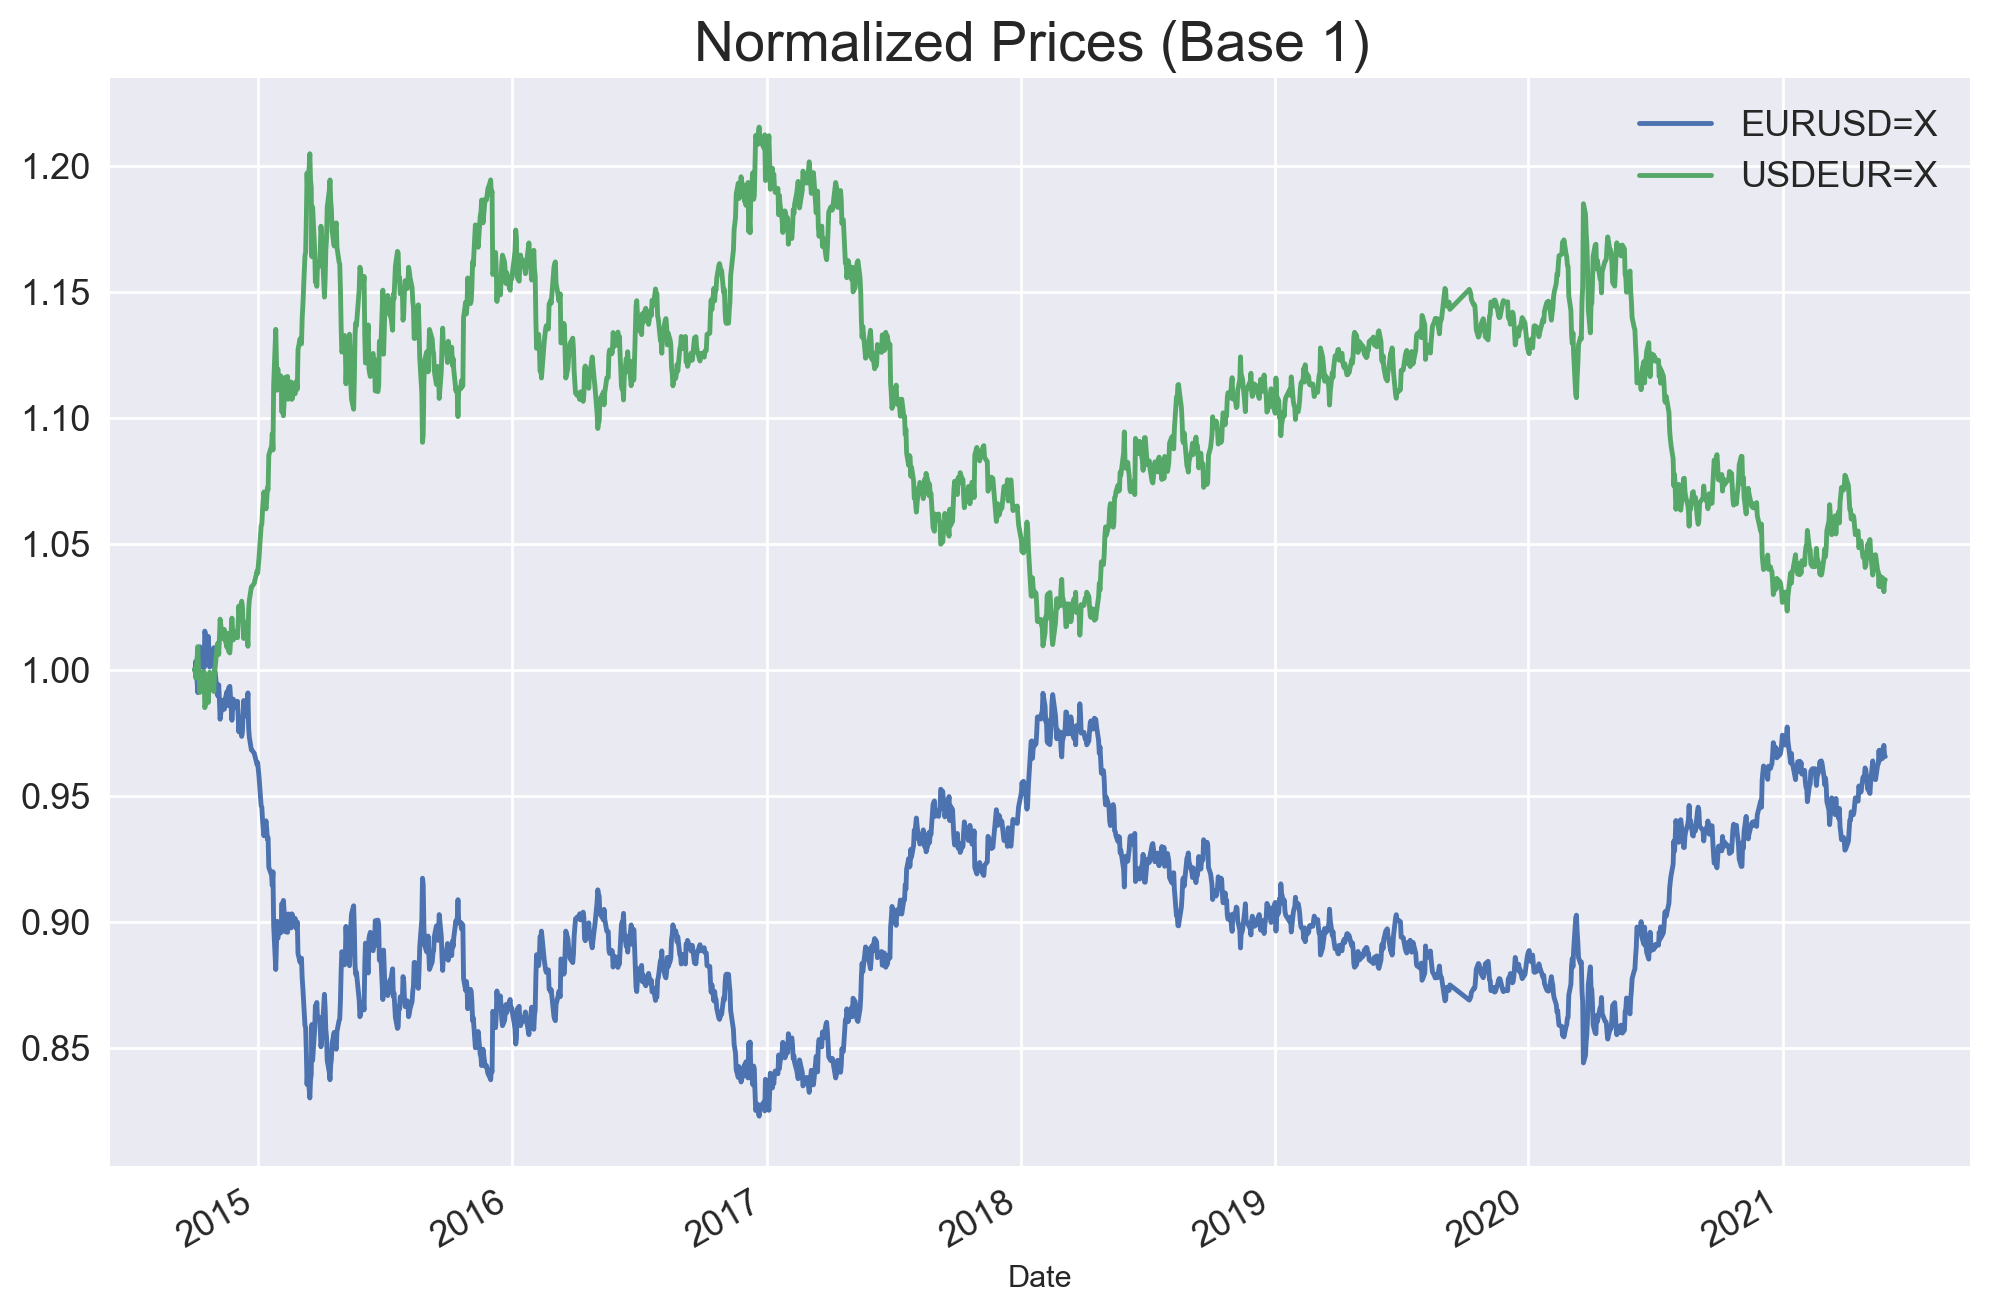

In [ ]:
norm_fx.plot(figsize = (12,8), fontsize = 13 )
plt.title("Normalized Prices (Base 1) ", fontsize = 20)
plt.legend(fontsize = 13)
plt.show()

--------------------------------------------

__Coding Challenge #6__

1. Calculate daily log returns for Boeing.

2. Calculate the annualized mean and annualized std (assume 252 trading days per year) for a short position in Boeing (ignore Trading and Borrowing Costs).

---------------------------------------------

In [ ]:
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
Date,,,,,,,
2014-10-01,124.669998,383.614990,1.262834,1214.599976,45.900002,16804.710938,0.791870
2014-10-02,124.169998,375.071991,1.262419,1214.199951,45.759998,16801.050781,0.792130
2014-10-03,126.360001,359.511993,1.267058,1192.199951,46.090000,17009.689453,0.789230
2014-10-06,126.260002,330.079010,1.251361,1206.699951,46.090000,16991.910156,0.799130
2014-10-07,123.320000,336.187012,1.264606,1211.699951,45.529999,16719.390625,0.790760
...,...,...,...,...,...,...,...
2021-05-24,237.440002,38705.980469,1.218324,1884.599976,250.779999,34393.980469,0.820800
2021-05-25,240.740005,38402.222656,1.221464,1898.099976,251.720001,34312.460938,0.818690
2021-05-26,241.369995,39294.199219,1.224909,1901.300049,251.490005,34323.050781,0.816387


In [ ]:
ba = close.BA.to_frame().copy()
ba

,BA
Date,
2014-10-01,124.669998
2014-10-02,124.169998
2014-10-03,126.360001
2014-10-06,126.260002
2014-10-07,123.320000
...,...
2021-05-24,237.440002
2021-05-25,240.740005
2021-05-26,241.369995


In [ ]:
ba_log_ret = np.log(ba).diff()
ba_log_ret

,BA
Date,
2014-10-01,NaN
2014-10-02,-0.004019
2014-10-03,0.017483
2014-10-06,-0.000792
2014-10-07,-0.023561
...,...
2021-05-24,0.011096
2021-05-25,0.013803
2021-05-26,0.002613


In [ ]:
ba_annualized_mean_return = ba_log_ret.mean()*252
ba_annualized_mean_return

BA   0.105457
dtype: float64

In [ ]:
ba_annaulized_std = np.sqrt(ba_log_ret.var()*252)
ba_annaulized_std

BA   0.418635
dtype: float64

## Covariance and Correlation

Do instruments/assets __move together__ (and to what extent)? <br>

Three cases:
- unrelated (__no__ relationship/correlation)
- moving together (__positive__ relationship/correlation)
- moving in opposite directions (__negative__ relationship/correlation) 

__-> Correlation between instruments/assets play an important role in portfolio management.__

In [ ]:
import pandas as pd
import numpy as np
pd.options.display.float_format = '{:.4f}'.format
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
%config InlineBackend.figure_format = "retina"

In [ ]:
close = pd.read_csv("close.csv", index_col = "Date", parse_dates = ["Date"])
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,124.6700,383.6150,1.2628,1214.6000,45.9000,16804.7109
2014-10-02,124.1700,375.0720,1.2624,1214.2000,45.7600,16801.0508
2014-10-03,126.3600,359.5120,1.2671,1192.2000,46.0900,17009.6895
2014-10-06,126.2600,330.0790,1.2514,1206.7000,46.0900,16991.9102
2014-10-07,123.3200,336.1870,1.2646,1211.7000,45.5300,16719.3906
...,...,...,...,...,...,...
2021-05-24,237.4400,38705.9805,1.2183,1884.6000,250.7800,34393.9805
2021-05-25,240.7400,38402.2227,1.2215,1898.1000,251.7200,34312.4609
2021-05-26,241.3700,39294.1992,1.2249,1901.3000,251.4900,34323.0508


In [ ]:
close["USDEUR=X"] = 1/close["EURUSD=X"]
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
Date,,,,,,,
2014-10-01,124.6700,383.6150,1.2628,1214.6000,45.9000,16804.7109,0.7919
2014-10-02,124.1700,375.0720,1.2624,1214.2000,45.7600,16801.0508,0.7921
2014-10-03,126.3600,359.5120,1.2671,1192.2000,46.0900,17009.6895,0.7892
2014-10-06,126.2600,330.0790,1.2514,1206.7000,46.0900,16991.9102,0.7991
2014-10-07,123.3200,336.1870,1.2646,1211.7000,45.5300,16719.3906,0.7908
...,...,...,...,...,...,...,...
2021-05-24,237.4400,38705.9805,1.2183,1884.6000,250.7800,34393.9805,0.8208
2021-05-25,240.7400,38402.2227,1.2215,1898.1000,251.7200,34312.4609,0.8187
2021-05-26,241.3700,39294.1992,1.2249,1901.3000,251.4900,34323.0508,0.8164


In [ ]:
returns = close.apply(lambda x: np.log(x.dropna() / x.dropna().shift()))
returns

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
Date,,,,,,,
2014-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-10-02,-0.0040,-0.0225,-0.0003,-0.0003,-0.0031,-0.0002,0.0003
2014-10-03,0.0175,-0.0424,0.0037,-0.0183,0.0072,0.0123,-0.0037
2014-10-06,-0.0008,-0.0854,-0.0125,0.0121,0.0000,-0.0010,0.0125
2014-10-07,-0.0236,0.0183,0.0105,0.0041,-0.0122,-0.0162,-0.0105
...,...,...,...,...,...,...,...
2021-05-24,0.0111,0.0369,-0.0035,0.0042,0.0226,0.0054,0.0035
2021-05-25,0.0138,-0.0079,0.0026,0.0071,0.0037,-0.0024,-0.0026
2021-05-26,0.0026,0.0230,0.0028,0.0017,-0.0009,0.0003,-0.0028


In [ ]:
# returns1 = close.apply(lambda x: np.log(x.dropna()).diff()) # easy to interpret
# returns1

In [ ]:
returns.cov() # covariance (hard to interpret)

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
BA,0.0007,0.0002,0.0000,0.0000,0.0002,0.0002,-0.0000
BTC-USD,0.0002,0.0022,-0.0000,0.0000,0.0001,0.0001,0.0000
EURUSD=X,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000
GC=F,0.0000,0.0000,0.0000,0.0001,0.0000,-0.0000,-0.0000
MSFT,0.0002,0.0001,-0.0000,0.0000,0.0003,0.0002,0.0000
^DJI,0.0002,0.0001,0.0000,-0.0000,0.0002,0.0001,-0.0000
USDEUR=X,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000


In [ ]:
returns.corr() # correlation coefficient (easy to interpret)

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
BA,1.0000,0.1355,0.0367,0.0109,0.4148,0.7201,-0.0367
BTC-USD,0.1355,1.0000,-0.0179,0.0890,0.1292,0.1672,0.0179
EURUSD=X,0.0367,-0.0179,1.0000,0.0608,-0.0194,0.0311,-1.0000
GC=F,0.0109,0.0890,0.0608,1.0000,0.0033,-0.0037,-0.0608
MSFT,0.4148,0.1292,-0.0194,0.0033,1.0000,0.7370,0.0194
^DJI,0.7201,0.1672,0.0311,-0.0037,0.7370,1.0000,-0.0311
USDEUR=X,-0.0367,0.0179,-1.0000,-0.0608,0.0194,-0.0311,1.0000


In [ ]:
ret_corr = returns.corr().style.background_gradient(cmap = "RdYlBu", vmin = -1, vmax = 1)
ret_corr

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
BA,1.000000,0.135502,0.036702,0.010917,0.414842,0.720115,-0.036702
BTC-USD,0.135502,1.000000,-0.017889,0.088975,0.129230,0.167200,0.017889
EURUSD=X,0.036702,-0.017889,1.000000,0.060827,-0.019376,0.031148,-1.000000
GC=F,0.010917,0.088975,0.060827,1.000000,0.003321,-0.003714,-0.060827
MSFT,0.414842,0.129230,-0.019376,0.003321,1.000000,0.736979,0.019376
^DJI,0.720115,0.167200,0.031148,-0.003714,0.736979,1.000000,-0.031148
USDEUR=X,-0.036702,0.017889,-1.000000,-0.060827,0.019376,-0.031148,1.000000


In [ ]:
np.around(returns, 2) ==  0

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
Date,,,,,,,
2014-10-01,False,False,False,False,False,False,False
2014-10-02,True,False,True,True,True,True,True
2014-10-03,False,False,True,False,False,False,True
2014-10-06,True,False,False,False,True,True,False
2014-10-07,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
2021-05-24,False,False,True,True,False,False,True
2021-05-25,False,False,True,False,True,True,True
2021-05-26,True,False,True,True,True,True,True


Three cases:
- no correlation: __correlation coefficient == 0__
- moving together: __0 < correlation coefficient <= 1__ (positive)
- moving in opposite directions: __-1 <= correlation coefficient < 0__ (negative)

In [ ]:
import seaborn as sns

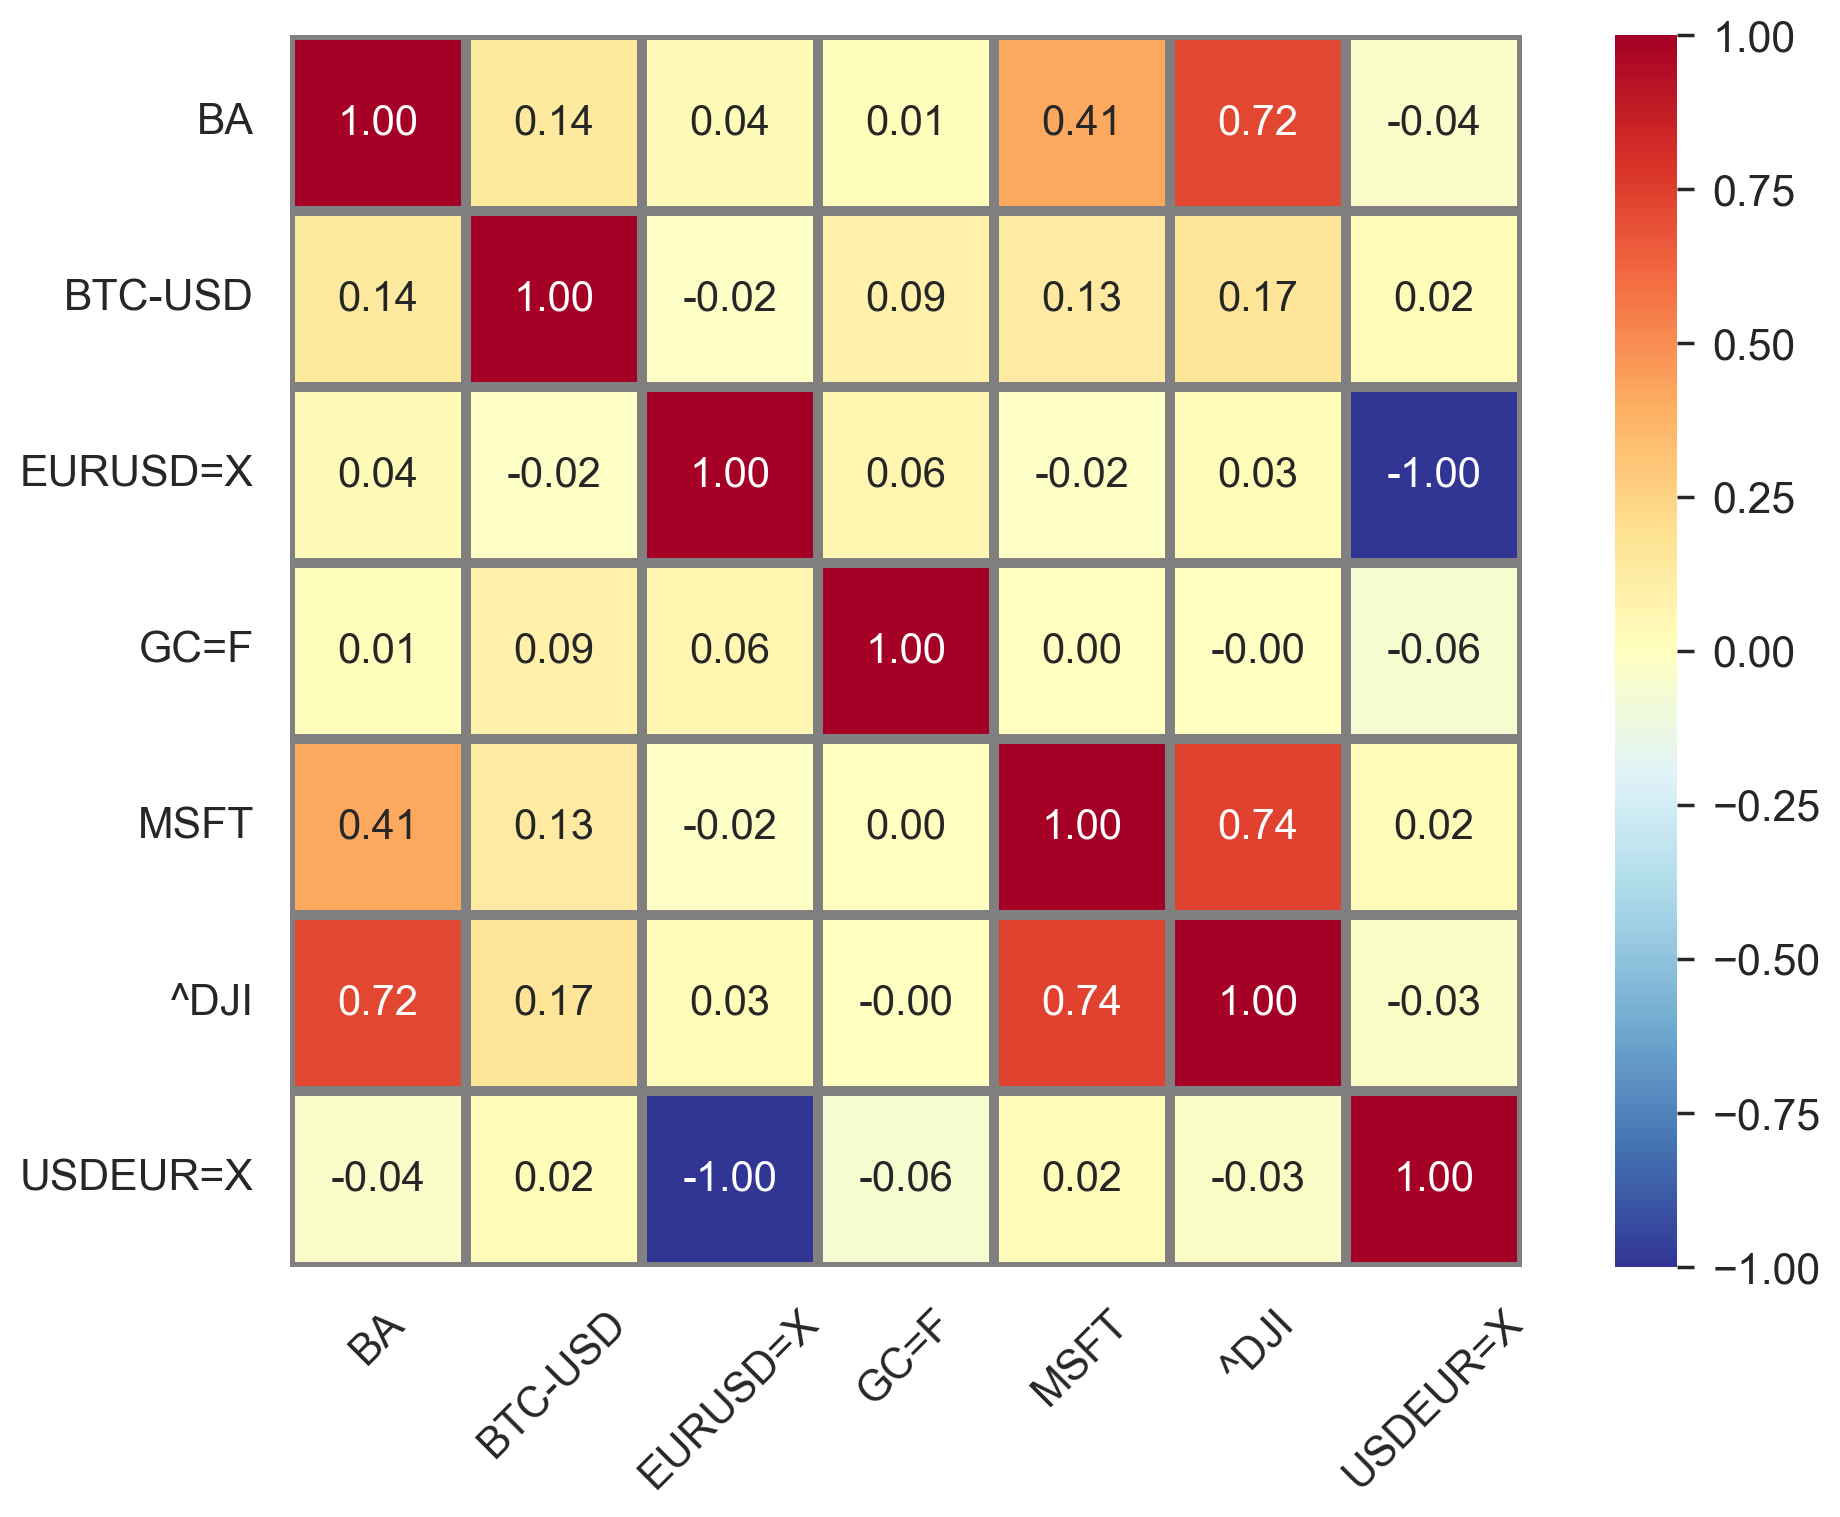

In [ ]:
plt.figure(figsize=(12,8))
sns.set(font_scale=1.4)
sns.heatmap(
    returns.corr(),
    square = True, 
    cmap = "RdYlBu_r",
    lw = 3,
    fmt =".2f",
    linecolor = "gray", 
    annot = True, 
    annot_kws={"size":15}, 
    vmin = -1, vmax = 1
    )
plt.xticks(rotation = 45)

plt.show()

__Take Home: Similar assets are (highly) positive correlated. Different assets exhibit low/no/negative correlation.__ <br>
#### --> In portfolio management it´s beneficial to have assets with low/no/negative correlation (portfolio diversification effect).

## Portfolio of Assets and Portfolio Returns

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
prices = pd.DataFrame(
    data = {
    "Asset_A": [100, 112],
    "Asset_B":[100, 104]}, 
    index = [0, 1]
    )
prices

,Asset_A,Asset_B
0,100,100
1,112,104


In [ ]:
prices["Total"] = prices.Asset_A + prices.Asset_B

In [ ]:
prices

,Asset_A,Asset_B,Total
0,100,100,200
1,112,104,216


In [ ]:
returns = prices.pct_change() # simple returns
returns

,Asset_A,Asset_B,Total
0,NaN,NaN,NaN
1,0.1200,0.0400,0.0800


In [ ]:
0.5 * 0.12 + 0.5 * 0.04 # correct (portfolio return == weighted average of simple returns)

0.08

In [ ]:
log_returns = np.log(prices / prices.shift()) # log returns
log_returns

,Asset_A,Asset_B,Total
0,NaN,NaN,NaN
1,0.1133,0.0392,0.0770


In [ ]:
0.5 * log_returns.iloc[1,0] + 0.5 * log_returns.iloc[1,1] # incorrect (portfolio return != weighted average of log returns)

np.float64(0.0762746992301423)

__Take Home: While log returns are time-additive, they are not asset-additive.__ <br>
(While simple returns are not time-additive, they are asset-additive.)

## Margin Trading & Levered Returns (Part 1)

__Definition__: "Margin trading refers to the practice of using __borrowed funds__ from a broker to trade a financial asset, which forms the collateral for the loan from the broker." (Investopedia.com) 

In Simple Words: Investors __don´t pay the full price__ but they get the full benefit (less borrowing costs).

It´s a two edged sword: Leverage __amplifies both gains and losses__. <br> In the event of a loss, the collateral gets reduced and the Investor either posts additional margin or the brokers closes the position.

__Example__

A Trader buys a stock (stock price: 100) __on margin (50%)__. After one day the price increases to 110.<br>
Calculate __unlevered return__ and __levered return__.

In [ ]:
P0 = 100
P1 = 110
leverage = 2
margin = P0/2 # margin = P0/leverage

In [ ]:
margin

50.0

In [ ]:
unlev_return = (P1 - P0) / P0 # simple return
unlev_return

0.1

In [ ]:
lev_return = (P1 - P0) / margin  #  levered simple return = simple return * leverage
lev_return*200

40.0

In [ ]:
lev_return == unlev_return * leverage # this relationship is true for simple returns...

True

In [ ]:
unlev_log_return = np.log(P1/P0) # log return
unlev_log_return*100

np.float64(9.531017980432493)

In [ ]:
lev_log_return = np.log((P1 - P0) / margin + 1) # log return
lev_log_return

np.float64(0.1823215567939546)

In [ ]:
np.log(2*(P1/P0)-1)

np.float64(0.1823215567939548)

In [ ]:
lev_log_return == unlev_log_return * leverage # this relationship does not hold for log returns...

np.False_

__Take Home: To calculate levered returns, don´t multiply leverage with log returns!__

## Margin Trading & Levered Returns (Part 2)

__Hypothesis: For (highly) profitable Investment: The more leverage, the better?__

In [ ]:
import pandas as pd
import numpy as np
pd.options.display.float_format = '{:.4f}'.format
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [ ]:
msft = pd.read_csv("msft.csv", index_col = "Date", parse_dates = ["Date"] , usecols = ["Date", "Price"])
msft

,Price
Date,
2014-10-01,45.9000
2014-10-02,45.7600
2014-10-03,46.0900
2014-10-06,46.0900
2014-10-07,45.5300
...,...
2021-05-24,250.7800
2021-05-25,251.7200
2021-05-26,251.4900


In [ ]:
msft["Log_Return"] = np.log(msft.Price).diff()

In [ ]:
msft

,Price,Log_Return
Date,,
2014-10-01,45.9000,NaN
2014-10-02,45.7600,-0.0031
2014-10-03,46.0900,0.0072
2014-10-06,46.0900,0.0000
2014-10-07,45.5300,-0.0122
...,...,...
2021-05-24,250.7800,0.0226
2021-05-25,251.7200,0.0037
2021-05-26,251.4900,-0.0009


In [ ]:
msft["Simple_Ret"] = msft.Price.pct_change() # simple returns

In [ ]:
msft

,Price,Log_Return,Simple_Ret
Date,,,
2014-10-01,45.9000,NaN,NaN
2014-10-02,45.7600,-0.0031,-0.0031
2014-10-03,46.0900,0.0072,0.0072
2014-10-06,46.0900,0.0000,0.0000
2014-10-07,45.5300,-0.0122,-0.0122
...,...,...,...
2021-05-24,250.7800,0.0226,0.0229
2021-05-25,251.7200,0.0037,0.0037
2021-05-26,251.4900,-0.0009,-0.0009


In [ ]:
leverage = 2 # margin 1/2 * 100 = 50%

In [ ]:
margin = 1 / leverage * 100
margin

50.0

(Simplified) __Assumptions__:
- Restore leverage on a daily basis (by buying/selling shares)
- no trading costs
- no borrowing costs

In [ ]:
msft["Lev_Simple_Returns"] = msft.Simple_Ret.mul(leverage) # levered simple returns
msft

,Price,Log_Return,Simple_Ret,Lev_Simple_Returns
Date,,,,
2014-10-01,45.9000,NaN,NaN,NaN
2014-10-02,45.7600,-0.0031,-0.0031,-0.0061
2014-10-03,46.0900,0.0072,0.0072,0.0144
2014-10-06,46.0900,0.0000,0.0000,0.0000
2014-10-07,45.5300,-0.0122,-0.0122,-0.0243
...,...,...,...,...
2021-05-24,250.7800,0.0226,0.0229,0.0458
2021-05-25,251.7200,0.0037,0.0037,0.0075
2021-05-26,251.4900,-0.0009,-0.0009,-0.0018


In [ ]:
msft["Lev_Simple_Returns"] = np.where(msft["Lev_Simple_Returns"] < -1, -1, msft["Lev_Simple_Returns"])

In [ ]:
msft

,Price,Log_Return,Simple_Ret,Lev_Simple_Returns
Date,,,,
2014-10-01,45.9000,NaN,NaN,NaN
2014-10-02,45.7600,-0.0031,-0.0031,-0.0061
2014-10-03,46.0900,0.0072,0.0072,0.0144
2014-10-06,46.0900,0.0000,0.0000,0.0000
2014-10-07,45.5300,-0.0122,-0.0122,-0.0243
...,...,...,...,...
2021-05-24,250.7800,0.0226,0.0229,0.0458
2021-05-25,251.7200,0.0037,0.0037,0.0075
2021-05-26,251.4900,-0.0009,-0.0009,-0.0018


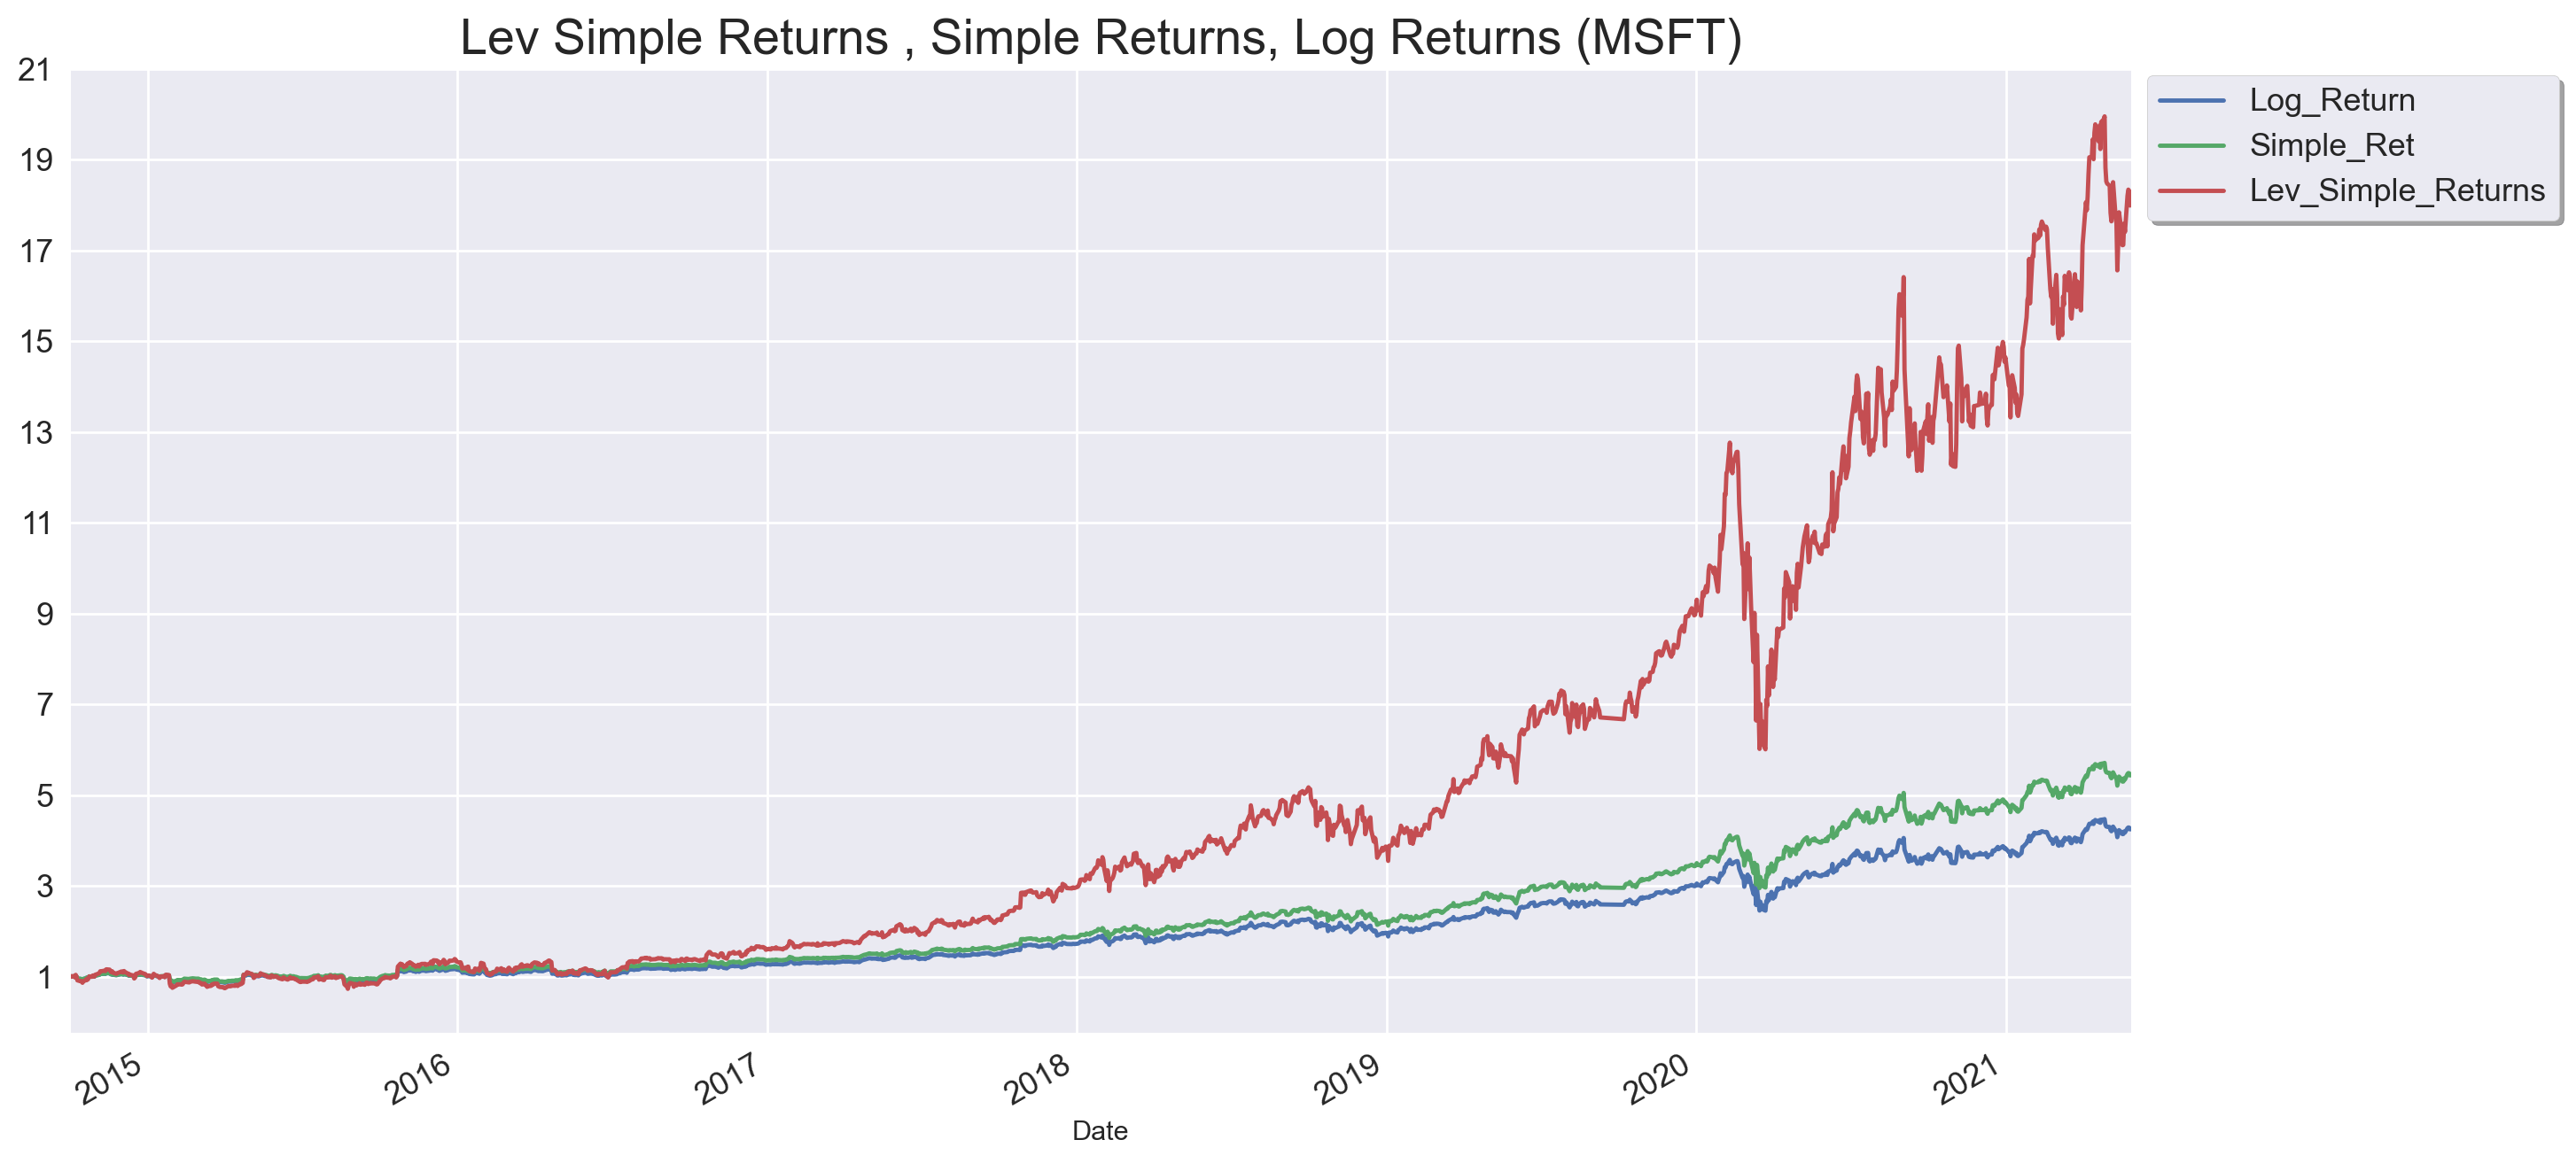

In [ ]:
msft.iloc[: , 1:].add(1).cumprod().plot(figsize = (15, 8), fontsize = 13)
plt.title("Lev Simple Returns , Simple Returns, Log Returns (MSFT)", fontsize = 20)
plt.legend(fontsize = 13 , bbox_to_anchor = (1, 1.01) , fancybox = True, shadow = True , frameon = True)
plt.yticks(range(1,21+1, 2))
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

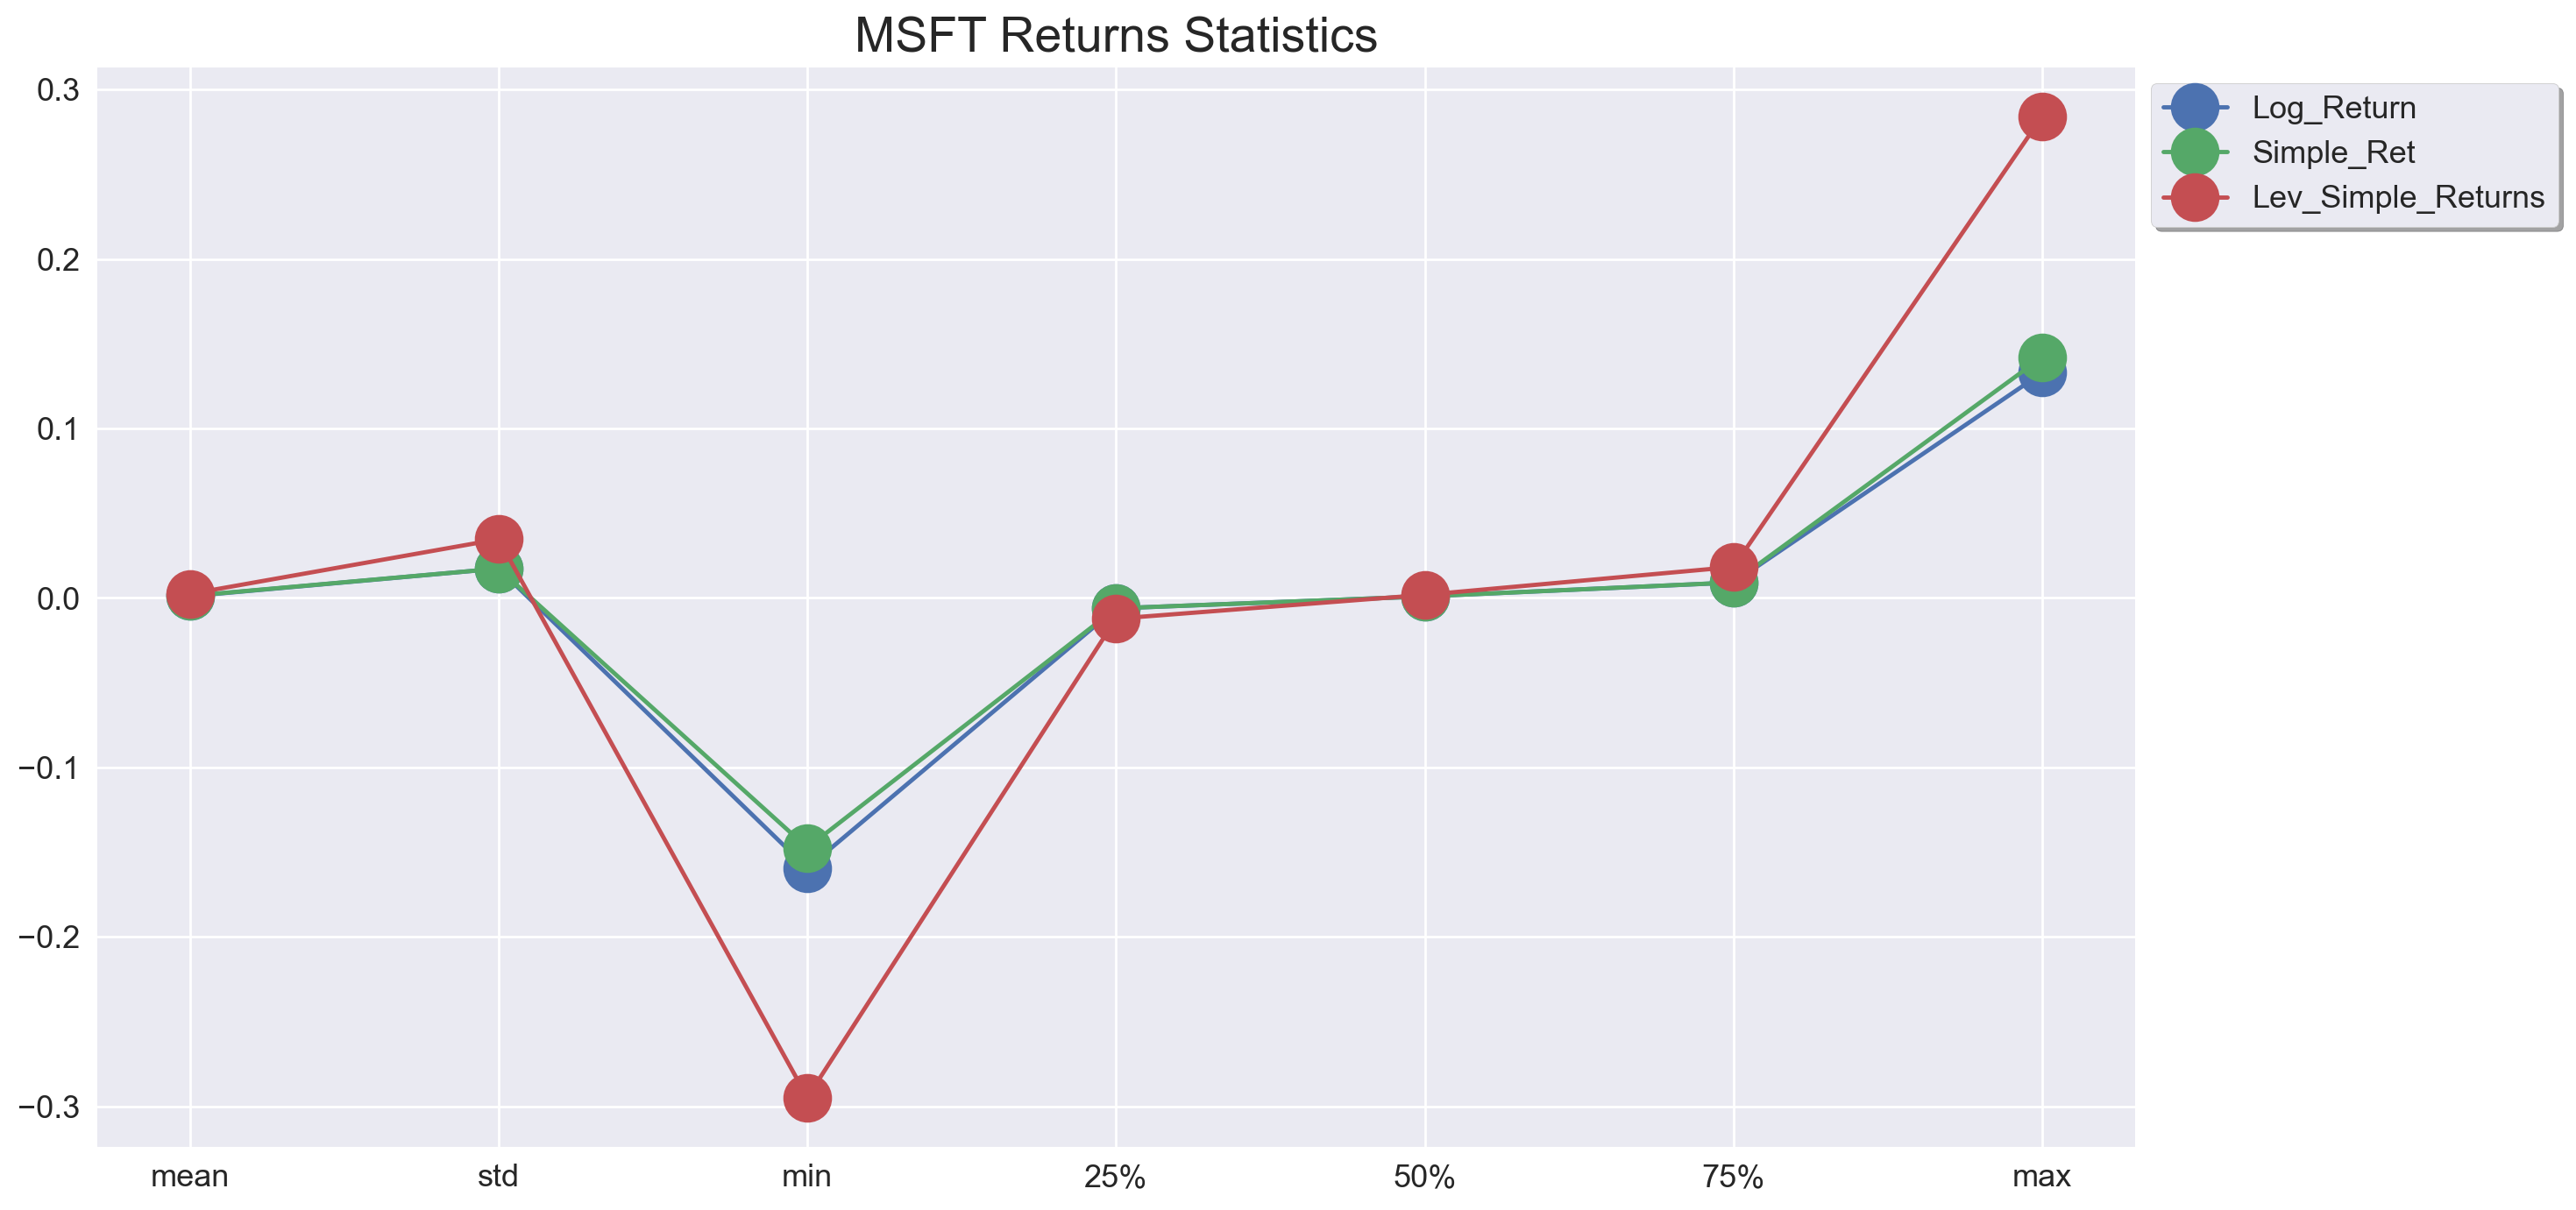

In [ ]:
msft.describe().iloc[1: , 1:].plot(marker = "o", ms = 20, figsize = (15, 8), fontsize = 13)
plt.title("MSFT Returns Statistics", fontsize = 20)
plt.legend(fontsize = 13 , bbox_to_anchor = (1,1) , fancybox = True, shadow = True , frameon = True)
#plt.yticks(range(-40, 30, 5))
plt.show()

In [ ]:
msft.Simple_Ret.max()

0.14216888119914373

In [ ]:
msft.Lev_Simple_Returns.max()

0.28433776239828745

In [ ]:
msft.Simple_Ret.min()

-0.1473903128642552

In [ ]:
msft.Lev_Returns.min()

-1.0

__What happens when leverage greater than...?__

In [ ]:
-1 / msft.Simple_Ret.min()

6.784706406865346

__Take Home:__
1. With Leverage you can (theoretically) __lose more than the initial Margin__ (in practice: margin call / margin closeout before)
2. Even for (highly) profitable instruments: __"The more leverage the better" does not hold__.
3. It´s a two edged (__non-symmetrical__) sword: __Leverage amplifies losses more than it amplifies gains__.

--------------------------------

__Coding Challenge #7__

1. Calculate levered returns for Bitcoin (leverage = 4). 

2. Visualize and compare with unlevered Investment.

3. Some Traders trade Bitcoin with extremely high leverage (> 100). Do you think this is a good idea (assuming no additional/advanced Risk Management Tools)?

---------------------------------------------

In [ ]:
df = pd.read_csv("multi_assets.csv", header = [0, 1], index_col = 0, parse_dates = [0])["Adj Close"]
df

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,108.4067,383.6150,1.2628,1214.6000,40.3334,16804.7109
2014-10-02,107.9719,375.0720,1.2624,1214.2000,40.2103,16801.0508
2014-10-03,109.8762,359.5120,1.2671,1192.2000,40.5003,17009.6895
2014-10-04,NaN,328.8660,NaN,NaN,NaN,NaN
2014-10-05,NaN,320.5100,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2021-05-27,250.7000,38436.9688,1.2193,1895.7000,249.3100,34464.6406
2021-05-28,247.0200,35697.6055,1.2193,1902.5000,249.6800,34529.4492
2021-05-29,NaN,34616.0664,NaN,NaN,NaN,NaN


In [ ]:
leverage = 4 
margin  = 1 / leverage * 100
margin

25.0

In [ ]:
bitcoin = df["BTC-USD"].to_frame().copy()
bitcoin

,BTC-USD
Date,
2014-10-01,383.6150
2014-10-02,375.0720
2014-10-03,359.5120
2014-10-04,328.8660
2014-10-05,320.5100
...,...
2021-05-27,38436.9688
2021-05-28,35697.6055
2021-05-29,34616.0664


In [ ]:
bitcoin["Simple_Returns"] = bitcoin["BTC-USD"].pct_change()
bitcoin["Log_Returns"] = np.log(bitcoin["BTC-USD"]).diff()
bitcoin["lev_Simple_Returns"] = bitcoin["Simple_Returns"] * leverage
bitcoin

C:\Users\ahmad\AppData\Local\Temp\ipykernel_3500\1139913519.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  bitcoin["Simple_Returns"] = bitcoin["BTC-USD"].pct_change()


,BTC-USD,Simple_Returns,Log_Returns,lev_Simple_Returns
Date,,,,
2014-10-01,383.6150,NaN,NaN,NaN
2014-10-02,375.0720,-0.0223,-0.0225,-0.0891
2014-10-03,359.5120,-0.0415,-0.0424,-0.1659
2014-10-04,328.8660,-0.0852,-0.0891,-0.3410
2014-10-05,320.5100,-0.0254,-0.0257,-0.1016
...,...,...,...,...
2021-05-27,38436.9688,-0.0218,-0.0221,-0.0873
2021-05-28,35697.6055,-0.0713,-0.0739,-0.2851
2021-05-29,34616.0664,-0.0303,-0.0308,-0.1212


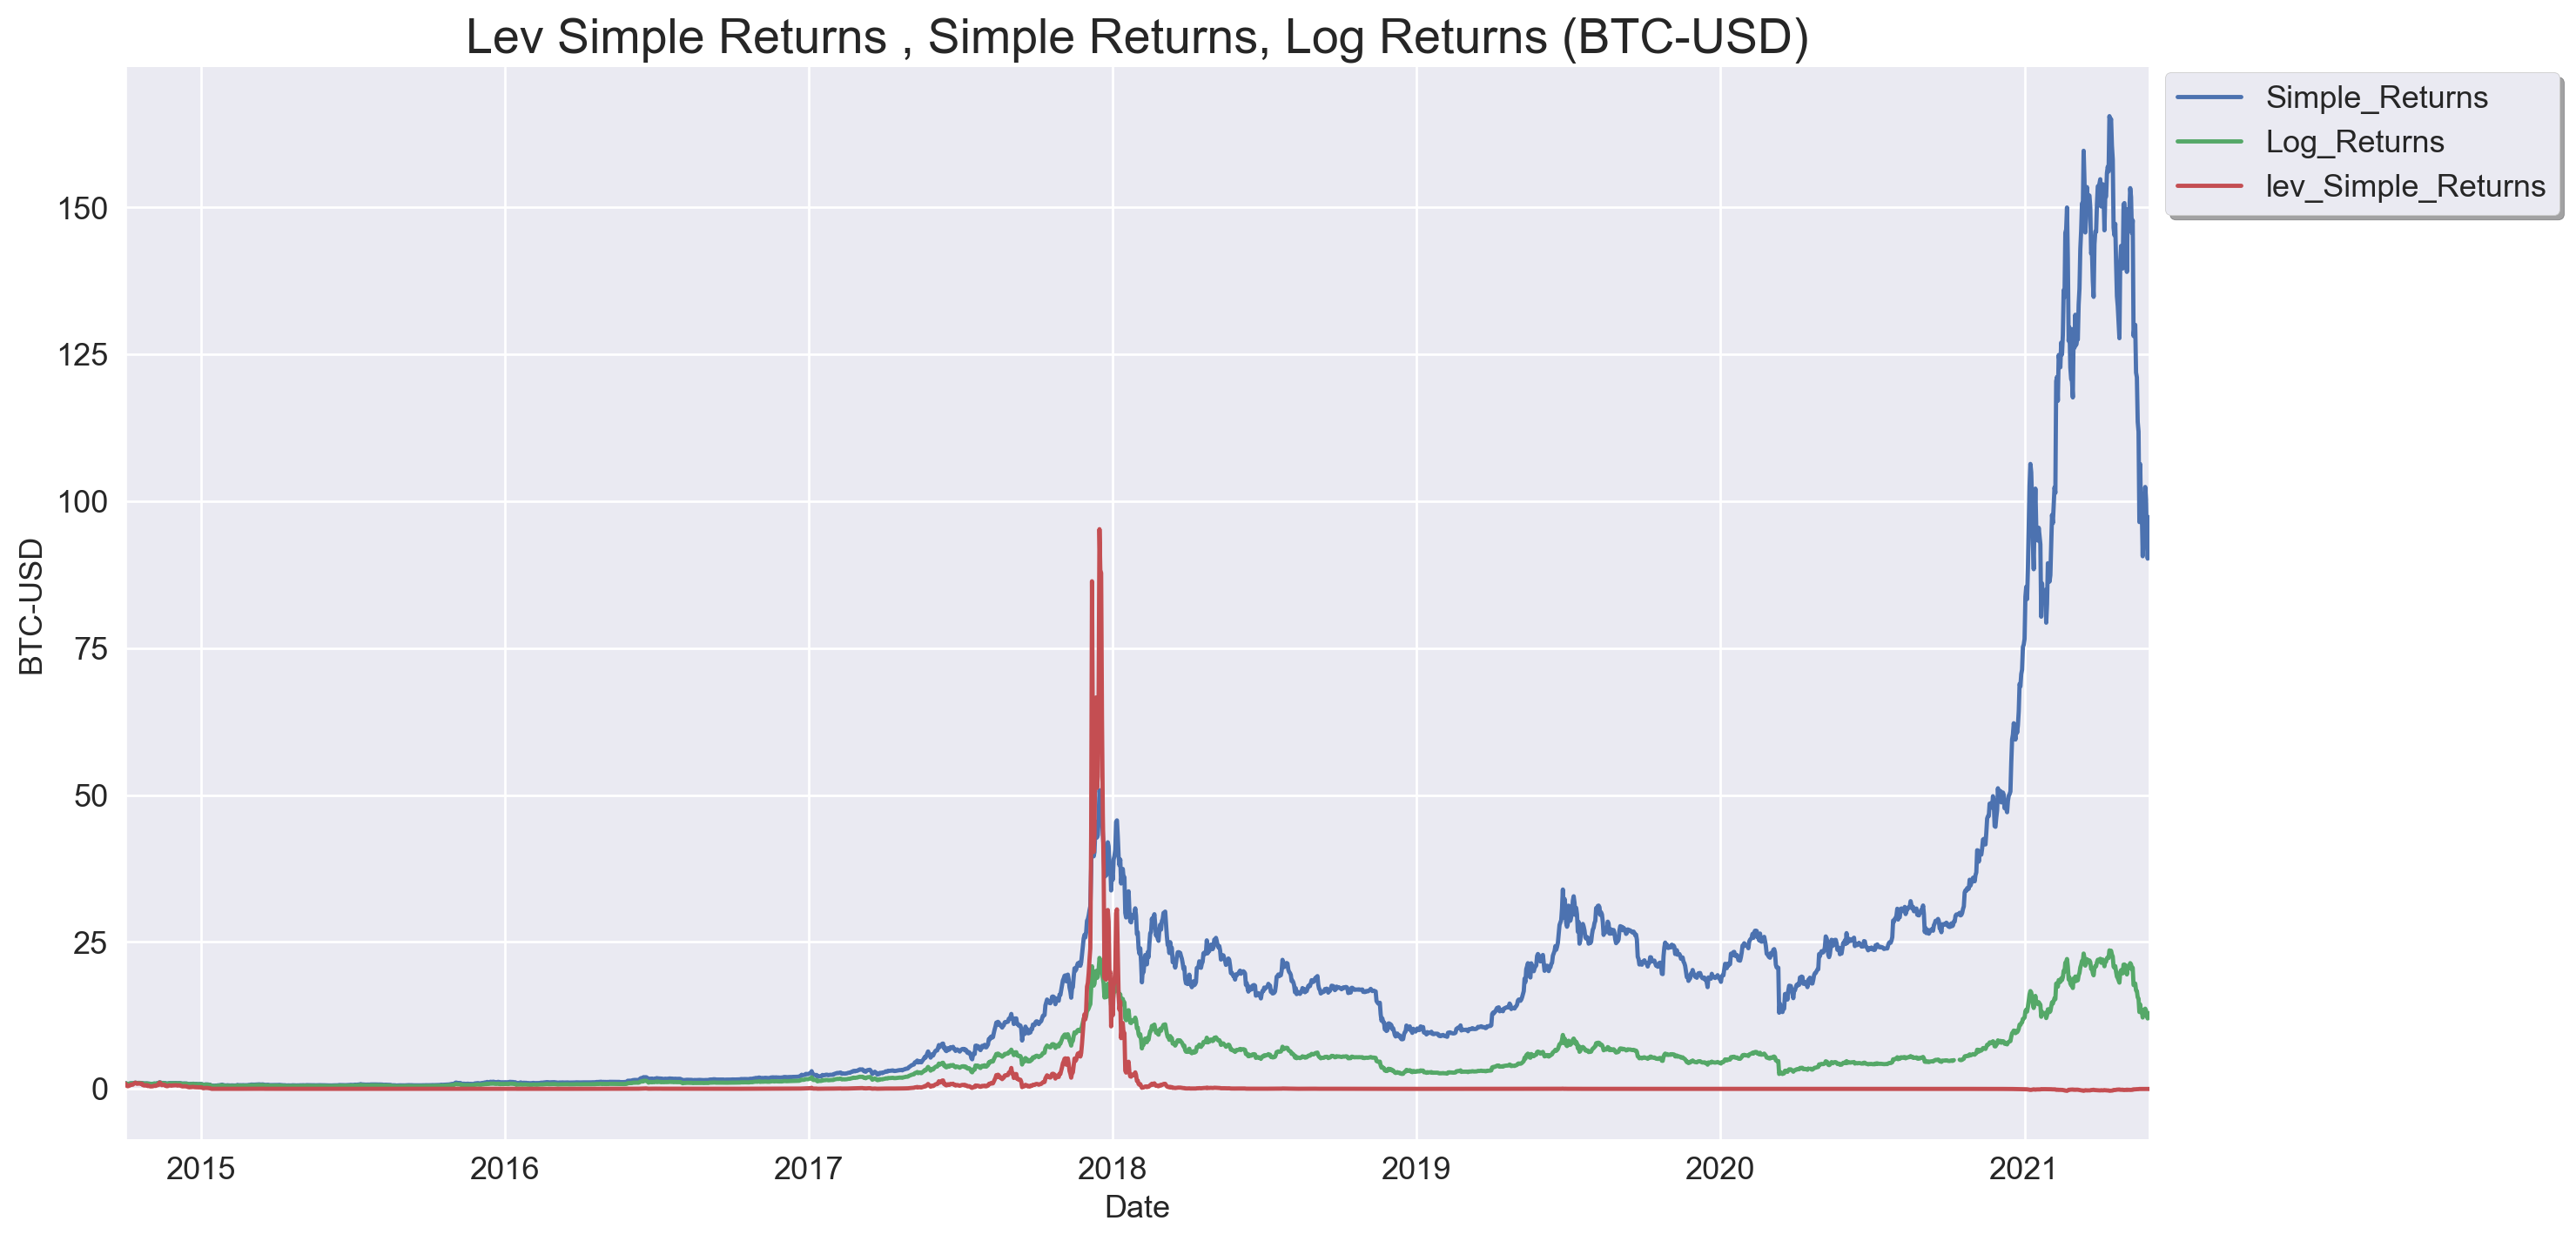

In [ ]:
bitcoin.iloc[:,1:].add(1).cumprod().plot(figsize = (15, 8), fontsize = 13)
plt.title("Lev Simple Returns , Simple Returns, Log Returns (BTC-USD)", fontsize = 20)
plt.xlabel("Date", fontsize = 13)
plt.ylabel("BTC-USD", fontsize = 13)
plt.legend(fontsize = 13, bbox_to_anchor = (1, 1.01) , fancybox = True, shadow = True , frameon = True)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

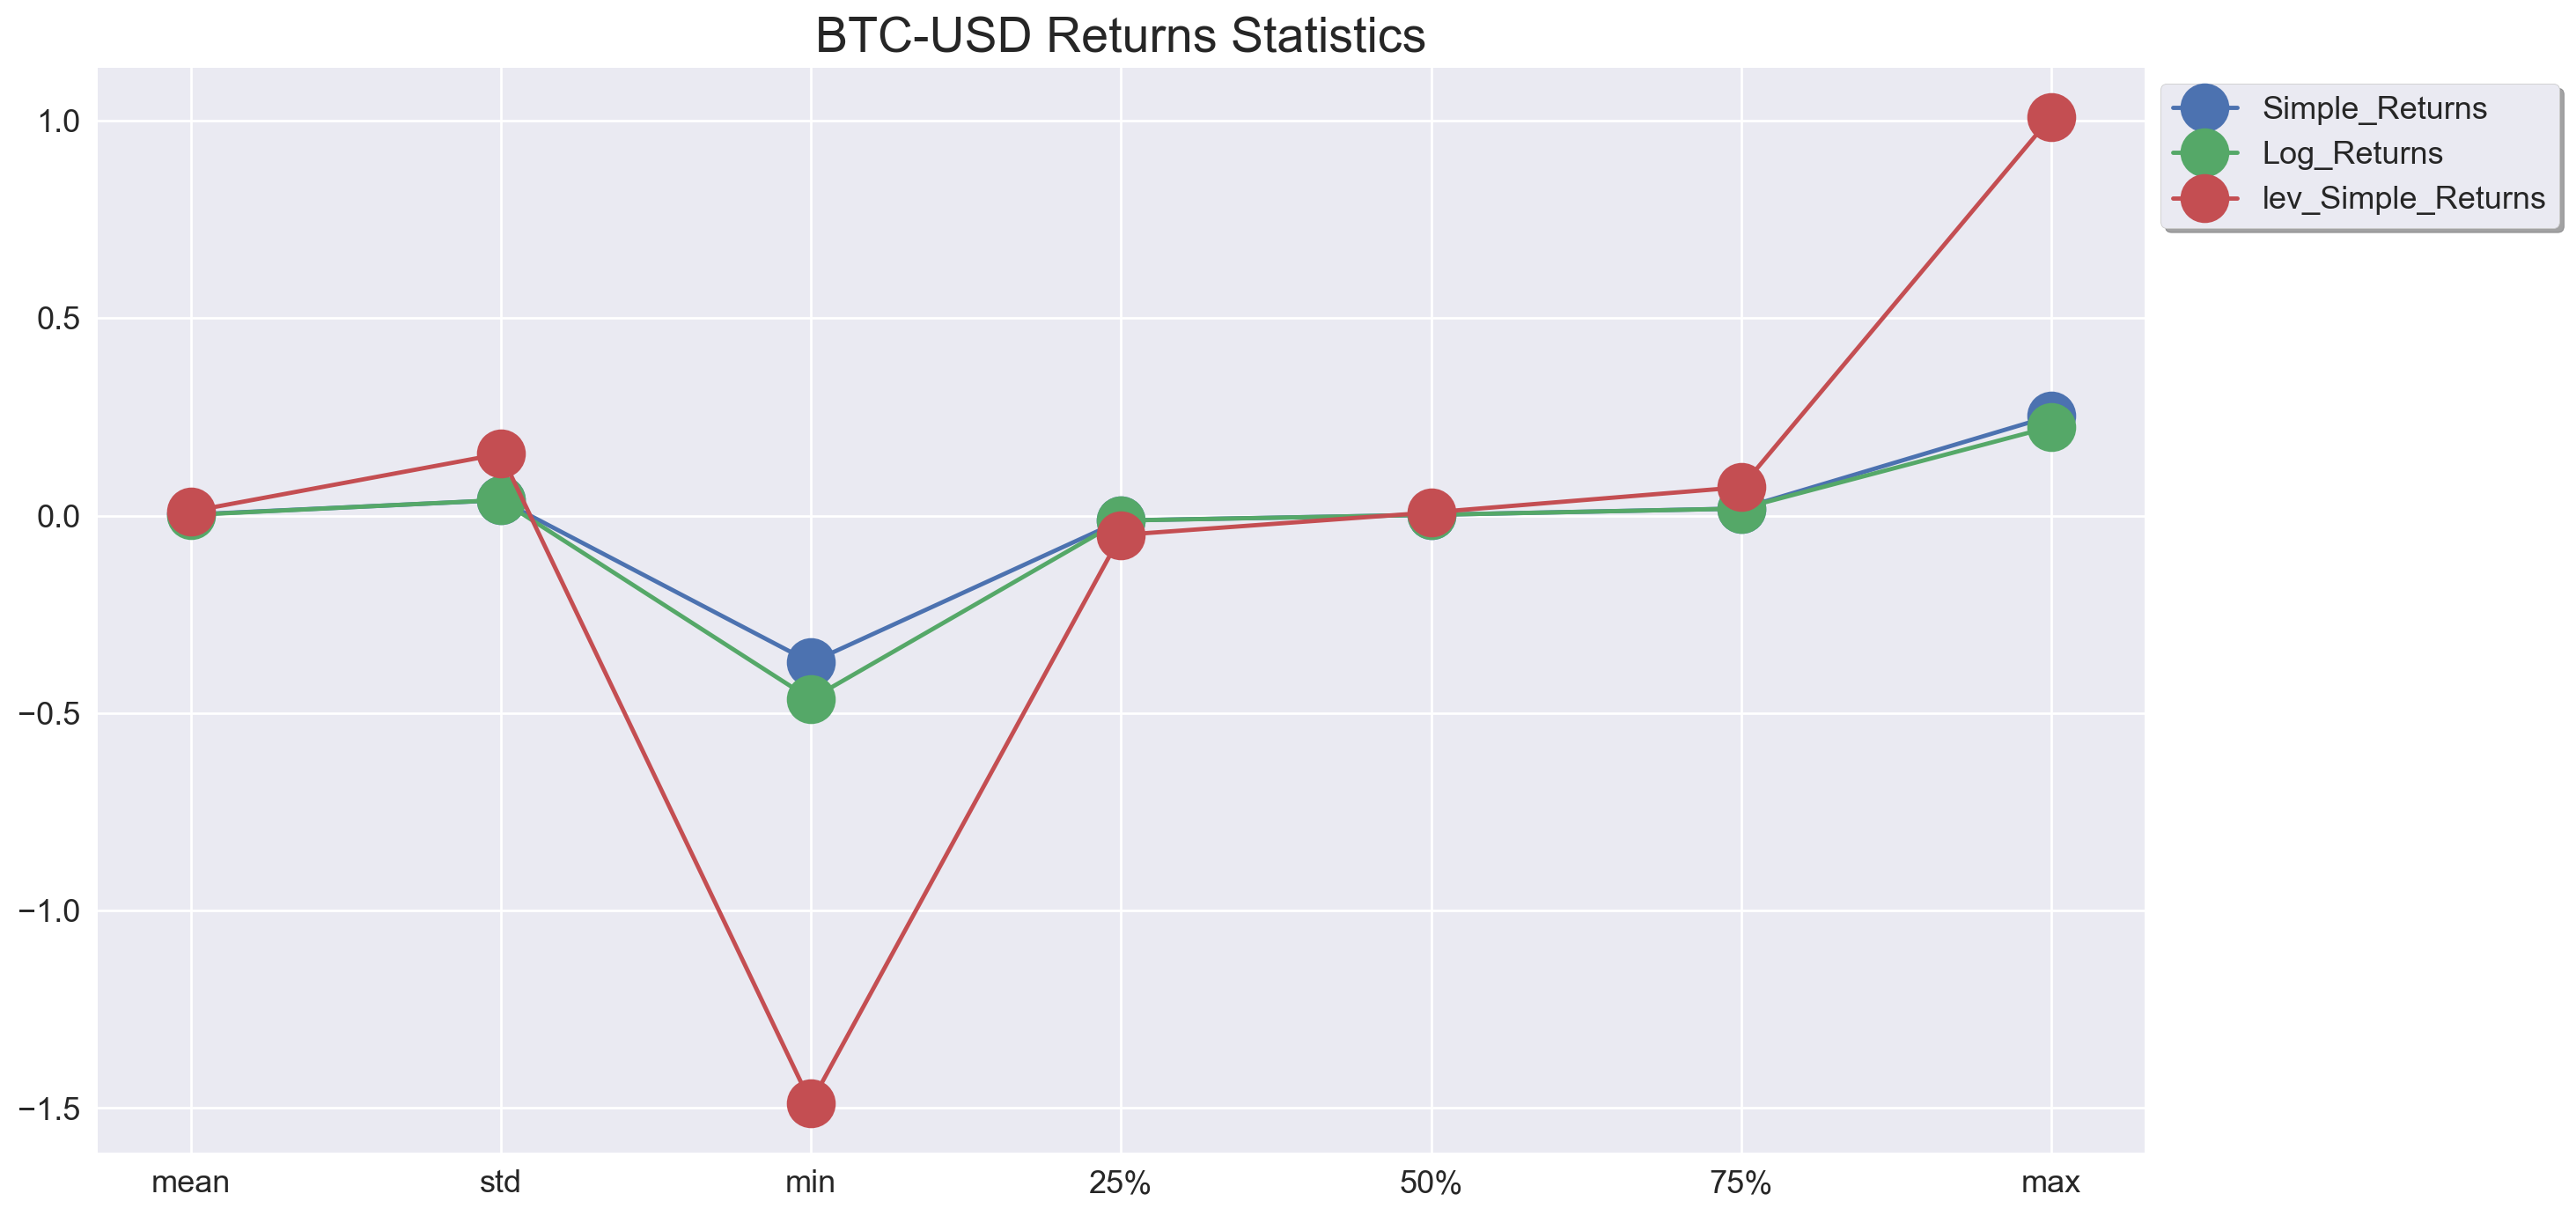

In [ ]:
bitcoin.describe().iloc[1: , 1:].plot(marker = "o", ms = 20, figsize = (15, 8), fontsize = 13)
plt.title("BTC-USD Returns Statistics", fontsize = 20)
plt.legend(fontsize = 13 , bbox_to_anchor = (1,1) , fancybox = True, shadow = True , frameon = True)
#plt.yticks(range(-40, 30, 5))
plt.show()

In [ ]:
bitcoin["lev_Simple_Returns"] = np.where(bitcoin["lev_Simple_Returns"] < -1, -1, bitcoin["lev_Simple_Returns"])

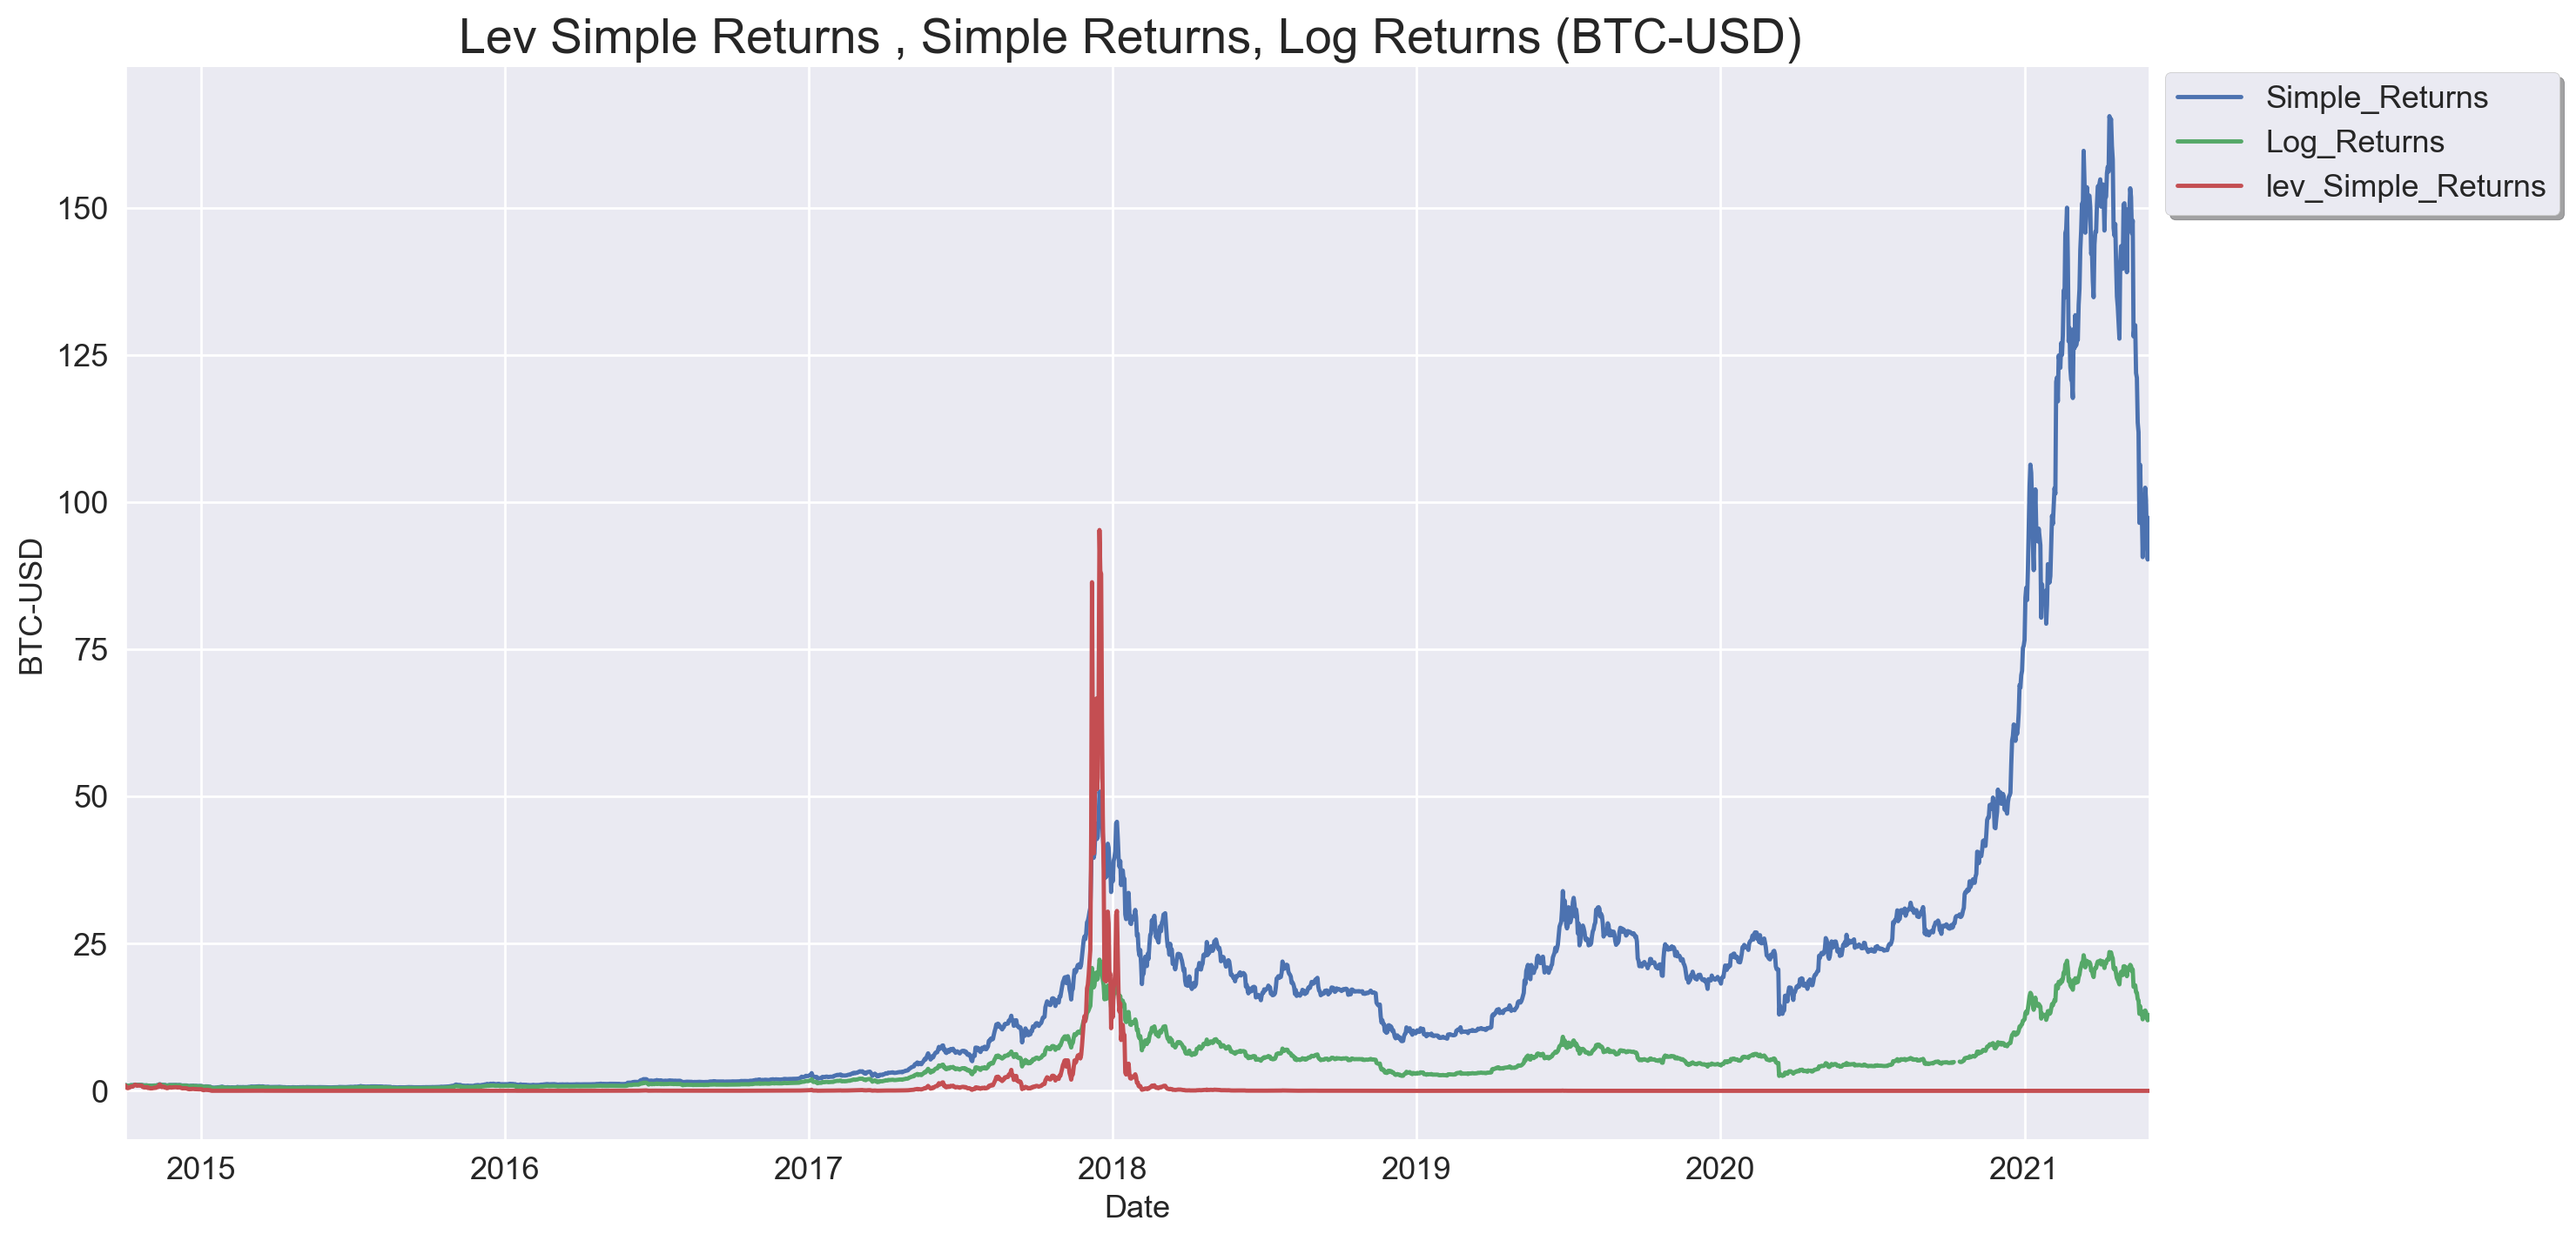

In [ ]:
bitcoin.iloc[:,1:].add(1).cumprod().plot(figsize = (15, 8), fontsize = 13)
plt.title("Lev Simple Returns , Simple Returns, Log Returns (BTC-USD) ", fontsize = 20)
plt.xlabel("Date", fontsize = 13)
plt.ylabel("BTC-USD", fontsize = 13)
plt.legend(fontsize = 13, bbox_to_anchor = (1, 1.01) , fancybox = True, shadow = True , frameon = True)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()